In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import random
from google.colab import drive

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import MLP, Dense, Input
from tensorflow.keras.optimizers import Adam
import math

#from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# ============================================================
#  ✅ DEVICE
# ============================================================
device = "/gpu:0" if tf.config.list_physical_devices('GPU') else "/cpu:0"
print(f"✅ Using device: {device}")

# ============== MÉTRICAS ============================
def eqmn1(y_true, y_pred):
    return np.mean((y_pred - y_true)**2) / (np.var(y_true) + 1e-12)

def eqmn2(y_true, y_pred):
    y_persist = np.roll(y_true, 1)
    y_persist[0] = y_true[0]
    mse_model = np.mean((y_pred - y_true)**2)
    mse_pers  = np.mean((y_persist - y_true)**2) + 1e-12
    return mse_model / mse_pers


def calcular_eqmn1_eqmn2(y_real, y_pred):
    mse_modelo = np.mean((y_pred - y_real)**2)

    media_real = np.mean(y_real)
    var_real = np.mean((y_real - media_real)**2)
    eqmn1 = mse_modelo / var_real

    y_persistente = np.roll(y_real, 1)
    y_persistente[0] = y_real[0]  # corrige a primeira posição
    mse_persistente = np.mean((y_persistente - y_real)**2)
    eqmn2 = mse_modelo / mse_persistente

    return eqmn1, eqmn2

# Monta o Google Drive
drive.mount('/content/drive')
FILE_PATH_1 = "/content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/Used-data-2025-10-15-21_11_53.csv"
FILE_PATH_2 = "/content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/Used-data-2025-11-07-17_39_45.csv"
FILE_PATH_3 = "/content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/Used-data-2026-01-07-09_59_59-MOD.csv"
FILE_PATH_4 = "/content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/filled_gap.csv"
FILE_PATH_5 = "/content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/Used-data-2026-03-26_21_43_44.csv"
FILE_PATH_6 = "/content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/Used-data-2026-04-06_11_00_04.csv"
FILE_PATH_7 = "/content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/Used-data-2026-05-18-22_35_49.csv"


✅ Using device: /gpu:0
Mounted at /content/drive


In [13]:
# ============================================================
#  ✅ CONFIG
# ============================================================
#FILE_PATH_1 = "Used-data-2025-10-15-21_11_53.csv"
#FILE_PATH_2 = "Used-data-2025-11-07-17_39_45.csv"
#FILE_PATH_3 = "Used-data-2026-01-07-09_59_59.csv"

TARGET_COLUMN = "Value"
BEST_WINDOW_MLP = 24
BEST_WINDOW_LSTM = 24
BEST_WINDOW_GRU = 24
BEST_WINDOW_PINT = 24
BEST_WINDOW_TFKAN = 24
EPOCHS_MLP = 200
EPOCHS_LSTM = 200
EPOCHS_GRU = 200
EPOCHS_PINT = 200
EPOCHS_TFKAN = 200
BATCH_SIZE_MLP = 64
BATCH_SIZE_LSTM = 64
BATCH_SIZE_GRU = 64
BATCH_SIZE_PINT = 64
BATCH_SIZE_TFKAN = 64
FORECAST_DAYS = 360

RELOAD = 1
SAVE = 0

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026"

# ============================================================
#  ✅ LOAD DATA & DETECT TIME FREQUENCY
# ============================================================
#df = pd.read_csv(FILE_PATH)
#df.columns = df.columns.str.strip()

df1 = pd.read_csv(FILE_PATH_1)
df2 = pd.read_csv(FILE_PATH_2)
df3 = pd.read_csv(FILE_PATH_3)
df4 = pd.read_csv(FILE_PATH_4)
df5 = pd.read_csv(FILE_PATH_5)
df6 = pd.read_csv(FILE_PATH_6)
df7 = pd.read_csv(FILE_PATH_7)

# padroniza nomes
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()
df4.columns = df4.columns.str.strip()
df5.columns = df5.columns.str.strip()
df6.columns = df6.columns.str.strip()
df7.columns = df7.columns.str.strip()

# concatena
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)
#df = pd.concat([df1,df2], ignore_index=True)

df = df.sort_values("Time").reset_index(drop=True)

# Try to detect if there is a time column
if "Time" in df.columns:
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    df = df.dropna(subset=["Time"])
    interval = df["Time"].diff().median()
    print(f"⏱️ Detected sampling interval: {interval}")
else:
    interval = pd.Timedelta(hours=1)  # fallback assumption
    print("⚠️ No 'Time' column detected — assuming hourly data.")

# Determine if hourly or daily
if interval <= pd.Timedelta(hours=1, minutes=5):
    time_unit = "hour"
    steps_per_day = 24
elif interval <= pd.Timedelta(hours=25):
    time_unit = "day"
    steps_per_day = 1
else:
    time_unit = "unknown"
    steps_per_day = 1
print(f"📏 Detected granularity: {time_unit}-level data")

# Convert logical forecast in days → actual forecast steps
FORECAST_STEPS = FORECAST_DAYS * steps_per_day
print(f"🔮 Forecast horizon: {FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s\n")


⏱️ Detected sampling interval: 0 days 01:00:00
📏 Detected granularity: hour-level data
🔮 Forecast horizon: 360 days = 8640 hours



In [3]:
# ============================================================
#  ✅ DIFFERENCING & NORMALIZATION
# ============================================================
series = df[TARGET_COLUMN].astype(float).values

# Diferenciação
diff_series = np.diff(series).reshape(-1, 1)

# Tamanho do treino (ex: 80%)
train_size = int(len(diff_series) * 0.8)

diff_train = diff_series[:train_size]
diff_test   = diff_series[train_size:]

#Ajustar o scaler somente no treino
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(diff_train)     # ✅ correto

#Normalizar treino e validação separadamente
diff_train_norm = scaler.transform(diff_train)
diff_test_norm   = scaler.transform(diff_test)

diff_norm = diff_train_norm   # <-- cria o nome que sua função espera

def create_windows(data, window, add_channel=False):
    """
    data: (T,1)
    Returns:
      X: (N, window)          if add_channel=False
         (N, window, 1)       if add_channel=True
      y: (N, 1)
    """
    X, y = [], []
    for i in range(len(data) - window):
        x_win = data[i:i+window]          # (window,1)
        y_t   = data[i+window]            # (1,)
        if add_channel:
            X.append(x_win)               # keep (window,1)
        else:
            X.append(x_win[:, 0])          # flatten to (window,)
        y.append(y_t[0])                   # scalar
    X = np.array(X)
    y = np.array(y).reshape(-1, 1)
    return X, y

# MLP (2D)
X_train_mlp, y_train_mlp = create_windows(diff_train_norm, BEST_WINDOW_MLP, add_channel=False)
X_test_mlp,  y_test_mlp  = create_windows(diff_test_norm,  BEST_WINDOW_MLP, add_channel=False)

# LSTM (3D)
X_train_lstm, y_train_lstm = create_windows(diff_train_norm, BEST_WINDOW_LSTM, add_channel=True)
X_test_lstm,  y_test_lstm  = create_windows(diff_test_norm,  BEST_WINDOW_LSTM, add_channel=True)

# GRU (3D)
X_train_gru, y_train_gru = create_windows(diff_train_norm, BEST_WINDOW_GRU, add_channel=True)
X_test_gru,  y_test_gru  = create_windows(diff_test_norm,  BEST_WINDOW_GRU, add_channel=True)

# PINN (3D)
X_train_pint, y_train_pint = create_windows(diff_train_norm, BEST_WINDOW_PINT, add_channel=True)
X_test_pint,  y_test_pint  = create_windows(diff_test_norm,  BEST_WINDOW_PINT, add_channel=True)

# TFKAN (3D)
X_train_tfkan, y_train_tfkan = create_windows(diff_train_norm, BEST_WINDOW_TFKAN, add_channel=True)
X_test_tfkan,  y_test_tfkan  = create_windows(diff_test_norm,  BEST_WINDOW_TFKAN, add_channel=True)


In [4]:
print("series:", series.shape)
print("diff_norm:", diff_norm.shape)
print("diff_train_norm:", diff_train_norm.shape)
print("diff_test_norm:", diff_test_norm.shape)
print("window MLP:", BEST_WINDOW_MLP)
print("window_LSTM:", BEST_WINDOW_LSTM)
print("window_GRU:", BEST_WINDOW_GRU)
print("window_PINT:", BEST_WINDOW_PINT)
print("window_TFKAN:", BEST_WINDOW_TFKAN)

series: (5425,)
diff_norm: (4339, 1)
diff_train_norm: (4339, 1)
diff_test_norm: (1085, 1)
window MLP: 24
window_LSTM: 24
window_GRU: 24
window_PINT: 24
window_TFKAN: 24


# DATASET

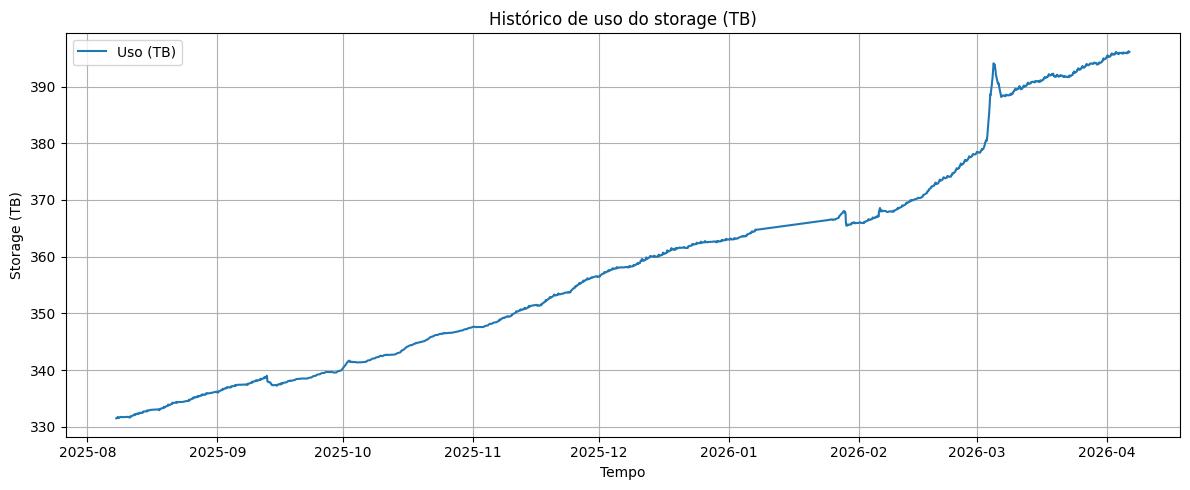

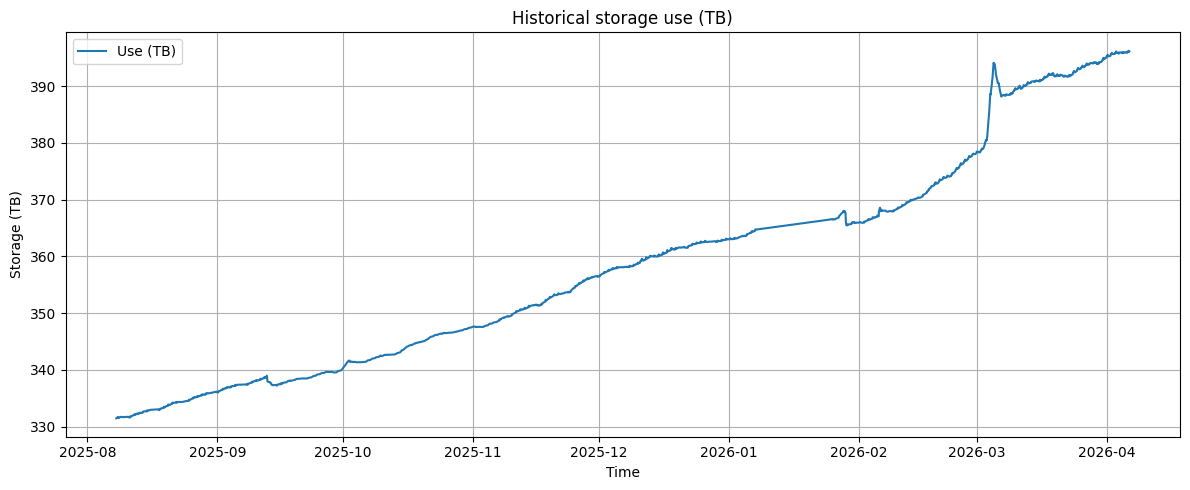

In [5]:
# ============================================================
#  ✅ PLOT DATA
# ============================================================
TO_TB = 1e12   # TB decimal (use 1024**4 se quiser TiB)

y_tb = df[TARGET_COLUMN].values / TO_TB


# ============================================================
#  ✅ PLOT DATA
# ============================================================

# ============================================================
plt.figure(figsize=(12, 5))
if "Time" in df.columns:
    plt.plot(df["Time"], y_tb, label="Uso (TB)")
    plt.xlabel("Tempo")
else:
    plt.plot(y_tb, label="Uso (TB)")
    plt.xlabel("Índice")

plt.ylabel("Storage (TB)")
plt.title("Histórico de uso do storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("ecs-dataset-pt.png", dpi=300)  # 👈 salva em alta qualidade
plt.show()


plt.figure(figsize=(12, 5))
if "Time" in df.columns:
    plt.plot(df["Time"], y_tb, label="Use (TB)")
    plt.xlabel("Time")
else:
    plt.plot(y_tb, label="Use (TB)")
    plt.xlabel("Índice")

plt.ylabel("Storage (TB)")
plt.title("Historical storage use (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("ecs-dataset-en.png", dpi=300)  # 👈 salva em alta qualidade
plt.show()

# MLP

In [ ]:
# ============================================================
#  ✅ MODEL MLP
# ============================================================
if RELOAD == 0:
    def build_mlp(window):
        model = Sequential([
            Input(shape=(window, 1)),   # mesma forma usada no LSTM
            Flatten(),                  # achata (window, 1) -> (window,)
            Dense(128, activation='relu'),
            Dense(64, activation='relu'),
            Dense(1, activation='linear') # saída escalar
        ])
        optimizer = Adam(learning_rate=1e-5, clipnorm=1.0)
        model.compile(optimizer=optimizer, loss='mse')
        return model

    # ============================================================
    #  ✅ TREINO MLP
    # ============================================================
    with tf.device(device):
        model_mlp = build_mlp(BEST_WINDOW_MLP)
        history = model_mlp.fit(
            X_train_mlp, y_train_mlp,
            epochs=EPOCHS_MLP,
            batch_size=BATCH_SIZE_MLP,
            validation_data=(X_test_mlp, y_test_mlp),
            verbose=1
        )

    # perdas por época
    train_losses_mlp = history.history['loss']
    test_losses_mlp  = history.history['val_loss']


In [24]:
# ============================================================
# 🔄 RELOAD EVERYTHING - MLP
# ============================================================
if RELOAD == 1:
    import os
    import json
    import joblib
    import numpy as np
    from tensorflow.keras.models import load_model


    MODEL_NAME = "mlp"

    # ============================================================
    # FILE PATHS
    # ============================================================
    FILE_MODEL              = f"{BASE_PATH}/{MODEL_NAME}_model.keras"
    FILE_SCALER             = f"{BASE_PATH}/{MODEL_NAME}_scaler.save"
    FILE_CONFIG             = f"{BASE_PATH}/{MODEL_NAME}_config.json"
    FILE_METRICS            = f"{BASE_PATH}/{MODEL_NAME}_metrics.json"

    FILE_TRAIN_LOSS         = f"{BASE_PATH}/train_losses_{MODEL_NAME}.npy"
    FILE_VAL_LOSS           = f"{BASE_PATH}/val_losses_{MODEL_NAME}.npy"

    FILE_X_TRAIN            = f"{BASE_PATH}/X_train_{MODEL_NAME}.npy"
    FILE_Y_TRAIN            = f"{BASE_PATH}/y_train_{MODEL_NAME}.npy"
    FILE_X_TEST             = f"{BASE_PATH}/X_test_{MODEL_NAME}.npy"
    FILE_Y_TEST             = f"{BASE_PATH}/y_test_{MODEL_NAME}.npy"

    FILE_Y_TRAIN_INV        = f"{BASE_PATH}/y_train_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_TRAIN_INV   = f"{BASE_PATH}/y_pred_train_inv_{MODEL_NAME}.npy"
    FILE_Y_TEST_INV         = f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_INV         = f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy"

    FILE_Y_TEST_ABS         = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy"
    FILE_Y_PRED_ABS         = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy"
    FILE_Y_TEST_ABS_TB      = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy"
    FILE_Y_PRED_ABS_TB      = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy"

    FILE_FORECAST_DIFFS     = f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy"
    FILE_FORECAST_DIFFS_INV = f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS       = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy"
    FILE_FORECAST_TB        = f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy"

    FILE_SERIES             = f"{BASE_PATH}/series_original.npy"
    FILE_DIFF_SERIES        = f"{BASE_PATH}/diff_series.npy"
    FILE_DIFF_TRAIN         = f"{BASE_PATH}/diff_train.npy"
    FILE_DIFF_TEST          = f"{BASE_PATH}/diff_test.npy"
    FILE_DIFF_TRAIN_NORM    = f"{BASE_PATH}/diff_train_norm.npy"
    FILE_DIFF_TEST_NORM     = f"{BASE_PATH}/diff_test_norm.npy"

    FILE_LAST_WINDOW        = f"{BASE_PATH}/last_window_{MODEL_NAME}.npy"
    FILE_RECON_INFO         = f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json"

    # ============================================================
    # LOAD CORE
    # ============================================================
    model_mlp = load_model(FILE_MODEL)
    scaler = joblib.load(FILE_SCALER)

    with open(FILE_CONFIG, "r") as f:
        config_mlp = json.load(f)

    with open(FILE_METRICS, "r") as f:
        metrics_mlp = json.load(f)

    BEST_WINDOW_MLP = config_mlp["window"]
    EPOCHS_MLP      = config_mlp["epochs"]
    BATCH_SIZE_MLP  = config_mlp["batch_size"]
    FORECAST_STEPS  = config_mlp["forecast_steps"]
    FORECAST_DAYS   = config_mlp["forecast_days"]
    time_unit       = config_mlp["time_unit"]
    split           = config_mlp["train_size"]

    # ============================================================
    # LOAD HISTORY
    # ============================================================
    train_losses_mlp = np.load(FILE_TRAIN_LOSS)
    test_losses_mlp  = np.load(FILE_VAL_LOSS)

    # ============================================================
    # LOAD ARRAYS
    # ============================================================
    X_train_mlp = np.load(FILE_X_TRAIN)
    y_train_mlp = np.load(FILE_Y_TRAIN)
    X_test_mlp  = np.load(FILE_X_TEST)
    y_test_mlp  = np.load(FILE_Y_TEST)

    y_train_inv_mlp      = np.load(FILE_Y_TRAIN_INV)
    y_pred_train_inv_mlp = np.load(FILE_Y_PRED_TRAIN_INV)
    y_test_inv_mlp       = np.load(FILE_Y_TEST_INV)
    y_pred_inv_mlp       = np.load(FILE_Y_PRED_INV)

    y_test_abs_mlp    = np.load(FILE_Y_TEST_ABS)
    y_pred_abs_mlp    = np.load(FILE_Y_PRED_ABS)
    y_test_abs_mlp_tb = np.load(FILE_Y_TEST_ABS_TB)
    y_pred_abs_mlp_tb = np.load(FILE_Y_PRED_ABS_TB)

    forecast_diffs_mlp     = np.load(FILE_FORECAST_DIFFS)
    forecast_diffs_inv_mlp = np.load(FILE_FORECAST_DIFFS_INV)
    forecast_abs_mlp       = np.load(FILE_FORECAST_ABS)
    forecast_abs_mlp_tb    = np.load(FILE_FORECAST_TB)

    series          = np.load(FILE_SERIES)
    diff_series     = np.load(FILE_DIFF_SERIES)
    diff_train      = np.load(FILE_DIFF_TRAIN)
    diff_test       = np.load(FILE_DIFF_TEST)
    diff_train_norm = np.load(FILE_DIFF_TRAIN_NORM)
    diff_test_norm  = np.load(FILE_DIFF_TEST_NORM)

    last_window_mlp = None
    if os.path.exists(FILE_LAST_WINDOW):
        last_window_mlp = np.load(FILE_LAST_WINDOW)

    with open(FILE_RECON_INFO, "r") as f:
        reconstruction_info_mlp = json.load(f)

    base_value = reconstruction_info_mlp["base_value"]
    series_last_value = reconstruction_info_mlp["series_last_value"]

    # ============================================================
    # OPTIONAL RECOMPUTE
    # ============================================================
    y_pred_mlp_recomputed = model_mlp.predict(X_test_mlp, verbose=0)

    # ============================================================
    # SUMMARY
    # ============================================================
    print("\n✅ RELOAD EVERYTHING - MLP COMPLETED")
    print(f"Base path              : {BASE_PATH}")
    print(f"Model                  : {MODEL_NAME}")
    print(f"Window                 : {BEST_WINDOW_MLP}")
    print(f"Epochs                 : {EPOCHS_MLP}")
    print(f"Batch size             : {BATCH_SIZE_MLP}")
    print(f"Forecast steps         : {FORECAST_STEPS}")
    print(f"Forecast days          : {FORECAST_DAYS}")
    print(f"Time unit              : {time_unit}")

    print("\n📊 Metrics")
    print(f"Final train loss       : {metrics_mlp['final_train_loss']:.6f}")
    print(f"Final val loss         : {metrics_mlp['final_val_loss']:.6f}")
    print(f"MSE train diff         : {metrics_mlp['mse_train_diff']:.6e}")
    print(f"RMSE train diff        : {metrics_mlp['rmse_train_diff']:.6e}")
    print(f"R² train diff          : {metrics_mlp['r2_train_diff']:.6f}")
    print(f"MSE test diff          : {metrics_mlp['mse_test_diff']:.6e}")
    print(f"RMSE test diff         : {metrics_mlp['rmse_test_diff']:.6e}")
    print(f"R² test diff           : {metrics_mlp['r2_test_diff']:.6f}")
    print(f"MSE abs                : {metrics_mlp['mse_abs']:.6e}")
    print(f"RMSE abs               : {metrics_mlp['rmse_abs']:.6e}")
    print(f"R² abs                 : {metrics_mlp['r2_abs']:.6f}")
    print(f"Final forecast TB      : {metrics_mlp['forecast_last_tb']:.3f}")

    print("\n📐 Shapes")
    print(f"X_train_mlp            : {X_train_mlp.shape}")
    print(f"y_train_mlp            : {y_train_mlp.shape}")
    print(f"X_test_mlp             : {X_test_mlp.shape}")
    print(f"y_test_mlp             : {y_test_mlp.shape}")
    print(f"y_pred_inv_mlp         : {y_pred_inv_mlp.shape}")
    print(f"y_test_abs_mlp         : {y_test_abs_mlp.shape}")
    print(f"forecast_abs_mlp_tb    : {forecast_abs_mlp_tb.shape}")

    # ============================================================
    # PACKAGE EVERYTHING
    # ============================================================
    artifacts_mlp = {
        "model_mlp": model_mlp,
        "scaler": scaler,
        "config_mlp": config_mlp,
        "metrics_mlp": metrics_mlp,
        "train_losses_mlp": train_losses_mlp,
        "test_losses_mlp": test_losses_mlp,
        "X_train_mlp": X_train_mlp,
        "y_train_mlp": y_train_mlp,
        "X_test_mlp": X_test_mlp,
        "y_test_mlp": y_test_mlp,
        "y_train_inv_mlp": y_train_inv_mlp,
        "y_pred_train_inv_mlp": y_pred_train_inv_mlp,
        "y_test_inv_mlp": y_test_inv_mlp,
        "y_pred_inv_mlp": y_pred_inv_mlp,
        "y_test_abs_mlp": y_test_abs_mlp,
        "y_pred_abs_mlp": y_pred_abs_mlp,
        "y_test_abs_mlp_tb": y_test_abs_mlp_tb,
        "y_pred_abs_mlp_tb": y_pred_abs_mlp_tb,
        "forecast_diffs_mlp": forecast_diffs_mlp,
        "forecast_diffs_inv_mlp": forecast_diffs_inv_mlp,
        "forecast_abs_mlp": forecast_abs_mlp,
        "forecast_abs_mlp_tb": forecast_abs_mlp_tb,
        "series": series,
        "diff_series": diff_series,
        "diff_train": diff_train,
        "diff_test": diff_test,
        "diff_train_norm": diff_train_norm,
        "diff_test_norm": diff_test_norm,
        "last_window_mlp": last_window_mlp,
        "split": split,
        "base_value": base_value,
        "series_last_value": series_last_value,
        "y_pred_mlp_recomputed": y_pred_mlp_recomputed,
    }

    print("\n✅ artifacts_mlp dictionary created.")



✅ RELOAD EVERYTHING - MLP COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : mlp
Window                 : 24
Epochs                 : 200
Batch size             : 64
Forecast steps         : 8640
Forecast days          : 360
Time unit              : hour

📊 Metrics
Final train loss       : 0.001170
Final val loss         : 0.002924
MSE train diff         : 2.002790e+21
RMSE train diff        : 4.475254e+10
R² train diff          : 0.224174
MSE test diff          : 4.993047e+21
RMSE test diff         : 7.066150e+10
R² test diff           : 0.484533
MSE abs                : 1.711973e+24
RMSE abs               : 1.308424e+12
R² abs                 : 0.964315
Final forecast TB      : 813.497

📐 Shapes
X_train_mlp            : (4315, 24)
y_train_mlp            : (4315, 1)
X_test_mlp             : (1061, 24)
y_test_mlp             : (1061, 1)
y_pred_inv_mlp         : (1061,)
y_test_abs_mlp         : (

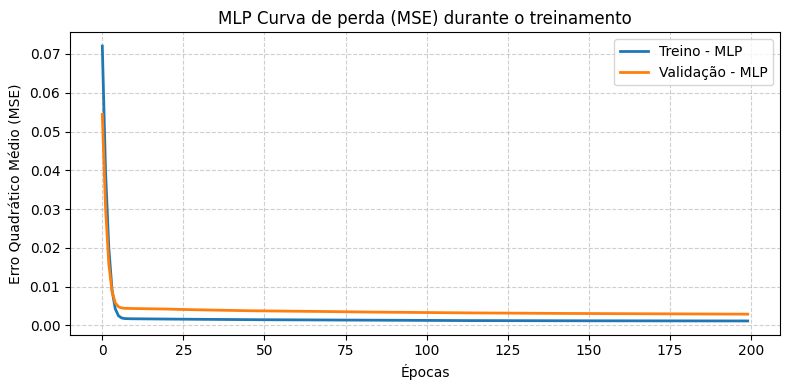

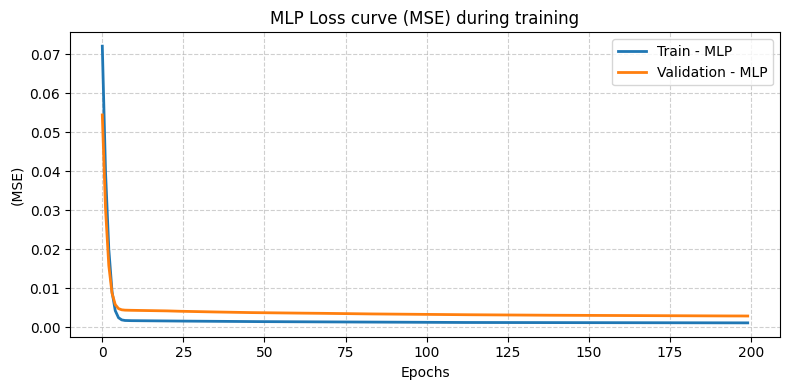

In [ ]:
# ============================================================
#  ✅ MLP - CURVA DE PERDA
# ============================================================
plt.figure(figsize=(8, 4))

plt.plot(train_losses_mlp, label='Treino - MLP', linewidth=2)
plt.plot(test_losses_mlp, label='Validação - MLP', linewidth=2)

plt.title("MLP Curva de perda (MSE) durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("Erro Quadrático Médio (MSE)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("mlp_loss_pt.png", dpi=300)  # 👈 salva em alta qualidade
plt.show()


plt.figure(figsize=(8, 4))

plt.plot(train_losses_mlp, label='Train - MLP', linewidth=2)
plt.plot(test_losses_mlp, label='Validation - MLP', linewidth=2)

plt.title("MLP Loss curve (MSE) during training")
plt.xlabel("Epochs")
plt.ylabel("(MSE)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("mlp_loss_en.png", dpi=300)  # 👈 salva em alta qualidade
plt.show()

In [ ]:
# ============================================================
#  ✅ AVALIAÇÃO TREINO vs VALIDAÇÃO
# ============================================================
def inverse_transform_and_eval(X_t, y_t):
    y_pred = model_mlp.predict(X_t, verbose=0)
    y_t_inv = scaler.inverse_transform(y_t.reshape(-1,1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred).flatten()
    mse = mean_squared_error(y_t_inv, y_pred_inv)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_t_inv, y_pred_inv)
    return y_t_inv, y_pred_inv, mse, rmse, r2

y_train_inv_mlp, y_pred_train_inv_mlp, mse_train_mlp, rmse_train_mlp, r2_train_mlp = inverse_transform_and_eval(X_train_mlp, y_train_mlp)
y_test_inv_mlp, y_pred_inv_mlp, mse_test_mlp, rmse_test_mlp, r2_test_mlp = inverse_transform_and_eval(X_test_mlp, y_test_mlp)

print("\n📊 MLP Comparação Treino vs Validação:")
print(f"{'Métrica':<10} | {'Treino':>15} | {'Validação':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_train_mlp:>15.4e} | {mse_test_mlp:>15.4e}")
print(f"{'RMSE':<10} | {rmse_train_mlp:>15.4e} | {rmse_test_mlp:>15.4e}")
print(f"{'R²':<10} | {r2_train_mlp:>15.4f} | {r2_test_mlp:>15.4f}")

print("\n📊 MLP Comparison Train vs Validation:")
print(f"{'Metric':<10} | {'Train':>15} | {'Validation':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_train_mlp:>15.4e} | {mse_test_mlp:>15.4e}")
print(f"{'RMSE':<10} | {rmse_train_mlp:>15.4e} | {rmse_test_mlp:>15.4e}")
print(f"{'R²':<10} | {r2_train_mlp:>15.4f} | {r2_test_mlp:>15.4f}")


📊 MLP Comparação Treino vs Validação:
Métrica    |          Treino |       Validação
---------------------------------------------
MSE        |      2.0028e+21 |      4.9930e+21
RMSE       |      4.4753e+10 |      7.0661e+10
R²         |          0.2242 |          0.4845

📊 MLP Comparison Train vs Validation:
Metric     |           Train |      Validation
---------------------------------------------
MSE        |      2.0028e+21 |      4.9930e+21
RMSE       |      4.4753e+10 |      7.0661e+10
R²         |          0.2242 |          0.4845


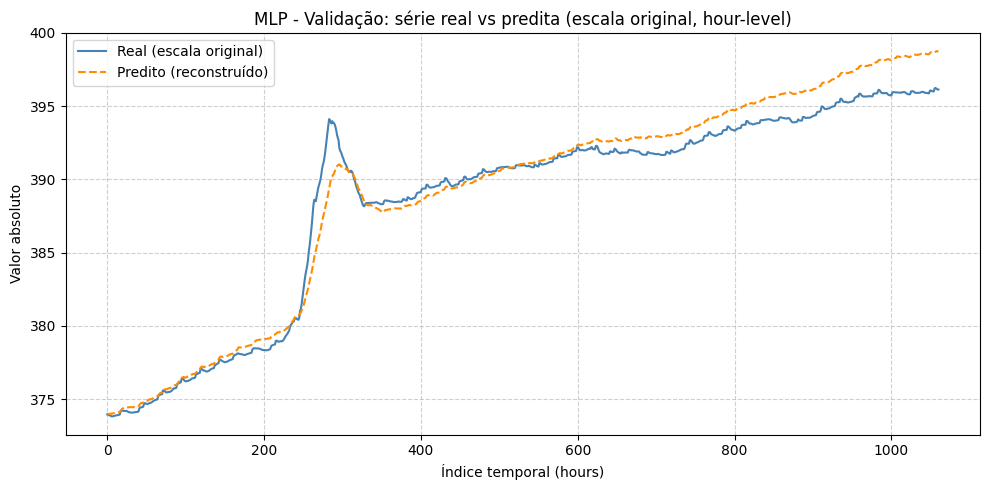

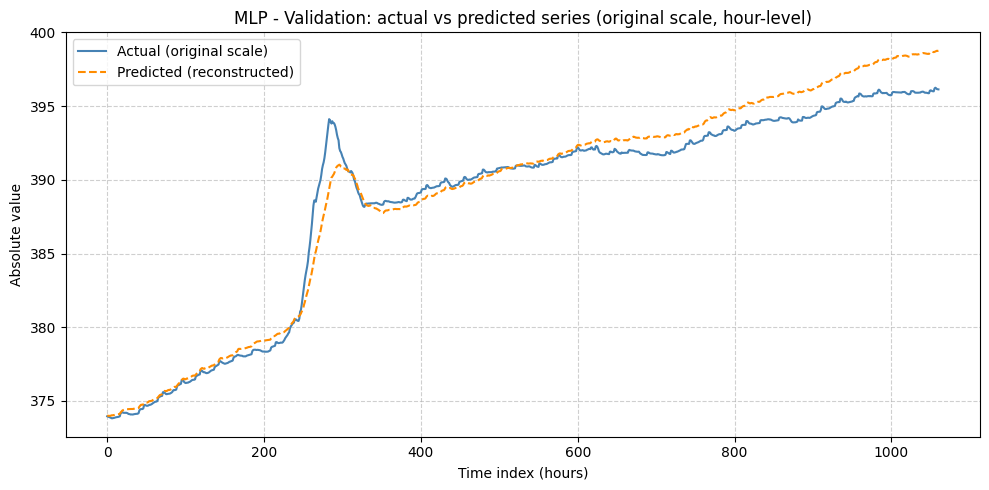


📊 MLP - Métricas em escala ABSOLUTA (reconstruída):
MSE(abs)  = 1.7120e+24
RMSE(abs) = 1.3084e+12
R²(abs)   = 0.9643
Window    = 24
Batch     = 64

📊 MLP - Metrics in ABSOLUTE scale (reconstructed):
MSE(abs)  = 1.7120e+24
RMSE(abs) = 1.3084e+12
R²(abs)   = 0.9643
Window    = 24
Batch     = 64


In [ ]:
# ============================================================
#  ✅ RECONSTRUÇÃO EM ESCALA ABSOLUTA (VALIDAÇÃO)
# ============================================================
# y_test_inv e y_pred_inv já são ΔValue na escala original
# (vieram de inverse_transform_and_eval)
split = train_size
base_value = series[split + BEST_WINDOW_MLP - 1]

# reconstrói série absoluta acumulando os deltas
y_pred_abs_mlp = base_value + np.cumsum(y_pred_inv_mlp)
y_test_abs_mlp = base_value + np.cumsum(y_test_inv_mlp)

y_pred_abs_mlp_tb = y_pred_abs_mlp / 1e12
y_test_abs_mlp_tb = y_test_abs_mlp / 1e12

# Plot validation in absolute scale (consistent with main graph)
plt.figure(figsize=(10,5))
plt.plot(y_test_abs_mlp_tb, label="Real (escala original)", color='steelblue')
plt.plot(y_pred_abs_mlp_tb, label="Predito (reconstruído)", color='darkorange', linestyle='--')
plt.title(f"MLP - Validação: série real vs predita (escala original, {time_unit}-level)")
plt.xlabel(f"Índice temporal ({time_unit}s)")
plt.ylabel("Valor absoluto")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("mlp_val_real_vs_pred-pt.png", dpi=300)  # 👈 salva em alta qualidade
plt.show()

# Plot validation in absolute scale (consistent with the main graph)
plt.figure(figsize=(10,5))
plt.plot(y_test_abs_mlp_tb, label="Actual (original scale)", color='steelblue')
plt.plot(y_pred_abs_mlp_tb, label="Predicted (reconstructed)", color='darkorange', linestyle='--')
plt.title(f"MLP - Validation: actual vs predicted series (original scale, {time_unit}-level)")
plt.xlabel(f"Time index ({time_unit}s)")
plt.ylabel("Absolute value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("mlp_val_real_vs_pred-en.png", dpi=300)  # 👈 salva em alta qualidade
plt.show()

# métricas também em escala absoluta (opcional)
mse_abs_mlp  = mean_squared_error(y_test_abs_mlp, y_pred_abs_mlp)
rmse_abs_mlp = math.sqrt(mse_abs_mlp)
r2_abs_mlp   = r2_score(y_test_abs_mlp, y_pred_abs_mlp)

print("\n📊 MLP - Métricas em escala ABSOLUTA (reconstruída):")
print(f"MSE(abs)  = {mse_abs_mlp:,.4e}")
print(f"RMSE(abs) = {rmse_abs_mlp:,.4e}")
print(f"R²(abs)   = {r2_abs_mlp:.4f}")
print(f"Window    = {BEST_WINDOW_MLP:}")
print(f"Batch     = {BATCH_SIZE_MLP:}")

print("\n📊 MLP - Metrics in ABSOLUTE scale (reconstructed):")
print(f"MSE(abs)  = {mse_abs_mlp:,.4e}")
print(f"RMSE(abs) = {rmse_abs_mlp:,.4e}")
print(f"R²(abs)   = {r2_abs_mlp:.4f}")
print(f"Window    = {BEST_WINDOW_MLP:}")
print(f"Batch     = {BATCH_SIZE_MLP:}")


In [ ]:
#print("model input_shape:", model_mlp.input_shape)
#print("model output_shape:", model_mlp.output_shape)

#print("last_window shape:", last_window.shape, "dtype:", last_window.dtype)



📊 MLP - Forecast (em TB):
Passo 001: 396.174 TB
Passo 002: 396.216 TB
Passo 003: 396.218 TB
Passo 004: 396.205 TB
Passo 005: 396.227 TB
Passo 006: 396.276 TB
Passo 007: 396.322 TB
Passo 008: 396.343 TB
Passo 009: 396.367 TB
Passo 010: 396.391 TB
Passo 011: 396.425 TB
Passo 012: 396.476 TB
Passo 013: 396.517 TB
Passo 014: 396.548 TB
Passo 015: 396.579 TB
Passo 016: 396.593 TB
Passo 017: 396.616 TB
Passo 018: 396.681 TB
Passo 019: 396.751 TB
Passo 020: 396.788 TB
Passo 021: 396.830 TB
Passo 022: 396.861 TB
Passo 023: 396.885 TB
Passo 024: 397.002 TB
Passo 025: 397.058 TB
Passo 026: 397.112 TB
Passo 027: 397.142 TB
Passo 028: 397.158 TB
Passo 029: 397.192 TB
Passo 030: 397.244 TB
Passo 031: 397.296 TB
Passo 032: 397.330 TB
Passo 033: 397.368 TB
Passo 034: 397.400 TB
Passo 035: 397.437 TB
Passo 036: 397.491 TB
Passo 037: 397.537 TB
Passo 038: 397.575 TB
Passo 039: 397.614 TB
Passo 040: 397.640 TB
Passo 041: 397.676 TB
Passo 042: 397.723 TB
Passo 043: 397.782 TB
Passo 044: 397.821 TB
Passo

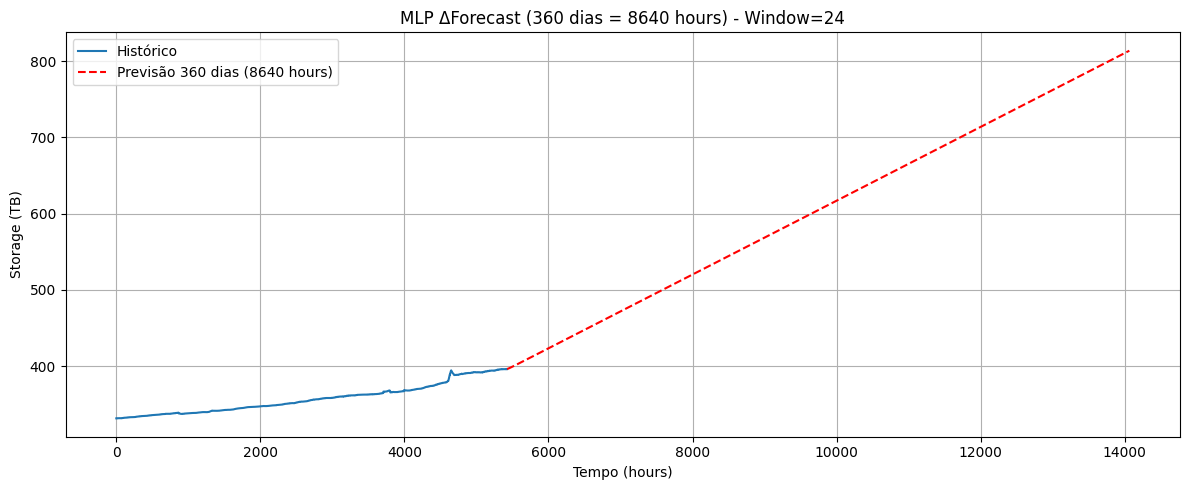

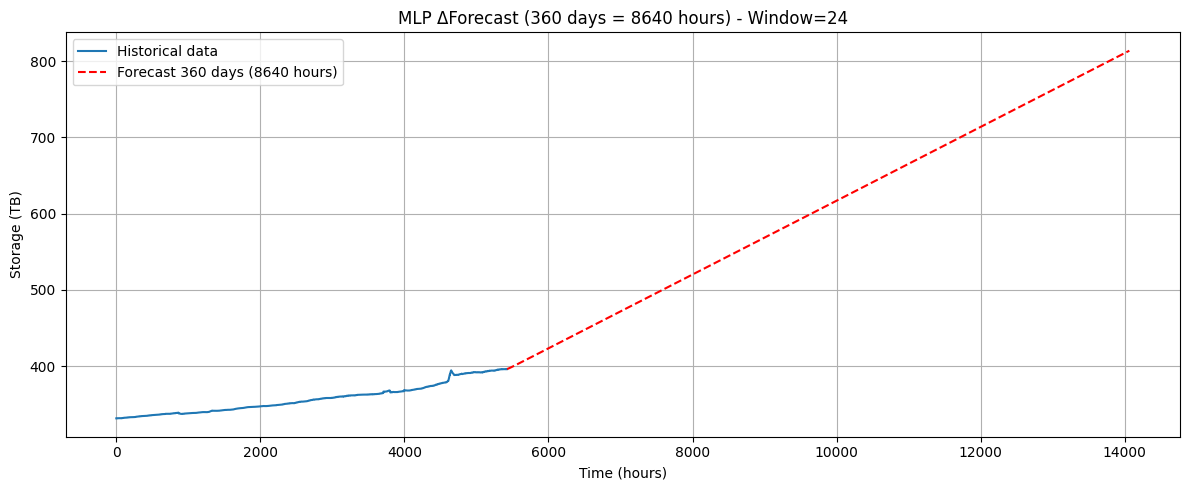

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# garante float32 desde o começo
diff_norm32_mlp = np.asarray(diff_norm, dtype=np.float32)
last_window_mlp = diff_norm32_mlp[-BEST_WINDOW_MLP:].reshape(1, BEST_WINDOW_MLP, 1)

forecast_diffs_mlp = []

for _ in range(FORECAST_STEPS):
    x = tf.convert_to_tensor(last_window_mlp, dtype=tf.float32)
    x = tf.ensure_shape(x, (1, BEST_WINDOW_MLP, 1))

    y = model_mlp(x, training=False)
    yhat = float(y.numpy().reshape(-1)[0])

    forecast_diffs_mlp.append(yhat)

    # atualiza a janela corretamente
    last_window_mlp = np.concatenate(
        [
            last_window_mlp[:, 1:, :],
            np.array(yhat, dtype=np.float32).reshape(1, 1, 1)
        ],
        axis=1
    ).astype(np.float32)

# volta para escala original
forecast_diffs_inv_mlp = scaler.inverse_transform(
    np.array(forecast_diffs_mlp, dtype=np.float32).reshape(-1, 1)
).ravel()

forecast_abs_mlp = series[-1] + np.cumsum(forecast_diffs_inv_mlp)

# converte histórico e previsão para TB
series_tb = series / 1e12
forecast_abs_mlp_tb = forecast_abs_mlp / 1e12

# eixo x da previsão
x_hist = np.arange(len(series_tb))
x_fore_mlp = np.arange(len(series_tb), len(series_tb) + FORECAST_STEPS)

print("\n📊 MLP - Forecast (em TB):")
for i, val in enumerate(forecast_abs_mlp_tb, start=1):
    print(f"Passo {i:03d}: {val:.3f} TB")
print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_mlp_tb[-1]:.3f} TB")

# PT-BR
plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tb, label="Histórico")
plt.plot(
    x_fore_mlp,
    forecast_abs_mlp_tb,
    "r--",
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"MLP ΔForecast ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_MLP}")
plt.xlabel(f"Tempo ({time_unit}s)")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("mlp_forecast-pt.png", dpi=300, bbox_inches="tight")
plt.show()

# EN
plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tb, label="Historical data")
plt.plot(
    x_fore_mlp,
    forecast_abs_mlp_tb,
    "r--",
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"MLP ΔForecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_MLP}")
plt.xlabel(f"Time ({time_unit}s)")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("mlp_forecast-en.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 💾 SAVE EVERYTHING - MLP
# ============================================================
if SAVE == 1:
    import os
    import json
    import shutil
    import joblib
    import numpy as np


    MODEL_NAME = "mlp"

    os.makedirs(BASE_PATH, exist_ok=True)

    # ============================================================
    # 1) SAVE MODEL
    # ============================================================
    model_mlp.save(f"{BASE_PATH}/{MODEL_NAME}_model.keras", include_optimizer=True)

    # ============================================================
    # 2) SAVE SCALER
    # ============================================================
    joblib.dump(scaler, f"{BASE_PATH}/{MODEL_NAME}_scaler.save")

    # ============================================================
    # 3) SAVE CONFIG
    # ============================================================
    config_mlp = {
        "window": int(BEST_WINDOW_MLP),
        "epochs": int(EPOCHS_MLP),
        "batch_size": int(BATCH_SIZE_MLP),
        "forecast_steps": int(FORECAST_STEPS),
        "forecast_days": int(FORECAST_DAYS),
        "time_unit": str(time_unit),
        "train_size": int(split),
        "architecture": "Input(window,1) -> Flatten -> Dense(128,relu) -> Dense(64,relu) -> Dense(1,linear)"
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_config.json", "w") as f:
        json.dump(config_mlp, f, indent=4)

    # ============================================================
    # 4) SAVE TRAINING HISTORY
    # ============================================================
    np.save(f"{BASE_PATH}/train_losses_{MODEL_NAME}.npy", np.array(train_losses_mlp, dtype=np.float64))
    np.save(f"{BASE_PATH}/val_losses_{MODEL_NAME}.npy", np.array(test_losses_mlp, dtype=np.float64))

    # ============================================================
    # 5) SAVE METRICS
    # ============================================================
    metrics_mlp = {
        "final_train_loss": float(train_losses_mlp[-1]),
        "final_val_loss": float(test_losses_mlp[-1]),

        "mse_train_diff": float(mse_train_mlp),
        "rmse_train_diff": float(rmse_train_mlp),
        "r2_train_diff": float(r2_train_mlp),

        "mse_test_diff": float(mse_test_mlp),
        "rmse_test_diff": float(rmse_test_mlp),
        "r2_test_diff": float(r2_test_mlp),

        "mse_abs": float(mse_abs_mlp),
        "rmse_abs": float(rmse_abs_mlp),
        "r2_abs": float(r2_abs_mlp),

        "forecast_last_tb": float(forecast_abs_mlp_tb[-1]),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_metrics.json", "w") as f:
        json.dump(metrics_mlp, f, indent=4)

    # ============================================================
    # 6) SAVE DATA ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/X_train_{MODEL_NAME}.npy", X_train_mlp)
    np.save(f"{BASE_PATH}/y_train_{MODEL_NAME}.npy", y_train_mlp)
    np.save(f"{BASE_PATH}/X_test_{MODEL_NAME}.npy", X_test_mlp)
    np.save(f"{BASE_PATH}/y_test_{MODEL_NAME}.npy", y_test_mlp)

    # escala original (deltas invertidos)
    np.save(f"{BASE_PATH}/y_train_inv_{MODEL_NAME}.npy", y_train_inv_mlp)
    np.save(f"{BASE_PATH}/y_pred_train_inv_{MODEL_NAME}.npy", y_pred_train_inv_mlp)
    np.save(f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy", y_test_inv_mlp)
    np.save(f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy", y_pred_inv_mlp)

    # ============================================================
    # 7) SAVE ABSOLUTE RECONSTRUCTION
    # ============================================================
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy", y_test_abs_mlp)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy", y_pred_abs_mlp)
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy", y_test_abs_mlp_tb)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy", y_pred_abs_mlp_tb)

    # ============================================================
    # 8) SAVE FORECAST
    # ============================================================
    np.save(f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy", np.array(forecast_diffs_mlp))
    np.save(f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy", forecast_diffs_inv_mlp)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy", forecast_abs_mlp)
    np.save(f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy", forecast_abs_mlp_tb)

    try:
        np.save(f"{BASE_PATH}/last_window_{MODEL_NAME}.npy", last_window_mlp)
    except NameError:
        pass

    # ============================================================
    # 9) SAVE PREPROCESSING REFERENCES
    # ============================================================
    np.save(f"{BASE_PATH}/series_original.npy", series)
    np.save(f"{BASE_PATH}/diff_series.npy", diff_series)
    np.save(f"{BASE_PATH}/diff_train.npy", diff_train)
    np.save(f"{BASE_PATH}/diff_test.npy", diff_test)
    np.save(f"{BASE_PATH}/diff_train_norm.npy", diff_train_norm)
    np.save(f"{BASE_PATH}/diff_test_norm.npy", diff_test_norm)

    # ============================================================
    # 10) SAVE RECONSTRUCTION INFO
    # ============================================================
    reconstruction_info_mlp = {
        "split": int(split),
        "base_value": float(base_value),
        "series_last_value": float(series[-1]),
    }

    with open(f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json", "w") as f:
        json.dump(reconstruction_info_mlp, f, indent=4)

    # ============================================================
    # 11) COPY FIGURES
    # ============================================================
    figure_files = [
        "mlp_loss_pt.png",
        "mlp_loss_en.png",
        "mlp_val_real_vs_pred-pt.png",
        "mlp_val_real_vs_pred-en.png",
        "mlp_forecast-pt.png",
        "mlp_forecast-en.png",
    ]

    for fig in figure_files:
        if os.path.exists(fig):
            dest = os.path.join(BASE_PATH, fig)
            if os.path.abspath(fig) != os.path.abspath(dest):
                shutil.copy2(fig, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All MLP artifacts saved in:\n{BASE_PATH}")

# LSTM

In [ ]:
# ============================================================
#  ✅ MODEL LSTM
# ============================================================
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

if RELOAD == 0:
    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=15,
            min_lr=1e-7, verbose=1
        ),
        #EarlyStopping(
        #    monitor="val_loss", patience=20,
        #    restore_best_weights=True, verbose=1
        #),
        ModelCheckpoint(
            "best_lstm_residual.keras", monitor="val_loss",
            save_best_only=True, verbose=0
        )
    ]
    def build_lstm(window):
        model = Sequential([
            Input(shape=(window, 1)),
            #LSTM(128, activation='tanh', return_sequences=True),
            LSTM(64, activation='relu', return_sequences=True),
            LSTM(32, activation='relu', return_sequences=False),
            Dense(32, activation='relu'),
            Dense(1, activation='linear')
        ])
        optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
        model.compile(optimizer=optimizer, loss='mse')
        return model

    with tf.device(device):
        model_lstm = build_lstm(BEST_WINDOW_LSTM)
        history = model_lstm.fit(
            X_train_lstm, y_train_lstm,
            epochs=EPOCHS_LSTM,
            batch_size=BATCH_SIZE_LSTM,
            validation_data=(X_test_lstm, y_test_lstm),
            #callbacks=callbacks,
            verbose=1
        )

    # perdas por época
    train_losses_lstm = history.history['loss']
    test_losses_lstm  = history.history['val_loss']


In [25]:
# ============================================================
# 🔄 RELOAD EVERYTHING - LSTM
# ============================================================

import os
import json
import joblib
import numpy as np
from tensorflow.keras.models import load_model

if RELOAD == 1:
    # ============================================================
    # 📁 BASE PATH
    # ============================================================

    MODEL_NAME = "lstm"

    # ============================================================
    # 📂 FILE PATHS
    # ============================================================
    FILE_MODEL              = f"{BASE_PATH}/{MODEL_NAME}_model.keras"
    FILE_SCALER             = f"{BASE_PATH}/{MODEL_NAME}_scaler.save"
    FILE_METRICS            = f"{BASE_PATH}/{MODEL_NAME}_metrics.json"
    FILE_CONFIG             = f"{BASE_PATH}/{MODEL_NAME}_config.json"

    FILE_TRAIN_LOSS         = f"{BASE_PATH}/train_losses_{MODEL_NAME}.npy"
    FILE_VAL_LOSS           = f"{BASE_PATH}/val_losses_{MODEL_NAME}.npy"

    FILE_X_TRAIN            = f"{BASE_PATH}/X_train_{MODEL_NAME}.npy"
    FILE_Y_TRAIN            = f"{BASE_PATH}/y_train_{MODEL_NAME}.npy"
    FILE_X_TEST             = f"{BASE_PATH}/X_test_{MODEL_NAME}.npy"
    FILE_Y_TEST             = f"{BASE_PATH}/y_test_{MODEL_NAME}.npy"

    FILE_Y_TRAIN_INV        = f"{BASE_PATH}/y_train_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_TRAIN_INV   = f"{BASE_PATH}/y_pred_train_inv_{MODEL_NAME}.npy"
    FILE_Y_TEST_INV         = f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_INV         = f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy"

    FILE_Y_TEST_ABS         = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy"
    FILE_Y_PRED_ABS         = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy"
    FILE_Y_TEST_ABS_TB      = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy"
    FILE_Y_PRED_ABS_TB      = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy"

    FILE_FORECAST_DIFFS     = f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy"
    FILE_FORECAST_DIFFS_INV = f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS       = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS_TB    = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}_tb.npy"

    FILE_SERIES             = f"{BASE_PATH}/series_original.npy"
    FILE_DIFF_SERIES        = f"{BASE_PATH}/diff_series.npy"
    FILE_DIFF_TRAIN         = f"{BASE_PATH}/diff_train.npy"
    FILE_DIFF_TEST          = f"{BASE_PATH}/diff_test.npy"
    FILE_DIFF_TRAIN_NORM    = f"{BASE_PATH}/diff_train_norm.npy"
    FILE_DIFF_TEST_NORM     = f"{BASE_PATH}/diff_test_norm.npy"

    FILE_LAST_WINDOW        = f"{BASE_PATH}/last_window_{MODEL_NAME}.npy"
    FILE_RECON_INFO         = f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json"

    # ============================================================
    # ✅ LOAD CORE ARTIFACTS
    # ============================================================
    model_lstm = load_model(FILE_MODEL)
    scaler = joblib.load(FILE_SCALER)

    with open(FILE_METRICS, "r") as f:
        metrics_lstm = json.load(f)

    with open(FILE_CONFIG, "r") as f:
        config_lstm = json.load(f)

    train_losses_lstm = np.load(FILE_TRAIN_LOSS)
    test_losses_lstm  = np.load(FILE_VAL_LOSS)

    # ============================================================
    # ✅ LOAD TRAINING CONFIG
    # ============================================================
    BEST_WINDOW_LSTM = config_lstm["window"]
    EPOCHS_LSTM      = config_lstm["epochs"]
    BATCH_SIZE_LSTM  = config_lstm["batch_size"]
    FORECAST_STEPS   = config_lstm["forecast_steps"]
    FORECAST_DAYS    = config_lstm["forecast_days"]
    time_unit        = config_lstm["time_unit"]
    train_size       = config_lstm["train_size"]

    # ============================================================
    # ✅ LOAD DATA ARRAYS
    # ============================================================
    X_train_lstm = np.load(FILE_X_TRAIN)
    y_train_lstm = np.load(FILE_Y_TRAIN)
    X_test_lstm  = np.load(FILE_X_TEST)
    y_test_lstm  = np.load(FILE_Y_TEST)

    y_train_inv_lstm      = np.load(FILE_Y_TRAIN_INV)
    y_pred_train_inv_lstm = np.load(FILE_Y_PRED_TRAIN_INV)
    y_test_inv_lstm       = np.load(FILE_Y_TEST_INV)
    y_pred_inv_lstm       = np.load(FILE_Y_PRED_INV)

    y_test_abs_lstm       = np.load(FILE_Y_TEST_ABS)
    y_pred_abs_lstm       = np.load(FILE_Y_PRED_ABS)
    y_test_abs_lstm_tb    = np.load(FILE_Y_TEST_ABS_TB)
    y_pred_abs_lstm_tb    = np.load(FILE_Y_PRED_ABS_TB)

    forecast_diffs_lstm     = np.load(FILE_FORECAST_DIFFS)
    forecast_diffs_inv_lstm = np.load(FILE_FORECAST_DIFFS_INV)
    forecast_abs_lstm       = np.load(FILE_FORECAST_ABS)
    forecast_abs_lstm_tb    = np.load(FILE_FORECAST_ABS_TB)

    series          = np.load(FILE_SERIES)
    diff_series     = np.load(FILE_DIFF_SERIES)
    diff_train      = np.load(FILE_DIFF_TRAIN)
    diff_test       = np.load(FILE_DIFF_TEST)
    diff_train_norm = np.load(FILE_DIFF_TRAIN_NORM)
    diff_test_norm  = np.load(FILE_DIFF_TEST_NORM)

    last_window_lstm = None
    if os.path.exists(FILE_LAST_WINDOW):
        last_window_lstm = np.load(FILE_LAST_WINDOW)

    with open(FILE_RECON_INFO, "r") as f:
        reconstruction_info_lstm = json.load(f)

    split = reconstruction_info_lstm["split"]
    base_value = reconstruction_info_lstm["base_value"]
    series_last_value = reconstruction_info_lstm["series_last_value"]

    # ============================================================
    # ✅ OPTIONAL: RECOMPUTE PREDICTIONS FROM MODEL
    # ============================================================
    y_pred_lstm_recomputed = model_lstm.predict(X_test_lstm, verbose=0)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print("\n✅ RELOAD EVERYTHING - LSTM COMPLETED")
    print(f"Base path              : {BASE_PATH}")
    print(f"Model                  : {MODEL_NAME}")
    print(f"Window                 : {BEST_WINDOW_LSTM}")
    print(f"Epochs                 : {EPOCHS_LSTM}")
    print(f"Batch size             : {BATCH_SIZE_LSTM}")
    print(f"Forecast steps         : {FORECAST_STEPS}")
    print(f"Forecast days          : {FORECAST_DAYS}")
    print(f"Time unit              : {time_unit}")
    print(f"Train size             : {train_size}")

    print("\n📊 Final training losses")
    print(f"Final train loss       : {metrics_lstm['final_train_loss']:.6f}")
    print(f"Final val loss         : {metrics_lstm['final_val_loss']:.6f}")

    print("\n📊 Metrics in differenced/original-delta scale")
    print(f"MSE train              : {metrics_lstm['mse_train_diff']:.6e}")
    print(f"RMSE train             : {metrics_lstm['rmse_train_diff']:.6e}")
    print(f"R² train               : {metrics_lstm['r2_train_diff']:.6f}")
    print(f"MSE test               : {metrics_lstm['mse_test_diff']:.6e}")
    print(f"RMSE test              : {metrics_lstm['rmse_test_diff']:.6e}")
    print(f"R² test                : {metrics_lstm['r2_test_diff']:.6f}")

    print("\n📊 Metrics in absolute scale")
    print(f"MSE abs                : {metrics_lstm['mse_abs']:.6e}")
    print(f"RMSE abs               : {metrics_lstm['rmse_abs']:.6e}")
    print(f"R² abs                 : {metrics_lstm['r2_abs']:.6f}")
    print(f"Final forecast TB      : {metrics_lstm['forecast_last_tb']:.3f}")

    print("\n📐 Shapes")
    print(f"X_train_lstm           : {X_train_lstm.shape}")
    print(f"y_train_lstm           : {y_train_lstm.shape}")
    print(f"X_test_lstm            : {X_test_lstm.shape}")
    print(f"y_test_lstm            : {y_test_lstm.shape}")
    print(f"y_pred_inv_lstm        : {y_pred_inv_lstm.shape}")
    print(f"y_test_abs_lstm        : {y_test_abs_lstm.shape}")
    print(f"forecast_abs_lstm_tb   : {forecast_abs_lstm_tb.shape}")

    # ============================================================
    # ✅ PACKAGE EVERYTHING
    # ============================================================
    artifacts_lstm = {
        "model_lstm": model_lstm,
        "scaler": scaler,
        "metrics_lstm": metrics_lstm,
        "config_lstm": config_lstm,
        "train_losses_lstm": train_losses_lstm,
        "test_losses_lstm": test_losses_lstm,
        "X_train_lstm": X_train_lstm,
        "y_train_lstm": y_train_lstm,
        "X_test_lstm": X_test_lstm,
        "y_test_lstm": y_test_lstm,
        "y_train_inv_lstm": y_train_inv_lstm,
        "y_pred_train_inv_lstm": y_pred_train_inv_lstm,
        "y_test_inv_lstm": y_test_inv_lstm,
        "y_pred_inv_lstm": y_pred_inv_lstm,
        "y_test_abs_lstm": y_test_abs_lstm,
        "y_pred_abs_lstm": y_pred_abs_lstm,
        "y_test_abs_lstm_tb": y_test_abs_lstm_tb,
        "y_pred_abs_lstm_tb": y_pred_abs_lstm_tb,
        "forecast_diffs_lstm": forecast_diffs_lstm,
        "forecast_diffs_inv_lstm": forecast_diffs_inv_lstm,
        "forecast_abs_lstm": forecast_abs_lstm,
        "forecast_abs_lstm_tb": forecast_abs_lstm_tb,
        "series": series,
        "diff_series": diff_series,
        "diff_train": diff_train,
        "diff_test": diff_test,
        "diff_train_norm": diff_train_norm,
        "diff_test_norm": diff_test_norm,
        "last_window_lstm": last_window_lstm,
        "split": split,
        "base_value": base_value,
        "series_last_value": series_last_value,
        "y_pred_lstm_recomputed": y_pred_lstm_recomputed,
    }

    print("\n✅ artifacts_lstm dictionary created.")



✅ RELOAD EVERYTHING - LSTM COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : lstm
Window                 : 24
Epochs                 : 200
Batch size             : 64
Forecast steps         : 8640
Forecast days          : 360
Time unit              : hour
Train size             : 4339

📊 Final training losses
Final train loss       : 0.001243
Final val loss         : 0.010607

📊 Metrics in differenced/original-delta scale
MSE train              : 2.125525e+21
RMSE train             : 4.610342e+10
R² train               : 0.176630
MSE test               : 1.811242e+22
RMSE test              : 1.345824e+11
R² test                : -0.869870

📊 Metrics in absolute scale
MSE abs                : 4.410090e+26
RMSE abs               : 2.100021e+13
R² abs                 : -8.192596
Final forecast TB      : 633.844

📐 Shapes
X_train_lstm           : (4315, 24, 1)
y_train_lstm           : (4315, 1)
X_t

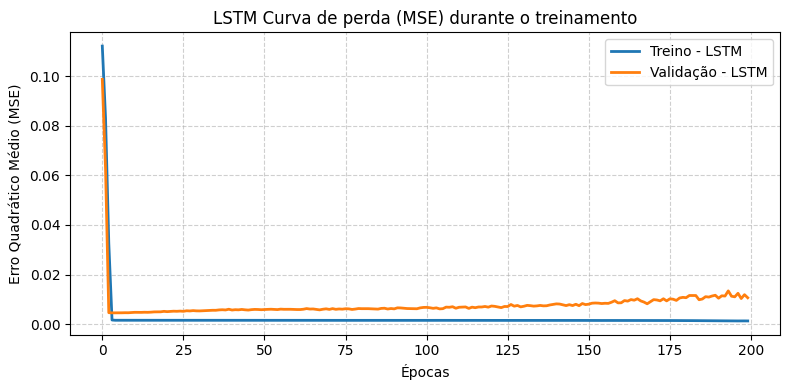

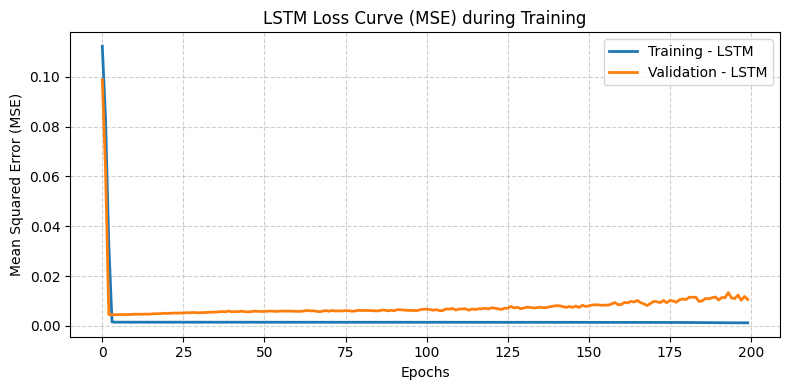

In [ ]:
# ============================================================
#  ✅ CURVA DE PERDA
# ============================================================
plt.figure(figsize=(8, 4))

#plt.plot(train_losses_mlp, label='Treino - MLP', linewidth=2)
plt.plot(train_losses_lstm, label='Treino - LSTM', linewidth=2)
plt.plot(test_losses_lstm, label='Validação - LSTM', linewidth=2)

plt.title("LSTM Curva de perda (MSE) durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("Erro Quadrático Médio (MSE)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("lstm_loss-pt.png", dpi=300, bbox_inches="tight")
plt.show()



plt.figure(figsize=(8, 4))

# plt.plot(train_losses_mlp, label='Training - MLP', linewidth=2)
plt.plot(train_losses_lstm, label='Training - LSTM', linewidth=2)
plt.plot(test_losses_lstm, label='Validation - LSTM', linewidth=2)

plt.title("LSTM Loss Curve (MSE) during Training")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("lstm_loss-en.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ============================================================
#  ✅ LSTM AVALIAÇÃO TREINO vs VALIDAÇÃO
# ============================================================
def inverse_transform_and_eval_lstm(X_t, y_t):
    y_pred = model_lstm.predict(X_t, verbose=0)
    y_t_inv = scaler.inverse_transform(y_t.reshape(-1,1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred).flatten()
    mse = mean_squared_error(y_t_inv, y_pred_inv)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_t_inv, y_pred_inv)
    return y_t_inv, y_pred_inv, mse, rmse, r2

y_train_inv_lstm, y_pred_train_inv_lstm, mse_train_lstm, rmse_train_lstm, r2_train_lstm = inverse_transform_and_eval_lstm(X_train_lstm, y_train_lstm)
y_test_inv_lstm, y_pred_inv_lstm, mse_test_lstm, rmse_test_lstm, r2_test_lstm = inverse_transform_and_eval_lstm(X_test_lstm, y_test_lstm)

print("\n📊 LSTM Comparação Treino vs Validação:")
print(f"{'Métrica':<10} | {'Treino':>15} | {'Validação':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_train_lstm:>15.4e} | {mse_test_lstm:>15.4e}")
print(f"{'RMSE':<10} | {rmse_train_lstm:>15.4e} | {rmse_test_lstm:>15.4e}")
print(f"{'R²':<10} | {r2_train_lstm:>15.4f} | {r2_test_lstm:>15.4f}")
print(f"Window    = {BEST_WINDOW_LSTM:}")
print(f"Batch     = {BATCH_SIZE_LSTM:}")


print("\n📊 LSTM Comparison Train vs Validation:")
print(f"{'Metric':<10} | {'Train':>15} | {'Validation':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_train_lstm:>15.4e} | {mse_test_lstm:>15.4e}")
print(f"{'RMSE':<10} | {rmse_train_lstm:>15.4e} | {rmse_test_lstm:>15.4e}")
print(f"{'R²':<10} | {r2_train_lstm:>15.4f} | {r2_test_lstm:>15.4f}")
print(f"Window    = {BEST_WINDOW_LSTM:}")
print(f"Batch     = {BATCH_SIZE_LSTM:}")


📊 LSTM Comparação Treino vs Validação:
Métrica    |          Treino |       Validação
---------------------------------------------
MSE        |      2.1255e+21 |      1.8112e+22
RMSE       |      4.6103e+10 |      1.3458e+11
R²         |          0.1766 |         -0.8699
Window    = 24
Batch     = 64

📊 LSTM Comparison Train vs Validation:
Metric     |           Train |      Validation
---------------------------------------------
MSE        |      2.1255e+21 |      1.8112e+22
RMSE       |      4.6103e+10 |      1.3458e+11
R²         |          0.1766 |         -0.8699
Window    = 24
Batch     = 64


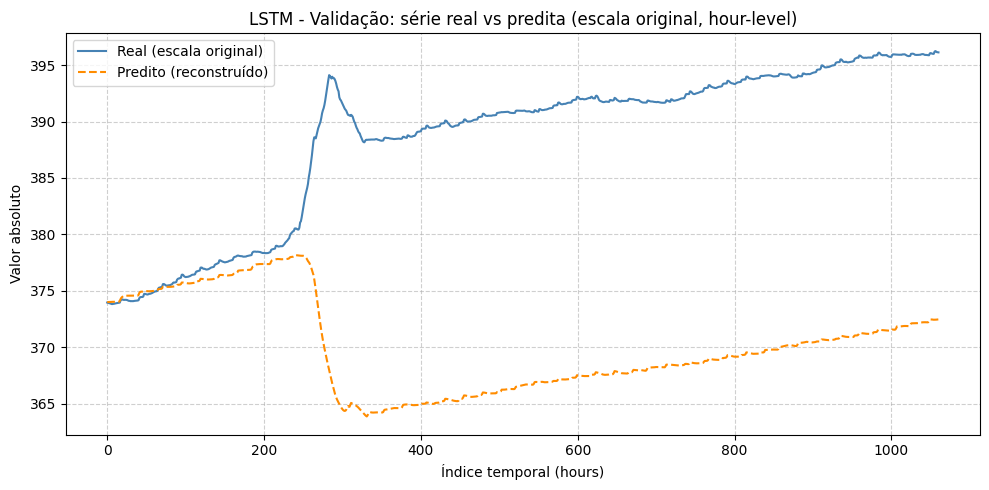

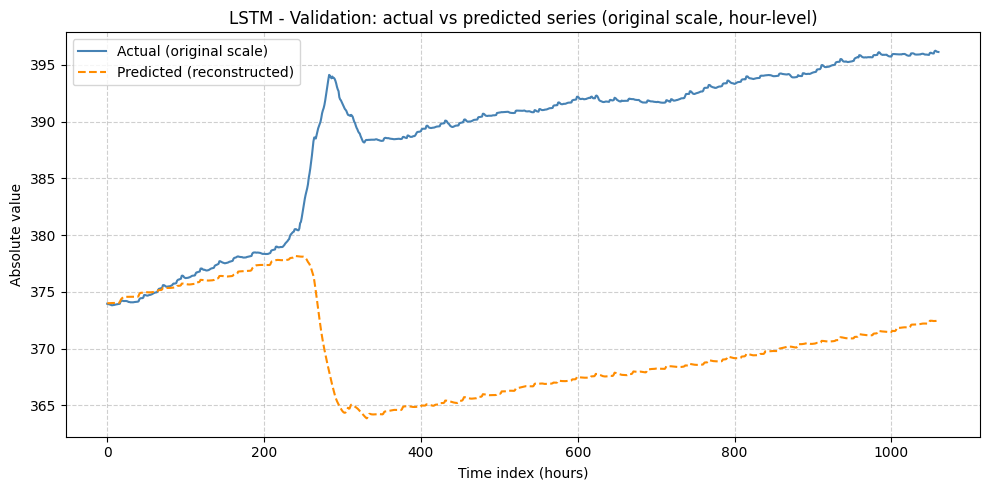


📊 LSTM - Métricas em escala ABSOLUTA (reconstruída):
Window    = 24
Batch     = 64
MSE(abs)  = 4.4101e+26
RMSE(abs) = 2.1000e+13
R²(abs)   = -8.1926

📊 LSTM - Metrics in ABSOLUTE scale (reconstructed):
Window    = 24
Batch     = 64
MSE(abs)  = 4.4101e+26
RMSE(abs) = 2.1000e+13
R²(abs)   = -8.1926


In [ ]:
# ============================================================
#  ✅ LSTM - RECONSTRUÇÃO EM ESCALA ABSOLUTA (VALIDAÇÃO)
# ============================================================
# y_test_inv e y_pred_inv já são ΔValue na escala original
# (vieram de inverse_transform_and_eval)
split = train_size
base_value = series[split + BEST_WINDOW_LSTM - 1]

# reconstrói série absoluta acumulando os deltas
y_pred_abs_lstm = base_value + np.cumsum(y_pred_inv_lstm)
y_test_abs_lstm = base_value + np.cumsum(y_test_inv_lstm)

y_pred_abs_lstm_tb = y_pred_abs_lstm / 1e12
y_test_abs_lstm_tb = y_test_abs_lstm / 1e12

# Plot validation in absolute scale (consistent with main graph)
plt.figure(figsize=(10,5))
plt.plot(y_test_abs_lstm_tb, label="Real (escala original)", color='steelblue')
plt.plot(y_pred_abs_lstm_tb, label="Predito (reconstruído)", color='darkorange', linestyle='--')
plt.title(f"LSTM - Validação: série real vs predita (escala original, {time_unit}-level)")
plt.xlabel(f"Índice temporal ({time_unit}s)")
plt.ylabel("Valor absoluto")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("lstm_val_real_vs_pred-pt.png", dpi=300, bbox_inches="tight")
plt.show()


# Plot validation in absolute scale (consistent with the main graph)
plt.figure(figsize=(10,5))
plt.plot(y_test_abs_lstm_tb, label="Actual (original scale)", color='steelblue')
plt.plot(y_pred_abs_lstm_tb, label="Predicted (reconstructed)", color='darkorange', linestyle='--')
plt.title(f"LSTM - Validation: actual vs predicted series (original scale, {time_unit}-level)")
plt.xlabel(f"Time index ({time_unit}s)")
plt.ylabel("Absolute value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("lstm_val_real_vs_pred-en.png", dpi=300, bbox_inches="tight")
plt.show()


# métricas também em escala absoluta (opcional)
mse_abs_lstm  = mean_squared_error(y_test_abs_lstm, y_pred_abs_lstm)
rmse_abs_lstm = math.sqrt(mse_abs_lstm)
r2_abs_lstm   = r2_score(y_test_abs_lstm, y_pred_abs_lstm)

print("\n📊 LSTM - Métricas em escala ABSOLUTA (reconstruída):")
print(f"Window    = {BEST_WINDOW_LSTM:}")
print(f"Batch     = {BATCH_SIZE_LSTM:}")
print(f"MSE(abs)  = {mse_abs_lstm:,.4e}")
print(f"RMSE(abs) = {rmse_abs_lstm:,.4e}")
print(f"R²(abs)   = {r2_abs_lstm:.4f}")

print("\n📊 LSTM - Metrics in ABSOLUTE scale (reconstructed):")
print(f"Window    = {BEST_WINDOW_LSTM:}")
print(f"Batch     = {BATCH_SIZE_LSTM:}")
print(f"MSE(abs)  = {mse_abs_lstm:,.4e}")
print(f"RMSE(abs) = {rmse_abs_lstm:,.4e}")
print(f"R²(abs)   = {r2_abs_lstm:.4f}")








In [ ]:
if RELOAD == 0:
    import numpy as np
    import tensorflow as tf
    import matplotlib.pyplot as plt

    # garante float32 desde o começo
    diff_norm32_lstm = np.asarray(diff_norm, dtype=np.float32)
    last_window_lstm = diff_norm32_lstm[-BEST_WINDOW_LSTM:].reshape(1, BEST_WINDOW_LSTM, 1)

    forecast_diffs_lstm = []

    for _ in range(FORECAST_STEPS):
        x = tf.convert_to_tensor(last_window_lstm, dtype=tf.float32)
        x = tf.ensure_shape(x, (1, BEST_WINDOW_LSTM, 1))

        # chamada direta do modelo
        y = model_lstm(x, training=False)
        yhat = float(y.numpy().reshape(-1)[0])

        forecast_diffs_lstm.append(yhat)

        # atualiza a janela corretamente
        last_window_lstm = np.concatenate(
            [
                last_window_lstm[:, 1:, :],
                np.array(yhat, dtype=np.float32).reshape(1, 1, 1)
            ],
            axis=1
        ).astype(np.float32)

    # volta da escala normalizada/diferenciada para escala original
    forecast_diffs_inv_lstm = scaler.inverse_transform(
        np.array(forecast_diffs_lstm, dtype=np.float32).reshape(-1, 1)
    ).ravel()

    forecast_abs_lstm = series[-1] + np.cumsum(forecast_diffs_inv_lstm)

    # converte tudo para TB
    series_tb = series / 1e12
    forecast_abs_lstm_tb = forecast_abs_lstm / 1e12

    print("\n📊 LSTM - Forecast (em TB):")
    for i, val in enumerate(forecast_abs_lstm_tb, start=1):
        print(f"Passo {i:03d}: {val:.3f} TB")
    print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_lstm_tb[-1]:.3f} TB")

    # eixos
    x_hist_lstm = np.arange(len(series_tb))
    x_fore_lstm = np.arange(len(series_tb), len(series_tb) + FORECAST_STEPS)

    # =========================
    # PT-BR
    # =========================
    plt.figure(figsize=(12, 5))
    plt.plot(x_hist_lstm, series_tb, label="Histórico")
    plt.plot(
        x_fore_lstm,
        forecast_abs_lstm_tb,
        "r--",
        label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)"
    )
    plt.title(f"LSTM ΔForecast ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_LSTM}")
    plt.xlabel(f"Tempo ({time_unit}s)")
    plt.ylabel("Storage (TB)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("lstm_forecast-pt.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================
    # EN
    # =========================
    plt.figure(figsize=(12, 5))
    plt.plot(x_hist_lstm, series_tb, label="Historical data")
    plt.plot(
        x_fore_lstm,
        forecast_abs_lstm_tb,
        "r--",
        label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)"
    )
    plt.title(f"LSTM ΔForecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_LSTM}")
    plt.xlabel(f"Time ({time_unit}s)")
    plt.ylabel("Storage (TB)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("lstm_forecast-en.png", dpi=300, bbox_inches="tight")
    plt.show()

KeyboardInterrupt: 


📊 LSTM - Forecast (em TB):
Passo 001: 396.128 TB
Passo 002: 396.124 TB
Passo 003: 396.117 TB
Passo 004: 396.112 TB
Passo 005: 396.115 TB
Passo 006: 396.121 TB
Passo 007: 396.125 TB
Passo 008: 396.130 TB
Passo 009: 396.135 TB
Passo 010: 396.142 TB
Passo 011: 396.148 TB
Passo 012: 396.154 TB
Passo 013: 396.158 TB
Passo 014: 396.161 TB
Passo 015: 396.163 TB
Passo 016: 396.166 TB
Passo 017: 396.179 TB
Passo 018: 396.253 TB
Passo 019: 396.274 TB
Passo 020: 396.288 TB
Passo 021: 396.304 TB
Passo 022: 396.323 TB
Passo 023: 396.374 TB
Passo 024: 396.533 TB
Passo 025: 396.550 TB
Passo 026: 396.563 TB
Passo 027: 396.576 TB
Passo 028: 396.590 TB
Passo 029: 396.607 TB
Passo 030: 396.623 TB
Passo 031: 396.640 TB
Passo 032: 396.657 TB
Passo 033: 396.674 TB
Passo 034: 396.690 TB
Passo 035: 396.705 TB
Passo 036: 396.719 TB
Passo 037: 396.731 TB
Passo 038: 396.741 TB
Passo 039: 396.751 TB
Passo 040: 396.762 TB
Passo 041: 396.777 TB
Passo 042: 396.796 TB
Passo 043: 396.805 TB
Passo 044: 396.813 TB
Pass

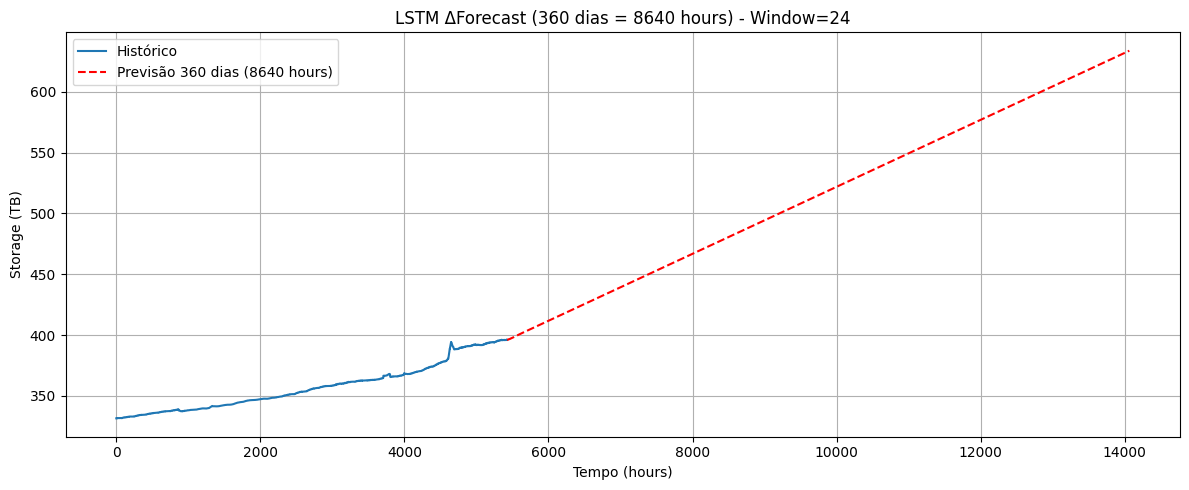

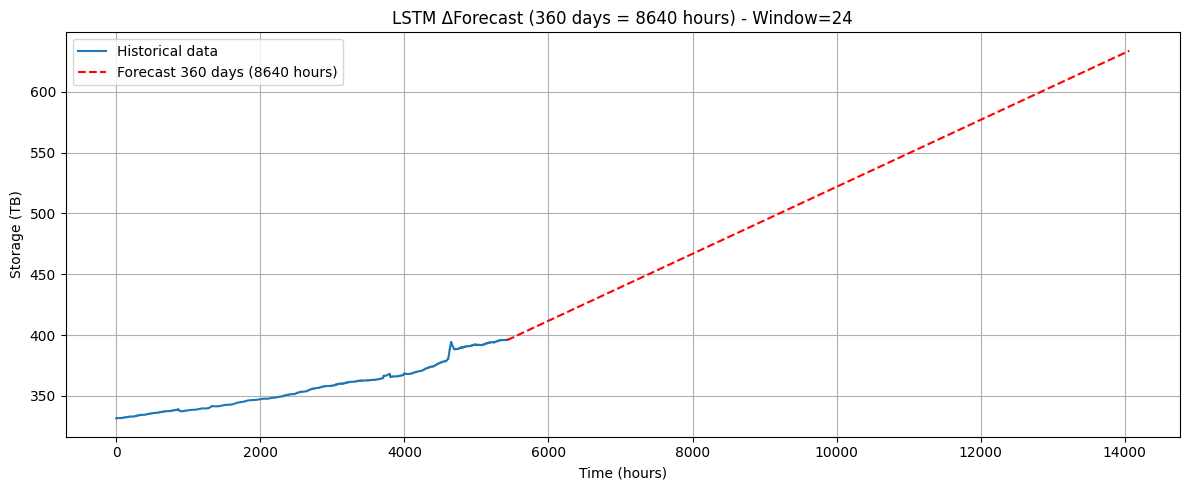

In [ ]:
if RELOAD == 1:
    # converte tudo para TB
    series_tb = series / 1e12
    forecast_abs_lstm_tb = forecast_abs_lstm / 1e12

    print("\n📊 LSTM - Forecast (em TB):")
    for i, val in enumerate(forecast_abs_lstm_tb, start=1):
        print(f"Passo {i:03d}: {val:.3f} TB")
    print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_lstm_tb[-1]:.3f} TB")

    # eixos
    x_hist_lstm = np.arange(len(series_tb))
    x_fore_lstm = np.arange(len(series_tb), len(series_tb) + FORECAST_STEPS)

    # =========================
    # PT-BR
    # =========================
    plt.figure(figsize=(12, 5))
    plt.plot(x_hist_lstm, series_tb, label="Histórico")
    plt.plot(
        x_fore_lstm,
        forecast_abs_lstm_tb,
        "r--",
        label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)"
    )
    plt.title(f"LSTM ΔForecast ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_LSTM}")
    plt.xlabel(f"Tempo ({time_unit}s)")
    plt.ylabel("Storage (TB)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("lstm_forecast-pt.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================
    # EN
    # =========================
    plt.figure(figsize=(12, 5))
    plt.plot(x_hist_lstm, series_tb, label="Historical data")
    plt.plot(
        x_fore_lstm,
        forecast_abs_lstm_tb,
        "r--",
        label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)"
    )
    plt.title(f"LSTM ΔForecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_LSTM}")
    plt.xlabel(f"Time ({time_unit}s)")
    plt.ylabel("Storage (TB)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("lstm_forecast-en.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# ============================================================
# 💾 SAVE PIPELINE - LSTM (FULL REPRODUCIBILITY)
# ============================================================

if SAVE == 1:
    import os
    import json
    import joblib
    import numpy as np

    # ============================================================
    # 📁 BASE PATH
    # ============================================================

    #os.makedirs(BASE_PATH, exist_ok=True)

    # ============================================================
    # 📌 PREFIX
    # ============================================================
    MODEL_NAME = "lstm"

    # ============================================================
    # 1. SAVE TRAINING HISTORY
    # ============================================================
    np.save(f"{BASE_PATH}/train_losses_{MODEL_NAME}.npy", train_losses_lstm)
    np.save(f"{BASE_PATH}/val_losses_{MODEL_NAME}.npy", test_losses_lstm)

    # ============================================================
    # 2. SAVE TRAINED MODEL
    # ============================================================
    model_lstm.save(f"{BASE_PATH}/{MODEL_NAME}_model.keras", include_optimizer=True)

    # ============================================================
    # 3. SAVE FINAL METRICS (TRAINING)
    # ============================================================
    metrics_lstm = {
        "final_train_loss": float(train_losses_lstm[-1]),
        "final_val_loss": float(test_losses_lstm[-1]),
        "mse_train_diff": float(mse_train_lstm),
        "rmse_train_diff": float(rmse_train_lstm),
        "r2_train_diff": float(r2_train_lstm),
        "mse_test_diff": float(mse_test_lstm),
        "rmse_test_diff": float(rmse_test_lstm),
        "r2_test_diff": float(r2_test_lstm),
        "mse_abs": float(mse_abs_lstm),
        "rmse_abs": float(rmse_abs_lstm),
        "r2_abs": float(r2_abs_lstm),
        "forecast_last_tb": float(forecast_abs_lstm_tb[-1]),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_metrics.json", "w") as f:
        json.dump(metrics_lstm, f, indent=4)

    # ============================================================
    # 4. SAVE SCALER
    # ============================================================
    joblib.dump(scaler, f"{BASE_PATH}/{MODEL_NAME}_scaler.save")

    # ============================================================
    # 5. SAVE TRAINING CONFIG
    # ============================================================
    config_lstm = {
        "window": int(BEST_WINDOW_LSTM),
        "epochs": int(EPOCHS_LSTM),
        "batch_size": int(BATCH_SIZE_LSTM),
        "forecast_steps": int(FORECAST_STEPS),
        "forecast_days": int(FORECAST_DAYS),
        "time_unit": str(time_unit),
        "train_size": int(train_size),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_config.json", "w") as f:
        json.dump(config_lstm, f, indent=4)

    # ============================================================
    # 6. SAVE DATA ARRAYS - TRAIN/TEST/PRED
    # ============================================================
    np.save(f"{BASE_PATH}/X_train_{MODEL_NAME}.npy", X_train_lstm)
    np.save(f"{BASE_PATH}/y_train_{MODEL_NAME}.npy", y_train_lstm)
    np.save(f"{BASE_PATH}/X_test_{MODEL_NAME}.npy", X_test_lstm)
    np.save(f"{BASE_PATH}/y_test_{MODEL_NAME}.npy", y_test_lstm)

    np.save(f"{BASE_PATH}/y_train_inv_{MODEL_NAME}.npy", y_train_inv_lstm)
    np.save(f"{BASE_PATH}/y_pred_train_inv_{MODEL_NAME}.npy", y_pred_train_inv_lstm)
    np.save(f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy", y_test_inv_lstm)
    np.save(f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy", y_pred_inv_lstm)

    # ============================================================
    # 7. SAVE ABSOLUTE-SCALE RECONSTRUCTION
    # ============================================================
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy", y_test_abs_lstm)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy", y_pred_abs_lstm)

    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy", y_test_abs_lstm_tb)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy", y_pred_abs_lstm_tb)

    # ============================================================
    # 8. SAVE FUTURE FORECAST
    # ============================================================
    np.save(f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy", np.array(forecast_diffs_lstm))
    np.save(f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy", forecast_diffs_inv_lstm)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy", forecast_abs_lstm)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}_tb.npy", forecast_abs_lstm_tb)

    # ============================================================
    # 9. SAVE RAW SERIES / PREPROCESSING REFERENCES
    # ============================================================
    np.save(f"{BASE_PATH}/series_original.npy", series)
    np.save(f"{BASE_PATH}/diff_series.npy", diff_series)
    np.save(f"{BASE_PATH}/diff_train.npy", diff_train)
    np.save(f"{BASE_PATH}/diff_test.npy", diff_test)
    np.save(f"{BASE_PATH}/diff_train_norm.npy", diff_train_norm)
    np.save(f"{BASE_PATH}/diff_test_norm.npy", diff_test_norm)

    # opcional: snapshot específico do LSTM
    np.save(f"{BASE_PATH}/last_window_{MODEL_NAME}.npy", last_window_lstm)

    # ============================================================
    # 10. SAVE BASE VALUE USED IN RECONSTRUCTION
    # ============================================================
    reconstruction_info_lstm = {
        "split": int(train_size),
        "base_value": float(base_value),
        "series_last_value": float(series[-1]),
    }

    with open(f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json", "w") as f:
        json.dump(reconstruction_info_lstm, f, indent=4)

    # ============================================================
    # 11. SAVE FIGURES IF THEY EXIST IN CURRENT DIR
    # ============================================================
    figure_files = [
        "lstm_loss-pt.png",
        "lstm_loss-en.png",
        "lstm_val_real_vs_pred-pt.png",
        "lstm_val_real_vs_pred-en.png",
        "lstm_forecast-pt.png",
        "lstm_forecast-en.png",
    ]

    for fig in figure_files:
        if os.path.exists(fig):
            dest = os.path.join(BASE_PATH, fig)
            if os.path.abspath(fig) != os.path.abspath(dest):
                import shutil
                shutil.copy2(fig, dest)

    # ============================================================
    # 12. SUMMARY
    # ============================================================
    print(f"✅ All LSTM artifacts saved in:\n{BASE_PATH}")
    print("\nSaved files:")
    print(f"- {MODEL_NAME}_model.keras")
    print(f"- {MODEL_NAME}_scaler.save")
    print(f"- {MODEL_NAME}_metrics.json")
    print(f"- {MODEL_NAME}_config.json")
    print(f"- train_losses_{MODEL_NAME}.npy")
    print(f"- val_losses_{MODEL_NAME}.npy")
    print(f"- X_train_{MODEL_NAME}.npy / y_train_{MODEL_NAME}.npy")
    print(f"- X_test_{MODEL_NAME}.npy / y_test_{MODEL_NAME}.npy")
    print(f"- y_test_abs_{MODEL_NAME}.npy / y_pred_abs_{MODEL_NAME}.npy")
    print(f"- forecast_abs_{MODEL_NAME}.npy")
    print(f"- forecast_abs_{MODEL_NAME}_tb.npy")

# GRU

In [ ]:
# ============================================================
#  ✅ MODEL GRU
# ============================================================

if RELOAD == 0:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import GRU, Dense, Input, Dropout, LayerNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import GRU, Dense, Input, Dropout, LayerNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.models import Model


    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=10,
            min_lr=1e-5,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=25,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            "best_gru.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]
    def build_gru(window):
        inputs = Input(shape=(window, 1))

        # GRU mais forte na primeira camada
        x = GRU(
            128,
            activation='tanh',
            return_sequences=True,
            #recurrent_dropout=0.2
        )(inputs)
        x = LayerNormalization()(x)

        # Segunda GRU resumindo a sequência
        x = GRU(
            64,
            activation='tanh',
            return_sequences=False,
            #recurrent_dropout=0.2
        )(x)
        x = LayerNormalization()(x)

        # Bloco denso final
        x = Dense(32, activation='relu', kernel_regularizer=l2(1e-5))(x)
        #x = Dropout(0.2)(x)

        outputs = Dense(1, activation='linear')(x)

        model = Model(inputs, outputs)

        optimizer = Adam(learning_rate=1e-5, clipnorm=1.0)
        model.compile(optimizer=optimizer, loss='mse')
        return model

    with tf.device(device):
        model_gru = build_gru(BEST_WINDOW_GRU)
        history = model_gru.fit(
            X_train_gru, y_train_gru,
            epochs=EPOCHS_GRU,
            batch_size=BATCH_SIZE_GRU,
            validation_data=(X_test_gru, y_test_gru),
            callbacks=callbacks,
            verbose=1
        )

    # perdas por época
    train_losses_gru = history.history['loss']
    test_losses_gru = history.history['val_loss']


In [26]:
if RELOAD == 1:
    # ============================================================
    # 🔄 RELOAD EVERYTHING - GRU
    # ============================================================

    import os
    import json
    import joblib
    import numpy as np
    from tensorflow.keras.models import load_model

    # ============================================================
    # 📁 BASE PATH
    # ============================================================

    MODEL_NAME = "gru"

    # ============================================================
    # 📂 FILE PATHS
    # ============================================================
    FILE_MODEL              = f"{BASE_PATH}/{MODEL_NAME}_model.keras"
    FILE_SCALER             = f"{BASE_PATH}/{MODEL_NAME}_scaler.save"
    FILE_METRICS            = f"{BASE_PATH}/{MODEL_NAME}_metrics.json"
    FILE_CONFIG             = f"{BASE_PATH}/{MODEL_NAME}_config.json"

    FILE_TRAIN_LOSS         = f"{BASE_PATH}/train_losses_{MODEL_NAME}.npy"
    FILE_VAL_LOSS           = f"{BASE_PATH}/val_losses_{MODEL_NAME}.npy"

    FILE_X_TRAIN            = f"{BASE_PATH}/X_train_{MODEL_NAME}.npy"
    FILE_Y_TRAIN            = f"{BASE_PATH}/y_train_{MODEL_NAME}.npy"
    FILE_X_TEST             = f"{BASE_PATH}/X_test_{MODEL_NAME}.npy"
    FILE_Y_TEST             = f"{BASE_PATH}/y_test_{MODEL_NAME}.npy"

    FILE_Y_TRAIN_INV        = f"{BASE_PATH}/y_train_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_TRAIN_INV   = f"{BASE_PATH}/y_pred_train_inv_{MODEL_NAME}.npy"
    FILE_Y_TEST_INV         = f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_INV         = f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy"

    FILE_Y_TEST_ABS         = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy"
    FILE_Y_PRED_ABS         = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy"
    FILE_Y_TEST_ABS_TB      = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy"
    FILE_Y_PRED_ABS_TB      = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy"

    FILE_FORECAST_DIFFS     = f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy"
    FILE_FORECAST_DIFFS_INV = f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS       = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS_TB    = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}_tb.npy"

    FILE_SERIES             = f"{BASE_PATH}/series_original.npy"
    FILE_DIFF_SERIES        = f"{BASE_PATH}/diff_series.npy"
    FILE_DIFF_TRAIN         = f"{BASE_PATH}/diff_train.npy"
    FILE_DIFF_TEST          = f"{BASE_PATH}/diff_test.npy"
    FILE_DIFF_TRAIN_NORM    = f"{BASE_PATH}/diff_train_norm.npy"
    FILE_DIFF_TEST_NORM     = f"{BASE_PATH}/diff_test_norm.npy"

    FILE_LAST_WINDOW        = f"{BASE_PATH}/last_window_{MODEL_NAME}.npy"
    FILE_RECON_INFO         = f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json"

    # ============================================================
    # ✅ LOAD CORE ARTIFACTS
    # ============================================================
    model_gru = load_model(FILE_MODEL)
    scaler = joblib.load(FILE_SCALER)

    with open(FILE_METRICS, "r") as f:
        metrics_gru = json.load(f)

    with open(FILE_CONFIG, "r") as f:
        config_gru = json.load(f)

    train_losses_gru = np.load(FILE_TRAIN_LOSS)
    test_losses_gru  = np.load(FILE_VAL_LOSS)

    # ============================================================
    # ✅ LOAD CONFIG
    # ============================================================
    BEST_WINDOW_GRU = config_gru["window"]
    EPOCHS_GRU      = config_gru["epochs"]
    BATCH_SIZE_GRU  = config_gru["batch_size"]
    FORECAST_STEPS  = config_gru["forecast_steps"]
    FORECAST_DAYS   = config_gru["forecast_days"]
    time_unit       = config_gru["time_unit"]
    train_size      = config_gru["train_size"]

    # ============================================================
    # ✅ LOAD DATA ARRAYS
    # ============================================================
    X_train_gru = np.load(FILE_X_TRAIN)
    y_train_gru = np.load(FILE_Y_TRAIN)
    X_test_gru  = np.load(FILE_X_TEST)
    y_test_gru  = np.load(FILE_Y_TEST)

    y_train_inv_gru      = np.load(FILE_Y_TRAIN_INV)
    y_pred_train_inv_gru = np.load(FILE_Y_PRED_TRAIN_INV)
    y_test_inv_gru       = np.load(FILE_Y_TEST_INV)
    y_pred_inv_gru       = np.load(FILE_Y_PRED_INV)

    y_test_abs_gru       = np.load(FILE_Y_TEST_ABS)
    y_pred_abs_gru       = np.load(FILE_Y_PRED_ABS)
    y_test_abs_gru_tb    = np.load(FILE_Y_TEST_ABS_TB)
    y_pred_abs_gru_tb    = np.load(FILE_Y_PRED_ABS_TB)

    forecast_diffs_gru     = np.load(FILE_FORECAST_DIFFS)
    forecast_diffs_inv_gru = np.load(FILE_FORECAST_DIFFS_INV)
    forecast_abs_gru       = np.load(FILE_FORECAST_ABS)
    forecast_tb_gru        = np.load(FILE_FORECAST_ABS_TB)

    series          = np.load(FILE_SERIES)
    diff_series     = np.load(FILE_DIFF_SERIES)
    diff_train      = np.load(FILE_DIFF_TRAIN)
    diff_test       = np.load(FILE_DIFF_TEST)
    diff_train_norm = np.load(FILE_DIFF_TRAIN_NORM)
    diff_test_norm  = np.load(FILE_DIFF_TEST_NORM)

    last_window_gru = None
    if os.path.exists(FILE_LAST_WINDOW):
        last_window_gru = np.load(FILE_LAST_WINDOW)

    with open(FILE_RECON_INFO, "r") as f:
        reconstruction_info_gru = json.load(f)

    split = reconstruction_info_gru["split"]
    base_value = reconstruction_info_gru["base_value"]
    series_last_value = reconstruction_info_gru["series_last_value"]

    # ============================================================
    # ✅ OPTIONAL: RECOMPUTE PREDICTIONS
    # ============================================================
    y_pred_gru_recomputed = model_gru.predict(X_test_gru, verbose=0)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print("\n✅ RELOAD EVERYTHING - GRU COMPLETED")
    print(f"Base path              : {BASE_PATH}")
    print(f"Model                  : {MODEL_NAME}")
    print(f"Window                 : {BEST_WINDOW_GRU}")
    print(f"Epochs                 : {EPOCHS_GRU}")
    print(f"Batch size             : {BATCH_SIZE_GRU}")
    print(f"Forecast steps         : {FORECAST_STEPS}")
    print(f"Forecast days          : {FORECAST_DAYS}")
    print(f"Time unit              : {time_unit}")
    print(f"Train size             : {train_size}")

    print("\n📊 Final training losses")
    print(f"Final train loss       : {metrics_gru['final_train_loss']:.6f}")
    print(f"Final val loss         : {metrics_gru['final_val_loss']:.6f}")

    print("\n📊 Metrics in differenced/original-delta scale")
    print(f"MSE train              : {metrics_gru['mse_train_diff']:.6e}")
    print(f"RMSE train             : {metrics_gru['rmse_train_diff']:.6e}")
    print(f"R² train               : {metrics_gru['r2_train_diff']:.6f}")
    print(f"MSE test               : {metrics_gru['mse_test_diff']:.6e}")
    print(f"RMSE test              : {metrics_gru['rmse_test_diff']:.6e}")
    print(f"R² test                : {metrics_gru['r2_test_diff']:.6f}")

    print("\n📊 Metrics in absolute scale")
    print(f"MSE abs                : {metrics_gru['mse_abs']:.6e}")
    print(f"RMSE abs               : {metrics_gru['rmse_abs']:.6e}")
    print(f"R² abs                 : {metrics_gru['r2_abs']:.6f}")
    print(f"Final forecast TB      : {metrics_gru['forecast_last_tb']:.3f}")

    print("\n📐 Shapes")
    print(f"X_train_gru            : {X_train_gru.shape}")
    print(f"y_train_gru            : {y_train_gru.shape}")
    print(f"X_test_gru             : {X_test_gru.shape}")
    print(f"y_test_gru             : {y_test_gru.shape}")
    print(f"y_pred_inv_gru         : {y_pred_inv_gru.shape}")
    print(f"y_test_abs_gru         : {y_test_abs_gru.shape}")
    print(f"forecast_tb_gru        : {forecast_tb_gru.shape}")

    # ============================================================
    # ✅ PACKAGE EVERYTHING
    # ============================================================
    artifacts_gru = {
        "model_gru": model_gru,
        "scaler": scaler,
        "metrics_gru": metrics_gru,
        "config_gru": config_gru,
        "train_losses_gru": train_losses_gru,
        "test_losses_gru": test_losses_gru,
        "X_train_gru": X_train_gru,
        "y_train_gru": y_train_gru,
        "X_test_gru": X_test_gru,
        "y_test_gru": y_test_gru,
        "y_train_inv_gru": y_train_inv_gru,
        "y_pred_train_inv_gru": y_pred_train_inv_gru,
        "y_test_inv_gru": y_test_inv_gru,
        "y_pred_inv_gru": y_pred_inv_gru,
        "y_test_abs_gru": y_test_abs_gru,
        "y_pred_abs_gru": y_pred_abs_gru,
        "y_test_abs_gru_tb": y_test_abs_gru_tb,
        "y_pred_abs_gru_tb": y_pred_abs_gru_tb,
        "forecast_diffs_gru": forecast_diffs_gru,
        "forecast_diffs_inv_gru": forecast_diffs_inv_gru,
        "forecast_abs_gru": forecast_abs_gru,
        "forecast_tb_gru": forecast_tb_gru,
        "series": series,
        "diff_series": diff_series,
        "diff_train": diff_train,
        "diff_test": diff_test,
        "diff_train_norm": diff_train_norm,
        "diff_test_norm": diff_test_norm,
        "last_window_gru": last_window_gru,
        "split": split,
        "base_value": base_value,
        "series_last_value": series_last_value,
        "y_pred_gru_recomputed": y_pred_gru_recomputed,
    }

    print("\n✅ artifacts_gru dictionary created.")



✅ RELOAD EVERYTHING - GRU COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : gru
Window                 : 24
Epochs                 : 200
Batch size             : 64
Forecast steps         : 8640
Forecast days          : 360
Time unit              : hour
Train size             : 4339

📊 Final training losses
Final train loss       : 0.001678
Final val loss         : 0.005240

📊 Metrics in differenced/original-delta scale
MSE train              : 2.490033e+21
RMSE train             : 4.990023e+10
R² train               : 0.035430
MSE test               : 8.392926e+21
RMSE test              : 9.161292e+10
R² test                : 0.133540

📊 Metrics in absolute scale
MSE abs                : 4.915329e+24
RMSE abs               : 2.217054e+12
R² abs                 : 0.897543
Final forecast TB      : 577.996

📐 Shapes
X_train_gru            : (4315, 24, 1)
y_train_gru            : (4315, 1)
X_test_

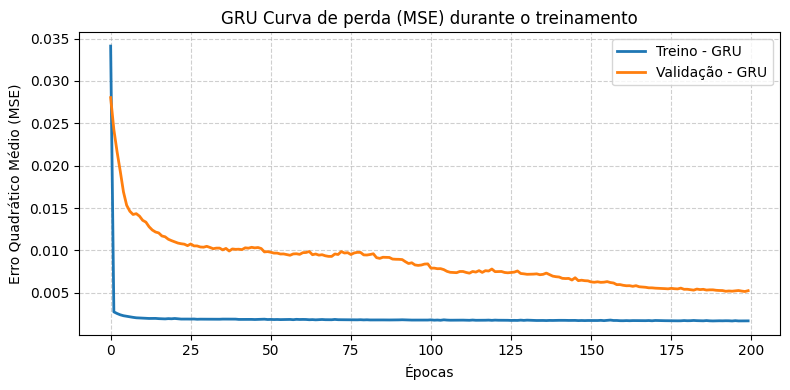

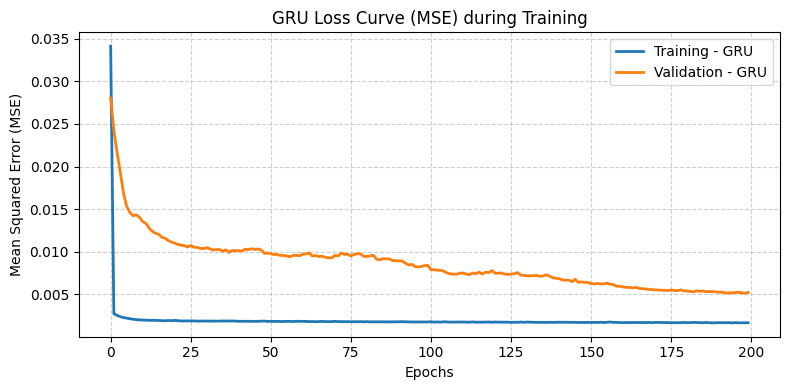

In [ ]:
# ============================================================
#  ✅ CURVA DE PERDA
# ============================================================
plt.figure(figsize=(8, 4))

plt.plot(train_losses_gru, label='Treino - GRU', linewidth=2)
plt.plot(test_losses_gru, label='Validação - GRU', linewidth=2)

plt.title("GRU Curva de perda (MSE) durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("Erro Quadrático Médio (MSE)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("gru_loss-pt.png", dpi=300, bbox_inches="tight")
plt.show()



###################
plt.figure(figsize=(8, 4))

plt.plot(train_losses_gru, label='Training - GRU', linewidth=2)
plt.plot(test_losses_gru, label='Validation - GRU', linewidth=2)

plt.title("GRU Loss Curve (MSE) during Training")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("gru_loss-en.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ============================================================
#  ✅ GRU AVALIAÇÃO TREINO vs VALIDAÇÃO
# ============================================================
def inverse_transform_and_eval_gru(X_t, y_t):
    y_pred = model_gru.predict(X_t, verbose=0)
    y_t_inv = scaler.inverse_transform(y_t.reshape(-1,1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred).flatten()
    mse = mean_squared_error(y_t_inv, y_pred_inv)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_t_inv, y_pred_inv)
    return y_t_inv, y_pred_inv, mse, rmse, r2

y_train_inv_gru, y_pred_train_inv_gru, mse_train_gru, rmse_train_gru, r2_train_gru = inverse_transform_and_eval_gru(X_train_gru, y_train_gru)
y_test_inv_gru, y_pred_inv_gru, mse_test_gru, rmse_test_gru, r2_test_gru = inverse_transform_and_eval_gru(X_test_gru, y_test_gru)

print("\n📊 GRU Comparação Treino vs Validação:")
print(f"{'Métrica':<10} | {'Treino':>15} | {'Validação':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_train_gru:>15.4e} | {mse_test_gru:>15.4e}")
print(f"{'RMSE':<10} | {rmse_train_gru:>15.4e} | {rmse_test_gru:>15.4e}")
print(f"{'R²':<10} | {r2_train_gru:>15.4f} | {r2_test_gru:>15.4f}")
print(f"Window    = {BEST_WINDOW_GRU:}")
print(f"Batch     = {BATCH_SIZE_GRU:}")

print("\n📊 GRU Train vs Validation Comparison:")
print(f"{'Metric':<10} | {'Train':>15} | {'Validation':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_train_gru:>15.4e} | {mse_test_gru:>15.4e}")
print(f"{'RMSE':<10} | {rmse_train_gru:>15.4e} | {rmse_test_gru:>15.4e}")
print(f"{'R²':<10} | {r2_train_gru:>15.4f} | {r2_test_gru:>15.4f}")
print(f"Window    = {BEST_WINDOW_GRU:}")
print(f"Batch     = {BATCH_SIZE_GRU:}")



📊 GRU Comparação Treino vs Validação:
Métrica    |          Treino |       Validação
---------------------------------------------
MSE        |      2.4900e+21 |      8.3929e+21
RMSE       |      4.9900e+10 |      9.1613e+10
R²         |          0.0354 |          0.1335
Window    = 24
Batch     = 64

📊 GRU Train vs Validation Comparison:
Metric     |           Train |      Validation
---------------------------------------------
MSE        |      2.4900e+21 |      8.3929e+21
RMSE       |      4.9900e+10 |      9.1613e+10
R²         |          0.0354 |          0.1335
Window    = 24
Batch     = 64


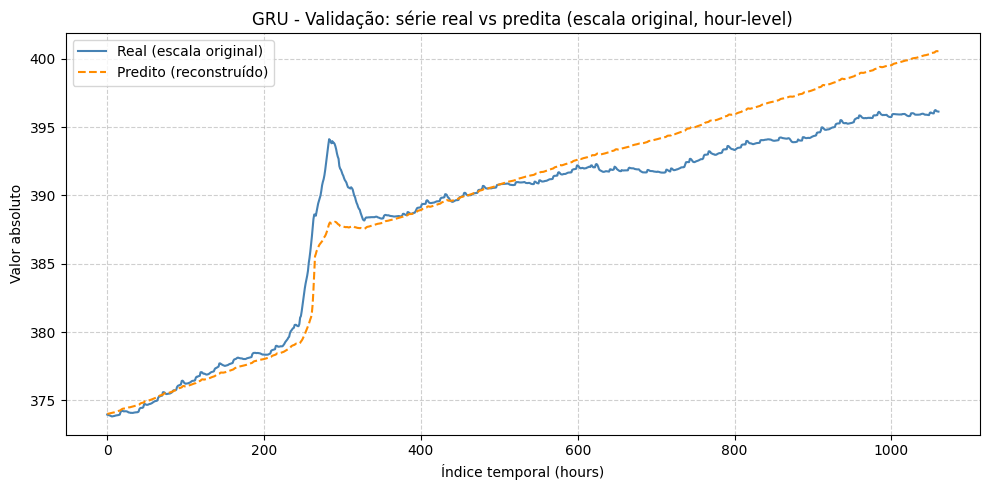

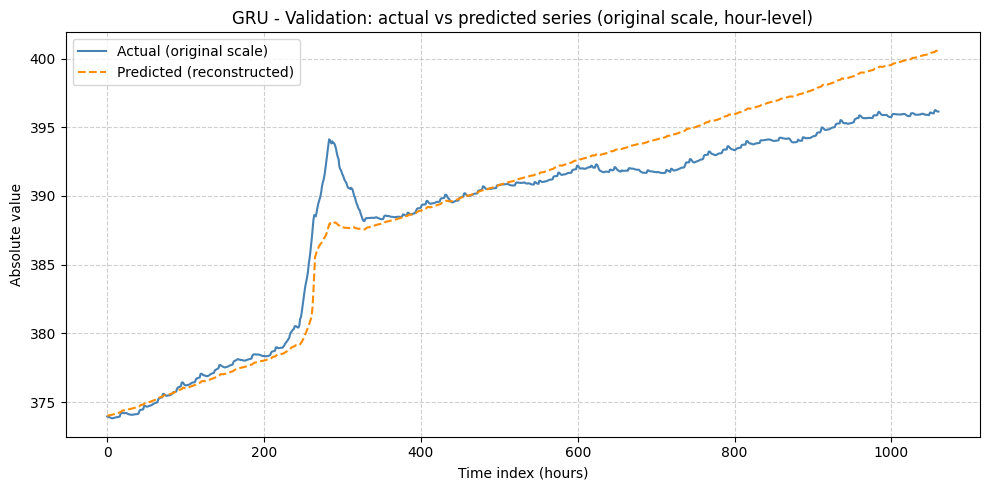


📊 GRU - Métricas em escala ABSOLUTA (reconstruída):
MSE(abs)  = 4.9153e+24
RMSE(abs) = 2.2171e+12
R²(abs)   = 0.8975
Window    = 24
Batch     = 64

📊 GRU - Metrics in ABSOLUTE scale (reconstructed):
MSE(abs)  = 4.9153e+24
RMSE(abs) = 2.2171e+12
R²(abs)   = 0.8975
Window    = 24
Batch     = 64


In [ ]:
# ============================================================
#  ✅ GRU - RECONSTRUÇÃO EM ESCALA ABSOLUTA (VALIDAÇÃO)
# ============================================================
# y_test_inv e y_pred_inv já são ΔValue na escala original
# (vieram de inverse_transform_and_eval)

base_value = series[split + BEST_WINDOW_GRU - 1]

# reconstrói série absoluta acumulando os deltas
y_pred_abs_gru = base_value + np.cumsum(y_pred_inv_gru)
y_test_abs_gru = base_value + np.cumsum(y_test_inv_gru)

y_pred_abs_gru_tb = y_pred_abs_gru / 1e12
y_test_abs_gru_tb = y_test_abs_gru / 1e12

# Plot validation in absolute scale (consistent with main graph)
plt.figure(figsize=(10,5))
plt.plot(y_test_abs_gru_tb, label="Real (escala original)", color='steelblue')
plt.plot(y_pred_abs_gru_tb, label="Predito (reconstruído)", color='darkorange', linestyle='--')
plt.title(f"GRU - Validação: série real vs predita (escala original, {time_unit}-level)")
plt.xlabel(f"Índice temporal ({time_unit}s)")
plt.ylabel("Valor absoluto")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("gru_val_real_vs_pred-pt.png", dpi=300, bbox_inches="tight")
plt.show()


# Plot validation in absolute scale (consistent with the main graph)
plt.figure(figsize=(10,5))
plt.plot(y_test_abs_gru_tb, label="Actual (original scale)", color='steelblue')
plt.plot(y_pred_abs_gru_tb, label="Predicted (reconstructed)", color='darkorange', linestyle='--')
plt.title(f"GRU - Validation: actual vs predicted series (original scale, {time_unit}-level)")
plt.xlabel(f"Time index ({time_unit}s)")
plt.ylabel("Absolute value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("gru_val_real_vs_pred-en.png", dpi=300, bbox_inches="tight")
plt.show()

# métricas também em escala absoluta (opcional)
mse_abs_gru  = mean_squared_error(y_test_abs_gru, y_pred_abs_gru)
rmse_abs_gru = math.sqrt(mse_abs_gru)
r2_abs_gru   = r2_score(y_test_abs_gru, y_pred_abs_gru)

print("\n📊 GRU - Métricas em escala ABSOLUTA (reconstruída):")
print(f"MSE(abs)  = {mse_abs_gru:,.4e}")
print(f"RMSE(abs) = {rmse_abs_gru:,.4e}")
print(f"R²(abs)   = {r2_abs_gru:.4f}")
print(f"Window    = {BEST_WINDOW_GRU:}")
print(f"Batch     = {BATCH_SIZE_GRU:}")

print("\n📊 GRU - Metrics in ABSOLUTE scale (reconstructed):")
print(f"MSE(abs)  = {mse_abs_gru:,.4e}")
print(f"RMSE(abs) = {rmse_abs_gru:,.4e}")
print(f"R²(abs)   = {r2_abs_gru:.4f}")
print(f"Window    = {BEST_WINDOW_GRU:}")
print(f"Batch     = {BATCH_SIZE_GRU:}")


📊 GRU - Forecast (em TB):
Passo 001: 396.185 TB
Passo 002: 396.224 TB
Passo 003: 396.248 TB
Passo 004: 396.264 TB
Passo 005: 396.279 TB
Passo 006: 396.295 TB
Passo 007: 396.316 TB
Passo 008: 396.339 TB
Passo 009: 396.362 TB
Passo 010: 396.384 TB
Passo 011: 396.405 TB
Passo 012: 396.426 TB
Passo 013: 396.446 TB
Passo 014: 396.465 TB
Passo 015: 396.485 TB
Passo 016: 396.506 TB
Passo 017: 396.526 TB
Passo 018: 396.546 TB
Passo 019: 396.567 TB
Passo 020: 396.588 TB
Passo 021: 396.609 TB
Passo 022: 396.630 TB
Passo 023: 396.650 TB
Passo 024: 396.671 TB
Passo 025: 396.692 TB
Passo 026: 396.713 TB
Passo 027: 396.734 TB
Passo 028: 396.755 TB
Passo 029: 396.776 TB
Passo 030: 396.797 TB
Passo 031: 396.818 TB
Passo 032: 396.840 TB
Passo 033: 396.861 TB
Passo 034: 396.882 TB
Passo 035: 396.903 TB
Passo 036: 396.924 TB
Passo 037: 396.945 TB
Passo 038: 396.966 TB
Passo 039: 396.987 TB
Passo 040: 397.008 TB
Passo 041: 397.029 TB
Passo 042: 397.050 TB
Passo 043: 397.071 TB
Passo 044: 397.092 TB
Passo

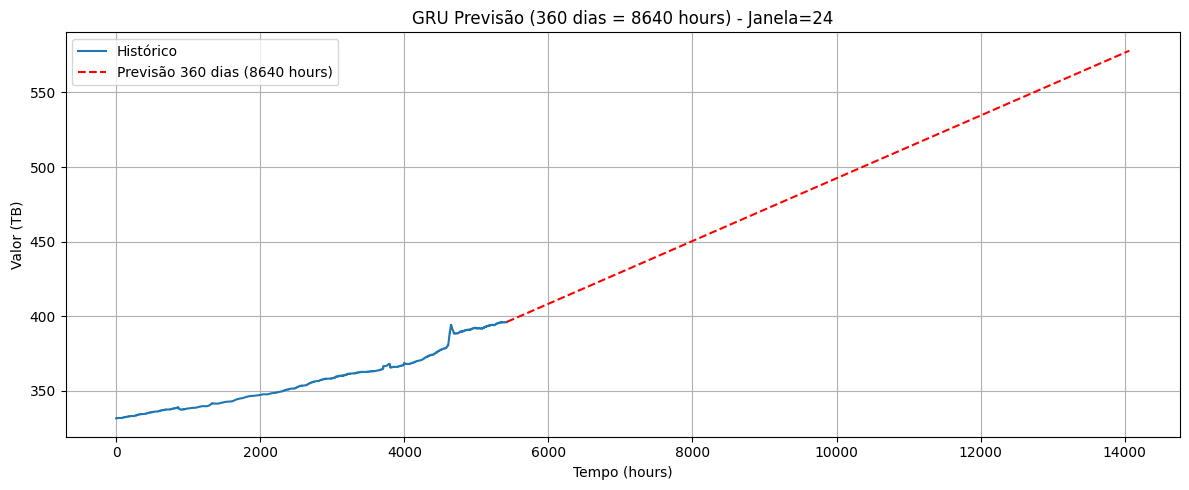

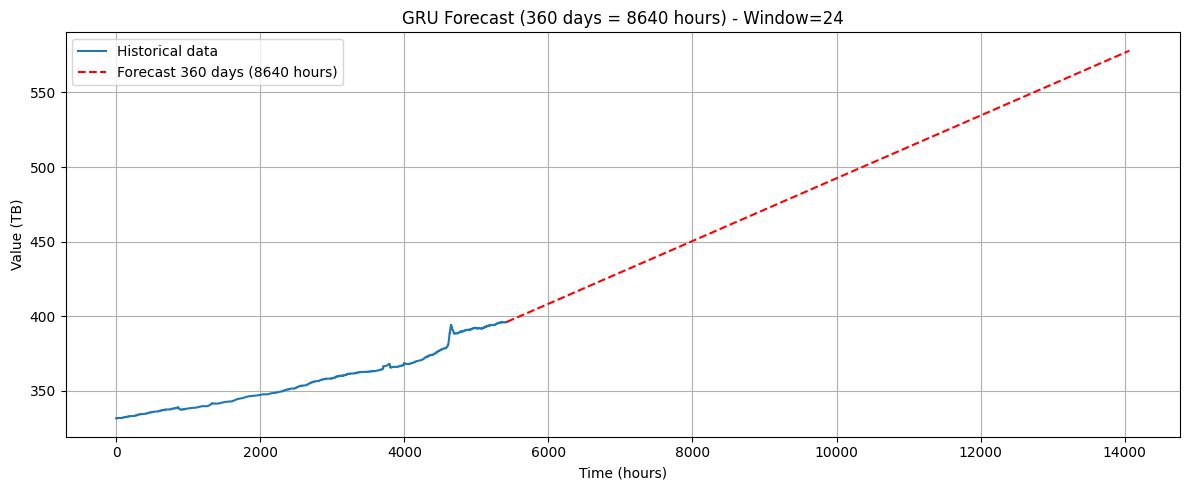

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# garante float32 desde o começo
diff_norm32_gru = np.asarray(diff_norm, dtype=np.float32)
last_window_gru = diff_norm32_gru[-BEST_WINDOW_GRU:].reshape(1, BEST_WINDOW_GRU, 1)  # (1,24,1) float32

forecast_diffs_gru = []

for _ in range(FORECAST_STEPS):
    # cria Tensor e fixa shape (elimina "unknown rank")
    x = tf.convert_to_tensor(last_window_gru, dtype=tf.float32)
    x = tf.ensure_shape(x, (1, BEST_WINDOW_GRU, 1))

    # CHAMA O MODELO DIRETO (sem predict)
    y = model_gru(x, training=False)          # Tensor (1,1)
    yhat = float(y.numpy().reshape(-1)[0])    # escalar

    forecast_diffs_gru.append(yhat)

    # desliza janela mantendo float32
    last_window_gru = np.concatenate(
        [last_window_gru[:, 1:, :],
         np.array(yhat, dtype=np.float32).reshape(1, 1, 1)],
        axis=1
    ).astype(np.float32)

forecast_diffs_inv_gru = scaler.inverse_transform(np.array(forecast_diffs_gru, dtype=np.float32).reshape(-1, 1)).ravel()
forecast_abs_gru = series[-1] + np.cumsum(forecast_diffs_inv_gru)

# TB (decimal). Se quiser TiB: /(1024**4)
series_tb = np.asarray(series, dtype=np.float64) / 1e12
forecast_tb_gru = np.asarray(forecast_abs_gru, dtype=np.float64) / 1e12

print("\n📊 GRU - Forecast (em TB):")
for i, val in enumerate(forecast_tb_gru, start=1):
    print(f"Passo {i:03d}: {val:.3f} TB")

print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_tb_gru[-1]:.3f} TB")

# eixo x
x_hist = np.arange(len(series_tb))
x_fore_gru = np.arange(len(series_tb), len(series_tb) + FORECAST_STEPS)

# gráfico em português
plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tb, label="Histórico")
plt.plot(
    x_fore_gru,
    forecast_tb_gru,
    "r--",
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"GRU Previsão ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Janela={BEST_WINDOW_GRU}")
plt.xlabel(f"Tempo ({time_unit}s)")
plt.ylabel("Valor (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gru_forecast-pt.png", dpi=300, bbox_inches="tight")
plt.show()

# gráfico em inglês
plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tb, label="Historical data")
plt.plot(
    x_fore_gru,
    forecast_tb_gru,
    "r--",
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"GRU Forecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_GRU}")
plt.xlabel(f"Time ({time_unit}s)")
plt.ylabel("Value (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gru_forecast-en.png", dpi=300, bbox_inches="tight")
plt.show()


📊 GRU - Forecast (em TB):
Passo 001: 396.185 TB
Passo 002: 396.224 TB
Passo 003: 396.248 TB
Passo 004: 396.264 TB
Passo 005: 396.279 TB
Passo 006: 396.295 TB
Passo 007: 396.316 TB
Passo 008: 396.339 TB
Passo 009: 396.362 TB
Passo 010: 396.384 TB
Passo 011: 396.405 TB
Passo 012: 396.426 TB
Passo 013: 396.446 TB
Passo 014: 396.465 TB
Passo 015: 396.485 TB
Passo 016: 396.506 TB
Passo 017: 396.526 TB
Passo 018: 396.546 TB
Passo 019: 396.567 TB
Passo 020: 396.588 TB
Passo 021: 396.609 TB
Passo 022: 396.630 TB
Passo 023: 396.650 TB
Passo 024: 396.671 TB
Passo 025: 396.692 TB
Passo 026: 396.713 TB
Passo 027: 396.734 TB
Passo 028: 396.755 TB
Passo 029: 396.776 TB
Passo 030: 396.797 TB
Passo 031: 396.818 TB
Passo 032: 396.840 TB
Passo 033: 396.861 TB
Passo 034: 396.882 TB
Passo 035: 396.903 TB
Passo 036: 396.924 TB
Passo 037: 396.945 TB
Passo 038: 396.966 TB
Passo 039: 396.987 TB
Passo 040: 397.008 TB
Passo 041: 397.029 TB
Passo 042: 397.050 TB
Passo 043: 397.071 TB
Passo 044: 397.092 TB
Passo

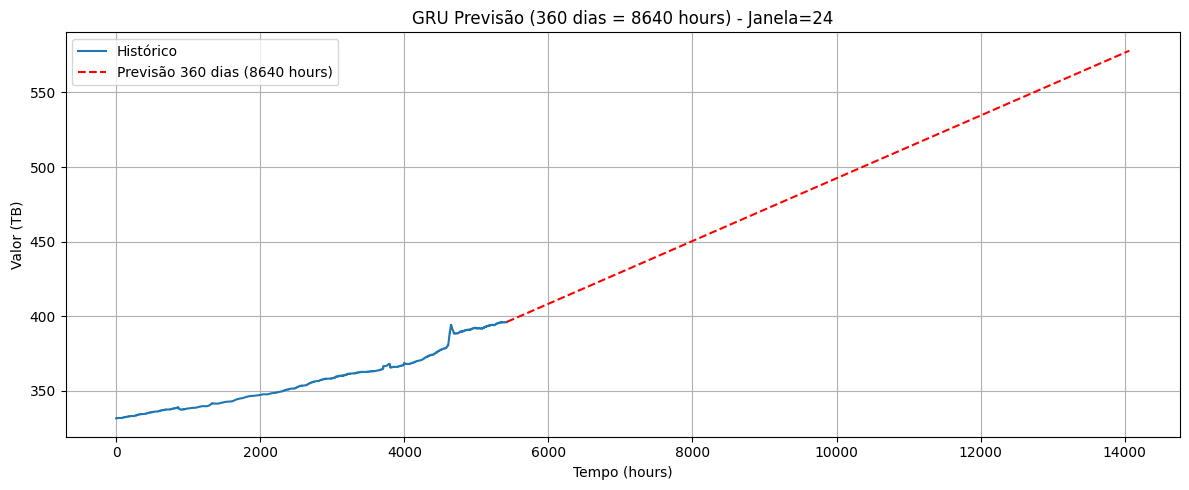

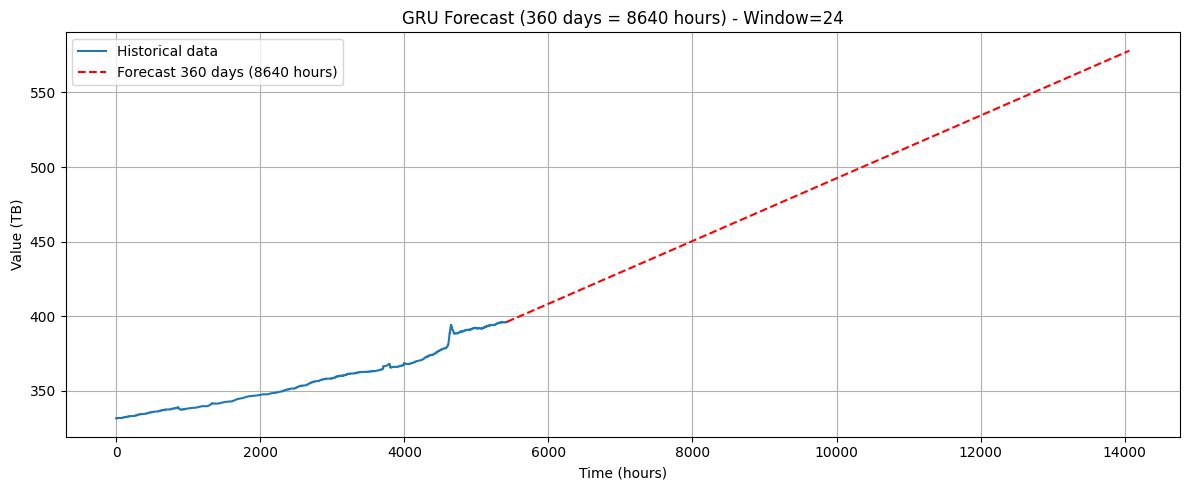

In [ ]:
# TB (decimal). Se quiser TiB: /(1024**4)
series_tb = np.asarray(series, dtype=np.float64) / 1e12
forecast_tb_gru = np.asarray(forecast_abs_gru, dtype=np.float64) / 1e12

print("\n📊 GRU - Forecast (em TB):")
for i, val in enumerate(forecast_tb_gru, start=1):
    print(f"Passo {i:03d}: {val:.3f} TB")

print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_tb_gru[-1]:.3f} TB")

# eixo x
x_hist = np.arange(len(series_tb))
x_fore_gru = np.arange(len(series_tb), len(series_tb) + FORECAST_STEPS)

# gráfico em português
plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tb, label="Histórico")
plt.plot(
    x_fore_gru,
    forecast_tb_gru,
    "r--",
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"GRU Previsão ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Janela={BEST_WINDOW_GRU}")
plt.xlabel(f"Tempo ({time_unit}s)")
plt.ylabel("Valor (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gru_forecast-pt.png", dpi=300, bbox_inches="tight")
plt.show()

# gráfico em inglês
plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tb, label="Historical data")
plt.plot(
    x_fore_gru,
    forecast_tb_gru,
    "r--",
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"GRU Forecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_GRU}")
plt.xlabel(f"Time ({time_unit}s)")
plt.ylabel("Value (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gru_forecast-en.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 💾 SAVE PIPELINE - GRU (FULL REPRODUCIBILITY)
# ============================================================

import os
import json
import shutil
import joblib
import numpy as np

# ============================================================
# 📁 BASE PATH
# ============================================================



MODEL_NAME = "gru"

if SAVE == 1:
    # ============================================================
    # 1. SAVE TRAINING HISTORY
    # ============================================================
    np.save(f"{BASE_PATH}/train_losses_{MODEL_NAME}.npy", train_losses_gru)
    np.save(f"{BASE_PATH}/val_losses_{MODEL_NAME}.npy", test_losses_gru)

    # ============================================================
    # 2. SAVE TRAINED MODEL
    # ============================================================
    model_gru.save(f"{BASE_PATH}/{MODEL_NAME}_model.keras", include_optimizer=True)

    # ============================================================
    # 3. SAVE METRICS
    # ============================================================
    metrics_gru = {
        "final_train_loss": float(train_losses_gru[-1]),
        "final_val_loss": float(test_losses_gru[-1]),

        "mse_train_diff": float(mse_train_gru),
        "rmse_train_diff": float(rmse_train_gru),
        "r2_train_diff": float(r2_train_gru),

        "mse_test_diff": float(mse_test_gru),
        "rmse_test_diff": float(rmse_test_gru),
        "r2_test_diff": float(r2_test_gru),

        "mse_abs": float(mse_abs_gru),
        "rmse_abs": float(rmse_abs_gru),
        "r2_abs": float(r2_abs_gru),

        "forecast_last_tb": float(forecast_tb_gru[-1]),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_metrics.json", "w") as f:
        json.dump(metrics_gru, f, indent=4)

    # ============================================================
    # 4. SAVE SCALER
    # ============================================================
    joblib.dump(scaler, f"{BASE_PATH}/{MODEL_NAME}_scaler.save")

    # ============================================================
    # 5. SAVE CONFIG
    # ============================================================
    config_gru = {
        "window": int(BEST_WINDOW_GRU),
        "epochs": int(EPOCHS_GRU),
        "batch_size": int(BATCH_SIZE_GRU),
        "forecast_steps": int(FORECAST_STEPS),
        "forecast_days": int(FORECAST_DAYS),
        "time_unit": str(time_unit),
        "train_size": int(train_size),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_config.json", "w") as f:
        json.dump(config_gru, f, indent=4)

    # ============================================================
    # 6. SAVE TRAIN / TEST ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/X_train_{MODEL_NAME}.npy", X_train_gru)
    np.save(f"{BASE_PATH}/y_train_{MODEL_NAME}.npy", y_train_gru)
    np.save(f"{BASE_PATH}/X_test_{MODEL_NAME}.npy", X_test_gru)
    np.save(f"{BASE_PATH}/y_test_{MODEL_NAME}.npy", y_test_gru)

    # ============================================================
    # 7. SAVE INVERSE-TRANSFORM ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/y_train_inv_{MODEL_NAME}.npy", y_train_inv_gru)
    np.save(f"{BASE_PATH}/y_pred_train_inv_{MODEL_NAME}.npy", y_pred_train_inv_gru)
    np.save(f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy", y_test_inv_gru)
    np.save(f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy", y_pred_inv_gru)

    # ============================================================
    # 8. SAVE ABSOLUTE-SCALE RECONSTRUCTION
    # ============================================================
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy", y_test_abs_gru)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy", y_pred_abs_gru)

    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy", y_test_abs_gru_tb)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy", y_pred_abs_gru_tb)

    # ============================================================
    # 9. SAVE FORECAST ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy", np.array(forecast_diffs_gru))
    np.save(f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy", forecast_diffs_inv_gru)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy", forecast_abs_gru)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}_tb.npy", forecast_tb_gru)

    # ============================================================
    # 10. SAVE RAW SERIES / PREPROCESSING REFERENCES
    # ============================================================
    np.save(f"{BASE_PATH}/series_original.npy", series)
    np.save(f"{BASE_PATH}/diff_series.npy", diff_series)
    np.save(f"{BASE_PATH}/diff_train.npy", diff_train)
    np.save(f"{BASE_PATH}/diff_test.npy", diff_test)
    np.save(f"{BASE_PATH}/diff_train_norm.npy", diff_train_norm)
    np.save(f"{BASE_PATH}/diff_test_norm.npy", diff_test_norm)

    # opcional: snapshot do forecast input
    try:
        np.save(f"{BASE_PATH}/last_window_{MODEL_NAME}.npy", last_window_gru)
    except NameError:
        pass

    # ============================================================
    # 11. SAVE RECONSTRUCTION INFO
    # ============================================================
    reconstruction_info_gru = {
        "split": int(split),
        "base_value": float(base_value),
        "series_last_value": float(series[-1]),
    }

    with open(f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json", "w") as f:
        json.dump(reconstruction_info_gru, f, indent=4)

    # ============================================================
    # 12. COPY FIGURES IF THEY EXIST
    # ============================================================
    figure_files = [
        "gru_loss-pt.png",
        "gru_loss-en.png",
        "gru_val_real_vs_pred-pt.png",
        "gru_val_real_vs_pred-en.png",
        "gru_forecast-pt.png",
        "gru_forecast-en.png",
    ]

    for fig in figure_files:
        if os.path.exists(fig):
            dest = os.path.join(BASE_PATH, fig)
            if os.path.abspath(fig) != os.path.abspath(dest):
                shutil.copy2(fig, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All GRU artifacts saved in:\n{BASE_PATH}")
    print("\nSaved:")
    print(f"- {MODEL_NAME}_model.keras")
    print(f"- {MODEL_NAME}_scaler.save")
    print(f"- {MODEL_NAME}_metrics.json")
    print(f"- {MODEL_NAME}_config.json")
    print(f"- train_losses_{MODEL_NAME}.npy")
    print(f"- val_losses_{MODEL_NAME}.npy")
    print(f"- X_train_{MODEL_NAME}.npy / y_train_{MODEL_NAME}.npy")
    print(f"- X_test_{MODEL_NAME}.npy / y_test_{MODEL_NAME}.npy")
    print(f"- y_test_abs_{MODEL_NAME}.npy / y_pred_abs_{MODEL_NAME}.npy")
    print(f"- forecast_abs_{MODEL_NAME}.npy")
    print(f"- forecast_abs_{MODEL_NAME}_tb.npy")

# PINN

In [ ]:
# ============================================================
# ✅ PINN (PINNSeq)
# ============================================================

import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, r2_score

if RELOAD == 0:
    # ------------------------------------------------------------
    # 0) Callbacks
    # FIX: save_weights_only=True avoids serialization of custom model
    # ------------------------------------------------------------
    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=15,
            min_lr=1e-7,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=30,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            "best_pint_lstm.weights.h5",
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
    ]

    # ------------------------------------------------------------
    # 1) LSTM that returns a SEQUENCE (B, T, 1)
    # ------------------------------------------------------------
    def build_lstm_pint_seq(window: int) -> tf.keras.Model:
        model = Sequential([
            Input(shape=(window, 1)),
            LSTM(64, activation="tanh", return_sequences=True),
            Dropout(0.1),
            LSTM(32, activation="tanh", return_sequences=True),
            TimeDistributed(Dense(32, activation="relu")),
            TimeDistributed(Dense(1, activation="linear")),  # (B, T, 1)
        ])
        return model

    # ------------------------------------------------------------
    # 2) PINT-style wrapper
    # ------------------------------------------------------------
    class PINNSeq(tf.keras.Model):
        def __init__(self, net: tf.keras.Model, omega: float, lambda_phys: float = 1e-3, dt: float = 1.0, **kwargs):
            super().__init__(**kwargs)
            self.net = net
            self.omega = tf.constant(omega, dtype=tf.float32)
            self.lambda_phys = tf.constant(lambda_phys, dtype=tf.float32)
            self.dt = tf.constant(dt, dtype=tf.float32)

            self.loss_tracker = tf.keras.metrics.Mean(name="loss")
            self.data_tracker = tf.keras.metrics.Mean(name="data_loss")
            self.phys_tracker = tf.keras.metrics.Mean(name="phys_loss")

        @property
        def metrics(self):
            return [self.loss_tracker, self.data_tracker, self.phys_tracker]

        def call(self, x, training=False):
            return self.net(x, training=training)

        def _d2_dt2(self, u):
            # u: (B, T, 1) -> centered 2nd derivative (B, T-2, 1)
            u_tm1 = u[:, :-2, :]
            u_t   = u[:, 1:-1, :]
            u_tp1 = u[:, 2:, :]
            return (u_tp1 - 2.0 * u_t + u_tm1) / (self.dt ** 2)

        def train_step(self, data):
            x, y_true = data  # y_true shape (B,1)
            with tf.GradientTape() as tape:
                y_pred_seq = self(x, training=True)   # (B,T,1)
                y_last = y_pred_seq[:, -1, :]         # (B,1)

                data_loss = tf.reduce_mean(tf.square(y_true - y_last))

                u_mid = y_pred_seq[:, 1:-1, :]
                u_dd = self._d2_dt2(y_pred_seq)
                resid = u_dd + (self.omega ** 2) * u_mid
                phys_loss = tf.reduce_mean(tf.square(resid))

                loss = data_loss + self.lambda_phys * phys_loss

            grads = tape.gradient(loss, self.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

            self.loss_tracker.update_state(loss)
            self.data_tracker.update_state(data_loss)
            self.phys_tracker.update_state(phys_loss)

            return {m.name: m.result() for m in self.metrics}

        def test_step(self, data):
            x, y_true = data
            y_pred_seq = self(x, training=False)
            y_last = y_pred_seq[:, -1, :]

            data_loss = tf.reduce_mean(tf.square(y_true - y_last))

            u_mid = y_pred_seq[:, 1:-1, :]
            u_dd = self._d2_dt2(y_pred_seq)
            resid = u_dd + (self.omega ** 2) * u_mid
            phys_loss = tf.reduce_mean(tf.square(resid))

            loss = data_loss + self.lambda_phys * phys_loss

            self.loss_tracker.update_state(loss)
            self.data_tracker.update_state(data_loss)
            self.phys_tracker.update_state(phys_loss)

            return {m.name: m.result() for m in self.metrics}

    # ------------------------------------------------------------
    # 3) Helper
    # ------------------------------------------------------------
    def inverse_transform_and_eval(y_true_scaled, y_pred_scaled, scaler):
        y_true_scaled = np.asarray(y_true_scaled).reshape(-1, 1)
        y_pred_scaled = np.asarray(y_pred_scaled).reshape(-1, 1)

        y_true_inv = scaler.inverse_transform(y_true_scaled).ravel()
        y_pred_inv = scaler.inverse_transform(y_pred_scaled).ravel()
        return y_true_inv, y_pred_inv

    # ------------------------------------------------------------
    # 4) Choose omega
    # ------------------------------------------------------------
    T = 24
    omega = 2.0 * math.pi / T

    # ------------------------------------------------------------
    # 5) Train PINN model
    # FIX: validation_data must match the PINT window/dataset
    # ------------------------------------------------------------
    with tf.device(device):
        net = build_lstm_pint_seq(BEST_WINDOW_PINT)
        model_pinn = PINNSeq(net, omega=omega, lambda_phys=1e-3, dt=1.0)
        model_pinn.compile(optimizer=Adam(1e-4, clipnorm=1.0))

        hist = model_pinn.fit(
            X_train_pint, y_train_pint,
            validation_data=(X_test_pint, y_test_pint),
            epochs=EPOCHS_PINT,
            batch_size=BATCH_SIZE_PINT,
            callbacks=callbacks,
            shuffle=False,
            verbose=1
        )

    # optional: reload best weights explicitly
    model_pinn.load_weights("best_pint_lstm.weights.h5")





In [27]:
# ============================================================
# 🔄 RELOAD EVERYTHING - PINN / PINNSeq
# ============================================================

import os
import json
import math
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.optimizers import Adam

if RELOAD == 1:
    # ============================================================
    # 📁 BASE PATH
    # ============================================================

    MODEL_NAME = "pint"

    # ============================================================
    # 1) REBUILD ARCHITECTURE
    # ============================================================
    def build_lstm_pint_seq(window: int) -> tf.keras.Model:
        model = Sequential([
            Input(shape=(window, 1)),
            LSTM(64, activation="tanh", return_sequences=True),
            Dropout(0.1),
            LSTM(32, activation="tanh", return_sequences=True),
            TimeDistributed(Dense(32, activation="relu")),
            TimeDistributed(Dense(1, activation="linear")),
        ])
        return model

    class PINNSeq(tf.keras.Model):
        def __init__(self, net: tf.keras.Model, omega: float, lambda_phys: float = 1e-3, dt: float = 1.0, **kwargs):
            super().__init__(**kwargs)
            self.net = net
            self.omega = tf.constant(omega, dtype=tf.float32)
            self.lambda_phys = tf.constant(lambda_phys, dtype=tf.float32)
            self.dt = tf.constant(dt, dtype=tf.float32)

            self.loss_tracker = tf.keras.metrics.Mean(name="loss")
            self.data_tracker = tf.keras.metrics.Mean(name="data_loss")
            self.phys_tracker = tf.keras.metrics.Mean(name="phys_loss")

        @property
        def metrics(self):
            return [self.loss_tracker, self.data_tracker, self.phys_tracker]

        def call(self, x, training=False):
            return self.net(x, training=training)

        def _d2_dt2(self, u):
            u_tm1 = u[:, :-2, :]
            u_t   = u[:, 1:-1, :]
            u_tp1 = u[:, 2:, :]
            return (u_tp1 - 2.0 * u_t + u_tm1) / (self.dt ** 2)

        def train_step(self, data):
            x, y_true = data
            with tf.GradientTape() as tape:
                y_pred_seq = self(x, training=True)
                y_last = y_pred_seq[:, -1, :]

                data_loss = tf.reduce_mean(tf.square(y_true - y_last))
                u_mid = y_pred_seq[:, 1:-1, :]
                u_dd = self._d2_dt2(y_pred_seq)
                resid = u_dd + (self.omega ** 2) * u_mid
                phys_loss = tf.reduce_mean(tf.square(resid))
                loss = data_loss + self.lambda_phys * phys_loss

            grads = tape.gradient(loss, self.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

            self.loss_tracker.update_state(loss)
            self.data_tracker.update_state(data_loss)
            self.phys_tracker.update_state(phys_loss)
            return {m.name: m.result() for m in self.metrics}

        def test_step(self, data):
            x, y_true = data
            y_pred_seq = self(x, training=False)
            y_last = y_pred_seq[:, -1, :]

            data_loss = tf.reduce_mean(tf.square(y_true - y_last))
            u_mid = y_pred_seq[:, 1:-1, :]
            u_dd = self._d2_dt2(y_pred_seq)
            resid = u_dd + (self.omega ** 2) * u_mid
            phys_loss = tf.reduce_mean(tf.square(resid))
            loss = data_loss + self.lambda_phys * phys_loss

            self.loss_tracker.update_state(loss)
            self.data_tracker.update_state(data_loss)
            self.phys_tracker.update_state(phys_loss)
            return {m.name: m.result() for m in self.metrics}

    # ============================================================
    # 2) FILE PATHS
    # ============================================================
    FILE_WEIGHTS            = f"{BASE_PATH}/{MODEL_NAME}_model.weights.h5"
    FILE_SCALER             = f"{BASE_PATH}/{MODEL_NAME}_scaler.save"
    FILE_CONFIG             = f"{BASE_PATH}/{MODEL_NAME}_config.json"
    FILE_METRICS            = f"{BASE_PATH}/{MODEL_NAME}_metrics.json"

    FILE_LOSS               = f"{BASE_PATH}/{MODEL_NAME}_loss.npy"
    FILE_VAL_LOSS           = f"{BASE_PATH}/{MODEL_NAME}_val_loss.npy"
    FILE_DATA_LOSS          = f"{BASE_PATH}/{MODEL_NAME}_data_loss.npy"
    FILE_VAL_DATA_LOSS      = f"{BASE_PATH}/{MODEL_NAME}_val_data_loss.npy"
    FILE_PHYS_LOSS          = f"{BASE_PATH}/{MODEL_NAME}_phys_loss.npy"
    FILE_VAL_PHYS_LOSS      = f"{BASE_PATH}/{MODEL_NAME}_val_phys_loss.npy"

    FILE_X_TRAIN            = f"{BASE_PATH}/X_train_{MODEL_NAME}.npy"
    FILE_Y_TRAIN            = f"{BASE_PATH}/y_train_{MODEL_NAME}.npy"
    FILE_X_TEST             = f"{BASE_PATH}/X_test_{MODEL_NAME}.npy"
    FILE_Y_TEST             = f"{BASE_PATH}/y_test_{MODEL_NAME}.npy"

    FILE_Y_PRED_TRAIN_SEQ   = f"{BASE_PATH}/y_pred_train_seq_{MODEL_NAME}.npy"
    FILE_Y_PRED_TRAIN       = f"{BASE_PATH}/y_pred_train_{MODEL_NAME}.npy"
    FILE_Y_PRED_TEST_SEQ    = f"{BASE_PATH}/y_pred_test_seq_{MODEL_NAME}.npy"
    FILE_Y_PRED_TEST        = f"{BASE_PATH}/y_pred_test_{MODEL_NAME}.npy"

    FILE_Y_TEST_INV         = f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_INV         = f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy"

    FILE_Y_TEST_ABS         = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy"
    FILE_Y_PRED_ABS         = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy"
    FILE_Y_TEST_ABS_TB      = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy"
    FILE_Y_PRED_ABS_TB      = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy"

    FILE_FORECAST_DIFFS     = f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy"
    FILE_FORECAST_DIFFS_INV = f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS       = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy"
    FILE_FORECAST_TB        = f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy"

    FILE_SERIES             = f"{BASE_PATH}/series_original.npy"
    FILE_DIFF_SERIES        = f"{BASE_PATH}/diff_series.npy"
    FILE_DIFF_TRAIN         = f"{BASE_PATH}/diff_train.npy"
    FILE_DIFF_TEST          = f"{BASE_PATH}/diff_test.npy"
    FILE_DIFF_TRAIN_NORM    = f"{BASE_PATH}/diff_train_norm.npy"
    FILE_DIFF_TEST_NORM     = f"{BASE_PATH}/diff_test_norm.npy"

    FILE_LAST_WINDOW        = f"{BASE_PATH}/last_window_{MODEL_NAME}.npy"
    FILE_RECON_INFO         = f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json"

    # ============================================================
    # 3) LOAD CONFIG / METRICS / SCALER
    # ============================================================
    with open(FILE_CONFIG, "r") as f:
        config_pint = json.load(f)

    with open(FILE_METRICS, "r") as f:
        metrics_pint = json.load(f)

    scaler = joblib.load(FILE_SCALER)

    BEST_WINDOW_PINT = config_pint["window"]
    EPOCHS_PINT      = config_pint["epochs"]
    BATCH_SIZE_PINT  = config_pint["batch_size"]
    omega            = config_pint["omega"]
    lambda_phys      = config_pint["lambda_phys"]
    dt               = config_pint["dt"]
    FORECAST_STEPS   = config_pint["forecast_steps"]
    FORECAST_DAYS    = config_pint["forecast_days"]
    time_unit        = config_pint["time_unit"]
    split            = config_pint["train_size"]

    # ============================================================
    # 4) REBUILD MODEL AND LOAD WEIGHTS
    # ============================================================
    net = build_lstm_pint_seq(BEST_WINDOW_PINT)
    model_pinn = PINNSeq(net, omega=omega, lambda_phys=lambda_phys, dt=dt)
    model_pinn.compile(optimizer=Adam(1e-4, clipnorm=1.0))

    dummy_x = np.zeros((1, BEST_WINDOW_PINT, 1), dtype=np.float32)
    _ = model_pinn(dummy_x, training=False)

    model_pinn.load_weights(FILE_WEIGHTS)

    # ============================================================
    # 5) LOAD TRAINING HISTORY
    # ============================================================
    loss_pint = np.load(FILE_LOSS)
    val_loss_pint = np.load(FILE_VAL_LOSS)
    data_loss_pint = np.load(FILE_DATA_LOSS)
    val_data_loss_pint = np.load(FILE_VAL_DATA_LOSS)
    phys_loss_pint = np.load(FILE_PHYS_LOSS)
    val_phys_loss_pint = np.load(FILE_VAL_PHYS_LOSS)

    # ============================================================
    # 6) LOAD DATA ARRAYS
    # ============================================================
    X_train_pint = np.load(FILE_X_TRAIN)
    y_train_pint = np.load(FILE_Y_TRAIN)
    X_test_pint  = np.load(FILE_X_TEST)
    y_test_pint  = np.load(FILE_Y_TEST)

    y_pred_train_seq_pint = np.load(FILE_Y_PRED_TRAIN_SEQ)
    y_pred_train_pint     = np.load(FILE_Y_PRED_TRAIN)
    y_pred_test_seq_pint  = np.load(FILE_Y_PRED_TEST_SEQ)
    y_pred_test_pint      = np.load(FILE_Y_PRED_TEST)

    y_test_inv_pint = np.load(FILE_Y_TEST_INV)
    y_pred_inv_pint = np.load(FILE_Y_PRED_INV)

    y_test_abs_pint = np.load(FILE_Y_TEST_ABS)
    y_pred_abs_pint = np.load(FILE_Y_PRED_ABS)
    y_test_abs_pint_tb = np.load(FILE_Y_TEST_ABS_TB)
    y_pred_abs_pint_tb = np.load(FILE_Y_PRED_ABS_TB)

    forecast_diffs_pint     = np.load(FILE_FORECAST_DIFFS)
    forecast_diffs_inv_pint = np.load(FILE_FORECAST_DIFFS_INV)
    forecast_abs_pint       = np.load(FILE_FORECAST_ABS)
    forecast_tb_pint        = np.load(FILE_FORECAST_TB)

    series          = np.load(FILE_SERIES)
    diff_series     = np.load(FILE_DIFF_SERIES)
    diff_train      = np.load(FILE_DIFF_TRAIN)
    diff_test       = np.load(FILE_DIFF_TEST)
    diff_train_norm = np.load(FILE_DIFF_TRAIN_NORM)
    diff_test_norm  = np.load(FILE_DIFF_TEST_NORM)

    last_window_pint = None
    if os.path.exists(FILE_LAST_WINDOW):
        last_window_pint = np.load(FILE_LAST_WINDOW)

    with open(FILE_RECON_INFO, "r") as f:
        reconstruction_info_pint = json.load(f)

    base_value = reconstruction_info_pint["base_value"]
    series_last_value = reconstruction_info_pint["series_last_value"]

    # ============================================================
    # 7) OPTIONAL RECOMPUTE
    # ============================================================
    y_pred_test_seq_pint_recomputed = model_pinn.predict(X_test_pint, batch_size=BATCH_SIZE_PINT, verbose=0)
    y_pred_test_pint_recomputed = y_pred_test_seq_pint_recomputed[:, -1, 0]

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print("\n✅ RELOAD EVERYTHING - PINT COMPLETED")
    print(f"Base path              : {BASE_PATH}")
    print(f"Model                  : {MODEL_NAME}")
    print(f"Window                 : {BEST_WINDOW_PINT}")
    print(f"Epochs                 : {EPOCHS_PINT}")
    print(f"Batch size             : {BATCH_SIZE_PINT}")
    print(f"Forecast steps         : {FORECAST_STEPS}")
    print(f"Forecast days          : {FORECAST_DAYS}")
    print(f"Time unit              : {time_unit}")
    print(f"Omega                  : {omega}")
    print(f"Lambda phys            : {lambda_phys}")
    print(f"dt                     : {dt}")

    print("\n📊 Metrics")
    print(f"Final loss             : {metrics_pint['final_loss']:.6f}")
    print(f"Best val loss          : {metrics_pint['best_val_loss']:.6f}")
    print(f"MSE train scaled       : {metrics_pint['mse_train_scaled']:.6e}")
    print(f"RMSE train scaled      : {metrics_pint['rmse_train_scaled']:.6e}")
    print(f"R² train scaled        : {metrics_pint['r2_train_scaled']:.6f}")
    print(f"MSE test scaled        : {metrics_pint['mse_test_scaled']:.6e}")
    print(f"RMSE test scaled       : {metrics_pint['rmse_test_scaled']:.6e}")
    print(f"R² test scaled         : {metrics_pint['r2_test_scaled']:.6f}")
    print(f"MSE abs                : {metrics_pint['mse_abs']:.6e}")
    print(f"RMSE abs               : {metrics_pint['rmse_abs']:.6e}")
    print(f"R² abs                 : {metrics_pint['r2_abs']:.6f}")
    print(f"Final forecast TB      : {metrics_pint['forecast_last_tb']:.3f}")

    print("\n📐 Shapes")
    print(f"X_train_pint           : {X_train_pint.shape}")
    print(f"y_train_pint           : {y_train_pint.shape}")
    print(f"X_test_pint            : {X_test_pint.shape}")
    print(f"y_test_pint            : {y_test_pint.shape}")
    print(f"y_pred_test_seq_pint   : {y_pred_test_seq_pint.shape}")
    print(f"y_test_abs_pint        : {y_test_abs_pint.shape}")
    print(f"forecast_tb_pint       : {forecast_tb_pint.shape}")

    # ============================================================
    # ✅ PACKAGE EVERYTHING
    # ============================================================
    artifacts_pint = {
        "model_pinn": model_pinn,
        "scaler": scaler,
        "config_pint": config_pint,
        "metrics_pint": metrics_pint,
        "loss_pint": loss_pint,
        "val_loss_pint": val_loss_pint,
        "data_loss_pint": data_loss_pint,
        "val_data_loss_pint": val_data_loss_pint,
        "phys_loss_pint": phys_loss_pint,
        "val_phys_loss_pint": val_phys_loss_pint,
        "X_train_pint": X_train_pint,
        "y_train_pint": y_train_pint,
        "X_test_pint": X_test_pint,
        "y_test_pint": y_test_pint,
        "y_pred_train_seq_pint": y_pred_train_seq_pint,
        "y_pred_train_pint": y_pred_train_pint,
        "y_pred_test_seq_pint": y_pred_test_seq_pint,
        "y_pred_test_pint": y_pred_test_pint,
        "y_test_inv_pint": y_test_inv_pint,
        "y_pred_inv_pint": y_pred_inv_pint,
        "y_test_abs_pint": y_test_abs_pint,
        "y_pred_abs_pint": y_pred_abs_pint,
        "y_test_abs_pint_tb": y_test_abs_pint_tb,
        "y_pred_abs_pint_tb": y_pred_abs_pint_tb,
        "forecast_diffs_pint": forecast_diffs_pint,
        "forecast_diffs_inv_pint": forecast_diffs_inv_pint,
        "forecast_abs_pint": forecast_abs_pint,
        "forecast_tb_pint": forecast_tb_pint,
        "series": series,
        "diff_series": diff_series,
        "diff_train": diff_train,
        "diff_test": diff_test,
        "diff_train_norm": diff_train_norm,
        "diff_test_norm": diff_test_norm,
        "last_window_pint": last_window_pint,
        "split": split,
        "base_value": base_value,
        "series_last_value": series_last_value,
        "y_pred_test_seq_pint_recomputed": y_pred_test_seq_pint_recomputed,
        "y_pred_test_pint_recomputed": y_pred_test_pint_recomputed,
    }

    print("\n✅ artifacts_pint dictionary created.")


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



✅ RELOAD EVERYTHING - PINT COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : pint
Window                 : 24
Epochs                 : 200
Batch size             : 64
Forecast steps         : 8640
Forecast days          : 360
Time unit              : hour
Omega                  : 0.2617993877991494
Lambda phys            : 0.0010000000474974513
dt                     : 1.0

📊 Metrics
Final loss             : 0.001558
Best val loss          : 0.004142
MSE train scaled       : 1.537801e-03
RMSE train scaled      : 3.921480e-02
R² train scaled        : -0.017232
MSE test scaled        : 4.199743e-03
RMSE test scaled       : 6.480542e-02
R² test scaled         : 0.259630
MSE abs                : 9.292338e+24
RMSE abs               : 3.048334e+12
R² abs                 : 0.806306
Final forecast TB      : 483.273

📐 Shapes
X_train_pint           : (4315, 24, 1)
y_train_pint           : (4315, 1)
X_te

In [ ]:
# ------------------------------------------------------------
# 6) Loss curves
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(hist.history["loss"], label="Treino - loss total", linewidth=2)
if "val_loss" in hist.history:
    plt.plot(hist.history["val_loss"], label="Val - loss total", linewidth=2)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("PINN - Curva de Perda total")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pinn_loss_total-pt.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist.history.get("data_loss", []), label="Treino - data_loss", linewidth=2)
if "val_data_loss" in hist.history:
    plt.plot(hist.history["val_data_loss"], label="Val - data_loss", linewidth=2)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("PINN - Curva de Perda de Dados")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pinn_data_loss-pt.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist.history.get("phys_loss", []), label="Treino - phys_loss", linewidth=2)
if "val_phys_loss" in hist.history:
    plt.plot(hist.history["val_phys_loss"], label="Val - phys_loss", linewidth=2)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("PINN - Curva de Perda Física")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pinn_phys_loss-pt.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'hist' is not defined

<Figure size 900x500 with 0 Axes>

In [ ]:
# ------------------------------------------------------------
# 6) Loss curves
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(hist.history["loss"], label="Training - total loss", linewidth=2)
if "val_loss" in hist.history:
    plt.plot(hist.history["val_loss"], label="Validation - total loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN - Total Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pinn_loss_total-en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist.history.get("data_loss", []), label="Training - data_loss", linewidth=2)
if "val_data_loss" in hist.history:
    plt.plot(hist.history["val_data_loss"], label="Validation - data_loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN - Data Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pinn_data_loss-en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist.history.get("phys_loss", []), label="Training - phys_loss", linewidth=2)
if "val_phys_loss" in hist.history:
    plt.plot(hist.history["val_phys_loss"], label="Validation - phys_loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN - Physics Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pinn_phys_loss-en.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'hist' is not defined

<Figure size 900x500 with 0 Axes>

In [ ]:
# ------------------------------------------------------------
# 7) Predict on validation
# FIX: use X_test_pint / y_test_pint / BEST_WINDOW_PINT / BATCH_SIZE_PINT
# ------------------------------------------------------------
y_pred_seq_pint = model_pinn.predict(X_test_pint, batch_size=BATCH_SIZE_PINT, verbose=0)
y_pred_delta_pint = y_pred_seq_pint[:, -1, 0]

y_test_inv_pint, y_pred_inv_pint = inverse_transform_and_eval(
    y_test_pint,
    y_pred_delta_pint,
    scaler
)

base_value = series[split + BEST_WINDOW_PINT - 1]
y_pred_abs_pint = base_value + np.cumsum(y_pred_inv_pint)
y_test_abs_pint = base_value + np.cumsum(y_test_inv_pint)

y_pred_abs_pint_tb = y_pred_abs_pint / 1e12
y_test_abs_pint_tb = y_test_abs_pint / 1e12
# ------------------------------------------------------------
# 8) Plot absolute-scale validation
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(y_test_abs_pint_tb, label="Real (escala original)")
plt.plot(y_pred_abs_pint_tb, label="Predito (reconstruído)", linestyle="--")
plt.title(f"PINN - Validação: série real vs predita (escala original, {time_unit}-level)")
plt.xlabel(f"Índice temporal ({time_unit}s)")
plt.ylabel("Valor absoluto")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pint_val_real_vs_pred-pt.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_test_abs_pint_tb, label="Actual (original scale)")
plt.plot(y_pred_abs_pint_tb, label="Predicted (reconstructed)", linestyle="--")
plt.title(f"PINN - Validation: actual vs predicted series (original scale, {time_unit}-level)")
plt.xlabel(f"Time index ({time_unit}s)")
plt.ylabel("Absolute value")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pint_val_real_vs_pred-en.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 9) Absolute-scale metrics
# ------------------------------------------------------------
mse_abs_pint = mean_squared_error(y_test_abs_pint, y_pred_abs_pint)
rmse_abs_pint = math.sqrt(mse_abs_pint)
r2_abs_pint = r2_score(y_test_abs_pint, y_pred_abs_pint)

print("\n📊 PINT - Métricas em escala ABSOLUTA (reconstruída):")
print(f"MSE(abs)  = {mse_abs_pint:,.4e}")
print(f"RMSE(abs) = {rmse_abs_pint:,.4e}")
print(f"R²(abs)   = {r2_abs_pint:.4f}")
print(f"Window    = {BEST_WINDOW_PINT}")
print(f"Batch     = {BATCH_SIZE_PINT}")
print(f"lambda    = {float(model_pinn.lambda_phys.numpy())}")
print(f"omega     = {float(model_pinn.omega.numpy())}")

print("\n📊 PINT - Metrics in ABSOLUTE scale (reconstructed):")
print(f"MSE(abs)  = {mse_abs_pint:,.4e}")
print(f"RMSE(abs) = {rmse_abs_pint:,.4e}")
print(f"R²(abs)   = {r2_abs_pint:.4f}")
print(f"Window    = {BEST_WINDOW_PINT}")
print(f"Batch     = {BATCH_SIZE_PINT}")
print(f"lambda    = {float(model_pinn.lambda_phys.numpy())}")
print(f"omega     = {float(model_pinn.omega.numpy())}")

TypeError: inverse_transform_and_eval() takes 2 positional arguments but 3 were given

In [ ]:
# ============================================================
# ✅ PINN AVALIAÇÃO TREINO vs VALIDAÇÃO
# ============================================================

def inverse_transform_and_eval_pinn(X_t, y_t):
    y_pred_seq = model_pinn.predict(
        X_t,
        batch_size=BATCH_SIZE_PINT,
        verbose=0
    )

    # PINN/PINT returns sequence output: use last time step
    y_pred_delta = y_pred_seq[:, -1, 0]

    y_t_inv = scaler.inverse_transform(
        y_t.reshape(-1, 1)
    ).flatten()

    y_pred_inv = scaler.inverse_transform(
        y_pred_delta.reshape(-1, 1)
    ).flatten()

    mse = mean_squared_error(y_t_inv, y_pred_inv)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_t_inv, y_pred_inv)

    return y_t_inv, y_pred_inv, mse, rmse, r2


y_train_inv_pint, y_pred_train_inv_pint, mse_train_pint, rmse_train_pint, r2_train_pint = inverse_transform_and_eval_pinn(
    X_train_pint,
    y_train_pint
)

y_test_inv_pint, y_pred_inv_pint, mse_test_pint, rmse_test_pint, r2_test_pint = inverse_transform_and_eval_pinn(
    X_test_pint,
    y_test_pint
)


print("\n📊 PINN Comparação Treino vs Validação:")
print(f"{'Métrica':<10} | {'Treino':>15} | {'Validação':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_train_pint:>15.4e} | {mse_test_pint:>15.4e}")
print(f"{'RMSE':<10} | {rmse_train_pint:>15.4e} | {rmse_test_pint:>15.4e}")
print(f"{'R²':<10} | {r2_train_pint:>15.4f} | {r2_test_pint:>15.4f}")
print(f"Window    = {BEST_WINDOW_PINT}")
print(f"Batch     = {BATCH_SIZE_PINT}")
print(f"lambda    = {float(model_pinn.lambda_phys.numpy())}")
print(f"omega     = {float(model_pinn.omega.numpy())}")


print("\n📊 PINN Train vs Validation Comparison:")
print(f"{'Metric':<10} | {'Train':>15} | {'Validation':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_train_pint:>15.4e} | {mse_test_pint:>15.4e}")
print(f"{'RMSE':<10} | {rmse_train_pint:>15.4e} | {rmse_test_pint:>15.4e}")
print(f"{'R²':<10} | {r2_train_pint:>15.4f} | {r2_test_pint:>15.4f}")
print(f"Window    = {BEST_WINDOW_PINT}")
print(f"Batch     = {BATCH_SIZE_PINT}")
print(f"lambda    = {float(model_pinn.lambda_phys.numpy())}")
print(f"omega     = {float(model_pinn.omega.numpy())}")


📊 PINN Comparação Treino vs Validação:
Métrica    |          Treino |       Validação
---------------------------------------------
MSE        |      2.6260e+21 |      7.1716e+21
RMSE       |      5.1244e+10 |      8.4685e+10
R²         |         -0.0172 |          0.2596
Window    = 24
Batch     = 64
lambda    = 0.0010000000474974513
omega     = 0.2617993950843811

📊 PINN Train vs Validation Comparison:
Metric     |           Train |      Validation
---------------------------------------------
MSE        |      2.6260e+21 |      7.1716e+21
RMSE       |      5.1244e+10 |      8.4685e+10
R²         |         -0.0172 |          0.2596
Window    = 24
Batch     = 64
lambda    = 0.0010000000474974513
omega     = 0.2617993950843811



📊 PINN - Forecast (em TB):
Passo 001: 396.153 TB
Passo 002: 396.183 TB
Passo 003: 396.215 TB
Passo 004: 396.250 TB
Passo 005: 396.287 TB
Passo 006: 396.324 TB
Passo 007: 396.361 TB
Passo 008: 396.398 TB
Passo 009: 396.434 TB
Passo 010: 396.471 TB
Passo 011: 396.506 TB
Passo 012: 396.542 TB
Passo 013: 396.576 TB
Passo 014: 396.610 TB
Passo 015: 396.644 TB
Passo 016: 396.677 TB
Passo 017: 396.710 TB
Passo 018: 396.742 TB
Passo 019: 396.772 TB
Passo 020: 396.802 TB
Passo 021: 396.831 TB
Passo 022: 396.859 TB
Passo 023: 396.887 TB
Passo 024: 396.915 TB
Passo 025: 396.940 TB
Passo 026: 396.966 TB
Passo 027: 396.991 TB
Passo 028: 397.016 TB
Passo 029: 397.040 TB
Passo 030: 397.064 TB
Passo 031: 397.087 TB
Passo 032: 397.110 TB
Passo 033: 397.133 TB
Passo 034: 397.155 TB
Passo 035: 397.177 TB
Passo 036: 397.198 TB
Passo 037: 397.219 TB
Passo 038: 397.240 TB
Passo 039: 397.260 TB
Passo 040: 397.280 TB
Passo 041: 397.300 TB
Passo 042: 397.319 TB
Passo 043: 397.338 TB
Passo 044: 397.357 TB
Pass

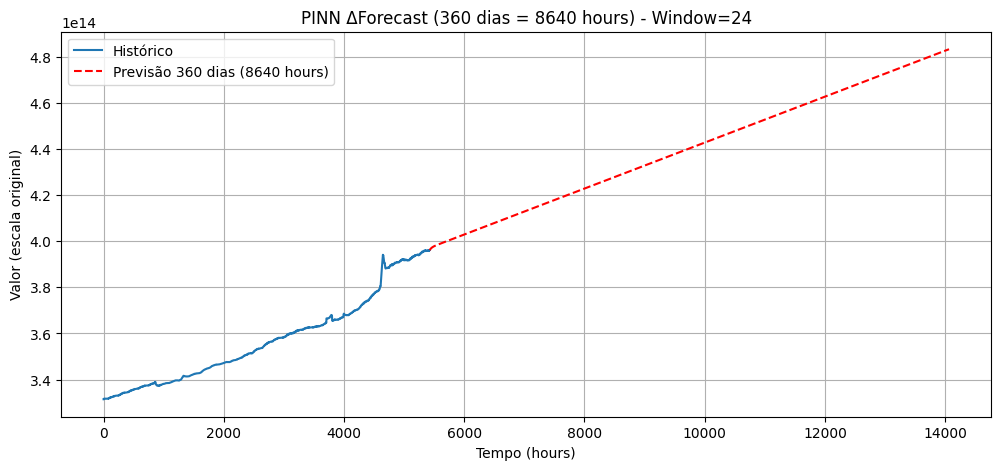

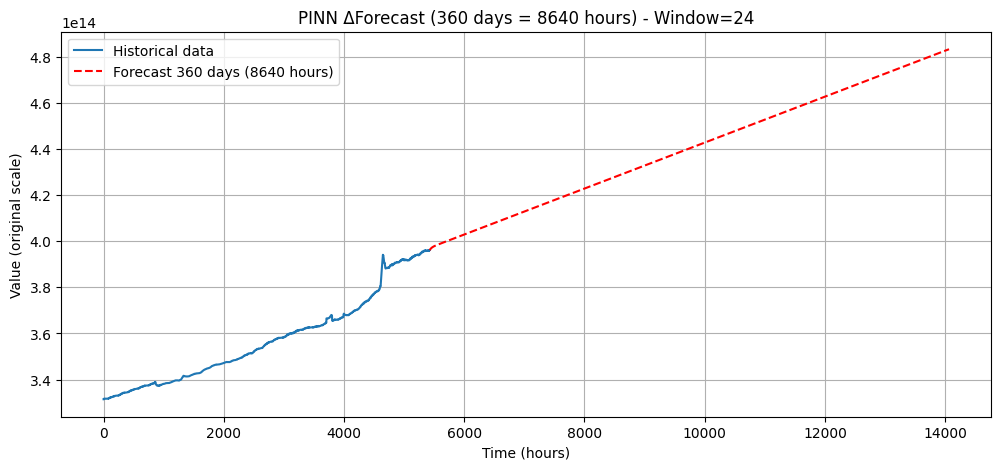

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


if RELOAD == 0:
    # ============================================================
    #  ✅ PINT (PINNSeq) - FORECAST (recursive / rolling)
    #  - entrada float32
    #  - fixa shape (evita "unknown rank")
    #  - chama o modelo direto (sem predict)
    #  - usa o ÚLTIMO delta da sequência (consistente com train_step)
    # ============================================================

    # use a base normalizada do notebook (para janela LSTM/PINT)
    diff_norm32_pint = np.asarray(diff_norm, dtype=np.float32)
    last_window_pint = diff_norm32_pint[-BEST_WINDOW_PINT:].reshape(1, BEST_WINDOW_PINT, 1)  # (1,24,1) float32

    forecast_diffs_pint = []

    for _ in range(FORECAST_STEPS):
        # cria Tensor e fixa shape
        x = tf.convert_to_tensor(last_window_pint, dtype=tf.float32)
        x = tf.ensure_shape(x, (1, BEST_WINDOW_PINT, 1))

        # CHAMA O MODELO DIRETO (sem predict)
        y_seq = model_pinn(x, training=False)          # Tensor (1, window, 1)
        yhat  = float(y_seq.numpy()[0, -1, 0])         # pega o último delta (escalar)

        forecast_diffs_pint.append(yhat)

        # desliza janela mantendo float32
        last_window_pint = np.concatenate(
            [last_window_pint[:, 1:, :],
            np.array(yhat, dtype=np.float32).reshape(1, 1, 1)],
            axis=1
        ).astype(np.float32)

    # inverte escala (mesmo scaler do notebook)
    forecast_diffs_inv_pint = scaler.inverse_transform(
        np.array(forecast_diffs_pint, dtype=np.float32).reshape(-1, 1)
    ).ravel()

# reconstrói absoluto
forecast_abs_pint = series[-1] + np.cumsum(forecast_diffs_inv_pint)

# TB (decimal). Se quiser TiB: /(1024**4)
forecast_tb_pint = forecast_abs_pint / 1e12
'''
print("\n📊 PINN - Forecast (em TB):")
for i, val in enumerate(forecast_tb_pint, start=1):
    print(f"Passo {i:03d}: {val:.3f} TB")
print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_tb_pint[-1]:.3f} TB")

x_fore_pint = np.arange(len(series), len(series) + FORECAST_STEPS)

plt.figure(figsize=(12, 5))
plt.plot(series, label="Histórico")
plt.plot(x_fore_pint, forecast_abs_pint, "r--",
         label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")
plt.title(f"PINN ΔForecast ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_LSTM}")
plt.xlabel(f"Tempo ({time_unit}s)")
plt.ylabel("Valor (escala original)")
plt.legend()
plt.grid(True)
#plt.savefig("pint_forecast_pt.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(series, label="Historical data")
plt.plot(x_fore_pint, forecast_abs_pint, "r--",
         label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")
plt.title(f"PINN ΔForecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_LSTM}")
plt.xlabel(f"Time ({time_unit}s)")
plt.ylabel("Value (original scale)")
plt.legend()
plt.grid(True)
#plt.savefig("pint_forecast-en.png", dpi=300, bbox_inches="tight")
plt.show()
'''


📊 PINN - Forecast (em TB):
Passo 001: 396.153 TB
Passo 002: 396.183 TB
Passo 003: 396.215 TB
Passo 004: 396.250 TB
Passo 005: 396.287 TB
Passo 006: 396.324 TB
Passo 007: 396.361 TB
Passo 008: 396.398 TB
Passo 009: 396.434 TB
Passo 010: 396.471 TB
Passo 011: 396.506 TB
Passo 012: 396.542 TB
Passo 013: 396.576 TB
Passo 014: 396.610 TB
Passo 015: 396.644 TB
Passo 016: 396.677 TB
Passo 017: 396.710 TB
Passo 018: 396.742 TB
Passo 019: 396.772 TB
Passo 020: 396.802 TB
Passo 021: 396.831 TB
Passo 022: 396.859 TB
Passo 023: 396.887 TB
Passo 024: 396.915 TB
Passo 025: 396.940 TB
Passo 026: 396.966 TB
Passo 027: 396.991 TB
Passo 028: 397.016 TB
Passo 029: 397.040 TB
Passo 030: 397.064 TB
Passo 031: 397.087 TB
Passo 032: 397.110 TB
Passo 033: 397.133 TB
Passo 034: 397.155 TB
Passo 035: 397.177 TB
Passo 036: 397.198 TB
Passo 037: 397.219 TB
Passo 038: 397.240 TB
Passo 039: 397.260 TB
Passo 040: 397.280 TB
Passo 041: 397.300 TB
Passo 042: 397.319 TB
Passo 043: 397.338 TB
Passo 044: 397.357 TB
Pass

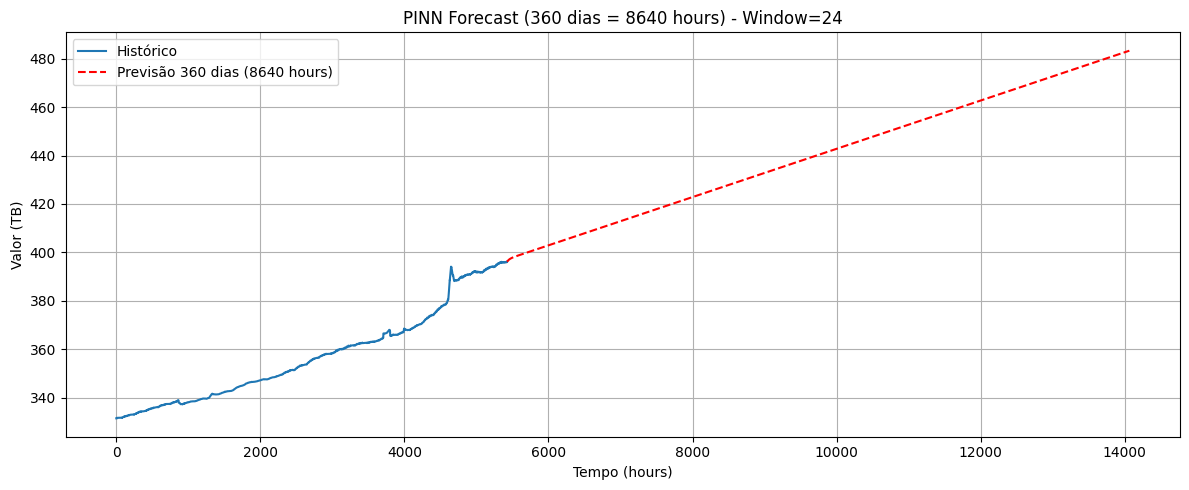

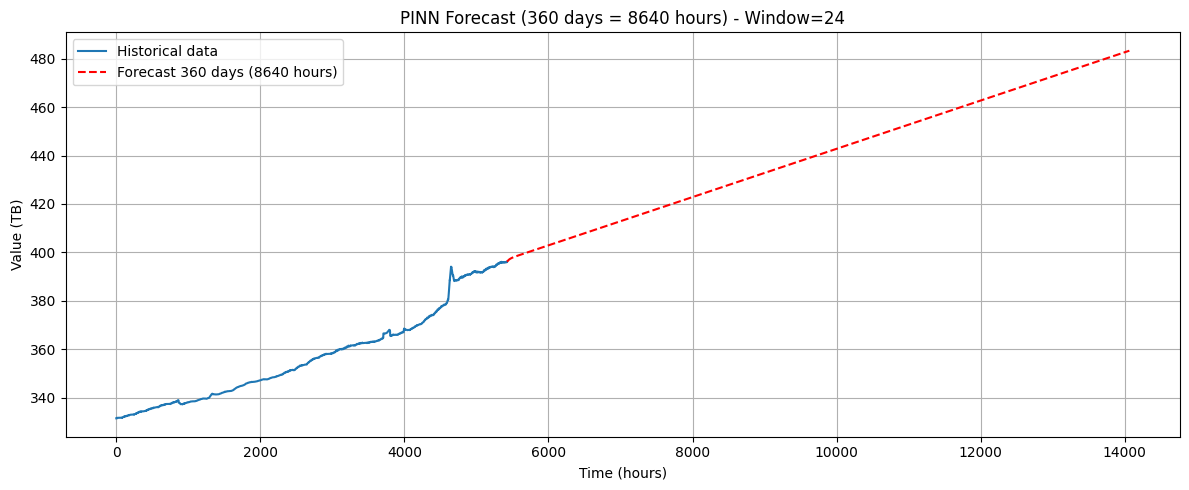

In [ ]:
# TB (decimal). Se quiser TiB: /(1024**4)
series_tb = np.asarray(series, dtype=np.float64) / 1e12
forecast_tb_pint = np.asarray(forecast_abs_pint, dtype=np.float64) / 1e12

print("\n📊 PINN - Forecast (em TB):")
for i, val in enumerate(forecast_tb_pint, start=1):
    print(f"Passo {i:03d}: {val:.3f} TB")

print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_tb_pint[-1]:.3f} TB")

# eixo x
x_hist = np.arange(len(series_tb))
x_fore_pint = np.arange(len(series_tb), len(series_tb) + FORECAST_STEPS)

# gráfico em português
plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tb, label="Histórico")
plt.plot(
    x_fore_pint,
    forecast_tb_pint,
    "r--",
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"PINN Forecast ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_PINT}")
plt.xlabel(f"Tempo ({time_unit}s)")
plt.ylabel("Valor (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pint_forecast-pt.png", dpi=300, bbox_inches="tight")
plt.show()

# gráfico em inglês
plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tb, label="Historical data")
plt.plot(
    x_fore_pint,
    forecast_tb_pint,
    "r--",
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"PINN Forecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_PINT}")
plt.xlabel(f"Time ({time_unit}s)")
plt.ylabel("Value (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pint_forecast-en.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# =========================
# TRAIN
# =========================
y_pred_train_seq_pint = model_pinn.predict(X_train_pint, verbose=0)
y_pred_train_pint = y_pred_train_seq_pint[:, -1, 0]

y_train_true_pint = y_train_pint.ravel()

mse_train_pint = mean_squared_error(y_train_true_pint, y_pred_train_pint)
rmse_train_pint = np.sqrt(mse_train_pint)
r2_train_pint = r2_score(y_train_true_pint, y_pred_train_pint)

# =========================
# TEST
# =========================
y_pred_test_seq_pint = model_pinn.predict(X_test_pint, verbose=0)
y_pred_test_pint = y_pred_test_seq_pint[:, -1, 0]

y_test_true_pint = y_test_pint.ravel()

mse_test_pint = mean_squared_error(y_test_true_pint, y_pred_test_pint)
rmse_test_pint = np.sqrt(mse_test_pint)
r2_test_pint = r2_score(y_test_true_pint, y_pred_test_pint)

In [ ]:
# ============================================================
# 💾 SAVE EVERYTHING - PINT / PINNSeq
# ============================================================

import os
import json
import shutil
import joblib
import numpy as np
import pandas as pd


MODEL_NAME = "pint"

if SAVE == 1:
    # ============================================================
    # 1) SAVE WEIGHTS
    # ============================================================
    model_pinn.save_weights(f"{BASE_PATH}/{MODEL_NAME}_model.weights.h5")

    # ============================================================
    # 2) SAVE SCALER
    # ============================================================
    joblib.dump(scaler, f"{BASE_PATH}/{MODEL_NAME}_scaler.save")

    # ============================================================
    # 3) SAVE CONFIG
    # ============================================================
    config_pint = {
        "window": int(BEST_WINDOW_PINT),
        "epochs": int(EPOCHS_PINT),
        "batch_size": int(BATCH_SIZE_PINT),
        "omega": float(omega),
        "lambda_phys": float(model_pinn.lambda_phys.numpy()),
        "dt": float(model_pinn.dt.numpy()),
        "forecast_steps": int(FORECAST_STEPS),
        "forecast_days": int(FORECAST_DAYS),
        "time_unit": str(time_unit),
        "train_size": int(split),
        "architecture": "LSTM seq (64->32) + TimeDistributed Dense + Physics Loss"
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_config.json", "w") as f:
        json.dump(config_pint, f, indent=4)

    # ============================================================
    # 4) SAVE TRAINING HISTORY
    # ============================================================
    hist_dict = {
        "loss": hist.history.get("loss", []),
        "val_loss": hist.history.get("val_loss", []),
        "data_loss": hist.history.get("data_loss", []),
        "val_data_loss": hist.history.get("val_data_loss", []),
        "phys_loss": hist.history.get("phys_loss", []),
        "val_phys_loss": hist.history.get("val_phys_loss", []),
    }

    for k, v in hist_dict.items():
        np.save(f"{BASE_PATH}/{MODEL_NAME}_{k}.npy", np.array(v, dtype=np.float64))

    df_pint_loss = pd.DataFrame({
        "epoch": range(1, len(hist.history["loss"]) + 1),
        "loss_total": hist.history.get("loss"),
        "val_loss_total": hist.history.get("val_loss"),
        "data_loss": hist.history.get("data_loss"),
        "val_data_loss": hist.history.get("val_data_loss"),
        "phys_loss": hist.history.get("phys_loss"),
        "val_phys_loss": hist.history.get("val_phys_loss"),
    })
    df_pint_loss.to_csv(f"{BASE_PATH}/{MODEL_NAME}_loss_curve.csv", index=False)

    # ============================================================
    # 5) SAVE METRICS
    # ============================================================
    metrics_pint = {
        "final_loss": float(hist.history["loss"][-1]),
        "best_val_loss": float(min(hist.history["val_loss"])) if "val_loss" in hist.history else None,

        "mse_train_scaled": float(mse_train_pint),
        "rmse_train_scaled": float(rmse_train_pint),
        "r2_train_scaled": float(r2_train_pint),

        "mse_test_scaled": float(mse_test_pint),
        "rmse_test_scaled": float(rmse_test_pint),
        "r2_test_scaled": float(r2_test_pint),

        "mse_abs": float(mse_abs_pint),
        "rmse_abs": float(rmse_abs_pint),
        "r2_abs": float(r2_abs_pint),

        "forecast_last_tb": float(forecast_tb_pint[-1]),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_metrics.json", "w") as f:
        json.dump(metrics_pint, f, indent=4)

    # ============================================================
    # 6) SAVE DATA ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/X_train_{MODEL_NAME}.npy", X_train_pint)
    np.save(f"{BASE_PATH}/y_train_{MODEL_NAME}.npy", y_train_pint)
    np.save(f"{BASE_PATH}/X_test_{MODEL_NAME}.npy", X_test_pint)
    np.save(f"{BASE_PATH}/y_test_{MODEL_NAME}.npy", y_test_pint)

    # preds escala normalizada
    np.save(f"{BASE_PATH}/y_pred_train_seq_{MODEL_NAME}.npy", y_pred_train_seq_pint)
    np.save(f"{BASE_PATH}/y_pred_train_{MODEL_NAME}.npy", y_pred_train_pint)
    np.save(f"{BASE_PATH}/y_pred_test_seq_{MODEL_NAME}.npy", y_pred_test_seq_pint)
    np.save(f"{BASE_PATH}/y_pred_test_{MODEL_NAME}.npy", y_pred_test_pint)

    # inversões para escala original dos deltas
    np.save(f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy", y_test_inv_pint)
    np.save(f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy", y_pred_inv_pint)

    # ============================================================
    # 7) SAVE ABSOLUTE RECONSTRUCTION
    # ============================================================
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy", y_test_abs_pint)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy", y_pred_abs_pint)
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy", y_test_abs_pint_tb)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy", y_pred_abs_pint_tb)

    # ============================================================
    # 8) SAVE FORECAST
    # ============================================================
    np.save(f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy", np.array(forecast_diffs_pint))
    np.save(f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy", forecast_diffs_inv_pint)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy", forecast_abs_pint)
    np.save(f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy", forecast_tb_pint)

    try:
        np.save(f"{BASE_PATH}/last_window_{MODEL_NAME}.npy", last_window_pint)
    except NameError:
        pass

    # ============================================================
    # 9) SAVE PREPROCESSING REFERENCES
    # ============================================================
    np.save(f"{BASE_PATH}/series_original.npy", series)
    np.save(f"{BASE_PATH}/diff_series.npy", diff_series)
    np.save(f"{BASE_PATH}/diff_train.npy", diff_train)
    np.save(f"{BASE_PATH}/diff_test.npy", diff_test)
    np.save(f"{BASE_PATH}/diff_train_norm.npy", diff_train_norm)
    np.save(f"{BASE_PATH}/diff_test_norm.npy", diff_test_norm)

    # ============================================================
    # 10) SAVE RECONSTRUCTION INFO
    # ============================================================
    reconstruction_info_pint = {
        "split": int(split),
        "base_value": float(base_value),
        "series_last_value": float(series[-1]),
    }
    with open(f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json", "w") as f:
        json.dump(reconstruction_info_pint, f, indent=4)

    # ============================================================
    # 11) COPY FIGURES
    # ============================================================
    figure_files = [
        "pint_loss_total-pt.png",
        "pint_data_loss-pt.png",
        "pint_phys_loss-pt.png",
        "pint_val_real_vs_pred-pt.png",
        "pint_val_real_vs_pred-en.png",
        "pint_forecast-pt.png",
        "pint_forecast-en.png",
    ]

    for fig in figure_files:
        if os.path.exists(fig):
            dest = os.path.join(BASE_PATH, fig)
            if os.path.abspath(fig) != os.path.abspath(dest):
                shutil.copy2(fig, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All PINT artifacts saved in:\n{BASE_PATH}")

# TFKAN

In [ ]:
import tensorflow as tf
import keras
from keras import Model, Input
from keras.layers import Dense, Reshape
import keras.ops as ops
from keras.optimizers import Adam

# ============================================================
#  SimpleKANLayer (base + "spline")
# ============================================================
class SimpleKANLayer(keras.layers.Layer):
    """
    KAN simplificado: combinação de:
      - base = Dense(SiLU(x))
      - spline = MLP raso sobre x
    Saída: base + spline
    """
    def __init__(self, units, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.units = units

    def build(self, input_shape):
        # Cuidado com self.name None: não usar concatenação direta
        base_name  = (self.name or "simple_kan") + "_base"
        spl1_name  = (self.name or "simple_kan") + "_spl1"
        spl2_name  = (self.name or "simple_kan") + "_spl2"

        self.base_dense = Dense(self.units, use_bias=True, name=base_name)
        self.spline_dense1 = Dense(self.units, activation="tanh", name=spl1_name)
        self.spline_dense2 = Dense(self.units, activation="tanh", name=spl2_name)

        super().build(input_shape)

    def call(self, x):
        # Base: W_base * SiLU(x)
        base = self.base_dense(ops.silu(x))
        # "Spline": shallow MLP over x
        spline = self.spline_dense2(self.spline_dense1(x))
        # Combinação
        return base + spline


# ============================================================
#  FreqKAN Block (FFT -> KAN -> IFFT)
# ============================================================
class FreqKANBlock(keras.layers.Layer):
    """
    Bloco de frequência para TFKAN.

    Entrada:  (B, L, d)   = freq_embed
    Saída:    (B, L, d)   = freq_time (sinal no domínio do tempo)
    """
    def __init__(self, d_model, window, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.d_model = d_model
        self.window = window

    def build(self, input_shape):
        # KAN compartilhado para real e imaginário
        freq_kan_name = (self.name or "freq_block") + "_kan"
        self.freq_kan = SimpleKANLayer(self.d_model, name=freq_kan_name)
        super().build(input_shape)

    def call(self, freq_embed):
        # freq_embed: (B, L, d)
        # 1. Transpor para FFT ao longo de L: (B, L, d) -> (B, d, L)
        freq_t = ops.transpose(freq_embed, axes=(0, 2, 1))

        # 2. FFT real -> complexo: (B, d, L_fft), L_fft = floor(L/2)+1
        freq_fft = tf.signal.rfft(freq_t)

        # 3. Separar real/imaginário e voltar para (B, L_fft, d)
        real = ops.transpose(tf.math.real(freq_fft), axes=(0, 2, 1))
        imag = ops.transpose(tf.math.imag(freq_fft), axes=(0, 2, 1))

        # 4. Aplicar KAN nos dois ramos (compartilhando pesos)
        real_out = self.freq_kan(real)   # (B, L_fft, d)
        imag_out = self.freq_kan(imag)   # (B, L_fft, d)

        # 5. Reconstruir espectro complexo: (B, L_fft, d) -> (B, d, L_fft)
        real_out_t = ops.transpose(real_out, axes=(0, 2, 1))
        imag_out_t = ops.transpose(imag_out, axes=(0, 2, 1))
        z_complex = tf.complex(real_out_t, imag_out_t)

        # 6. IFFT para voltar ao tempo
        # ⚠️ Importante: NÃO passar fft_length manualmente — ele será inferido
        # a partir de L_fft, voltando exatamente para L original.
        freq_time_t = tf.signal.irfft(z_complex)  # (B, d, L)

        # 7. Transpor de volta para (B, L, d)
        freq_time = ops.transpose(freq_time_t, axes=(0, 2, 1))
        return freq_time


# ============================================================
#  TFKAN model builder
# ============================================================
def build_tfkan(window,
                n_features=1,
                d_model=128,
                forecast_steps=1,
                learning_rate=1e-4):

    # --------------------------------------------------------
    #  Input: (batch, L, N)
    # --------------------------------------------------------
    inputs = Input(shape=(window, n_features), name="input_series")

    # --------------------------------------------------------
    #  Embeddings (ajuste de dimensão)
    # --------------------------------------------------------
    freq_embed = Dense(d_model, use_bias=False, name="freq_embedding")(inputs)
    time_embed = Dense(d_model, use_bias=False, name="time_embedding")(inputs)

    # --------------------------------------------------------
    #  Ramo de frequência (FreqKAN)
    # --------------------------------------------------------
    freq_time = FreqKANBlock(d_model=d_model, window=window, name="freq_block")(freq_embed)

    # --------------------------------------------------------
    #  Ramo de tempo (TimeKAN)
    # --------------------------------------------------------
    time_kan = SimpleKANLayer(d_model, name="time_kan")
    time_out = time_kan(time_embed)  # (B, L, d)

    # --------------------------------------------------------
    #  Fusão dos dois ramos
    # --------------------------------------------------------
    bias = freq_embed + time_embed  # (B, L, d)
    H = freq_time + time_out + bias  # (B, L, d)

    # --------------------------------------------------------
    #  KAN-based predictor
    # --------------------------------------------------------
    # Achata (B, L, d) -> (B, L*d); Keras infere L*d com -1.
    H_flat = Reshape((-1,), name="flatten_output")(H)

    pred_kan = SimpleKANLayer(forecast_steps, name="pred_kan")
    outputs = pred_kan(H_flat)  # (B, τ)

    model = Model(inputs=inputs, outputs=outputs, name="TFKAN")

    optimizer = Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss="mse")

    return model


In [ ]:
# Example Usage (replace with your actual data):
#BEST_WINDOW = 24
#N_FEATURES = 1

# Descobrir automaticamente a janela e o número de features a partir dos dados
#BEST_WINDOW = X_train.shape[1]      # 72
N_FEATURES  = X_train_tfkan.shape[2]      # 1

#print("Usando window =", BEST_WINDOW, " | n_features =", N_FEATURES)

#model = build_tfkan(window=BEST_WINDOW_TFKAN, n_features=N_FEATURES)
#model.summary()

In [ ]:
import numpy as np
import tensorflow as tf
#from tfkan_model import build_tfkan # Import the model builder

# ============================================================
#  1. Configuration and Constants
# ============================================================
# Define the constants required for the model and training
#BEST_WINDOW = 24    # L: Length of the input sequence window
#N_FEATURES = 1      # N: Number of features (e.g., 1 for a univariate time series)
#FORECAST_STEPS = 1  # τ: Number of steps to forecast ahead
#EPOCHS = 50          # Number of training epochs
#BATCH_SIZE = 32     # Training batch size
#N_SAMPLES = 2000    # Total synthetic data points to generate
D_MODEL = 128       # Internal dimension of the KAN layers

# Set the device to GPU if available, otherwise CPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Restrict TensorFlow to only use the first GPU
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        device = "/gpu:0"
        print("Using GPU for training.")
    except RuntimeError as e:
        print(e)
        device = "/cpu:0"
        print("Falling back to CPU.")
else:
    device = "/cpu:0"
    print("Using CPU for training.")

device = "/gpu:0"

# Verify shapes
n_features = X_train_tfkan.shape[-1]
print(f"X_train shape: {X_train_tfkan.shape}")
print(f"y_train shape: {y_train_tfkan.shape}")
print(f"Number of features (N): {n_features}")
print(f"Forecast steps (τ): {FORECAST_STEPS}")
print(f"Internal dimension (d): {D_MODEL}")


Using GPU for training.
X_train shape: (4315, 24, 1)
y_train shape: (4315, 1)
Number of features (N): 1
Forecast steps (τ): 8640
Internal dimension (d): 128


In [ ]:
if RELOAD == 0:
    print("Train:", X_train_tfkan.shape, y_train_tfkan.shape)
    print("Test :", X_test_tfkan.shape, y_test_tfkan.shape)

    # τ usado no TREINO: 1 passo à frente
    FORECAST_STEPS_TRAIN = 1

    # Ajusta y para ter 2D (N, 1)
    y_train_tf = y_train_tfkan.reshape(-1, 1)
    y_test_tf  = y_test_tfkan.reshape(-1, 1)

    # ============================================================
    #  3. Modelo TFKAN + treino
    # ============================================================
    with tf.device(device):
        model_tfkan = build_tfkan(
            window=BEST_WINDOW_TFKAN,
            n_features=N_FEATURES,
            d_model=D_MODEL,
            #Eforecast_steps=FORECAST_STEPS,
            forecast_steps=FORECAST_STEPS_TRAIN,
            learning_rate=1e-4
        )
        #model.summary()

        history_tfkan = model_tfkan.fit(
            X_train_tfkan, y_train_tfkan,
            epochs=EPOCHS_TFKAN,
            batch_size=BATCH_SIZE_TFKAN,
            validation_data=(X_test_tfkan, y_test_tfkan),
            verbose=1
        )

In [28]:
# ============================================================
# 🔄 RELOAD EVERYTHING - TFKAN
# ============================================================

import os
import json
import joblib
import numpy as np
import tensorflow as tf
import keras
from keras.models import load_model

if RELOAD == 1:
    # ============================================================
    # CUSTOM LAYERS
    # ============================================================
    class SimpleKANLayer(keras.layers.Layer):
        def __init__(self, units, name=None, **kwargs):
            super().__init__(name=name, **kwargs)
            self.units = units

        def build(self, input_shape):
            base_name = (self.name or "simple_kan") + "_base"
            spl1_name = (self.name or "simple_kan") + "_spl1"
            spl2_name = (self.name or "simple_kan") + "_spl2"

            self.base_dense = keras.layers.Dense(self.units, use_bias=True, name=base_name)
            self.spline_dense1 = keras.layers.Dense(self.units, activation="tanh", name=spl1_name)
            self.spline_dense2 = keras.layers.Dense(self.units, activation="tanh", name=spl2_name)

            super().build(input_shape)

        def call(self, x):
            base = self.base_dense(keras.ops.silu(x))
            spline = self.spline_dense2(self.spline_dense1(x))
            return base + spline

        def get_config(self):
            config = super().get_config()
            config.update({"units": self.units})
            return config


    class FreqKANBlock(keras.layers.Layer):
        def __init__(self, d_model, window, name=None, **kwargs):
            super().__init__(name=name, **kwargs)
            self.d_model = d_model
            self.window = window

        def build(self, input_shape):
            freq_kan_name = (self.name or "freq_block") + "_kan"
            self.freq_kan = SimpleKANLayer(self.d_model, name=freq_kan_name)
            super().build(input_shape)

        def call(self, freq_embed):
            freq_t = keras.ops.transpose(freq_embed, axes=(0, 2, 1))
            freq_fft = tf.signal.rfft(freq_t)

            real = keras.ops.transpose(tf.math.real(freq_fft), axes=(0, 2, 1))
            imag = keras.ops.transpose(tf.math.imag(freq_fft), axes=(0, 2, 1))

            real_out = self.freq_kan(real)
            imag_out = self.freq_kan(imag)

            real_out_t = keras.ops.transpose(real_out, axes=(0, 2, 1))
            imag_out_t = keras.ops.transpose(imag_out, axes=(0, 2, 1))
            z_complex = tf.complex(real_out_t, imag_out_t)

            freq_time_t = tf.signal.irfft(z_complex)
            freq_time = keras.ops.transpose(freq_time_t, axes=(0, 2, 1))
            return freq_time

        def get_config(self):
            config = super().get_config()
            config.update({
                "d_model": self.d_model,
                "window": self.window,
            })
            return config

    # ============================================================
    # PATHS
    # ============================================================

    MODEL_NAME = "tfkan"

    FILE_MODEL              = f"{BASE_PATH}/{MODEL_NAME}_model.keras"
    FILE_SCALER             = f"{BASE_PATH}/{MODEL_NAME}_scaler.save"
    FILE_CONFIG             = f"{BASE_PATH}/{MODEL_NAME}_config.json"
    FILE_METRICS            = f"{BASE_PATH}/{MODEL_NAME}_metrics.json"

    FILE_TRAIN_LOSS         = f"{BASE_PATH}/train_losses_{MODEL_NAME}.npy"
    FILE_VAL_LOSS           = f"{BASE_PATH}/val_losses_{MODEL_NAME}.npy"

    FILE_X_TRAIN            = f"{BASE_PATH}/X_train_{MODEL_NAME}.npy"
    FILE_Y_TRAIN            = f"{BASE_PATH}/y_train_{MODEL_NAME}.npy"
    FILE_X_TEST             = f"{BASE_PATH}/X_test_{MODEL_NAME}.npy"
    FILE_Y_TEST             = f"{BASE_PATH}/y_test_{MODEL_NAME}.npy"

    FILE_Y_TRAIN_INV        = f"{BASE_PATH}/y_train_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_TRAIN_INV   = f"{BASE_PATH}/y_pred_train_inv_{MODEL_NAME}.npy"
    FILE_Y_TEST_INV         = f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_INV         = f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy"

    FILE_Y_TEST_ABS         = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy"
    FILE_Y_PRED_ABS         = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy"
    FILE_Y_TEST_ABS_TB      = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy"
    FILE_Y_PRED_ABS_TB      = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy"

    FILE_FORECAST_DIFFS     = f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy"
    FILE_FORECAST_DIFFS_INV = f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS       = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy"
    FILE_FORECAST_TB        = f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy"

    FILE_SERIES             = f"{BASE_PATH}/series_original.npy"
    FILE_DIFF_SERIES        = f"{BASE_PATH}/diff_series.npy"
    FILE_DIFF_TRAIN         = f"{BASE_PATH}/diff_train.npy"
    FILE_DIFF_TEST          = f"{BASE_PATH}/diff_test.npy"
    FILE_DIFF_TRAIN_NORM    = f"{BASE_PATH}/diff_train_norm.npy"
    FILE_DIFF_TEST_NORM     = f"{BASE_PATH}/diff_test_norm.npy"

    FILE_LAST_WINDOW        = f"{BASE_PATH}/last_window_{MODEL_NAME}.npy"
    FILE_RECON_INFO         = f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json"

    # ============================================================
    # LOAD CORE
    # ============================================================
    model_tfkan = load_model(
        FILE_MODEL,
        custom_objects={
            "SimpleKANLayer": SimpleKANLayer,
            "FreqKANBlock": FreqKANBlock,
        }
    )

    scaler = joblib.load(FILE_SCALER)

    with open(FILE_CONFIG, "r") as f:
        config_tfkan = json.load(f)

    with open(FILE_METRICS, "r") as f:
        metrics_tfkan = json.load(f)

    BEST_WINDOW_TFKAN   = config_tfkan["window"]
    EPOCHS_TFKAN        = config_tfkan["epochs"]
    BATCH_SIZE_TFKAN    = config_tfkan["batch_size"]
    FORECAST_STEPS      = config_tfkan["forecast_steps"]
    FORECAST_DAYS       = config_tfkan["forecast_days"]
    FORECAST_STEPS_TRAIN = config_tfkan["forecast_steps_train"]
    time_unit           = config_tfkan["time_unit"]
    split               = config_tfkan["train_size"]
    N_FEATURES          = config_tfkan["n_features"]
    D_MODEL             = config_tfkan["d_model"]

    # ============================================================
    # LOAD HISTORY
    # ============================================================
    train_losses_tfkan = np.load(FILE_TRAIN_LOSS)
    test_losses_tfkan  = np.load(FILE_VAL_LOSS)

    # ============================================================
    # LOAD ARRAYS
    # ============================================================
    X_train_tfkan = np.load(FILE_X_TRAIN)
    y_train_tfkan = np.load(FILE_Y_TRAIN)
    X_test_tfkan  = np.load(FILE_X_TEST)
    y_test_tfkan  = np.load(FILE_Y_TEST)

    y_train_tfkan_inv      = np.load(FILE_Y_TRAIN_INV)
    y_pred_train_tfkan_inv = np.load(FILE_Y_PRED_TRAIN_INV)
    y_test_tfkan_inv       = np.load(FILE_Y_TEST_INV)
    y_pred_tfkan_inv       = np.load(FILE_Y_PRED_INV)

    y_test_abs_tfkan    = np.load(FILE_Y_TEST_ABS)
    y_pred_abs_tfkan    = np.load(FILE_Y_PRED_ABS)
    y_test_abs_tfkan_tb = np.load(FILE_Y_TEST_ABS_TB)
    y_pred_abs_tfkan_tb = np.load(FILE_Y_PRED_ABS_TB)

    forecast_diffs_tfkan     = np.load(FILE_FORECAST_DIFFS)
    forecast_diffs_inv_tfkan = np.load(FILE_FORECAST_DIFFS_INV)
    forecast_abs_tfkan       = np.load(FILE_FORECAST_ABS)
    forecast_abs_tfkan_tb    = np.load(FILE_FORECAST_TB)

    series          = np.load(FILE_SERIES)
    diff_series     = np.load(FILE_DIFF_SERIES)
    diff_train      = np.load(FILE_DIFF_TRAIN)
    diff_test       = np.load(FILE_DIFF_TEST)
    diff_train_norm = np.load(FILE_DIFF_TRAIN_NORM)
    diff_test_norm  = np.load(FILE_DIFF_TEST_NORM)

    last_window_tfkan = None
    if os.path.exists(FILE_LAST_WINDOW):
        last_window_tfkan = np.load(FILE_LAST_WINDOW)

    with open(FILE_RECON_INFO, "r") as f:
        reconstruction_info_tfkan = json.load(f)

    base_value = reconstruction_info_tfkan["base_value"]
    series_last_value = reconstruction_info_tfkan["series_last_value"]

    # ============================================================
    # OPTIONAL RECOMPUTE
    # ============================================================
    y_pred_tfkan_recomputed = model_tfkan.predict(X_test_tfkan, verbose=0)

    # ============================================================
    # SUMMARY
    # ============================================================
    print("\n✅ RELOAD EVERYTHING - TFKAN COMPLETED")
    print(f"Base path              : {BASE_PATH}")
    print(f"Model                  : {MODEL_NAME}")
    print(f"Window                 : {BEST_WINDOW_TFKAN}")
    print(f"Epochs                 : {EPOCHS_TFKAN}")
    print(f"Batch size             : {BATCH_SIZE_TFKAN}")
    print(f"Forecast steps         : {FORECAST_STEPS}")
    print(f"Forecast days          : {FORECAST_DAYS}")
    print(f"Forecast steps train   : {FORECAST_STEPS_TRAIN}")
    print(f"Time unit              : {time_unit}")
    print(f"N_FEATURES             : {N_FEATURES}")
    print(f"D_MODEL                : {D_MODEL}")

    print("\n📊 Metrics")
    print(f"Final train loss       : {metrics_tfkan['final_train_loss']:.6f}")
    print(f"Final val loss         : {metrics_tfkan['final_val_loss']:.6f}")
    print(f"MSE train diff         : {metrics_tfkan['mse_train_diff']:.6e}")
    print(f"RMSE train diff        : {metrics_tfkan['rmse_train_diff']:.6e}")
    print(f"R² train diff          : {metrics_tfkan['r2_train_diff']:.6f}")
    print(f"MSE test diff          : {metrics_tfkan['mse_test_diff']:.6e}")
    print(f"RMSE test diff         : {metrics_tfkan['rmse_test_diff']:.6e}")
    print(f"R² test diff           : {metrics_tfkan['r2_test_diff']:.6f}")
    print(f"MSE abs                : {metrics_tfkan['mse_abs']:.6e}")
    print(f"RMSE abs               : {metrics_tfkan['rmse_abs']:.6e}")
    print(f"R² abs                 : {metrics_tfkan['r2_abs']:.6f}")
    print(f"Final forecast TB      : {metrics_tfkan['forecast_last_tb']:.3f}")

    print("\n📐 Shapes")
    print(f"X_train_tfkan          : {X_train_tfkan.shape}")
    print(f"y_train_tfkan          : {y_train_tfkan.shape}")
    print(f"X_test_tfkan           : {X_test_tfkan.shape}")
    print(f"y_test_tfkan           : {y_test_tfkan.shape}")
    print(f"y_pred_tfkan_inv       : {y_pred_tfkan_inv.shape}")
    print(f"y_test_abs_tfkan       : {y_test_abs_tfkan.shape}")
    print(f"forecast_abs_tfkan_tb  : {forecast_abs_tfkan_tb.shape}")

    # ============================================================
    # PACKAGE EVERYTHING
    # ============================================================
    artifacts_tfkan = {
        "model_tfkan": model_tfkan,
        "scaler": scaler,
        "config_tfkan": config_tfkan,
        "metrics_tfkan": metrics_tfkan,
        "train_losses_tfkan": train_losses_tfkan,
        "test_losses_tfkan": test_losses_tfkan,
        "X_train_tfkan": X_train_tfkan,
        "y_train_tfkan": y_train_tfkan,
        "X_test_tfkan": X_test_tfkan,
        "y_test_tfkan": y_test_tfkan,
        "y_train_tfkan_inv": y_train_tfkan_inv,
        "y_pred_train_tfkan_inv": y_pred_train_tfkan_inv,
        "y_test_tfkan_inv": y_test_tfkan_inv,
        "y_pred_tfkan_inv": y_pred_tfkan_inv,
        "y_test_abs_tfkan": y_test_abs_tfkan,
        "y_pred_abs_tfkan": y_pred_abs_tfkan,
        "y_test_abs_tfkan_tb": y_test_abs_tfkan_tb,
        "y_pred_abs_tfkan_tb": y_pred_abs_tfkan_tb,
        "forecast_diffs_tfkan": forecast_diffs_tfkan,
        "forecast_diffs_inv_tfkan": forecast_diffs_inv_tfkan,
        "forecast_abs_tfkan": forecast_abs_tfkan,
        "forecast_abs_tfkan_tb": forecast_abs_tfkan_tb,
        "series": series,
        "diff_series": diff_series,
        "diff_train": diff_train,
        "diff_test": diff_test,
        "diff_train_norm": diff_train_norm,
        "diff_test_norm": diff_test_norm,
        "last_window_tfkan": last_window_tfkan,
        "split": split,
        "base_value": base_value,
        "series_last_value": series_last_value,
        "y_pred_tfkan_recomputed": y_pred_tfkan_recomputed,
    }

    print("\n✅ artifacts_tfkan dictionary created.")




✅ RELOAD EVERYTHING - TFKAN COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : tfkan
Window                 : 24
Epochs                 : 200
Batch size             : 64
Forecast steps         : 8640
Forecast days          : 360
Forecast steps train   : 1
Time unit              : hour
N_FEATURES             : 1
D_MODEL                : 128

📊 Metrics
Final train loss       : 0.001072
Final val loss         : 0.003539
MSE train diff         : 1.815756e+21
RMSE train diff        : 4.261169e+10
R² train diff          : 0.296626
MSE test diff          : 6.042719e+21
RMSE test diff         : 7.773493e+10
R² test diff           : 0.376168
MSE abs                : 1.247540e+25
RMSE abs               : 3.532053e+12
R² abs                 : 0.739957
Final forecast TB      : 422.000

📐 Shapes
X_train_tfkan          : (4315, 24, 1)
y_train_tfkan          : (4315, 1)
X_test_tfkan           : (1061, 24, 1)
y

In [ ]:

# ============================================================
#  ✅ CURVA DE PERDA
# ============================================================
plt.figure(figsize=(8,4))
plt.plot(history_tfkan.history['loss'], label='Treino')
plt.plot(history_tfkan.history['val_loss'], label='Validação')
plt.title("TFKAN - Curva de perda (Loss) durante o treino")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.savefig("tfkan_loss-pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
#  ✅ LOSS CURVE
# ============================================================
plt.figure(figsize=(8,4))
plt.plot(history_tfkan.history['loss'], label='Training')
plt.plot(history_tfkan.history['val_loss'], label='Validation')
plt.title("TFKAN - Loss Curve During Training")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.savefig("tfkan_loss-en.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
#  ✅ AVALIAÇÃO TREINO vs VALIDAÇÃO
# ============================================================
def inverse_transform_and_eval(X_t, y_t):
    y_pred = model_tfkan.predict(X_t, verbose=0)
    y_t_inv = scaler.inverse_transform(y_t.reshape(-1,1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred).flatten()
    mse = mean_squared_error(y_t_inv, y_pred_inv)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_t_inv, y_pred_inv)
    return y_t_inv, y_pred_inv, mse, rmse, r2

y_train_tfkan_inv, y_pred_train_tfkan_inv, mse_tfkan_train, rmse_tfkan_train, r2_tfkan_train = inverse_transform_and_eval(X_train_tfkan, y_train_tfkan)
y_test_tfkan_inv, y_pred_tfkan_inv, mse_tfkan_test, rmse_tfkan_test, r2_tfkan_test = inverse_transform_and_eval(X_test_tfkan, y_test_tfkan)

print("\n📊 Comparação Treino vs Validação:")
print(f"{'Métrica':<10} | {'Treino':>15} | {'Validação':>15}")
print("-"*45)
print(f"{'MSE':<10} | {mse_tfkan_train:>15.4e} | {mse_tfkan_test:>15.4e}")
print(f"{'RMSE':<10} | {rmse_tfkan_train:>15.4e} | {rmse_tfkan_test:>15.4e}")
print(f"{'R²':<10} | {r2_tfkan_train:>15.4f} | {r2_tfkan_test:>15.4f}")

# ============================================================
#  ✅ GRÁFICO REAL vs PREDITO (VAL)
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(y_test_tfkan_inv, label="Real", linewidth=1.5)
plt.plot(y_pred_tfkan_inv, label="Predito", linestyle='--', linewidth=1.2)
plt.title(f"TFKAN - Validação: série real vs previsão (Δ valores, {time_unit})")
plt.xlabel(f"Índice temporal ({time_unit}s)")
plt.ylabel("Δ Value (escala original)")
plt.legend()
plt.grid(True)
plt.savefig("tfkan_val-pt.png", dpi=300, bbox_inches="tight")
plt.show()



NameError: name 'history_tfkan' is not defined

<Figure size 800x400 with 0 Axes>

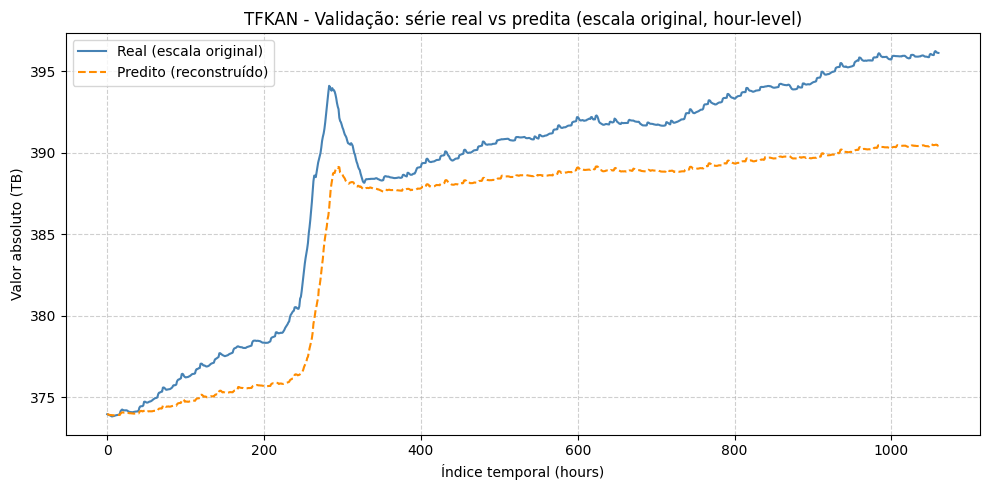

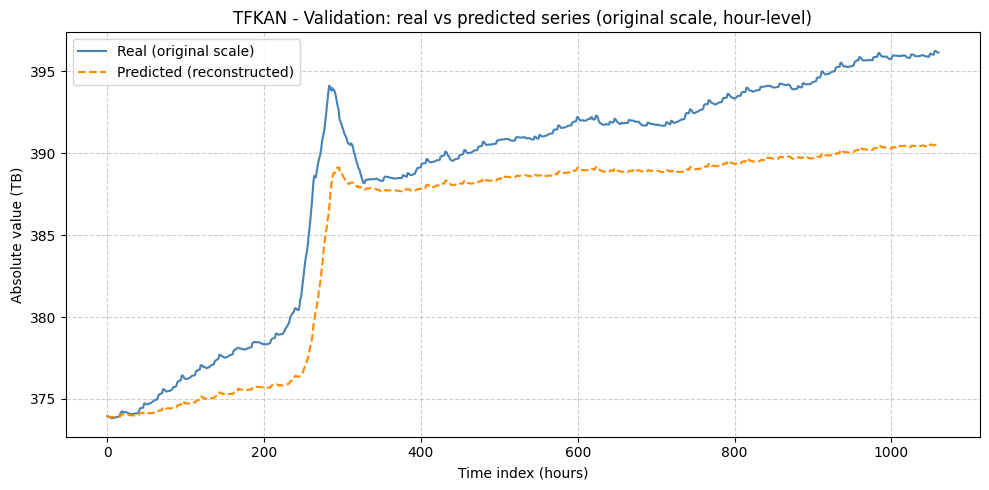


📊 TFKAN - Métricas em escala ABSOLUTA (reconstruída):
MSE(abs)  = 1.2475e+25
RMSE(abs) = 3.5321e+12
R²(abs)   = 0.7400
Window    = 24
Batch     = 64

📊 TFKAN - Metrics in ABSOLUTE scale (reconstructed):
MSE(abs)  = 1.2475e+25
RMSE(abs) = 3.5321e+12
R²(abs)   = 0.7400
Window    = 24
Batch     = 64


In [ ]:
# ============================================================
#  ✅ RECONSTRUÇÃO EM ESCALA ABSOLUTA (VALIDAÇÃO)
# ============================================================
# y_test_inv e y_pred_inv já são ΔValue na escala original
# (vieram de inverse_transform_and_eval)

base_value = series[split + BEST_WINDOW_TFKAN - 1]

# reconstrói série absoluta acumulando os deltas
y_pred_abs_tfkan = base_value + np.cumsum(y_pred_tfkan_inv)
y_test_abs_tfkan = base_value + np.cumsum(y_test_tfkan_inv)

y_pred_abs_tfkan_tb = y_pred_abs_tfkan / 1e12
y_test_abs_tfkan_tb = y_test_abs_tfkan / 1e12

# Plot validation in absolute scale (consistent with main graph)
plt.figure(figsize=(10,5))
plt.plot(y_test_abs_tfkan_tb, label="Real (escala original)", color='steelblue')
plt.plot(y_pred_abs_tfkan_tb, label="Predito (reconstruído)", color='darkorange', linestyle='--')
plt.title(f"TFKAN - Validação: série real vs predita (escala original, {time_unit}-level)")
plt.xlabel(f"Índice temporal ({time_unit}s)")
plt.ylabel("Valor absoluto (TB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("tfkan_val_real_vs_pred-pt.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot validation in absolute scale (consistent with main graph)
plt.figure(figsize=(10,5))
plt.plot(y_test_abs_tfkan_tb, label="Real (original scale)", color='steelblue')
plt.plot(y_pred_abs_tfkan_tb, label="Predicted (reconstructed)", color='darkorange', linestyle='--')
plt.title(f"TFKAN - Validation: real vs predicted series (original scale, {time_unit}-level)")
plt.xlabel(f"Time index ({time_unit}s)")
plt.ylabel("Absolute value (TB)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("tfkan_val_real_vs_pred-en.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 9) Absolute-scale metrics
# ------------------------------------------------------------
mse_abs_tfkan  = mean_squared_error(y_test_abs_tfkan, y_pred_abs_tfkan)
rmse_abs_tfkan = math.sqrt(mse_abs_tfkan)
r2_abs_tfkan   = r2_score(y_test_abs_tfkan, y_pred_abs_tfkan)

print("\n📊 TFKAN - Métricas em escala ABSOLUTA (reconstruída):")
print(f"MSE(abs)  = {mse_abs_tfkan:,.4e}")
print(f"RMSE(abs) = {rmse_abs_tfkan:,.4e}")
print(f"R²(abs)   = {r2_abs_tfkan:.4f}")
print(f"Window    = {BEST_WINDOW_TFKAN}")
print(f"Batch     = {BATCH_SIZE_TFKAN}")

print("\n📊 TFKAN - Metrics in ABSOLUTE scale (reconstructed):")
print(f"MSE(abs)  = {mse_abs_tfkan:,.4e}")
print(f"RMSE(abs) = {rmse_abs_tfkan:,.4e}")
print(f"R²(abs)   = {r2_abs_tfkan:.4f}")
print(f"Window    = {BEST_WINDOW_TFKAN}")
print(f"Batch     = {BATCH_SIZE_TFKAN}")



📊 TFKAN - Forecast (em TB):
Passo 001: 396.140 TB
Passo 002: 396.127 TB
Passo 003: 396.099 TB
Passo 004: 396.038 TB
Passo 005: 396.038 TB
Passo 006: 396.045 TB
Passo 007: 396.049 TB
Passo 008: 396.042 TB
Passo 009: 396.032 TB
Passo 010: 396.030 TB
Passo 011: 396.034 TB
Passo 012: 396.039 TB
Passo 013: 396.039 TB
Passo 014: 396.040 TB
Passo 015: 396.029 TB
Passo 016: 396.025 TB
Passo 017: 396.012 TB
Passo 018: 396.059 TB
Passo 019: 396.094 TB
Passo 020: 396.108 TB
Passo 021: 396.121 TB
Passo 022: 396.130 TB
Passo 023: 396.128 TB
Passo 024: 396.252 TB
Passo 025: 396.275 TB
Passo 026: 396.277 TB
Passo 027: 396.268 TB
Passo 028: 396.230 TB
Passo 029: 396.236 TB
Passo 030: 396.245 TB
Passo 031: 396.255 TB
Passo 032: 396.253 TB
Passo 033: 396.246 TB
Passo 034: 396.240 TB
Passo 035: 396.241 TB
Passo 036: 396.248 TB
Passo 037: 396.250 TB
Passo 038: 396.247 TB
Passo 039: 396.235 TB
Passo 040: 396.228 TB
Passo 041: 396.217 TB
Passo 042: 396.229 TB
Passo 043: 396.245 TB
Passo 044: 396.253 TB
Pas

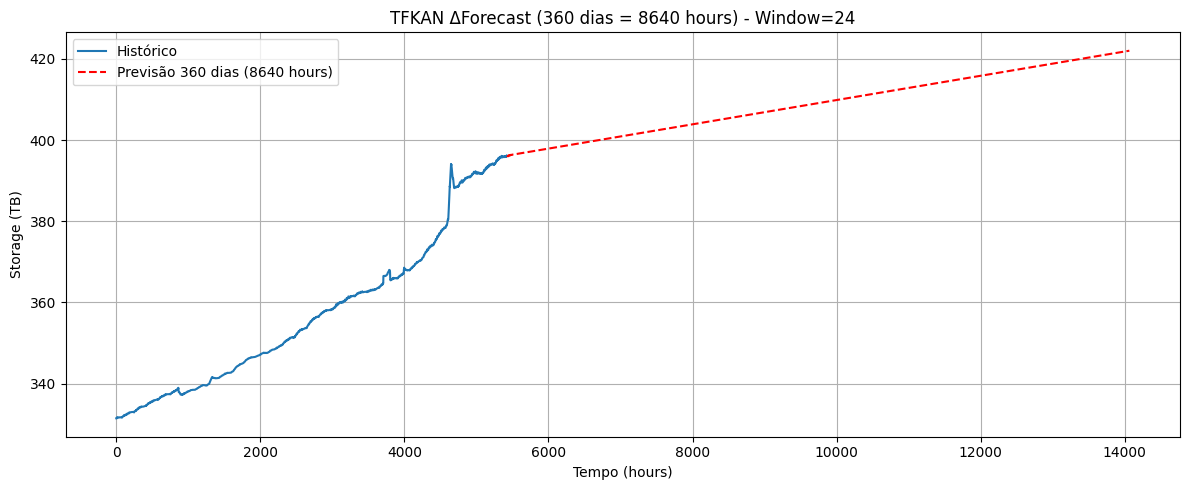

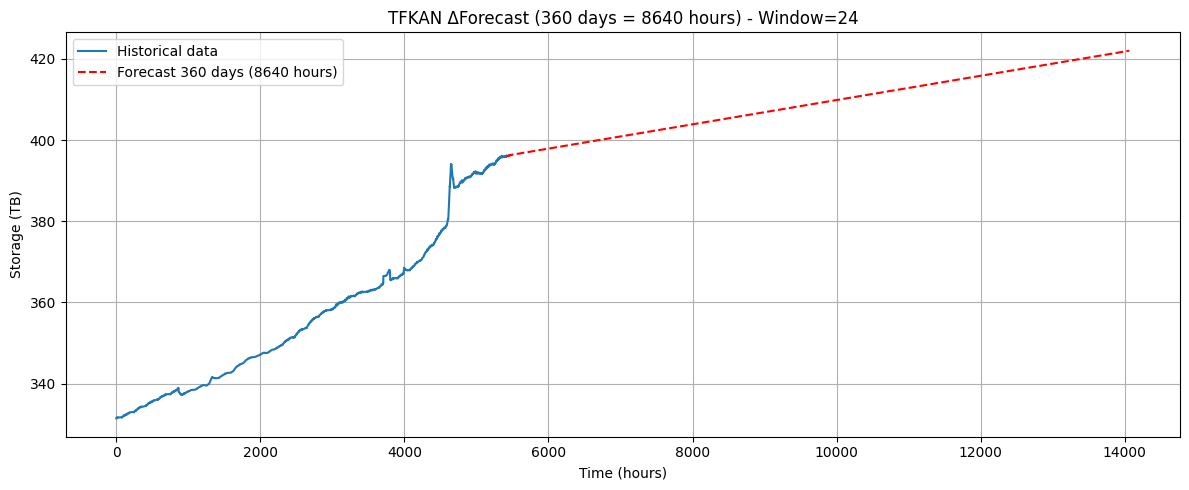

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


if RELOAD == 0:
    # ============================================================
    # ✅ TFKAN - FORECAST (recursive)
    # ============================================================

    diff_norm32_tfkan = np.asarray(diff_norm, dtype=np.float32)
    last_window_tfkan = diff_norm32_tfkan[-BEST_WINDOW_TFKAN:].reshape(1, BEST_WINDOW_TFKAN, 1)

    forecast_diffs_tfkan = []

    for _ in range(FORECAST_STEPS):
        x = tf.convert_to_tensor(last_window_tfkan, dtype=tf.float32)

        # TFKAN retorna (1,1)
        y = model_tfkan(x, training=False)
        yhat = np.float32(y.numpy().reshape(-1)[0])

        forecast_diffs_tfkan.append(yhat)

        # desliza janela
        last_window_tfkan = np.concatenate(
            [
                last_window_tfkan[:, 1:, :],
                np.array(yhat, dtype=np.float32).reshape(1, 1, 1)
            ],
            axis=1
        ).astype(np.float32)

# inverter escala
forecast_diffs_inv_tfkan = scaler.inverse_transform(
    np.array(forecast_diffs_tfkan, dtype=np.float32).reshape(-1, 1)
).ravel()

# reconstrução absoluta
forecast_abs_tfkan = series[-1] + np.cumsum(forecast_diffs_inv_tfkan)

# converter para TB
series_tb = np.asarray(series).ravel() / 1e12
forecast_abs_tfkan_tb = forecast_abs_tfkan / 1e12

# eixos
x_hist_tfkan = np.arange(len(series_tb))
x_fore_tfkan = np.arange(len(series_tb), len(series_tb) + FORECAST_STEPS)

print("\n📊 TFKAN - Forecast (em TB):")
for i, val in enumerate(forecast_abs_tfkan_tb, start=1):
    print(f"Passo {i:03d}: {val:.3f} TB")
print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_tfkan_tb[-1]:.3f} TB")

# ============================================================
# ✅ Plot PT-BR
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(x_hist_tfkan, series_tb, label="Histórico")
plt.plot(
    x_fore_tfkan,
    forecast_abs_tfkan_tb,
    "r--",
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"TFKAN ΔForecast ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_TFKAN}")
plt.xlabel(f"Tempo ({time_unit}s)")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("tfkan_forecast-pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ✅ Plot EN
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(x_hist_tfkan, series_tb, label="Historical data")
plt.plot(
    x_fore_tfkan,
    forecast_abs_tfkan_tb,
    "r--",
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"TFKAN ΔForecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_TFKAN}")
plt.xlabel(f"Time ({time_unit}s)")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("tfkan_forecast-en.png", dpi=300, bbox_inches="tight")
plt.show()


📊 TFKAN - Forecast (em TB):
Passo 001: 396.140 TB
Passo 002: 396.127 TB
Passo 003: 396.099 TB
Passo 004: 396.038 TB
Passo 005: 396.038 TB
Passo 006: 396.045 TB
Passo 007: 396.049 TB
Passo 008: 396.042 TB
Passo 009: 396.032 TB
Passo 010: 396.030 TB
Passo 011: 396.034 TB
Passo 012: 396.039 TB
Passo 013: 396.039 TB
Passo 014: 396.040 TB
Passo 015: 396.029 TB
Passo 016: 396.025 TB
Passo 017: 396.012 TB
Passo 018: 396.059 TB
Passo 019: 396.094 TB
Passo 020: 396.108 TB
Passo 021: 396.121 TB
Passo 022: 396.130 TB
Passo 023: 396.128 TB
Passo 024: 396.252 TB
Passo 025: 396.275 TB
Passo 026: 396.277 TB
Passo 027: 396.268 TB
Passo 028: 396.230 TB
Passo 029: 396.236 TB
Passo 030: 396.245 TB
Passo 031: 396.255 TB
Passo 032: 396.253 TB
Passo 033: 396.246 TB
Passo 034: 396.240 TB
Passo 035: 396.241 TB
Passo 036: 396.248 TB
Passo 037: 396.250 TB
Passo 038: 396.247 TB
Passo 039: 396.235 TB
Passo 040: 396.228 TB
Passo 041: 396.217 TB
Passo 042: 396.229 TB
Passo 043: 396.245 TB
Passo 044: 396.253 TB
Pas

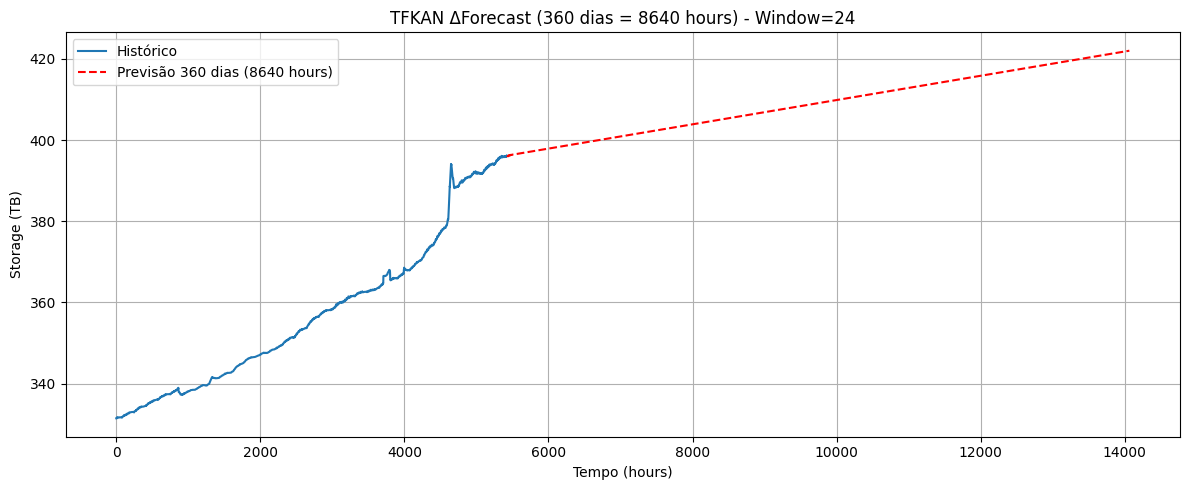

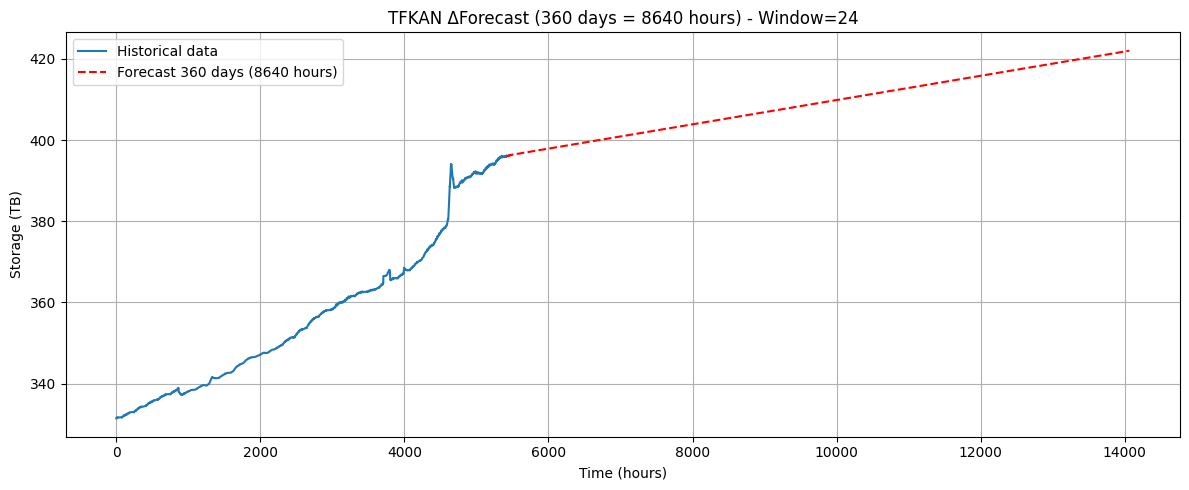

In [ ]:
# converter para TB
series_tb = np.asarray(series).ravel() / 1e12
forecast_abs_tfkan_tb = forecast_abs_tfkan / 1e12

# eixos
x_hist_tfkan = np.arange(len(series_tb))
x_fore_tfkan = np.arange(len(series_tb), len(series_tb) + FORECAST_STEPS)

print("\n📊 TFKAN - Forecast (em TB):")
for i, val in enumerate(forecast_abs_tfkan_tb, start=1):
    print(f"Passo {i:03d}: {val:.3f} TB")
print(f"\n🔮 Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_tfkan_tb[-1]:.3f} TB")

# ============================================================
# ✅ Plot PT-BR
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(x_hist_tfkan, series_tb, label="Histórico")
plt.plot(
    x_fore_tfkan,
    forecast_abs_tfkan_tb,
    "r--",
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"TFKAN ΔForecast ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_TFKAN}")
plt.xlabel(f"Tempo ({time_unit}s)")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("tfkan_forecast-pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ✅ Plot EN
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(x_hist_tfkan, series_tb, label="Historical data")
plt.plot(
    x_fore_tfkan,
    forecast_abs_tfkan_tb,
    "r--",
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)"
)
plt.title(f"TFKAN ΔForecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - Window={BEST_WINDOW_TFKAN}")
plt.xlabel(f"Time ({time_unit}s)")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("tfkan_forecast-en.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 💾 SAVE EVERYTHING - TFKAN
# ============================================================

import os
import json
import shutil
import joblib
import numpy as np


MODEL_NAME = "tfkan"

os.makedirs(BASE_PATH, exist_ok=True)

if SAVE == 1:
    # ============================================================
    # 1) SAVE MODEL
    # ============================================================
    model_tfkan.save(f"{BASE_PATH}/{MODEL_NAME}_model.keras")

    # ============================================================
    # 2) SAVE SCALER
    # ============================================================
    joblib.dump(scaler, f"{BASE_PATH}/{MODEL_NAME}_scaler.save")

    # ============================================================
    # 3) SAVE CONFIG
    # ============================================================
    config_tfkan = {
        "window": int(BEST_WINDOW_TFKAN),
        "epochs": int(EPOCHS_TFKAN),
        "batch_size": int(BATCH_SIZE_TFKAN),
        "forecast_steps": int(FORECAST_STEPS),
        "forecast_days": int(FORECAST_DAYS),
        "forecast_steps_train": int(FORECAST_STEPS_TRAIN),
        "time_unit": str(time_unit),
        "train_size": int(split),
        "n_features": int(N_FEATURES),
        "d_model": int(D_MODEL),
        "learning_rate": float(1e-4),
        "architecture": "TFKAN: freq branch (FFT->KAN->IFFT) + time KAN + predictor KAN"
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_config.json", "w") as f:
        json.dump(config_tfkan, f, indent=4)

    # ============================================================
    # 4) SAVE TRAINING HISTORY
    # ============================================================
    train_losses_tfkan = history_tfkan.history["loss"]
    test_losses_tfkan  = history_tfkan.history["val_loss"]

    np.save(f"{BASE_PATH}/train_losses_{MODEL_NAME}.npy", np.array(train_losses_tfkan, dtype=np.float64))
    np.save(f"{BASE_PATH}/val_losses_{MODEL_NAME}.npy", np.array(test_losses_tfkan, dtype=np.float64))

    # ============================================================
    # 5) SAVE METRICS
    # ============================================================
    metrics_tfkan = {
        "final_train_loss": float(train_losses_tfkan[-1]),
        "final_val_loss": float(test_losses_tfkan[-1]),

        "mse_train_diff": float(mse_tfkan_train),
        "rmse_train_diff": float(rmse_tfkan_train),
        "r2_train_diff": float(r2_tfkan_train),

        "mse_test_diff": float(mse_tfkan_test),
        "rmse_test_diff": float(rmse_tfkan_test),
        "r2_test_diff": float(r2_tfkan_test),

        "mse_abs": float(mse_abs_tfkan),
        "rmse_abs": float(rmse_abs_tfkan),
        "r2_abs": float(r2_abs_tfkan),

        "forecast_last_tb": float(forecast_abs_tfkan_tb[-1]),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_metrics.json", "w") as f:
        json.dump(metrics_tfkan, f, indent=4)

    # ============================================================
    # 6) SAVE DATA ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/X_train_{MODEL_NAME}.npy", X_train_tfkan)
    np.save(f"{BASE_PATH}/y_train_{MODEL_NAME}.npy", y_train_tfkan)
    np.save(f"{BASE_PATH}/X_test_{MODEL_NAME}.npy", X_test_tfkan)
    np.save(f"{BASE_PATH}/y_test_{MODEL_NAME}.npy", y_test_tfkan)

    # escala original (deltas invertidos)
    np.save(f"{BASE_PATH}/y_train_inv_{MODEL_NAME}.npy", y_train_tfkan_inv)
    np.save(f"{BASE_PATH}/y_pred_train_inv_{MODEL_NAME}.npy", y_pred_train_tfkan_inv)
    np.save(f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy", y_test_tfkan_inv)
    np.save(f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy", y_pred_tfkan_inv)

    # ============================================================
    # 7) SAVE ABSOLUTE RECONSTRUCTION
    # ============================================================
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy", y_test_abs_tfkan)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy", y_pred_abs_tfkan)
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy", y_test_abs_tfkan_tb)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy", y_pred_abs_tfkan_tb)

    # ============================================================
    # 8) SAVE FORECAST
    # ============================================================
    np.save(f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy", np.array(forecast_diffs_tfkan))
    np.save(f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy", forecast_diffs_inv_tfkan)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy", forecast_abs_tfkan)
    np.save(f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy", forecast_abs_tfkan_tb)

    try:
        np.save(f"{BASE_PATH}/last_window_{MODEL_NAME}.npy", last_window_tfkan)
    except NameError:
        pass

    # ============================================================
    # 9) SAVE PREPROCESSING REFERENCES
    # ============================================================
    np.save(f"{BASE_PATH}/series_original.npy", series)
    np.save(f"{BASE_PATH}/diff_series.npy", diff_series)
    np.save(f"{BASE_PATH}/diff_train.npy", diff_train)
    np.save(f"{BASE_PATH}/diff_test.npy", diff_test)
    np.save(f"{BASE_PATH}/diff_train_norm.npy", diff_train_norm)
    np.save(f"{BASE_PATH}/diff_test_norm.npy", diff_test_norm)

    # ============================================================
    # 10) SAVE RECONSTRUCTION INFO
    # ============================================================
    reconstruction_info_tfkan = {
        "split": int(split),
        "base_value": float(base_value),
        "series_last_value": float(series[-1]),
    }

    with open(f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json", "w") as f:
        json.dump(reconstruction_info_tfkan, f, indent=4)

    # ============================================================
    # 11) COPY FIGURES
    # ============================================================
    figure_files = [
        "tfkan_loss-pt.png",
        "tfkan_val-pt.png",
        "tfkan_val_real_vs_pred-pt.png",
        "tfkan_forecast-pt.png",
        "tfkan_forecast-en.png",
    ]

    for fig in figure_files:
        if os.path.exists(fig):
            dest = os.path.join(BASE_PATH, fig)
            if os.path.abspath(fig) != os.path.abspath(dest):
                shutil.copy2(fig, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All TFKAN artifacts saved in:\n{BASE_PATH}")

# ETS


Train shape: (4315,)
Test shape : (1061,)

Exponential Smoothing — Espaço Normalizado / Diferenciado
MSE  : 4.886741e-03
RMSE : 6.990523e-02
R²   : 0.138519

Exponential Smoothing — Escala Absoluta (GB)
MSE(abs)  : 4.051250e+25
RMSE(abs) : 6.364943e+12
R²(abs)   : 0.155539

Exponential Smoothing — Escala Absoluta (TiB)
MSE(TiB)  : 40.512496
RMSE(TiB) : 6.364943
R²(TiB)   : 0.155539


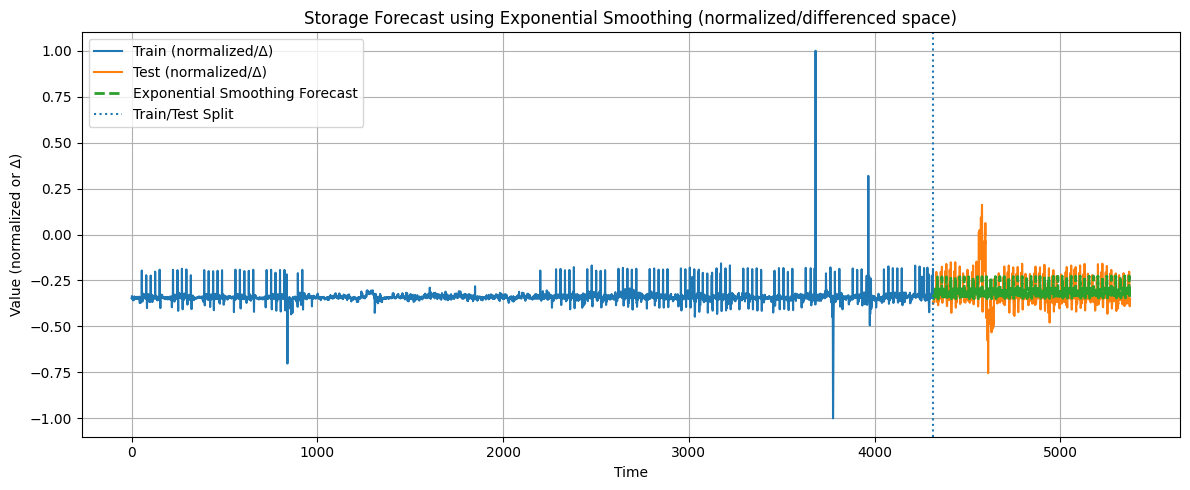

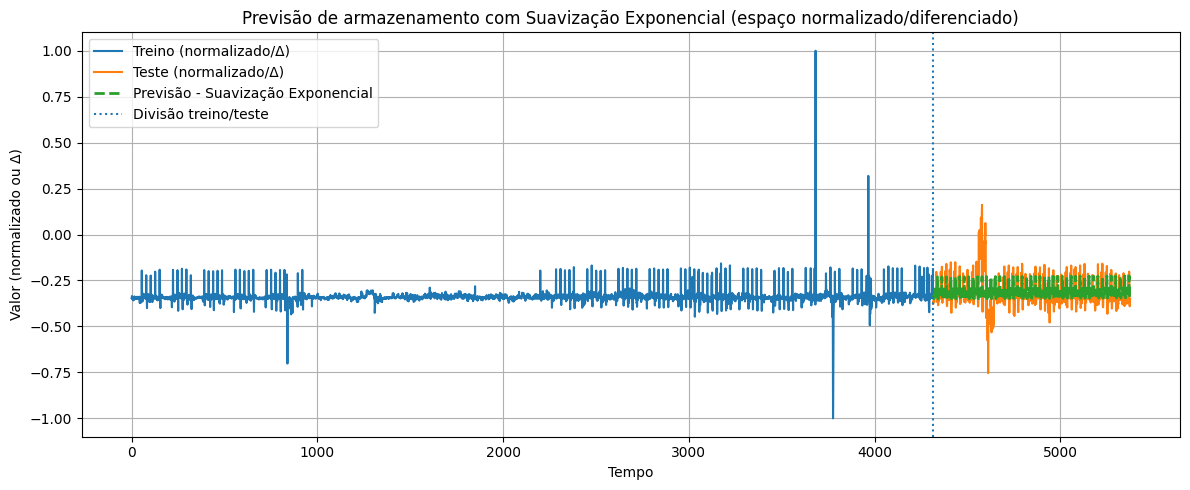

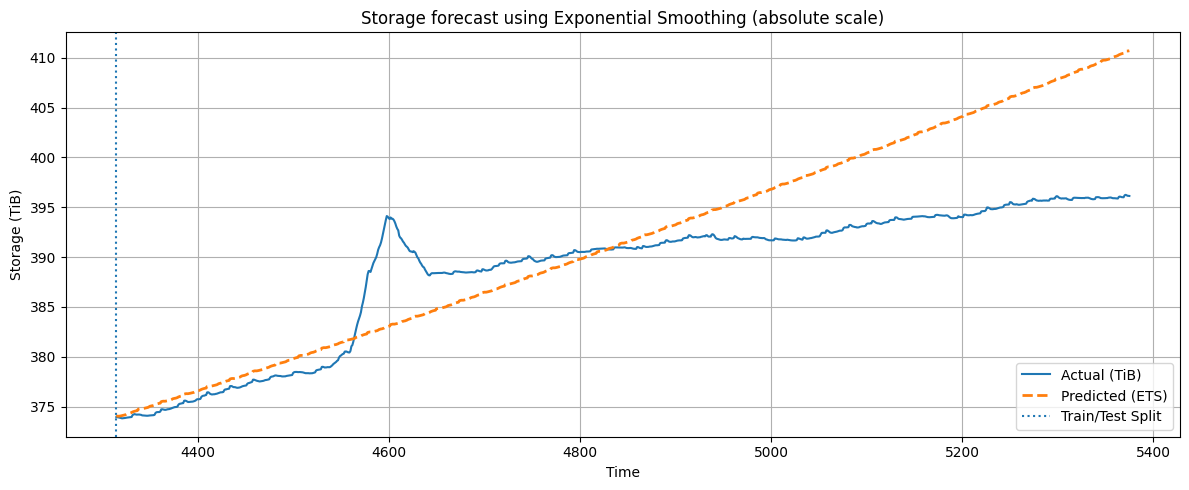

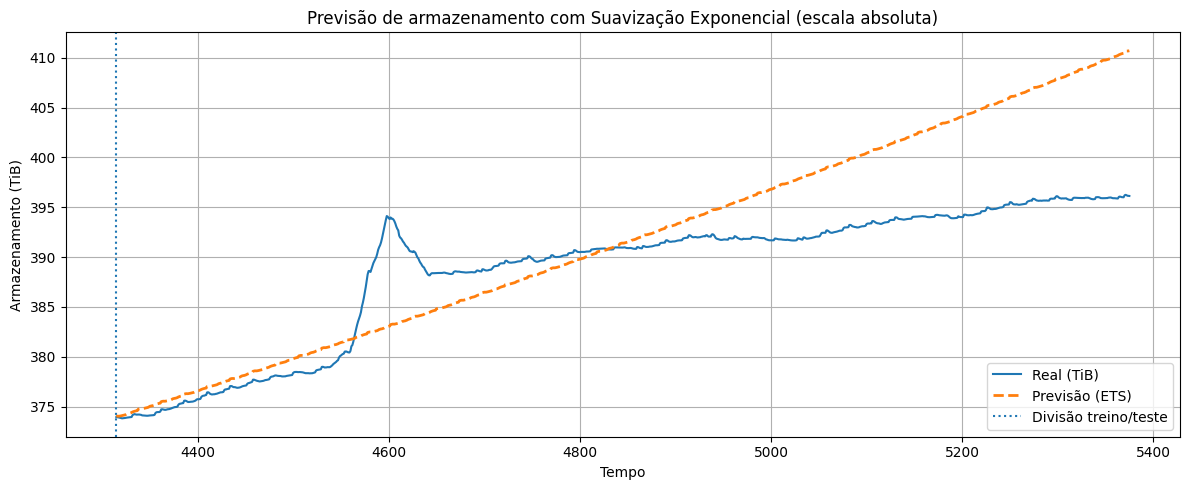

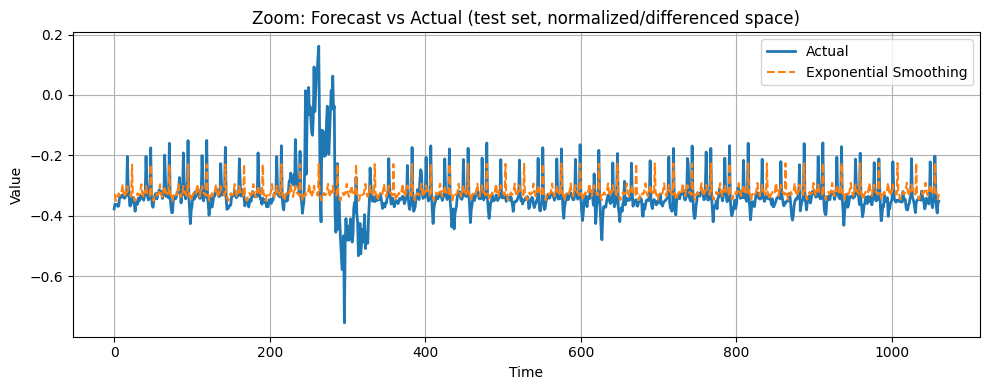

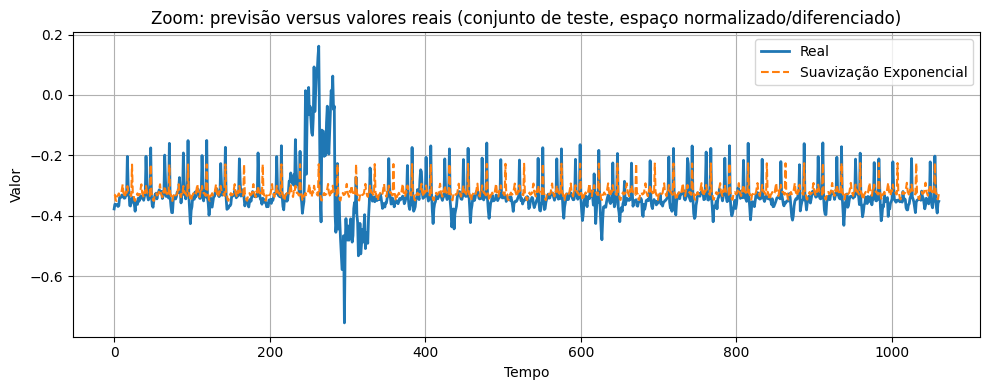

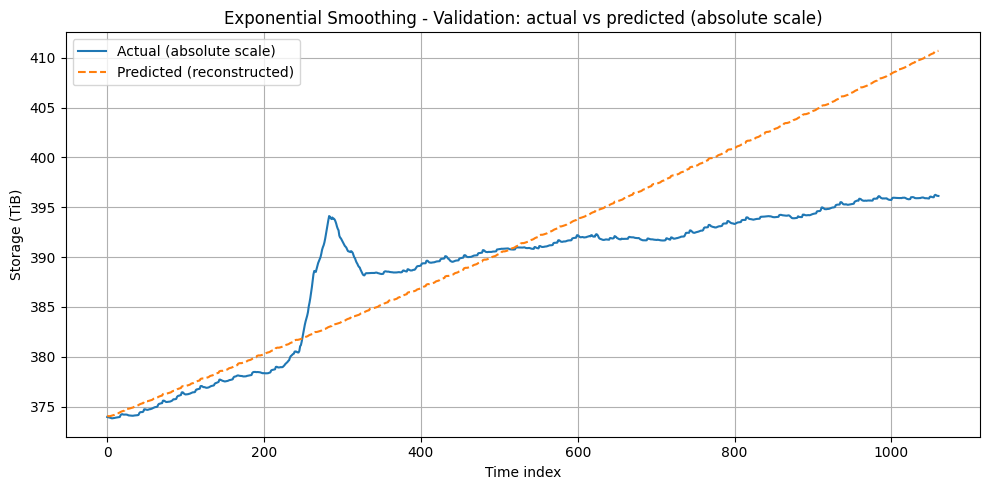

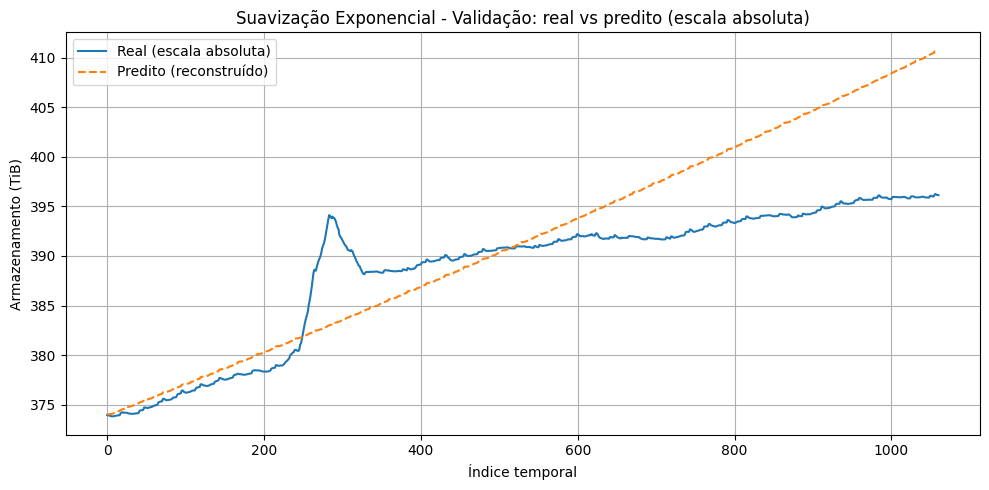


Exponential Smoothing - Forecast (TiB):
Step 001: 396.140 TiB
Step 002: 396.154 TiB
Step 003: 396.167 TiB
Step 004: 396.181 TiB
Step 005: 396.195 TiB
Step 006: 396.209 TiB
Step 007: 396.222 TiB
Step 008: 396.236 TiB
Step 009: 396.250 TiB
Step 010: 396.264 TiB
Step 011: 396.277 TiB
Step 012: 396.291 TiB
Step 013: 396.305 TiB
Step 014: 396.319 TiB
Step 015: 396.332 TiB
Step 016: 396.346 TiB
Step 017: 396.360 TiB
Step 018: 396.374 TiB
Step 019: 396.387 TiB
Step 020: 396.401 TiB
...

Final forecast value (360 days ahead): 515.014 TiB

=== DEBUG DE UNIDADE ===
series raw min/max      : 331472173631680.000 / 396238775807520.000
series TiB min/max      : 331.472 / 396.239
forecast raw min/max    : 396139782012467.000 / 515013923012665.625
forecast TiB min/max    : 396.140 / 515.014


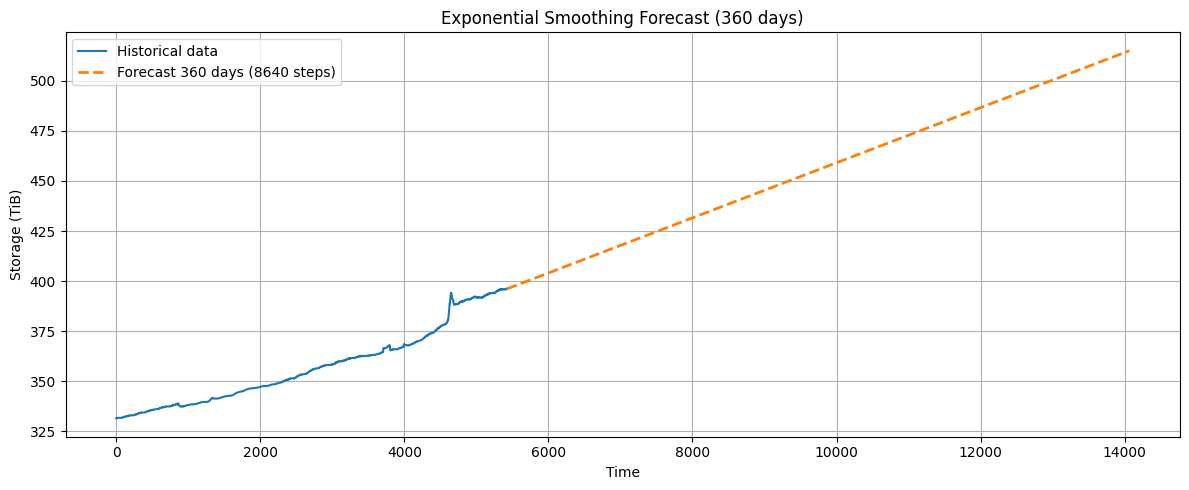

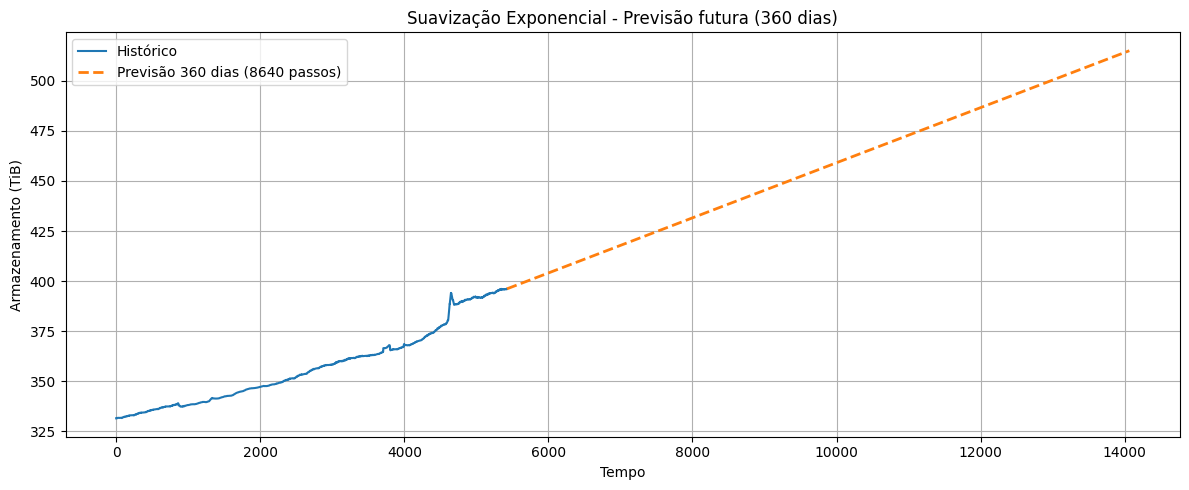


Arquivos salvos com sucesso.


In [ ]:
# ============================================================
# BASELINE ESTATÍSTICO — SUAVIZAÇÃO EXPONENCIAL
# Série original em GB → conversão correta para TiB
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ============================================================
# CONFIGURAÇÃO DE UNIDADE
# ============================================================
# Sua série atual está na escala de GB.
# Exemplo: 300000 GB ≈ 293 TiB.
# Portanto, para converter GB -> TiB, divide por 1024.

TO_TIB = 1e12

# ============================================================
# DADOS DE ENTRADA
# ============================================================

y_train = np.asarray(y_train_mlp).ravel()
y_test  = np.asarray(y_test_mlp).ravel()

print("Train shape:", y_train.shape)
print("Test shape :", y_test.shape)

window_size = BEST_WINDOW_MLP
split_index = train_size
scaler_used = scaler

# ============================================================
# MODELO — EXPONENTIAL SMOOTHING
# ============================================================

#model_exp = ExponentialSmoothing(
#    y_train,
#    trend=None,
#    seasonal=None
#)

model_exp = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=24
)

fit_exp = model_exp.fit(optimized=True)
y_pred_exp = fit_exp.forecast(len(y_test))

# ============================================================
# MÉTRICAS — NORMALIZADO / DIFERENCIADO
# ============================================================

mse_exp = mean_squared_error(y_test, y_pred_exp)
rmse_exp = np.sqrt(mse_exp)
r2_exp = r2_score(y_test, y_pred_exp)

print("\nExponential Smoothing — Espaço Normalizado / Diferenciado")
print(f"MSE  : {mse_exp:.6e}")
print(f"RMSE : {rmse_exp:.6e}")
print(f"R²   : {r2_exp:.6f}")

metrics_exp_norm = {
    "mse": float(mse_exp),
    "rmse": float(rmse_exp),
    "r2": float(r2_exp)
}

with open("exp_metrics_normalized.json", "w", encoding="utf-8") as f:
    json.dump(metrics_exp_norm, f, ensure_ascii=False, indent=4)

with open("exp_metricas_normalizado.json", "w", encoding="utf-8") as f:
    json.dump(metrics_exp_norm, f, ensure_ascii=False, indent=4)

df_exp_norm = pd.DataFrame({
    "time_index": np.arange(len(y_test)),
    "y_true_norm": y_test,
    "y_pred_norm": y_pred_exp
})

df_exp_norm.to_csv("exp_validation_normalized.csv", index=False)
df_exp_norm.to_csv("exp_validacao_normalizado.csv", index=False)

# ============================================================
# RECONSTRUÇÃO EM ESCALA ABSOLUTA
# Série atual está em GB
# ============================================================

y_test_inv_exp = scaler_used.inverse_transform(
    y_test.reshape(-1, 1)
).ravel()

y_pred_inv_exp = scaler_used.inverse_transform(
    y_pred_exp.reshape(-1, 1)
).ravel()

base_value = series[split_index + window_size - 1]

# Reconstrução em GB
y_test_abs_exp = base_value + np.cumsum(y_test_inv_exp)
y_pred_abs_exp = base_value + np.cumsum(y_pred_inv_exp)

# GB → TiB
y_test_abs_exp_tib = y_test_abs_exp / TO_TIB
y_pred_abs_exp_tib = y_pred_abs_exp / TO_TIB

# ============================================================
# MÉTRICAS — ESCALA ABSOLUTA EM GB
# ============================================================

mse_abs_exp = mean_squared_error(y_test_abs_exp, y_pred_abs_exp)
rmse_abs_exp = np.sqrt(mse_abs_exp)
r2_abs_exp = r2_score(y_test_abs_exp, y_pred_abs_exp)

print("\nExponential Smoothing — Escala Absoluta (GB)")
print(f"MSE(abs)  : {mse_abs_exp:.6e}")
print(f"RMSE(abs) : {rmse_abs_exp:.6e}")
print(f"R²(abs)   : {r2_abs_exp:.6f}")

# ============================================================
# MÉTRICAS — ESCALA ABSOLUTA EM TiB
# ============================================================

mse_abs_exp_tib = mean_squared_error(y_test_abs_exp_tib, y_pred_abs_exp_tib)
rmse_abs_exp_tib = np.sqrt(mse_abs_exp_tib)
r2_abs_exp_tib = r2_score(y_test_abs_exp_tib, y_pred_abs_exp_tib)

print("\nExponential Smoothing — Escala Absoluta (TiB)")
print(f"MSE(TiB)  : {mse_abs_exp_tib:.6f}")
print(f"RMSE(TiB) : {rmse_abs_exp_tib:.6f}")
print(f"R²(TiB)   : {r2_abs_exp_tib:.6f}")

metrics_exp_abs = {
    "mse_abs_gb": float(mse_abs_exp),
    "rmse_abs_gb": float(rmse_abs_exp),
    "r2_abs_gb": float(r2_abs_exp),
    "mse_abs_tib": float(mse_abs_exp_tib),
    "rmse_abs_tib": float(rmse_abs_exp_tib),
    "r2_abs_tib": float(r2_abs_exp_tib)
}

with open("exp_metrics_absolute.json", "w", encoding="utf-8") as f:
    json.dump(metrics_exp_abs, f, ensure_ascii=False, indent=4)

with open("exp_metricas_absolutas.json", "w", encoding="utf-8") as f:
    json.dump(metrics_exp_abs, f, ensure_ascii=False, indent=4)

n_val = min(len(y_test_abs_exp_tib), len(y_pred_abs_exp_tib))

df_exp_abs = pd.DataFrame({
    "time_index": np.arange(n_val),
    "y_true_tib": y_test_abs_exp_tib[:n_val],
    "y_pred_tib": y_pred_abs_exp_tib[:n_val]
})

df_exp_abs.to_csv("exp_validation_absolute.csv", index=False)
df_exp_abs.to_csv("exp_validacao_absoluta.csv", index=False)

# ============================================================
# PLOT 1 — NORMALIZADO / DIFERENCIADO
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(y_train)), y_train, label="Train (normalized/Δ)")
plt.plot(
    np.arange(len(y_train), len(y_train) + len(y_test)),
    y_test,
    label="Test (normalized/Δ)"
)
plt.plot(
    np.arange(len(y_train), len(y_train) + len(y_pred_exp)),
    y_pred_exp,
    linestyle="--",
    linewidth=2,
    label="Exponential Smoothing Forecast"
)
plt.axvline(len(y_train), linestyle=":", label="Train/Test Split")
plt.title("Storage Forecast using Exponential Smoothing (normalized/differenced space)")
plt.xlabel("Time")
plt.ylabel("Value (normalized or Δ)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_train_test_forecast_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(y_train)), y_train, label="Treino (normalizado/Δ)")
plt.plot(
    np.arange(len(y_train), len(y_train) + len(y_test)),
    y_test,
    label="Teste (normalizado/Δ)"
)
plt.plot(
    np.arange(len(y_train), len(y_train) + len(y_pred_exp)),
    y_pred_exp,
    linestyle="--",
    linewidth=2,
    label="Previsão - Suavização Exponencial"
)
plt.axvline(len(y_train), linestyle=":", label="Divisão treino/teste")
plt.title("Previsão de armazenamento com Suavização Exponencial (espaço normalizado/diferenciado)")
plt.xlabel("Tempo")
plt.ylabel("Valor (normalizado ou Δ)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_treino_teste_previsao_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 2 — ESCALA ABSOLUTA
# ============================================================

x_test_abs = np.arange(len(y_train), len(y_train) + len(y_test_abs_exp_tib))

plt.figure(figsize=(12, 5))
plt.plot(x_test_abs, y_test_abs_exp_tib, label="Actual (TiB)")
plt.plot(
    x_test_abs,
    y_pred_abs_exp_tib,
    linestyle="--",
    linewidth=2,
    label="Predicted (ETS)"
)
plt.axvline(len(y_train), linestyle=":", label="Train/Test Split")
plt.title("Storage forecast using Exponential Smoothing (absolute scale)")
plt.xlabel("Time")
plt.ylabel("Storage (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_absolute_forecast_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(x_test_abs, y_test_abs_exp_tib, label="Real (TiB)")
plt.plot(
    x_test_abs,
    y_pred_abs_exp_tib,
    linestyle="--",
    linewidth=2,
    label="Previsão (ETS)"
)
plt.axvline(len(y_train), linestyle=":", label="Divisão treino/teste")
plt.title("Previsão de armazenamento com Suavização Exponencial (escala absoluta)")
plt.xlabel("Tempo")
plt.ylabel("Armazenamento (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_previsao_absoluta_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 3 — ZOOM NORMALIZADO
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_pred_exp[:len(y_test)], linestyle="--", label="Exponential Smoothing")
plt.title("Zoom: Forecast vs Actual (test set, normalized/differenced space)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_test_zoom_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(y_test, label="Real", linewidth=2)
plt.plot(y_pred_exp[:len(y_test)], linestyle="--", label="Suavização Exponencial")
plt.title("Zoom: previsão versus valores reais (conjunto de teste, espaço normalizado/diferenciado)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_zoom_teste_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 4 — VALIDAÇÃO ABSOLUTA
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(y_test_abs_exp_tib, label="Actual (absolute scale)")
plt.plot(y_pred_abs_exp_tib, "--", label="Predicted (reconstructed)")
plt.title("Exponential Smoothing - Validation: actual vs predicted (absolute scale)")
plt.xlabel("Time index")
plt.ylabel("Storage (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_validation_absolute_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_test_abs_exp_tib, label="Real (escala absoluta)")
plt.plot(y_pred_abs_exp_tib, "--", label="Predito (reconstruído)")
plt.title("Suavização Exponencial - Validação: real vs predito (escala absoluta)")
plt.xlabel("Índice temporal")
plt.ylabel("Armazenamento (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_validacao_absoluta_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FORECAST FUTURO
# ============================================================

model_future_exp = ExponentialSmoothing(
    diff_train_norm[:, 0],
    trend=None,
    seasonal=None
)

fit_future_exp = model_future_exp.fit(optimized=True)
forecast_diffs_exp = fit_future_exp.forecast(FORECAST_STEPS)

forecast_diffs_inv_exp = scaler_used.inverse_transform(
    np.asarray(forecast_diffs_exp).reshape(-1, 1)
).ravel()

# Reconstrução futura em GB
forecast_abs_exp = series[-1] + np.cumsum(forecast_diffs_inv_exp)

# GB → TiB
forecast_tib_exp = forecast_abs_exp / TO_TIB

print("\nExponential Smoothing - Forecast (TiB):")
for i, val in enumerate(forecast_tib_exp[:20], start=1):
    print(f"Step {i:03d}: {val:.3f} TiB")

print("...")
print(f"\nFinal forecast value ({FORECAST_DAYS} days ahead): {forecast_tib_exp[-1]:.3f} TiB")

df_forecast_exp = pd.DataFrame({
    "step": np.arange(1, FORECAST_STEPS + 1),
    "forecast_tib": forecast_tib_exp
})

df_forecast_exp.to_csv("exp_future_forecast.csv", index=False)
df_forecast_exp.to_csv("exp_forecast_futuro.csv", index=False)

# ============================================================
# DEBUG DE UNIDADE
# ============================================================

series_tib = series / TO_TIB

print("\n=== DEBUG DE UNIDADE ===")
print(f"series raw min/max      : {series.min():.3f} / {series.max():.3f}")
print(f"series TiB min/max      : {series_tib.min():.3f} / {series_tib.max():.3f}")
print(f"forecast raw min/max    : {forecast_abs_exp.min():.3f} / {forecast_abs_exp.max():.3f}")
print(f"forecast TiB min/max    : {forecast_tib_exp.min():.3f} / {forecast_tib_exp.max():.3f}")

# ============================================================
# PLOT 5 — HISTÓRICO + PREVISÃO FUTURA
# ============================================================

x_hist = np.arange(len(series))
x_fore_exp = np.arange(len(series), len(series) + FORECAST_STEPS)

plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tib, label="Historical data")
plt.plot(
    x_fore_exp,
    forecast_tib_exp,
    linestyle="--",
    linewidth=2,
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} steps)"
)
plt.title(f"Exponential Smoothing Forecast ({FORECAST_DAYS} days)")
plt.xlabel("Time")
plt.ylabel("Storage (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_future_forecast_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tib, label="Histórico")
plt.plot(
    x_fore_exp,
    forecast_tib_exp,
    linestyle="--",
    linewidth=2,
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} passos)"
)
plt.title(f"Suavização Exponencial - Previsão futura ({FORECAST_DAYS} dias)")
plt.xlabel("Tempo")
plt.ylabel("Armazenamento (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_forecast_futuro_pt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nArquivos salvos com sucesso.")

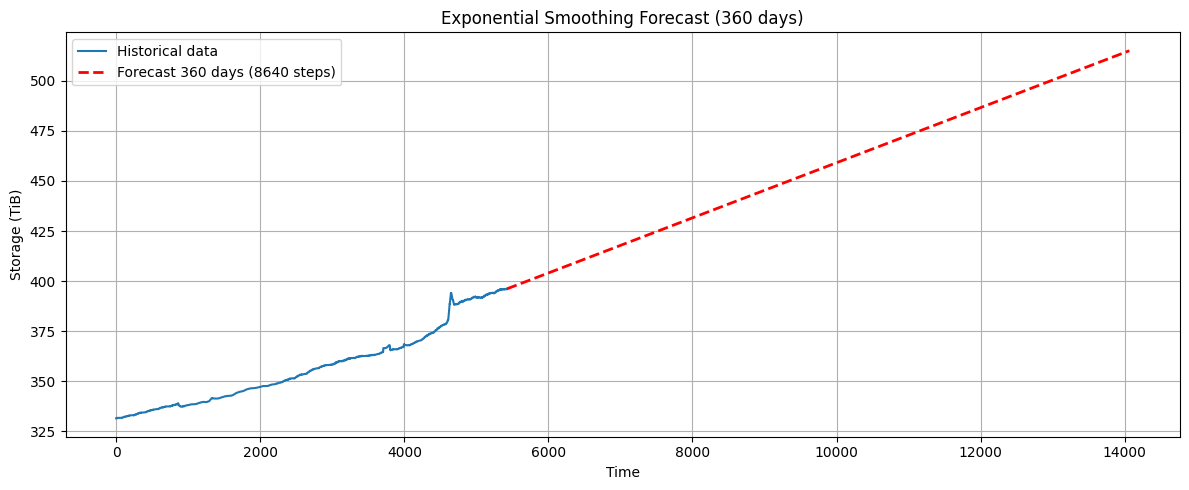

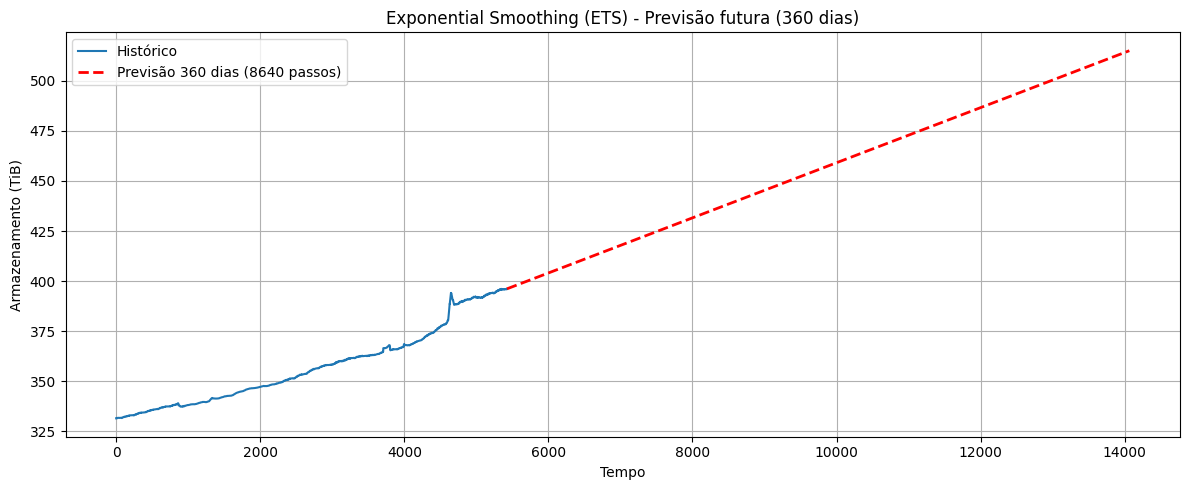

In [ ]:
# ============================================================
# PLOT 5 — HISTÓRICO + PREVISÃO FUTURA
# ============================================================

x_hist = np.arange(len(series))
x_fore_exp = np.arange(len(series), len(series) + FORECAST_STEPS)

plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tib, label="Historical data")
plt.plot(
    x_fore_exp,
    forecast_tib_exp,
    "r--",
    linewidth=2,
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} steps)"
)
plt.title(f"Exponential Smoothing Forecast ({FORECAST_DAYS} days)")
plt.xlabel("Time")
plt.ylabel("Storage (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_future_forecast_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(x_hist, series_tib, label="Histórico")
plt.plot(
    x_fore_exp,
    forecast_tib_exp,
    "r--",
    linewidth=2,
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} passos)"
)
plt.title(f"Exponential Smoothing (ETS) - Previsão futura ({FORECAST_DAYS} dias)")
plt.xlabel("Tempo")
plt.ylabel("Armazenamento (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_forecast_futuro_pt.png", dpi=300, bbox_inches="tight")
plt.show()

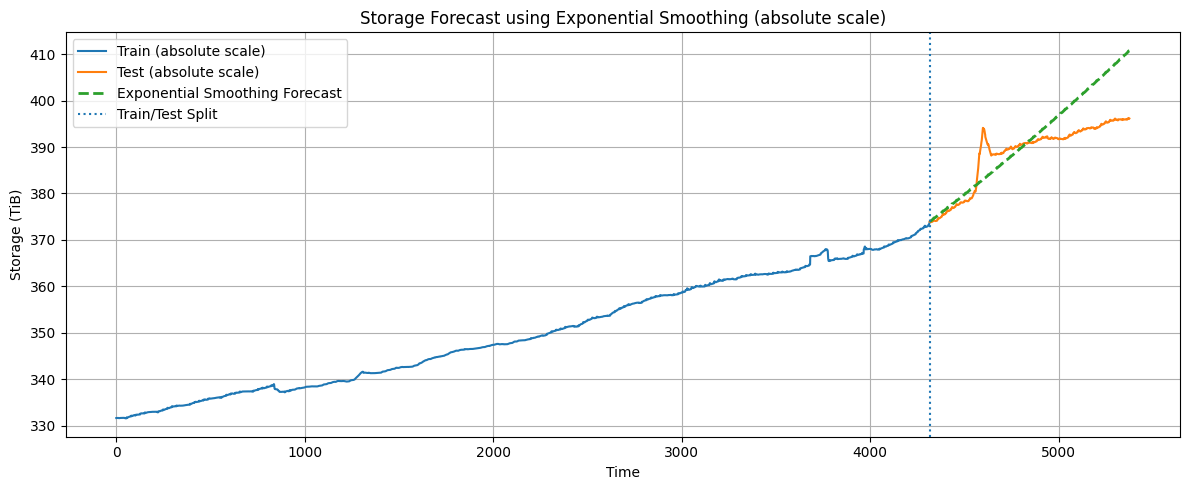

In [ ]:

# ============================================================
# PLOT — TREINO / TESTE / PREVISÃO EM ESCALA ABSOLUTA (TiB)
# ============================================================

# Inverte normalização dos incrementos
y_train_inv_exp = scaler_used.inverse_transform(
    y_train.reshape(-1, 1)
).ravel()

y_test_inv_exp = scaler_used.inverse_transform(
    y_test.reshape(-1, 1)
).ravel()

y_pred_inv_exp = scaler_used.inverse_transform(
    y_pred_exp.reshape(-1, 1)
).ravel()

# Valores-base para reconstrução
base_train = series[window_size - 1]
base_test  = series[split_index + window_size - 1]

# Reconstrução cumulativa em GB
y_train_abs_exp = base_train + np.cumsum(y_train_inv_exp)
y_test_abs_exp  = base_test  + np.cumsum(y_test_inv_exp)
y_pred_abs_exp  = base_test  + np.cumsum(y_pred_inv_exp)

# Conversão GB → TiB
y_train_abs_exp_tib = y_train_abs_exp / TO_TIB
y_test_abs_exp_tib  = y_test_abs_exp  / TO_TIB
y_pred_abs_exp_tib  = y_pred_abs_exp  / TO_TIB

# Eixos temporais
x_train_abs = np.arange(len(y_train_abs_exp_tib))
x_test_abs = np.arange(
    len(y_train_abs_exp_tib),
    len(y_train_abs_exp_tib) + len(y_test_abs_exp_tib)
)

# Plot em escala absoluta
plt.figure(figsize=(12, 5))

plt.plot(
    x_train_abs,
    y_train_abs_exp_tib,
    label="Train (absolute scale)"
)

plt.plot(
    x_test_abs,
    y_test_abs_exp_tib,
    label="Test (absolute scale)"
)

plt.plot(
    x_test_abs,
    y_pred_abs_exp_tib[:len(y_test_abs_exp_tib)],
    linestyle="--",
    linewidth=2,
    label="Exponential Smoothing Forecast"
)

plt.axvline(
    len(y_train_abs_exp_tib),
    linestyle=":",
    label="Train/Test Split"
)

plt.title("Storage Forecast using Exponential Smoothing (absolute scale)")
plt.xlabel("Time")
plt.ylabel("Storage (TiB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("exp_train_test_forecast_absolute_en.png", dpi=300, bbox_inches="tight")
plt.show()

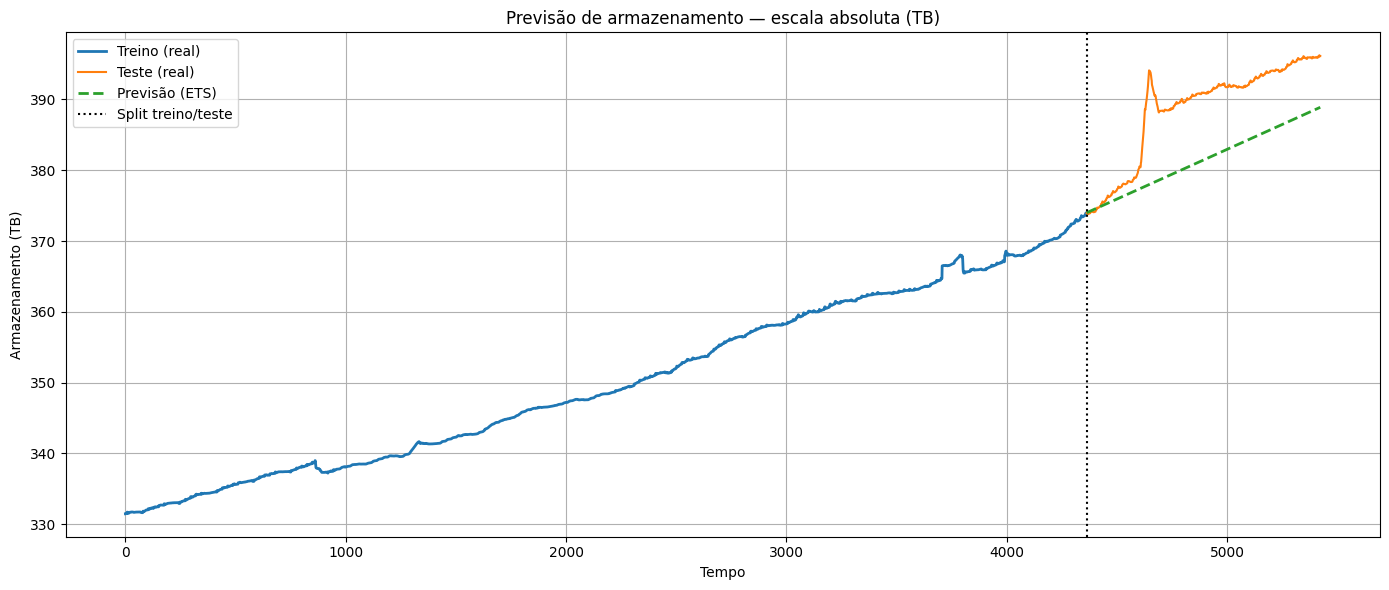

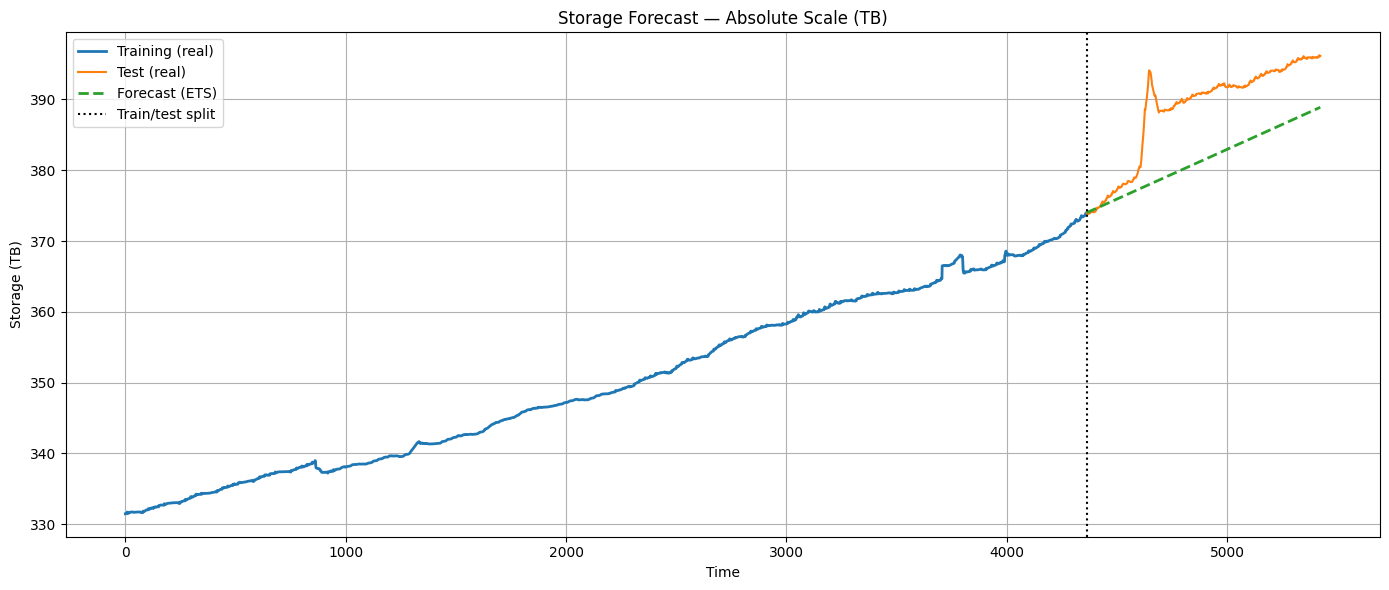

In [ ]:
# ============================================================
# 🔁 RECONSTRUÇÃO COMPLETA (ABSOLUTA)
# ============================================================

window_size = BEST_WINDOW_MLP
split_index = train_size
scaler_used = scaler

# -------- TEST (real) --------
y_test_inv = scaler_used.inverse_transform(y_test.reshape(-1, 1)).ravel()
base_value = series[split_index + window_size]

y_test_abs = base_value + np.cumsum(y_test_inv)
y_test_tb = y_test_abs / 1e12

# -------- FORECAST --------
y_pred_inv = scaler_used.inverse_transform(y_pred_exp.reshape(-1, 1)).ravel()
y_pred_abs = base_value + np.cumsum(y_pred_inv)
y_pred_tb = y_pred_abs / 1e12

# -------- TRAIN (histórico real direto da série) --------
train_series_tb = series[:split_index + window_size] / 1e12

# ============================================================
# 📈 PLOT COMPLETO
# ============================================================

plt.figure(figsize=(14, 6))

# 🔵 treino real
plt.plot(
    np.arange(len(train_series_tb)),
    train_series_tb,
    label="Treino (real)",
    linewidth=2
)

# 🟢 teste real
plt.plot(
    np.arange(len(train_series_tb), len(train_series_tb) + len(y_test_tb)),
    y_test_tb,
    label="Teste (real)"
)

# 🔴 previsão
plt.plot(
    np.arange(len(train_series_tb), len(train_series_tb) + len(y_pred_tb)),
    y_pred_tb,
    linestyle="--",
    linewidth=2,
    label="Previsão (ETS)"
)

# linha de divisão
plt.axvline(len(train_series_tb), linestyle=":", color="black", label="Split treino/teste")

# labels
plt.title("Previsão de armazenamento — escala absoluta (TB)")
plt.xlabel("Tempo")
plt.ylabel("Armazenamento (TB)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("exp_train_test_forecast_absolute_tb.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 6))

# 🔵 real training
plt.plot(
    np.arange(len(train_series_tb)),
    train_series_tb,
    label="Training (real)",
    linewidth=2
)

# 🟢 real test
plt.plot(
    np.arange(len(train_series_tb), len(train_series_tb) + len(y_test_tb)),
    y_test_tb,
    label="Test (real)"
)

# 🔴 forecast
plt.plot(
    np.arange(len(train_series_tb), len(train_series_tb) + len(y_pred_tb)),
    y_pred_tb,
    linestyle="--",
    linewidth=2,
    label="Forecast (ETS)"
)

# split line
plt.axvline(len(train_series_tb), linestyle=":", color="black", label="Train/test split")

# labels
plt.title("Storage Forecast — Absolute Scale (TB)")
plt.xlabel("Time")
plt.ylabel("Storage (TB)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("exp_train_test_forecast_absolute_tb-en.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print(model_exp_reloaded.params)

{'smoothing_level': np.float64(0.0019525413429593076), 'smoothing_trend': np.float64(nan), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(-0.34113181013726496), 'initial_trend': np.float64(nan), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [ ]:
if SAVE == 1:
    # ============================================================
    # 💾 SAVE EVERYTHING - EXP
    # ============================================================

    import os
    import json
    import shutil
    import joblib
    import numpy as np


    MODEL_NAME = "exp"

    os.makedirs(BASE_PATH, exist_ok=True)

    # ============================================================
    # 1) SAVE SCALER
    # ============================================================
    joblib.dump(scaler, f"{BASE_PATH}/{MODEL_NAME}_scaler.save")

    # ============================================================
    # 2) SAVE CONFIG
    # ============================================================
    config_exp = {
        "model_type": "ExponentialSmoothing",
        "trend": None,
        "seasonal": None,
        "window_reference": int(BEST_WINDOW_MLP),
        "forecast_steps": int(FORECAST_STEPS),
        "forecast_days": int(FORECAST_DAYS),
        "time_unit": str(time_unit),
        "train_size": int(train_size),
        "train_len": int(len(y_train)),
        "test_len": int(len(y_test)),
        "reconstruction_base_index": int(train_size + BEST_WINDOW_MLP - 1)
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_config.json", "w", encoding="utf-8") as f:
        json.dump(config_exp, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 3) SAVE METRICS
    # ============================================================
    metrics_exp = {
        "mse_norm": float(mse_exp),
        "rmse_norm": float(rmse_exp),
        "r2_norm": float(r2_exp),

        "mse_abs": float(mse_abs_exp),
        "rmse_abs": float(rmse_abs_exp),
        "r2_abs": float(r2_abs_exp),

        "forecast_last_tb": float(forecast_tb_exp[-1])
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics_exp, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 4) SAVE MAIN ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/y_train_{MODEL_NAME}.npy", y_train)
    np.save(f"{BASE_PATH}/y_test_{MODEL_NAME}.npy", y_test)
    np.save(f"{BASE_PATH}/y_pred_{MODEL_NAME}.npy", y_pred_exp)

    np.save(f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy", y_test_inv_exp)
    np.save(f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy", y_pred_inv_exp)

    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy", y_test_abs_exp)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy", y_pred_abs_exp)

    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy", y_test_abs_exp_tb)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy", y_pred_abs_exp_tb)

    # ============================================================
    # 5) SAVE FORECAST
    # ============================================================
    np.save(f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy", np.array(forecast_diffs_exp))
    np.save(f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy", forecast_diffs_inv_exp)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy", forecast_abs_exp)
    np.save(f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy", forecast_tb_exp)

    # ============================================================
    # 6) SAVE PREPROCESSING REFERENCES
    # ============================================================
    np.save(f"{BASE_PATH}/series_original.npy", series)
    np.save(f"{BASE_PATH}/diff_series.npy", diff_series)
    np.save(f"{BASE_PATH}/diff_train.npy", diff_train)
    np.save(f"{BASE_PATH}/diff_test.npy", diff_test)
    np.save(f"{BASE_PATH}/diff_train_norm.npy", diff_train_norm)
    np.save(f"{BASE_PATH}/diff_test_norm.npy", diff_test_norm)

    # também salva as referências do baseline
    np.save(f"{BASE_PATH}/y_train_source_{MODEL_NAME}.npy", y_train)
    np.save(f"{BASE_PATH}/y_test_source_{MODEL_NAME}.npy", y_test)

    # ============================================================
    # 7) SAVE RECONSTRUCTION INFO
    # ============================================================
    reconstruction_info_exp = {
        "split": int(train_size),
        "base_value": float(base_value),
        "series_last_value": float(series[-1]),
    }

    with open(f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json", "w", encoding="utf-8") as f:
        json.dump(reconstruction_info_exp, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 8) COPY JSON/CSV/PNG FILES IF THEY EXIST
    # ============================================================
    artifact_files = [
        "exp_metrics_normalized.json",
        "exp_metricas_normalizado.json",
        "exp_metrics_absolute.json",
        "exp_metricas_absolutas.json",
        "exp_validation_normalized.csv",
        "exp_validacao_normalizado.csv",
        "exp_validation_absolute.csv",
        "exp_validacao_absoluta.csv",
        "exp_future_forecast.csv",
        "exp_forecast_futuro.csv",
        "exp_model_comparison.csv",
        "exp_comparacao_modelos.csv",
        "exp_train_test_forecast_en.png",
        "exp_treino_teste_previsao_pt.png",
        "exp_test_zoom_en.png",
        "exp_zoom_teste_pt.png",
        "exp_validation_absolute_en.png",
        "exp_validacao_absoluta_pt.png",
        "exp_future_forecast_en.png",
        "exp_forecast_futuro_pt.png",
    ]

    for fname in artifact_files:
        if os.path.exists(fname):
            dest = os.path.join(BASE_PATH, fname)
            if os.path.abspath(fname) != os.path.abspath(dest):
                shutil.copy2(fname, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All EXP artifacts saved in:\n{BASE_PATH}")

In [29]:
if RELOAD == 1:
    # ============================================================
    # 🔄 RELOAD EVERYTHING - EXP
    # ============================================================

    import os
    import json
    import joblib
    import numpy as np
    from statsmodels.tsa.holtwinters import ExponentialSmoothing


    MODEL_NAME = "exp"

    # ============================================================
    # FILE PATHS
    # ============================================================
    FILE_SCALER             = f"{BASE_PATH}/{MODEL_NAME}_scaler.save"
    FILE_CONFIG             = f"{BASE_PATH}/{MODEL_NAME}_config.json"
    FILE_METRICS            = f"{BASE_PATH}/{MODEL_NAME}_metrics.json"

    FILE_Y_TRAIN            = f"{BASE_PATH}/y_train_{MODEL_NAME}.npy"
    FILE_Y_TEST             = f"{BASE_PATH}/y_test_{MODEL_NAME}.npy"
    FILE_Y_PRED             = f"{BASE_PATH}/y_pred_{MODEL_NAME}.npy"

    FILE_Y_TEST_INV         = f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_INV         = f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy"

    FILE_Y_TEST_ABS         = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy"
    FILE_Y_PRED_ABS         = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy"
    FILE_Y_TEST_ABS_TB      = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy"
    FILE_Y_PRED_ABS_TB      = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy"

    FILE_FORECAST_DIFFS     = f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy"
    FILE_FORECAST_DIFFS_INV = f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS       = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy"
    FILE_FORECAST_TB        = f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy"

    FILE_SERIES             = f"{BASE_PATH}/series_original.npy"
    FILE_DIFF_SERIES        = f"{BASE_PATH}/diff_series.npy"
    FILE_DIFF_TRAIN         = f"{BASE_PATH}/diff_train.npy"
    FILE_DIFF_TEST          = f"{BASE_PATH}/diff_test.npy"
    FILE_DIFF_TRAIN_NORM    = f"{BASE_PATH}/diff_train_norm.npy"
    FILE_DIFF_TEST_NORM     = f"{BASE_PATH}/diff_test_norm.npy"

    FILE_RECON_INFO         = f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json"

    # ============================================================
    # LOAD CORE
    # ============================================================
    scaler = joblib.load(FILE_SCALER)

    with open(FILE_CONFIG, "r", encoding="utf-8") as f:
        config_exp = json.load(f)

    with open(FILE_METRICS, "r", encoding="utf-8") as f:
        metrics_exp = json.load(f)

    FORECAST_STEPS = config_exp["forecast_steps"]
    FORECAST_DAYS  = config_exp["forecast_days"]
    time_unit      = config_exp["time_unit"]
    train_size     = config_exp["train_size"]
    BEST_WINDOW_EXP_REF = config_exp["window_reference"]

    # ============================================================
    # LOAD ARRAYS
    # ============================================================
    y_train = np.load(FILE_Y_TRAIN)
    y_test  = np.load(FILE_Y_TEST)
    y_pred_exp = np.load(FILE_Y_PRED)

    y_test_inv_exp = np.load(FILE_Y_TEST_INV)
    y_pred_inv_exp = np.load(FILE_Y_PRED_INV)

    y_test_abs_exp = np.load(FILE_Y_TEST_ABS)
    y_pred_abs_exp = np.load(FILE_Y_PRED_ABS)

    y_test_abs_exp_tb = np.load(FILE_Y_TEST_ABS_TB)
    y_pred_abs_exp_tb = np.load(FILE_Y_PRED_ABS_TB)

    forecast_diffs_exp     = np.load(FILE_FORECAST_DIFFS)
    forecast_diffs_inv_exp = np.load(FILE_FORECAST_DIFFS_INV)
    forecast_abs_exp       = np.load(FILE_FORECAST_ABS)
    forecast_tb_exp        = np.load(FILE_FORECAST_TB)

    series          = np.load(FILE_SERIES)
    diff_series     = np.load(FILE_DIFF_SERIES)
    diff_train      = np.load(FILE_DIFF_TRAIN)
    diff_test       = np.load(FILE_DIFF_TEST)
    diff_train_norm = np.load(FILE_DIFF_TRAIN_NORM)
    diff_test_norm  = np.load(FILE_DIFF_TEST_NORM)

    with open(FILE_RECON_INFO, "r", encoding="utf-8") as f:
        reconstruction_info_exp = json.load(f)

    base_value = reconstruction_info_exp["base_value"]
    series_last_value = reconstruction_info_exp["series_last_value"]
    split = reconstruction_info_exp["split"]

    # ============================================================
    # OPTIONAL RE-FIT / RECOMPUTE
    # ============================================================
    model_exp_reloaded = ExponentialSmoothing(
        y_train,
        trend=None,
        seasonal=None
    )
    fit_exp_reloaded = model_exp_reloaded.fit(optimized=True)
    y_pred_exp_recomputed = fit_exp_reloaded.forecast(len(y_test))

    model_future_exp_reloaded = ExponentialSmoothing(
        diff_train_norm[:, 0],
        trend=None,
        seasonal=None
    )
    fit_future_exp_reloaded = model_future_exp_reloaded.fit(optimized=True)
    forecast_diffs_exp_recomputed = fit_future_exp_reloaded.forecast(FORECAST_STEPS)

    # ============================================================
    # SUMMARY
    # ============================================================
    print("\n✅ RELOAD EVERYTHING - EXP COMPLETED")
    print(f"Base path              : {BASE_PATH}")
    print(f"Model                  : {MODEL_NAME}")
    print(f"Forecast steps         : {FORECAST_STEPS}")
    print(f"Forecast days          : {FORECAST_DAYS}")
    print(f"Time unit              : {time_unit}")
    print(f"Train size             : {train_size}")
    print(f"Window reference       : {BEST_WINDOW_EXP_REF}")

    print("\n📊 Metrics")
    print(f"MSE norm               : {metrics_exp['mse_norm']:.6e}")
    print(f"RMSE norm              : {metrics_exp['rmse_norm']:.6e}")
    print(f"R² norm                : {metrics_exp['r2_norm']:.6f}")
    print(f"MSE abs                : {metrics_exp['mse_abs']:.6e}")
    print(f"RMSE abs               : {metrics_exp['rmse_abs']:.6e}")
    print(f"R² abs                 : {metrics_exp['r2_abs']:.6f}")
    print(f"Final forecast TB      : {metrics_exp['forecast_last_tb']:.3f}")

    print("\n📐 Shapes")
    print(f"y_train                : {y_train.shape}")
    print(f"y_test                 : {y_test.shape}")
    print(f"y_pred_exp             : {y_pred_exp.shape}")
    print(f"y_test_abs_exp         : {y_test_abs_exp.shape}")
    print(f"forecast_tb_exp        : {forecast_tb_exp.shape}")

    # ============================================================
    # PACKAGE EVERYTHING
    # ============================================================
    artifacts_exp = {
        "scaler": scaler,
        "config_exp": config_exp,
        "metrics_exp": metrics_exp,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_exp": y_pred_exp,
        "y_test_inv_exp": y_test_inv_exp,
        "y_pred_inv_exp": y_pred_inv_exp,
        "y_test_abs_exp": y_test_abs_exp,
        "y_pred_abs_exp": y_pred_abs_exp,
        "y_test_abs_exp_tb": y_test_abs_exp_tb,
        "y_pred_abs_exp_tb": y_pred_abs_exp_tb,
        "forecast_diffs_exp": forecast_diffs_exp,
        "forecast_diffs_inv_exp": forecast_diffs_inv_exp,
        "forecast_abs_exp": forecast_abs_exp,
        "forecast_tb_exp": forecast_tb_exp,
        "series": series,
        "diff_series": diff_series,
        "diff_train": diff_train,
        "diff_test": diff_test,
        "diff_train_norm": diff_train_norm,
        "diff_test_norm": diff_test_norm,
        "split": split,
        "base_value": base_value,
        "series_last_value": series_last_value,
        "model_exp_reloaded": model_exp_reloaded,
        "fit_exp_reloaded": fit_exp_reloaded,
        "y_pred_exp_recomputed": y_pred_exp_recomputed,
        "model_future_exp_reloaded": model_future_exp_reloaded,
        "fit_future_exp_reloaded": fit_future_exp_reloaded,
        "forecast_diffs_exp_recomputed": forecast_diffs_exp_recomputed,
    }

    print("\n✅ artifacts_exp dictionary created.")



✅ RELOAD EVERYTHING - EXP COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : exp
Forecast steps         : 8640
Forecast days          : 360
Time unit              : hour
Train size             : 4339
Window reference       : 24

📊 Metrics
MSE norm               : 5.699745e-03
RMSE norm              : 7.549665e-02
R² norm                : -0.004805
MSE abs                : 6.333131e+25
RMSE abs               : 7.958097e+12
R² abs                 : -0.320107
Final forecast TB      : 515.014

📐 Shapes
y_train                : (4315,)
y_test                 : (1061,)
y_pred_exp             : (1061,)
y_test_abs_exp         : (1061,)
forecast_tb_exp        : (8640,)

✅ artifacts_exp dictionary created.


# ARIMA

In [30]:
if RELOAD == 1:
    # ============================================================
    # 🔄 RELOAD EVERYTHING - ARIMA
    # ============================================================

    import os
    import json
    import joblib
    import numpy as np
    from statsmodels.tsa.arima.model import ARIMA


    MODEL_NAME = "arima"

    # ============================================================
    # FILE PATHS
    # ============================================================
    FILE_SCALER             = f"{BASE_PATH}/{MODEL_NAME}_scaler.save"
    FILE_CONFIG             = f"{BASE_PATH}/{MODEL_NAME}_config.json"
    FILE_METRICS            = f"{BASE_PATH}/{MODEL_NAME}_metrics.json"
    FILE_SEARCH_RESULTS     = f"{BASE_PATH}/search_results_{MODEL_NAME}.npy"

    FILE_Y_TRAIN            = f"{BASE_PATH}/y_train_{MODEL_NAME}.npy"
    FILE_Y_TEST             = f"{BASE_PATH}/y_test_{MODEL_NAME}.npy"
    FILE_Y_PRED             = f"{BASE_PATH}/y_pred_{MODEL_NAME}.npy"

    FILE_Y_TEST_INV         = f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy"
    FILE_Y_PRED_INV         = f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy"

    FILE_Y_TEST_ABS         = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy"
    FILE_Y_PRED_ABS         = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy"
    FILE_Y_TEST_ABS_TB      = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy"
    FILE_Y_PRED_ABS_TB      = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy"

    FILE_FORECAST_DIFFS     = f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy"
    FILE_FORECAST_DIFFS_INV = f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy"
    FILE_FORECAST_ABS       = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy"
    FILE_FORECAST_TB        = f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy"

    FILE_SERIES             = f"{BASE_PATH}/series_original.npy"
    FILE_DIFF_SERIES        = f"{BASE_PATH}/diff_series.npy"
    FILE_DIFF_TRAIN         = f"{BASE_PATH}/diff_train.npy"
    FILE_DIFF_TEST          = f"{BASE_PATH}/diff_test.npy"
    FILE_DIFF_TRAIN_NORM    = f"{BASE_PATH}/diff_train_norm.npy"
    FILE_DIFF_TEST_NORM     = f"{BASE_PATH}/diff_test_norm.npy"

    FILE_RECON_INFO         = f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json"

    # ============================================================
    # LOAD CORE
    # ============================================================
    scaler = joblib.load(FILE_SCALER)

    with open(FILE_CONFIG, "r", encoding="utf-8") as f:
        config_arima = json.load(f)

    with open(FILE_METRICS, "r", encoding="utf-8") as f:
        metrics_arima = json.load(f)

    search_results = np.load(FILE_SEARCH_RESULTS, allow_pickle=True).tolist()

    FORECAST_STEPS = config_arima["forecast_steps"]
    FORECAST_DAYS  = config_arima["forecast_days"]
    time_unit      = config_arima["time_unit"]
    train_size     = config_arima["train_size"]
    BEST_WINDOW_ARIMA_REF = config_arima["window_reference"]
    best_order     = tuple(config_arima["best_order"])
    P_VALUES       = config_arima["p_values"]
    Q_VALUES       = config_arima["q_values"]
    D_VALUE        = config_arima["d_value"]

    # ============================================================
    # LOAD ARRAYS
    # ============================================================
    y_train = np.load(FILE_Y_TRAIN)
    y_test  = np.load(FILE_Y_TEST)
    y_pred_arima = np.load(FILE_Y_PRED)

    y_test_inv_arima = np.load(FILE_Y_TEST_INV)
    y_pred_inv_arima = np.load(FILE_Y_PRED_INV)

    y_test_abs_arima = np.load(FILE_Y_TEST_ABS)
    y_pred_abs_arima = np.load(FILE_Y_PRED_ABS)

    y_test_abs_arima_tb = np.load(FILE_Y_TEST_ABS_TB)
    y_pred_abs_arima_tb = np.load(FILE_Y_PRED_ABS_TB)

    forecast_diffs_arima     = np.load(FILE_FORECAST_DIFFS)
    forecast_diffs_inv_arima = np.load(FILE_FORECAST_DIFFS_INV)
    forecast_abs_arima       = np.load(FILE_FORECAST_ABS)
    forecast_tb_arima        = np.load(FILE_FORECAST_TB)

    series          = np.load(FILE_SERIES)
    diff_series     = np.load(FILE_DIFF_SERIES)
    diff_train      = np.load(FILE_DIFF_TRAIN)
    diff_test       = np.load(FILE_DIFF_TEST)
    diff_train_norm = np.load(FILE_DIFF_TRAIN_NORM)
    diff_test_norm  = np.load(FILE_DIFF_TEST_NORM)

    with open(FILE_RECON_INFO, "r", encoding="utf-8") as f:
        reconstruction_info_arima = json.load(f)

    base_value = reconstruction_info_arima["base_value"]
    series_last_value = reconstruction_info_arima["series_last_value"]
    split = reconstruction_info_arima["split"]

    # ============================================================
    # OPTIONAL RE-FIT / RECOMPUTE
    # ============================================================
    model_arima_reloaded = ARIMA(y_train, order=best_order)
    fit_arima_reloaded = model_arima_reloaded.fit()
    y_pred_arima_recomputed = fit_arima_reloaded.forecast(steps=len(y_test))

    model_future_arima_reloaded = ARIMA(diff_train_norm[:, 0], order=best_order)
    fit_future_arima_reloaded = model_future_arima_reloaded.fit()
    forecast_diffs_arima_recomputed = fit_future_arima_reloaded.forecast(steps=FORECAST_STEPS)

    # ============================================================
    # SUMMARY
    # ============================================================
    print("\n✅ RELOAD EVERYTHING - ARIMA COMPLETED")
    print(f"Base path              : {BASE_PATH}")
    print(f"Model                  : {MODEL_NAME}")
    print(f"Best order             : {best_order}")
    print(f"Forecast steps         : {FORECAST_STEPS}")
    print(f"Forecast days          : {FORECAST_DAYS}")
    print(f"Time unit              : {time_unit}")
    print(f"Train size             : {train_size}")
    print(f"Window reference       : {BEST_WINDOW_ARIMA_REF}")
    print(f"Search grid p          : {P_VALUES}")
    print(f"Search grid q          : {Q_VALUES}")
    print(f"d value                : {D_VALUE}")

    print("\n📊 Metrics")
    print(f"AIC                    : {metrics_arima['aic']:.6f}")
    print(f"BIC                    : {metrics_arima['bic']:.6f}")
    print(f"MSE norm               : {metrics_arima['mse_norm']:.6e}")
    print(f"RMSE norm              : {metrics_arima['rmse_norm']:.6e}")
    print(f"R² norm                : {metrics_arima['r2_norm']:.6f}")
    print(f"MSE abs                : {metrics_arima['mse_abs']:.6e}")
    print(f"RMSE abs               : {metrics_arima['rmse_abs']:.6e}")
    print(f"R² abs                 : {metrics_arima['r2_abs']:.6f}")
    print(f"Final forecast TB      : {metrics_arima['forecast_last_tb']:.3f}")

    print("\n📐 Shapes")
    print(f"y_train                : {y_train.shape}")
    print(f"y_test                 : {y_test.shape}")
    print(f"y_pred_arima           : {y_pred_arima.shape}")
    print(f"y_test_abs_arima       : {y_test_abs_arima.shape}")
    print(f"forecast_tb_arima      : {forecast_tb_arima.shape}")
    print(f"search_results         : {len(search_results)} models")

    # ============================================================
    # PACKAGE EVERYTHING
    # ============================================================
    artifacts_arima = {
        "scaler": scaler,
        "config_arima": config_arima,
        "metrics_arima": metrics_arima,
        "search_results": search_results,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_arima": y_pred_arima,
        "y_test_inv_arima": y_test_inv_arima,
        "y_pred_inv_arima": y_pred_inv_arima,
        "y_test_abs_arima": y_test_abs_arima,
        "y_pred_abs_arima": y_pred_abs_arima,
        "y_test_abs_arima_tb": y_test_abs_arima_tb,
        "y_pred_abs_arima_tb": y_pred_abs_arima_tb,
        "forecast_diffs_arima": forecast_diffs_arima,
        "forecast_diffs_inv_arima": forecast_diffs_inv_arima,
        "forecast_abs_arima": forecast_abs_arima,
        "forecast_tb_arima": forecast_tb_arima,
        "series": series,
        "diff_series": diff_series,
        "diff_train": diff_train,
        "diff_test": diff_test,
        "diff_train_norm": diff_train_norm,
        "diff_test_norm": diff_test_norm,
        "split": split,
        "base_value": base_value,
        "series_last_value": series_last_value,
        "model_arima_reloaded": model_arima_reloaded,
        "fit_arima_reloaded": fit_arima_reloaded,
        "y_pred_arima_recomputed": y_pred_arima_recomputed,
        "model_future_arima_reloaded": model_future_arima_reloaded,
        "fit_future_arima_reloaded": fit_future_arima_reloaded,
        "forecast_diffs_arima_recomputed": forecast_diffs_arima_recomputed,
    }

    print("\n✅ artifacts_arima dictionary created.")


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(



✅ RELOAD EVERYTHING - ARIMA COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : arima
Best order             : (5, 1, 1)
Forecast steps         : 8640
Forecast days          : 360
Time unit              : hour
Train size             : 4339
Window reference       : 24
Search grid p          : [0, 1, 2, 3, 4, 5]
Search grid q          : [0, 1, 2, 3, 4, 5]
d value                : 1

📊 Metrics
AIC                    : -15979.562411
BIC                    : -15934.975065
MSE norm               : 5.679867e-03
RMSE norm              : 7.536489e-02
R² norm                : -0.001300
MSE abs                : 3.093079e+25
RMSE abs               : 5.561546e+12
R² abs                 : 0.355264
Final forecast TB      : 639.005

📐 Shapes
y_train                : (4315,)
y_test                 : (1061,)
y_pred_arima           : (1061,)
y_test_abs_arima       : (1061,)
forecast_tb_arima      : (8640,)
search_r

Train shape: (4315,)
Test shape : (1061,)


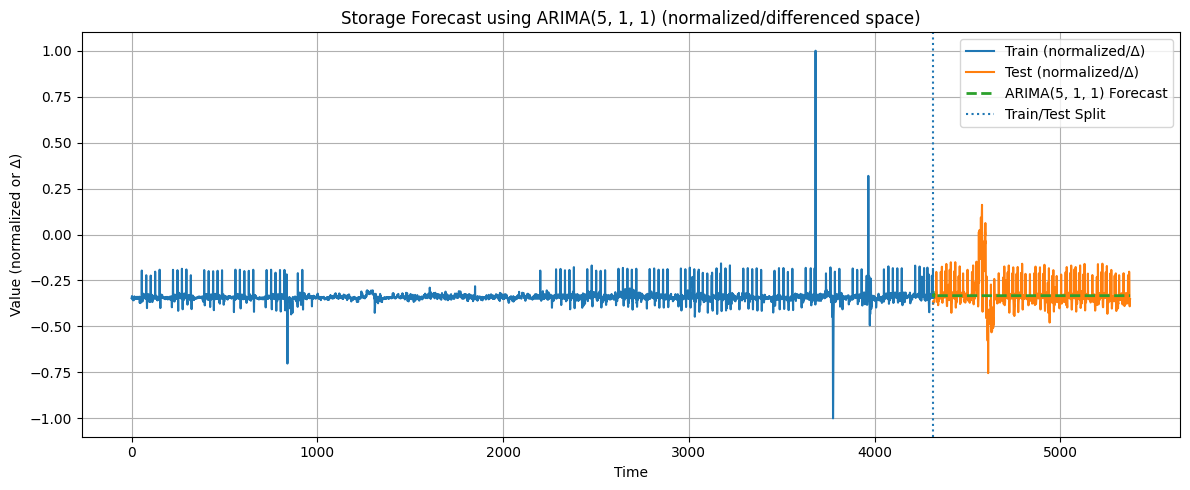

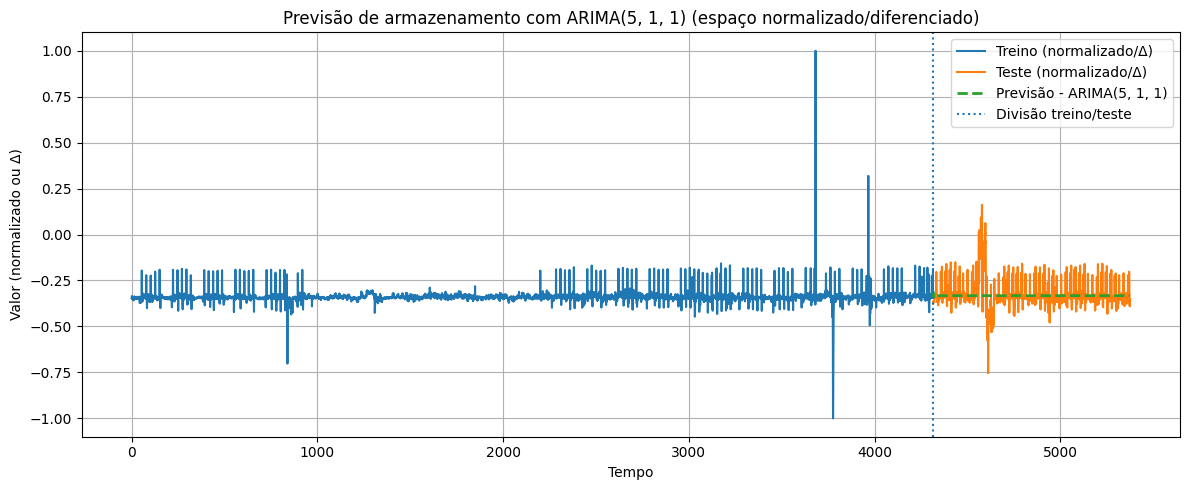

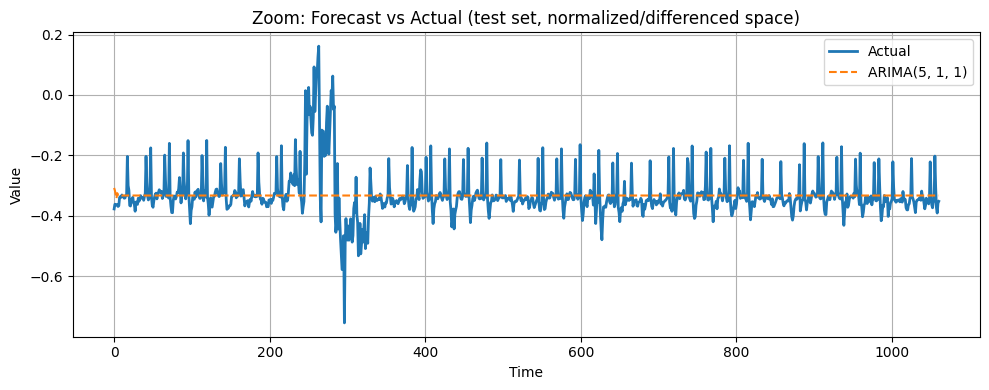

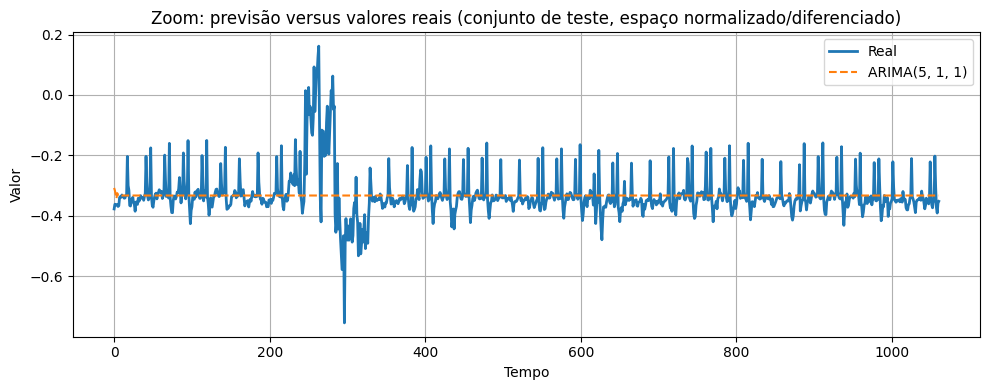


📊 Best ARIMA(5, 1, 1) — Escala Absoluta (bytes)
MSE(abs)  : 3.093079e+25
RMSE(abs) : 5.561546e+12
R²(abs)   : 0.355264

📊 Best ARIMA(5, 1, 1) — Escala Absoluta (TB)
MSE(TB)  : 30.930789
RMSE(TB) : 5.561546
R²(TB)   : 0.355264


AttributeError: 'NoneType' object has no attribute 'aic'

In [ ]:
# ============================================================
# 🔥 BASELINE ESTATÍSTICO — ARIMA COM BUSCA AUTOMÁTICA POR AIC
#    Versão PT-BR + EN com salvamento de PNG, CSV e JSON
# ============================================================

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# ============================================================
# ✅ DADOS DE ENTRADA
# Usa os mesmos alvos já criados no pipeline do MLP
# ============================================================
y_train = np.asarray(y_train_mlp).ravel()
y_test  = np.asarray(y_test_mlp).ravel()

print("Train shape:", y_train.shape)
print("Test shape :", y_test.shape)

# ============================================================
# ✅ PARÂMETROS DE REFERÊNCIA
# ============================================================
window_size = BEST_WINDOW_MLP
split_index = train_size
scaler_used = scaler

# ============================================================
# ✅ GRADE DE BUSCA
# ============================================================
P_VALUES = range(0, 6)
Q_VALUES = range(0, 6)
D_VALUE = 1

if RELOAD == 0:

    # ============================================================
    # ✅ BUSCA AUTOMÁTICA DO MELHOR (p,d,q) POR AIC
    # ============================================================
    search_results = []
    best_aic = np.inf
    best_order = None
    best_fit = None


    print("\n🔎 Searching best ARIMA(p,d,q) by AIC...\n")

    for p in P_VALUES:
        for q in Q_VALUES:
            order = (p, D_VALUE, q)
            try:
                model = ARIMA(y_train, order=order)
                fit = model.fit()

                aic = fit.aic
                bic = fit.bic

                search_results.append({
                    "p": p,
                    "d": D_VALUE,
                    "q": q,
                    "aic": float(aic),
                    "bic": float(bic)
                })

                print(f"ARIMA{order} -> AIC={aic:.4f} | BIC={bic:.4f}")

                if aic < best_aic:
                    best_aic = aic
                    best_order = order
                    best_fit = fit

            except Exception as e:
                print(f"ARIMA{order} -> failed ({str(e)[:80]})")
                search_results.append({
                    "p": p,
                    "d": D_VALUE,
                    "q": q,
                    "aic": None,
                    "bic": None,
                    "error": str(e)
                })

    if best_fit is None:
        raise RuntimeError("Nenhum modelo ARIMA convergiu durante a busca.")

    print("\n✅ Best model found:")
    print(f"ARIMA{best_order} | AIC={best_aic:.4f}")

    # salva tabela de busca
    df_search = pd.DataFrame(search_results)
    df_search.to_csv("arima_grid_search_aic.csv", index=False)
    df_search.to_csv("arima_busca_aic.csv", index=False)

    best_model_info = {
        "best_order": list(best_order),
        "best_aic": float(best_fit.aic),
        "best_bic": float(best_fit.bic)
    }

    with open("arima_best_model.json", "w", encoding="utf-8") as f:
        json.dump(best_model_info, f, ensure_ascii=False, indent=4)

    with open("arima_melhor_modelo.json", "w", encoding="utf-8") as f:
        json.dump(best_model_info, f, ensure_ascii=False, indent=4)

    # ============================================================
    # ✅ PREVISÃO NO CONJUNTO DE TESTE
    # ============================================================
    y_pred_arima = np.asarray(best_fit.forecast(steps=len(y_test))).ravel()

    # ============================================================
    # ✅ MÉTRICAS NO ESPAÇO NORMALIZADO / DIFERENCIADO
    # ============================================================
    r2_arima = r2_score(y_test, y_pred_arima)
    rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
    mse_arima = mean_squared_error(y_test, y_pred_arima)

    print(f"\n📊 Best ARIMA{best_order} — Espaço Normalizado / Diferenciado")
    print(f"MSE  : {mse_arima:.6e}")
    print(f"RMSE : {rmse_arima:.6e}")
    print(f"R²   : {r2_arima:.6f}")

    metrics_arima_norm = {
        "best_order": list(best_order),
        "aic": float(best_fit.aic),
        "bic": float(best_fit.bic),
        "mse": float(mse_arima),
        "rmse": float(rmse_arima),
        "r2": float(r2_arima)
    }

    with open("arima_metrics_normalized.json", "w", encoding="utf-8") as f:
        json.dump(metrics_arima_norm, f, ensure_ascii=False, indent=4)

    with open("arima_metricas_normalizado.json", "w", encoding="utf-8") as f:
        json.dump(metrics_arima_norm, f, ensure_ascii=False, indent=4)

    # salva valores normalizados
    df_arima_norm = pd.DataFrame({
        "time_index": np.arange(len(y_test)),
        "y_true_norm": y_test,
        "y_pred_norm": y_pred_arima
    })
    df_arima_norm.to_csv("arima_validation_normalized.csv", index=False)
    df_arima_norm.to_csv("arima_validacao_normalizado.csv", index=False)

# ============================================================
# ✅ PLOT 1 — TRAIN / TEST / FORECAST (ESPAÇO NORMALIZADO/Δ)
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(y_train)), y_train, label="Train (normalized/Δ)")
plt.plot(
    np.arange(len(y_train), len(y_train) + len(y_test)),
    y_test,
    label="Test (normalized/Δ)"
)
plt.plot(
    np.arange(len(y_train), len(y_train) + len(y_pred_arima)),
    y_pred_arima,
    linestyle="--",
    linewidth=2,
    label=f"ARIMA{best_order} Forecast"
)
plt.axvline(len(y_train), linestyle=":", label="Train/Test Split")
plt.title(f"Storage Forecast using ARIMA{best_order} (normalized/differenced space)")
plt.xlabel("Time")
plt.ylabel("Value (normalized or Δ)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_train_test_forecast_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(y_train)), y_train, label="Treino (normalizado/Δ)")
plt.plot(
    np.arange(len(y_train), len(y_train) + len(y_test)),
    y_test,
    label="Teste (normalizado/Δ)"
)
plt.plot(
    np.arange(len(y_train), len(y_train) + len(y_pred_arima)),
    y_pred_arima,
    linestyle="--",
    linewidth=2,
    label=f"Previsão - ARIMA{best_order}"
)
plt.axvline(len(y_train), linestyle=":", label="Divisão treino/teste")
plt.title(f"Previsão de armazenamento com ARIMA{best_order} (espaço normalizado/diferenciado)")
plt.xlabel("Tempo")
plt.ylabel("Valor (normalizado ou Δ)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_treino_teste_previsao_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ✅ PLOT 2 — ZOOM NO TESTE (ESPAÇO NORMALIZADO/Δ)
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_pred_arima[:len(y_test)], linestyle="--", label=f"ARIMA{best_order}")
plt.title("Zoom: Forecast vs Actual (test set, normalized/differenced space)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_test_zoom_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(y_test, label="Real", linewidth=2)
plt.plot(y_pred_arima[:len(y_test)], linestyle="--", label=f"ARIMA{best_order}")
plt.title("Zoom: previsão versus valores reais (conjunto de teste, espaço normalizado/diferenciado)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_zoom_teste_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ✅ RECONSTRUÇÃO EM ESCALA ABSOLUTA
# ============================================================
y_test_inv_arima = scaler_used.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_inv_arima = scaler_used.inverse_transform(y_pred_arima.reshape(-1, 1)).ravel()

# base correta para o primeiro alvo do teste
base_value = series[split_index + window_size]

y_test_abs_arima = base_value + np.cumsum(y_test_inv_arima)
y_pred_abs_arima = base_value + np.cumsum(y_pred_inv_arima)

y_test_abs_arima_tb = y_test_abs_arima / 1e12
y_pred_abs_arima_tb = y_pred_abs_arima / 1e12

# treino real direto da série original
train_series_tb = series[:split_index + window_size] / 1e12

# ============================================================
# ✅ MÉTRICAS EM ESCALA ABSOLUTA (BYTES)
# ============================================================
mse_abs_arima = mean_squared_error(y_test_abs_arima, y_pred_abs_arima)
rmse_abs_arima = np.sqrt(mse_abs_arima)
r2_abs_arima = r2_score(y_test_abs_arima, y_pred_abs_arima)

print(f"\n📊 Best ARIMA{best_order} — Escala Absoluta (bytes)")
print(f"MSE(abs)  : {mse_abs_arima:.6e}")
print(f"RMSE(abs) : {rmse_abs_arima:.6e}")
print(f"R²(abs)   : {r2_abs_arima:.6f}")

# ============================================================
# ✅ MÉTRICAS EM ESCALA ABSOLUTA (TB)
# ============================================================
mse_abs_arima_tb = mean_squared_error(y_test_abs_arima_tb, y_pred_abs_arima_tb)
rmse_abs_arima_tb = np.sqrt(mse_abs_arima_tb)
r2_abs_arima_tb = r2_score(y_test_abs_arima_tb, y_pred_abs_arima_tb)

print(f"\n📊 Best ARIMA{best_order} — Escala Absoluta (TB)")
print(f"MSE(TB)  : {mse_abs_arima_tb:.6f}")
print(f"RMSE(TB) : {rmse_abs_arima_tb:.6f}")
print(f"R²(TB)   : {r2_abs_arima_tb:.6f}")

metrics_arima_abs = {
    "best_order": list(best_order),
    "aic": float(best_fit.aic),
    "bic": float(best_fit.bic),
    "mse_abs_bytes": float(mse_abs_arima),
    "rmse_abs_bytes": float(rmse_abs_arima),
    "r2_abs_bytes": float(r2_abs_arima),
    "mse_abs_tb": float(mse_abs_arima_tb),
    "rmse_abs_tb": float(rmse_abs_arima_tb),
    "r2_abs_tb": float(r2_abs_arima_tb)
}

with open("arima_metrics_absolute.json", "w", encoding="utf-8") as f:
    json.dump(metrics_arima_abs, f, ensure_ascii=False, indent=4)

with open("arima_metricas_absolutas.json", "w", encoding="utf-8") as f:
    json.dump(metrics_arima_abs, f, ensure_ascii=False, indent=4)

# salva validação absoluta
n_val = min(len(y_test_abs_arima_tb), len(y_pred_abs_arima_tb))
df_arima_abs = pd.DataFrame({
    "time_index": np.arange(n_val),
    "y_true_tb": y_test_abs_arima_tb[:n_val],
    "y_pred_tb": y_pred_abs_arima_tb[:n_val]
})
df_arima_abs.to_csv("arima_validation_absolute.csv", index=False)
df_arima_abs.to_csv("arima_validacao_absoluta.csv", index=False)

# ============================================================
# ✅ PLOT 3 — VALIDAÇÃO EM ESCALA ABSOLUTA
# ============================================================
plt.figure(figsize=(10, 5))
plt.plot(y_test_abs_arima_tb, label="Actual (absolute scale)")
plt.plot(y_pred_abs_arima_tb, "--", label="Predicted (reconstructed)")
plt.title(f"ARIMA{best_order} - Validation: actual vs predicted (absolute scale)")
plt.xlabel("Time index")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_validation_absolute_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_test_abs_arima_tb, label="Real (escala absoluta)")
plt.plot(y_pred_abs_arima_tb, "--", label="Predito (reconstruído)")
plt.title(f"ARIMA{best_order} - Validação: real vs predito (escala absoluta)")
plt.xlabel("Índice temporal")
plt.ylabel("Armazenamento (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_validacao_absoluta_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ✅ PLOT 3B — TREINO + TESTE + PREVISÃO EM ESCALA ABSOLUTA
# ============================================================
plt.figure(figsize=(14, 6))

plt.plot(
    np.arange(len(train_series_tb)),
    train_series_tb,
    label="Treino (real)",
    linewidth=2
)

plt.plot(
    np.arange(len(train_series_tb), len(train_series_tb) + len(y_test_abs_arima_tb)),
    y_test_abs_arima_tb,
    label="Teste (real)"
)

plt.plot(
    np.arange(len(train_series_tb), len(train_series_tb) + len(y_pred_abs_arima_tb)),
    y_pred_abs_arima_tb,
    linestyle="--",
    linewidth=2,
    label=f"Previsão (ARIMA{best_order})"
)

plt.axvline(len(train_series_tb), linestyle=":", color="black", label="Split treino/teste")
plt.title(f"Previsão de armazenamento com ARIMA{best_order} — escala absoluta")
plt.xlabel("Tempo")
plt.ylabel("Armazenamento (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_train_test_forecast_absolute_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ✅ FUTURE FORECAST — 30 DAYS
# Reajusta o melhor ARIMA na série completa diferenciada/normalizada
# ============================================================
# Para previsão futura, o ideal é usar toda a série diferenciada/normalizada disponível
diff_all_norm = scaler_used.transform(np.diff(series).reshape(-1, 1)).ravel()

model_future_arima = ARIMA(
    diff_all_norm,
    order=best_order
)

fit_future_arima = model_future_arima.fit()
forecast_diffs_arima = np.asarray(fit_future_arima.forecast(steps=FORECAST_STEPS)).ravel()

forecast_diffs_inv_arima = scaler_used.inverse_transform(
    forecast_diffs_arima.reshape(-1, 1)
).ravel()

forecast_abs_arima = series[-1] + np.cumsum(forecast_diffs_inv_arima)
forecast_tb_arima = forecast_abs_arima / 1e12

print(f"\n📊 Best ARIMA{best_order} - Forecast (TB):")
for i, val in enumerate(forecast_tb_arima[:20], start=1):
    print(f"Step {i:03d}: {val:.3f} TB")
print("...")
print(f"\n🔮 Final forecast value ({FORECAST_DAYS} days ahead): {forecast_tb_arima[-1]:.3f} TB")

# salva forecast
df_forecast_arima = pd.DataFrame({
    "step": np.arange(1, FORECAST_STEPS + 1),
    "forecast_tb": forecast_tb_arima
})
df_forecast_arima.to_csv("arima_future_forecast.csv", index=False)
df_forecast_arima.to_csv("arima_forecast_futuro.csv", index=False)

# ============================================================
# ✅ PLOT 4 — HISTÓRICO + PREVISÃO FUTURA
# ============================================================
x_hist = np.arange(len(series))
x_fore_arima = np.arange(len(series), len(series) + FORECAST_STEPS)

plt.figure(figsize=(12, 5))
plt.plot(x_hist, series / 1e12, label="Historical data")
plt.plot(
    x_fore_arima,
    forecast_tb_arima,
    "r--",
    label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} steps)"
)
plt.title(f"ARIMA{best_order} Forecast ({FORECAST_DAYS} days)")
plt.xlabel("Time")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_future_forecast_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(x_hist, series / 1e12, label="Histórico")
plt.plot(
    x_fore_arima,
    forecast_tb_arima,
    "r--",
    label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} passos)"
)
plt.title(f"ARIMA{best_order} - Previsão futura ({FORECAST_DAYS} dias)")
plt.xlabel("Tempo")
plt.ylabel("Armazenamento (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("arima_forecast_futuro_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 📁 Output summary
# ------------------------------------------------------------
print("\n✅ Arquivos salvos:")
print("- arima_grid_search_aic.csv")
print("- arima_busca_aic.csv")
print("- arima_best_model.json")
print("- arima_melhor_modelo.json")
print("- arima_metrics_normalized.json")
print("- arima_metricas_normalizado.json")
print("- arima_metrics_absolute.json")
print("- arima_metricas_absolutas.json")
print("- arima_validation_normalized.csv")
print("- arima_validacao_normalizado.csv")
print("- arima_validation_absolute.csv")
print("- arima_validacao_absoluta.csv")
print("- arima_future_forecast.csv")
print("- arima_forecast_futuro.csv")
print("- arima_train_test_forecast_en.png")
print("- arima_treino_teste_previsao_pt.png")
print("- arima_test_zoom_en.png")
print("- arima_zoom_teste_pt.png")
print("- arima_validation_absolute_en.png")
print("- arima_validacao_absoluta_pt.png")
print("- arima_train_test_forecast_absolute_pt.png")
print("- arima_future_forecast_en.png")
print("- arima_forecast_futuro_pt.png")

In [ ]:
results = model_arima_reloaded.fit()
print(results.summary())

NameError: name 'model_arima_reloaded' is not defined

In [ ]:
if SAVE == 1:
    # ============================================================
    # 💾 SAVE EVERYTHING - ARIMA
    # ============================================================

    import os
    import json
    import shutil
    import joblib
    import numpy as np


    MODEL_NAME = "arima"

    os.makedirs(BASE_PATH, exist_ok=True)

    # ============================================================
    # 1) SAVE SCALER
    # ============================================================
    joblib.dump(scaler, f"{BASE_PATH}/{MODEL_NAME}_scaler.save")

    # ============================================================
    # 2) SAVE CONFIG
    # ============================================================
    config_arima = {
        "model_type": "ARIMA",
        "p_values": list(P_VALUES),
        "q_values": list(Q_VALUES),
        "d_value": int(D_VALUE),
        "best_order": list(best_order),
        "window_reference": int(BEST_WINDOW_MLP),
        "forecast_steps": int(FORECAST_STEPS),
        "forecast_days": int(FORECAST_DAYS),
        "time_unit": str(time_unit),
        "train_size": int(train_size),
        "train_len": int(len(y_train)),
        "test_len": int(len(y_test)),
        "reconstruction_base_index": int(train_size + BEST_WINDOW_MLP - 1)
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_config.json", "w", encoding="utf-8") as f:
        json.dump(config_arima, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 3) SAVE METRICS
    # ============================================================
    metrics_arima = {
        "best_order": list(best_order),
        "aic": float(best_fit.aic),
        "bic": float(best_fit.bic),

        "mse_norm": float(mse_arima),
        "rmse_norm": float(rmse_arima),
        "r2_norm": float(r2_arima),

        "mse_abs": float(mse_abs_arima),
        "rmse_abs": float(rmse_abs_arima),
        "r2_abs": float(r2_abs_arima),

        "forecast_last_tb": float(forecast_tb_arima[-1])
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics_arima, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 4) SAVE GRID SEARCH
    # ============================================================
    np.save(f"{BASE_PATH}/search_results_{MODEL_NAME}.npy", np.array(search_results, dtype=object), allow_pickle=True)

    # ============================================================
    # 5) SAVE MAIN ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/y_train_{MODEL_NAME}.npy", y_train)
    np.save(f"{BASE_PATH}/y_test_{MODEL_NAME}.npy", y_test)
    np.save(f"{BASE_PATH}/y_pred_{MODEL_NAME}.npy", np.asarray(y_pred_arima))

    np.save(f"{BASE_PATH}/y_test_inv_{MODEL_NAME}.npy", y_test_inv_arima)
    np.save(f"{BASE_PATH}/y_pred_inv_{MODEL_NAME}.npy", y_pred_inv_arima)

    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy", y_test_abs_arima)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy", y_pred_abs_arima)

    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy", y_test_abs_arima_tb)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy", y_pred_abs_arima_tb)

    # ============================================================
    # 6) SAVE FORECAST
    # ============================================================
    np.save(f"{BASE_PATH}/forecast_diffs_{MODEL_NAME}.npy", np.asarray(forecast_diffs_arima))
    np.save(f"{BASE_PATH}/forecast_diffs_inv_{MODEL_NAME}.npy", forecast_diffs_inv_arima)
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy", forecast_abs_arima)
    np.save(f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy", forecast_tb_arima)

    # ============================================================
    # 7) SAVE PREPROCESSING REFERENCES
    # ============================================================
    np.save(f"{BASE_PATH}/series_original.npy", series)
    np.save(f"{BASE_PATH}/diff_series.npy", diff_series)
    np.save(f"{BASE_PATH}/diff_train.npy", diff_train)
    np.save(f"{BASE_PATH}/diff_test.npy", diff_test)
    np.save(f"{BASE_PATH}/diff_train_norm.npy", diff_train_norm)
    np.save(f"{BASE_PATH}/diff_test_norm.npy", diff_test_norm)

    np.save(f"{BASE_PATH}/y_train_source_{MODEL_NAME}.npy", y_train)
    np.save(f"{BASE_PATH}/y_test_source_{MODEL_NAME}.npy", y_test)

    # ============================================================
    # 8) SAVE RECONSTRUCTION INFO
    # ============================================================
    reconstruction_info_arima = {
        "split": int(train_size),
        "base_value": float(base_value),
        "series_last_value": float(series[-1]),
    }

    with open(f"{BASE_PATH}/reconstruction_info_{MODEL_NAME}.json", "w", encoding="utf-8") as f:
        json.dump(reconstruction_info_arima, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 9) COPY JSON/CSV/PNG FILES IF THEY EXIST
    # ============================================================
    artifact_files = [
        "arima_grid_search_aic.csv",
        "arima_busca_aic.csv",
        "arima_best_model.json",
        "arima_melhor_modelo.json",
        "arima_metrics_normalized.json",
        "arima_metricas_normalizado.json",
        "arima_metrics_absolute.json",
        "arima_metricas_absolutas.json",
        "arima_validation_normalized.csv",
        "arima_validacao_normalizado.csv",
        "arima_validation_absolute.csv",
        "arima_validacao_absoluta.csv",
        "arima_future_forecast.csv",
        "arima_forecast_futuro.csv",
        "arima_model_comparison.csv",
        "arima_comparacao_modelos.csv",
        "arima_train_test_forecast_en.png",
        "arima_treino_teste_previsao_pt.png",
        "arima_test_zoom_en.png",
        "arima_zoom_teste_pt.png",
        "arima_validation_absolute_en.png",
        "arima_validacao_absoluta_pt.png",
        "arima_future_forecast_en.png",
        "arima_forecast_futuro_pt.png",
    ]

    for fname in artifact_files:
        if os.path.exists(fname):
            dest = os.path.join(BASE_PATH, fname)
            if os.path.abspath(fname) != os.path.abspath(dest):
                shutil.copy2(fname, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All ARIMA artifacts saved in:\n{BASE_PATH}")

#PROPHET

In [ ]:
if RELOAD == 0:
    # ============================================================
    # 🔥 BASELINE ESTATÍSTICO — PROPHET
    #    Versão PT-BR + EN com salvamento de PNG, CSV e JSON
    # ============================================================

    import json
    import warnings
    import subprocess
    import sys
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.metrics import r2_score, mean_squared_error

    warnings.filterwarnings("ignore")

    # ============================================================
    # ✅ IMPORT / INSTALL
    # ============================================================
    try:
        from prophet import Prophet
    except ImportError:
        print("📦 Installing Prophet...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "prophet"])
        from prophet import Prophet

    # ============================================================
    # ✅ DADOS DE ENTRADA
    # Prophet opera diretamente na série original (escala absoluta)
    # ============================================================
    if "Time" in df.columns:
        prophet_df = df[["Time", TARGET_COLUMN]].copy()
        prophet_df.columns = ["ds", "y"]
        prophet_df["ds"] = pd.to_datetime(prophet_df["ds"], errors="coerce")
        prophet_df = prophet_df.dropna(subset=["ds"])
    else:
        prophet_df = pd.DataFrame({
            "ds": pd.date_range(start="2024-01-01", periods=len(series), freq="H"),
            "y": np.asarray(series, dtype=np.float64)
        })

    prophet_df["y"] = prophet_df["y"].astype(float)
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    # mesmo ponto de corte cronológico usado no pipeline principal
    split_prophet = int(len(prophet_df) * 0.8)
    train_prophet = prophet_df.iloc[:split_prophet].copy()
    test_prophet  = prophet_df.iloc[split_prophet:].copy()

    print("Train shape:", train_prophet.shape)
    print("Test shape :", test_prophet.shape)

    # ============================================================
    # ✅ TREINO DO MODELO
    # Ajuste sazonal de acordo com a granularidade detectada
    # ============================================================
    is_hourly = ("time_unit" in globals() and time_unit == "hour")

    model_prophet = Prophet(
        daily_seasonality=is_hourly,
        weekly_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
    )

    if is_hourly:
        model_prophet.add_seasonality(name="monthly", period=30.5, fourier_order=8)

    #model_prophet.fit(train_prophet)

    model_prophet.fit(prophet_df)

    # ============================================================
    # ✅ PREVISÃO NO CONJUNTO DE TESTE
    # ============================================================
    future_test = test_prophet[["ds"]].copy()
    forecast_test = model_prophet.predict(future_test)

    y_test_abs_prophet = test_prophet["y"].to_numpy(dtype=np.float64)
    y_pred_abs_prophet = forecast_test["yhat"].to_numpy(dtype=np.float64)

    y_test_abs_prophet_tb = y_test_abs_prophet / 1e12
    y_pred_abs_prophet_tb = y_pred_abs_prophet / 1e12

    mse_abs_prophet = mean_squared_error(y_test_abs_prophet, y_pred_abs_prophet)
    rmse_abs_prophet = np.sqrt(mse_abs_prophet)
    r2_abs_prophet = r2_score(y_test_abs_prophet, y_pred_abs_prophet)

    print("\n📊 Prophet — Absolute Scale")
    print(f"MSE(abs)  : {mse_abs_prophet:.6e}")
    print(f"RMSE(abs) : {rmse_abs_prophet:.6e}")
    print(f"R²(abs)   : {r2_abs_prophet:.6f}")

    metrics_prophet_abs = {
        "mse_abs": float(mse_abs_prophet),
        "rmse_abs": float(rmse_abs_prophet),
        "r2_abs": float(r2_abs_prophet)
    }

    with open("prophet_metrics_absolute.json", "w", encoding="utf-8") as f:
        json.dump(metrics_prophet_abs, f, ensure_ascii=False, indent=4)

    with open("prophet_metricas_absolutas.json", "w", encoding="utf-8") as f:
        json.dump(metrics_prophet_abs, f, ensure_ascii=False, indent=4)

    df_prophet_abs = pd.DataFrame({
        "time_index": np.arange(len(y_test_abs_prophet_tb)),
        "ds": test_prophet["ds"].astype(str).values,
        "y_true_tb": y_test_abs_prophet_tb,
        "y_pred_tb": y_pred_abs_prophet_tb
    })
    df_prophet_abs.to_csv("prophet_validation_absolute.csv", index=False)
    df_prophet_abs.to_csv("prophet_validacao_absoluta.csv", index=False)



Train shape: (4340, 2)
Test shape : (1085, 2)

📊 Prophet — Absolute Scale
MSE(abs)  : 4.757351e+24
RMSE(abs) : 2.181135e+12
R²(abs)   : 0.908009


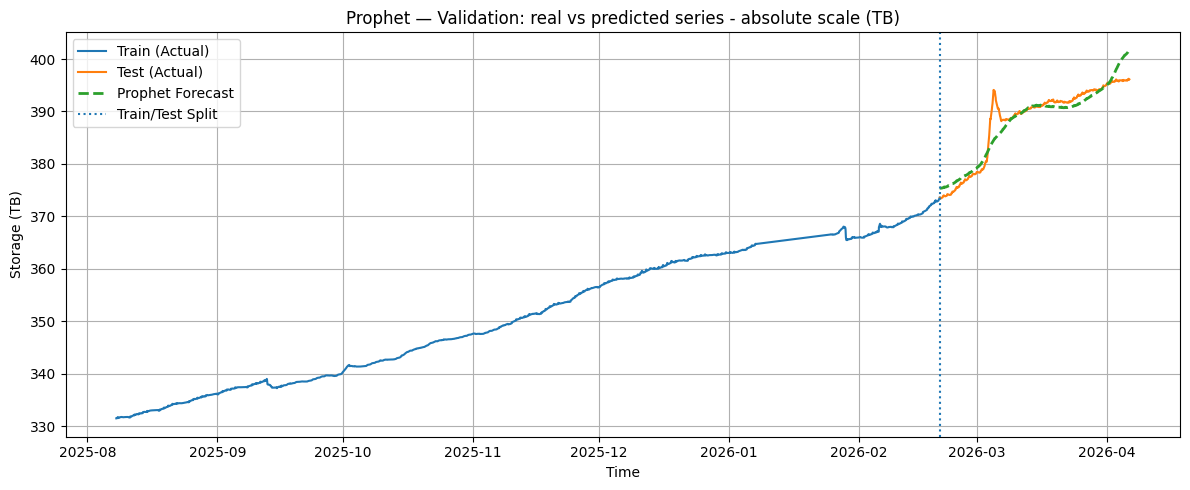

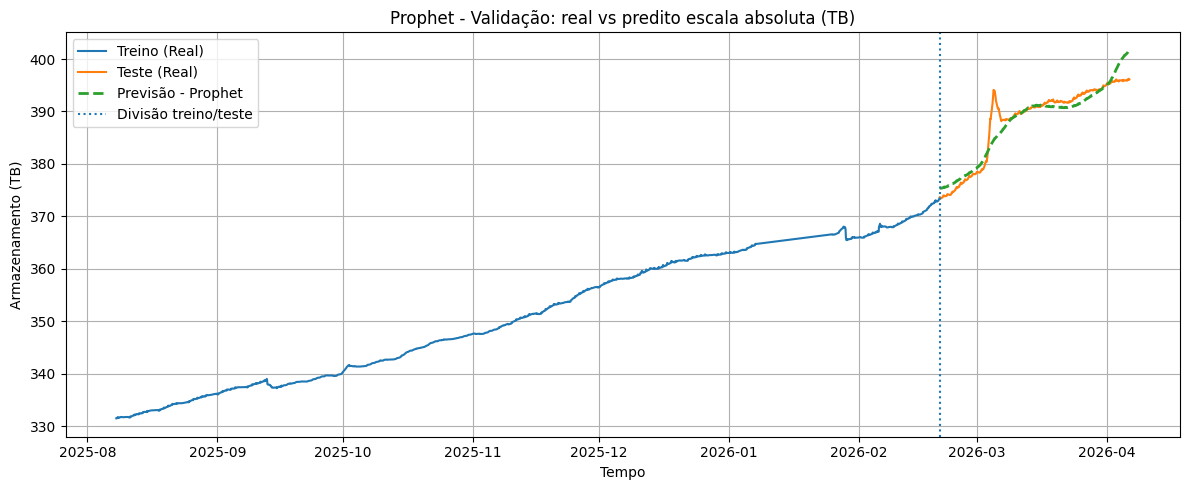

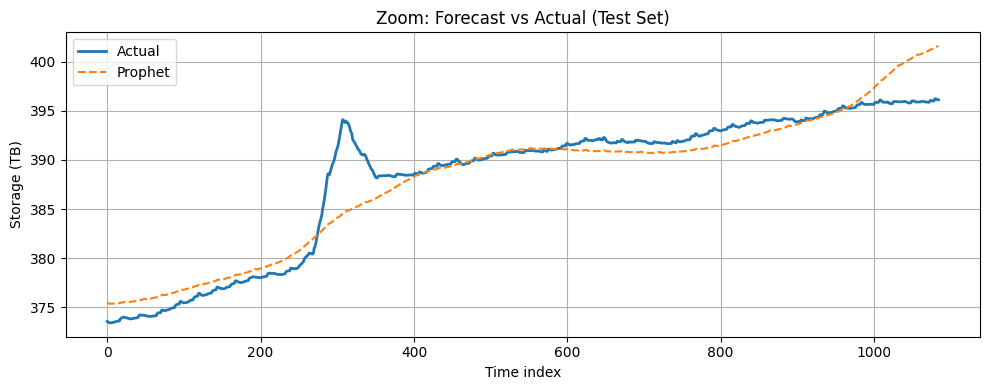

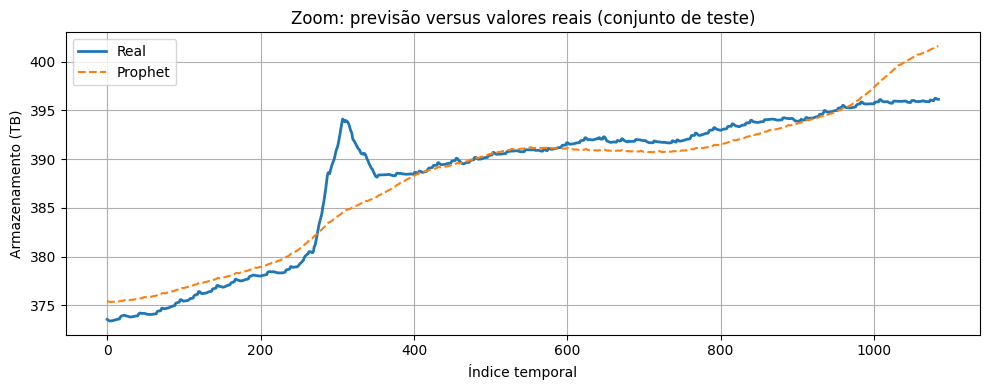


📊 Prophet - Forecast (TB):
Step 001: 396.126 TB
Step 002: 396.174 TB
Step 003: 396.209 TB
Step 004: 396.236 TB
Step 005: 396.270 TB
Step 006: 396.318 TB
Step 007: 396.375 TB
Step 008: 396.423 TB
Step 009: 396.457 TB
Step 010: 396.485 TB
Step 011: 396.526 TB
Step 012: 396.585 TB
Step 013: 396.651 TB
Step 014: 396.704 TB
Step 015: 396.740 TB
Step 016: 396.772 TB
Step 017: 396.824 TB
Step 018: 396.900 TB
Step 019: 396.985 TB
Step 020: 397.051 TB
...

🔮 Final forecast value (360 days ahead): 574.086 TB


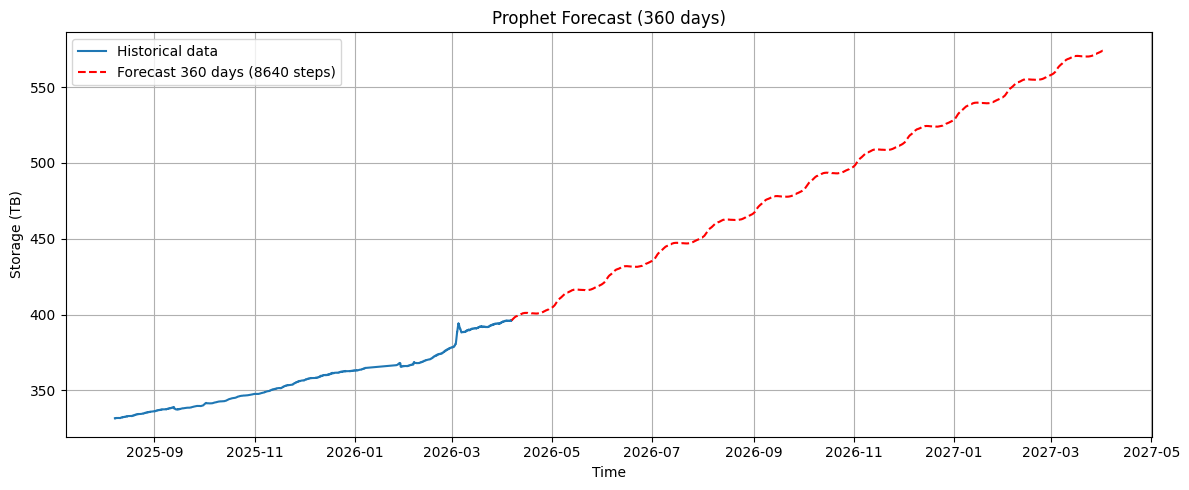

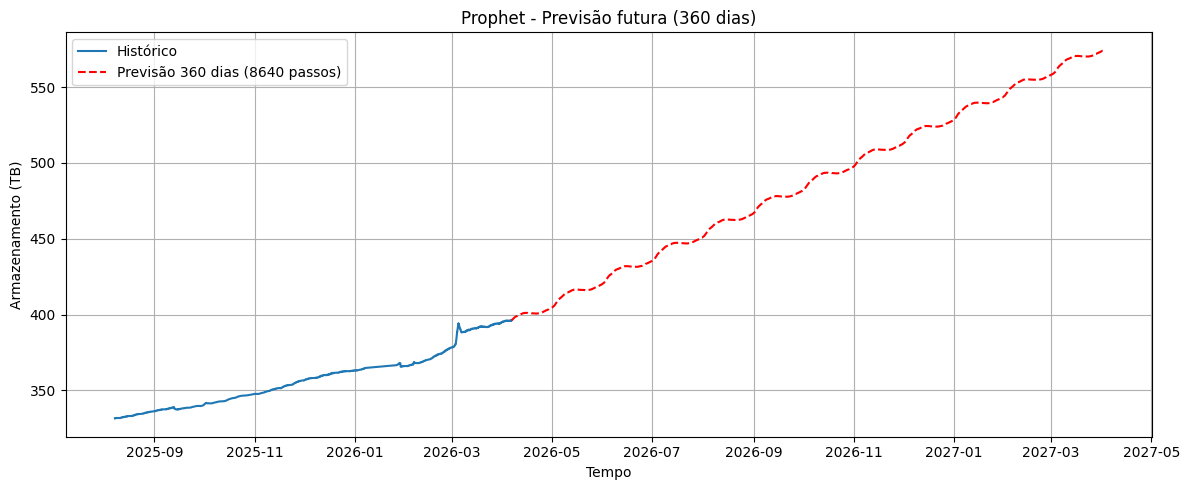


✅ Saved files:
- prophet_metrics_absolute.json
- prophet_metricas_absolutas.json
- prophet_validation_absolute.csv
- prophet_validacao_absoluta.csv
- prophet_future_forecast.csv
- prophet_forecast_futuro.csv
- prophet_train_test_forecast_en.png
- prophet_treino_teste_previsao_pt.png
- prophet_test_zoom_en.png
- prophet_zoom_teste_pt.png
- prophet_future_forecast_en.png
- prophet_forecast_futuro_pt.png


In [ ]:
# ============================================================
# ✅ PLOT 1 — TRAIN / TEST / FORECAST
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(train_prophet["ds"], train_prophet["y"] / 1e12, label="Train (Actual)")
plt.plot(test_prophet["ds"], y_test_abs_prophet_tb, label="Test (Actual)")
plt.plot(test_prophet["ds"], y_pred_abs_prophet_tb, linestyle="--", linewidth=2, label="Prophet Forecast")
plt.axvline(test_prophet["ds"].iloc[0], linestyle=":", label="Train/Test Split")
plt.title("Prophet — Validation: real vs predicted series - absolute scale (TB)")
plt.xlabel("Time")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prophet_train_test_forecast_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(train_prophet["ds"], train_prophet["y"] / 1e12, label="Treino (Real)")
plt.plot(test_prophet["ds"], y_test_abs_prophet_tb, label="Teste (Real)")
plt.plot(test_prophet["ds"], y_pred_abs_prophet_tb, linestyle="--", linewidth=2, label="Previsão - Prophet")
plt.axvline(test_prophet["ds"].iloc[0], linestyle=":", label="Divisão treino/teste")
plt.title("Prophet - Validação: real vs predito escala absoluta (TB)")
plt.xlabel("Tempo")
plt.ylabel("Armazenamento (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prophet_treino_teste_previsao_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ✅ PLOT 2 — ZOOM NO TESTE
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(y_test_abs_prophet_tb, label="Actual", linewidth=2)
plt.plot(y_pred_abs_prophet_tb, linestyle="--", label="Prophet")
plt.title("Zoom: Forecast vs Actual (Test Set)")
plt.xlabel("Time index")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prophet_test_zoom_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(y_test_abs_prophet_tb, label="Real", linewidth=2)
plt.plot(y_pred_abs_prophet_tb, linestyle="--", label="Prophet")
plt.title("Zoom: previsão versus valores reais (conjunto de teste)")
plt.xlabel("Índice temporal")
plt.ylabel("Armazenamento (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prophet_zoom_teste_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# ✅ PREVISÃO FUTURA
# ============================================================
freq_alias = "H" if is_hourly else "D"

last_timestamp = prophet_df["ds"].iloc[-1]

future_only = pd.DataFrame({
    "ds": pd.date_range(
        start=last_timestamp + pd.to_timedelta(1, unit="h" if is_hourly else "D"),
        periods=FORECAST_STEPS,
        freq=freq_alias
    )
})
'''

last_train_time = train_prophet["ds"].iloc[-1]

future_only = pd.DataFrame({
    "ds": pd.date_range(
        start=last_train_time + pd.Timedelta(hours=1),
        periods=FORECAST_STEPS,
        freq="H"
    )
})

'''
forecast_future = model_prophet.predict(future_only)



# ============================================================
# 🔥 FIX: align forecast with last observed value
# ============================================================
last_real_value = prophet_df["y"].iloc[-1]  # último valor REAL da série
first_forecast_value = forecast_future["yhat"].iloc[0]

offset = last_real_value - first_forecast_value
forecast_future["yhat"] += offset


forecast_abs_prophet = forecast_future["yhat"].to_numpy(dtype=np.float64)
forecast_tb_prophet = forecast_abs_prophet / 1e12
x_fore_prophet = np.arange(len(series), len(series) + len(forecast_tb_prophet))

print("\n📊 Prophet - Forecast (TB):")
for i, val in enumerate(forecast_tb_prophet[:20], start=1):
    print(f"Step {i:03d}: {val:.3f} TB")
print("...")
print(f"\n🔮 Final forecast value ({FORECAST_DAYS} days ahead): {forecast_tb_prophet[-1]:.3f} TB")

df_forecast_prophet = pd.DataFrame({
    "step": np.arange(1, FORECAST_STEPS + 1),
    "ds": future_only["ds"].astype(str).values,
    "forecast_tb": forecast_tb_prophet
})
df_forecast_prophet.to_csv("prophet_future_forecast.csv", index=False)
df_forecast_prophet.to_csv("prophet_forecast_futuro.csv", index=False)

# ============================================================
# ✅ PLOT 3 — HISTÓRICO + PREVISÃO FUTURA
# ============================================================
plt.figure(figsize=(12, 5))
if "Time" in df.columns:
    plt.plot(df["Time"], np.asarray(series, dtype=np.float64) / 1e12, label="Historical data")
    plt.plot(future_only["ds"], forecast_tb_prophet, "r--", label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} steps)")
else:
    plt.plot(np.asarray(series, dtype=np.float64) / 1e12, label="Historical data")
    plt.plot(x_fore_prophet, forecast_tb_prophet, "r--", label=f"Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} steps)")
plt.title(f"Prophet Forecast ({FORECAST_DAYS} days)")
plt.xlabel("Time")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prophet_future_forecast_en.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
if "Time" in df.columns:
    plt.plot(df["Time"], np.asarray(series, dtype=np.float64) / 1e12, label="Histórico")
    plt.plot(future_only["ds"], forecast_tb_prophet, "r--", label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} passos)")
else:
    plt.plot(np.asarray(series, dtype=np.float64) / 1e12, label="Histórico")
    plt.plot(x_fore_prophet, forecast_tb_prophet, "r--", label=f"Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} passos)")
plt.title(f"Prophet - Previsão futura ({FORECAST_DAYS} dias)")
plt.xlabel("Tempo")
plt.ylabel("Armazenamento (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prophet_forecast_futuro_pt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n✅ Saved files:")
print("- prophet_metrics_absolute.json")
print("- prophet_metricas_absolutas.json")
print("- prophet_validation_absolute.csv")
print("- prophet_validacao_absoluta.csv")
print("- prophet_future_forecast.csv")
print("- prophet_forecast_futuro.csv")
print("- prophet_train_test_forecast_en.png")
print("- prophet_treino_teste_previsao_pt.png")
print("- prophet_test_zoom_en.png")
print("- prophet_zoom_teste_pt.png")
print("- prophet_future_forecast_en.png")
print("- prophet_forecast_futuro_pt.png")


In [ ]:
if SAVE == 1:
    # ============================================================
    # 💾 SAVE EVERYTHING - PROPHET
    # ============================================================

    import os
    import json
    import shutil
    import joblib
    import numpy as np
    from prophet.serialize import model_to_json


    MODEL_NAME = "prophet"

    os.makedirs(BASE_PATH, exist_ok=True)

    # ============================================================
    # 1) SAVE MODEL
    # ============================================================
    with open(f"{BASE_PATH}/{MODEL_NAME}_model.json", "w", encoding="utf-8") as f:
        f.write(model_to_json(model_prophet))

    # ============================================================
    # 2) SAVE SCALER (optional but useful for consistency)
    # ============================================================
    try:
        joblib.dump(scaler, f"{BASE_PATH}/{MODEL_NAME}_scaler.save")
    except:
        pass

    # ============================================================
    # 3) SAVE CONFIG
    # ============================================================
    config_prophet = {
        "model_type": "Prophet",
        "is_hourly": bool(is_hourly),
        "daily_seasonality": bool(is_hourly),
        "weekly_seasonality": True,
        "yearly_seasonality": False,
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0,
        "monthly_seasonality_added": bool(is_hourly),
        "monthly_period": 30.5 if is_hourly else None,
        "monthly_fourier_order": 8 if is_hourly else None,
        "forecast_steps": int(FORECAST_STEPS),
        "forecast_days": int(FORECAST_DAYS),
        "time_unit": str(time_unit) if "time_unit" in globals() else "hour",
        "split_prophet": int(split_prophet),
        "freq_alias": "H" if is_hourly else "D",
        "target_column": str(TARGET_COLUMN),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_config.json", "w", encoding="utf-8") as f:
        json.dump(config_prophet, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 4) SAVE METRICS
    # ============================================================
    metrics_prophet = {
        "mse_abs": float(mse_abs_prophet),
        "rmse_abs": float(rmse_abs_prophet),
        "r2_abs": float(r2_abs_prophet),
        "forecast_last_tb": float(forecast_tb_prophet[-1]),
    }

    with open(f"{BASE_PATH}/{MODEL_NAME}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics_prophet, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 5) SAVE DATAFRAMES AS CSV
    # ============================================================
    prophet_df.to_csv(f"{BASE_PATH}/prophet_full_dataframe.csv", index=False)
    train_prophet.to_csv(f"{BASE_PATH}/prophet_train_dataframe.csv", index=False)
    test_prophet.to_csv(f"{BASE_PATH}/prophet_test_dataframe.csv", index=False)
    future_only.to_csv(f"{BASE_PATH}/prophet_future_only.csv", index=False)
    forecast_test.to_csv(f"{BASE_PATH}/prophet_forecast_test_full.csv", index=False)
    forecast_future.to_csv(f"{BASE_PATH}/prophet_forecast_future_full.csv", index=False)

    # ============================================================
    # 6) SAVE MAIN ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy", y_test_abs_prophet)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy", y_pred_abs_prophet)

    np.save(f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy", y_test_abs_prophet_tb)
    np.save(f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy", y_pred_abs_prophet_tb)

    # ============================================================
    # 7) SAVE FORECAST
    # ============================================================
    np.save(f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy", forecast_abs_prophet)
    np.save(f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy", forecast_tb_prophet)

    # ============================================================
    # 8) SAVE SERIES / REFERENCES
    # ============================================================
    np.save(f"{BASE_PATH}/series_original.npy", series)

    if "Time" in df.columns:
        try:
            pd.DataFrame({"Time": pd.to_datetime(df["Time"], errors="coerce")}).to_csv(
                f"{BASE_PATH}/series_time_reference.csv", index=False
            )
        except:
            pass

    # ============================================================
    # 9) COPY EXISTING ARTIFACT FILES
    # ============================================================
    artifact_files = [
        "prophet_metrics_absolute.json",
        "prophet_metricas_absolutas.json",
        "prophet_validation_absolute.csv",
        "prophet_validacao_absoluta.csv",
        "prophet_future_forecast.csv",
        "prophet_forecast_futuro.csv",
        "prophet_train_test_forecast_en.png",
        "prophet_treino_teste_previsao_pt.png",
        "prophet_test_zoom_en.png",
        "prophet_zoom_teste_pt.png",
        "prophet_future_forecast_en.png",
        "prophet_forecast_futuro_pt.png",
    ]

    for fname in artifact_files:
        if os.path.exists(fname):
            dest = os.path.join(BASE_PATH, fname)
            if os.path.abspath(fname) != os.path.abspath(dest):
                shutil.copy2(fname, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All Prophet artifacts saved in:\n{BASE_PATH}")

In [31]:
if RELOAD == 1:
    # ============================================================
    # 🔄 RELOAD EVERYTHING - PROPHET
    # ============================================================

    import os
    import json
    import joblib
    import numpy as np
    import pandas as pd
    from prophet.serialize import model_from_json

    MODEL_NAME = "prophet"

    # ============================================================
    # FILE PATHS
    # ============================================================
    FILE_MODEL              = f"{BASE_PATH}/{MODEL_NAME}_model.json"
    FILE_SCALER             = f"{BASE_PATH}/{MODEL_NAME}_scaler.save"
    FILE_CONFIG             = f"{BASE_PATH}/{MODEL_NAME}_config.json"
    FILE_METRICS            = f"{BASE_PATH}/{MODEL_NAME}_metrics.json"

    FILE_FULL_DF            = f"{BASE_PATH}/prophet_full_dataframe.csv"
    FILE_TRAIN_DF           = f"{BASE_PATH}/prophet_train_dataframe.csv"
    FILE_TEST_DF            = f"{BASE_PATH}/prophet_test_dataframe.csv"
    FILE_FUTURE_ONLY        = f"{BASE_PATH}/prophet_future_only.csv"
    FILE_FORECAST_TEST_FULL = f"{BASE_PATH}/prophet_forecast_test_full.csv"
    FILE_FORECAST_FUTURE    = f"{BASE_PATH}/prophet_forecast_future_full.csv"

    FILE_Y_TEST_ABS         = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}.npy"
    FILE_Y_PRED_ABS         = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}.npy"
    FILE_Y_TEST_ABS_TB      = f"{BASE_PATH}/y_test_abs_{MODEL_NAME}_tb.npy"
    FILE_Y_PRED_ABS_TB      = f"{BASE_PATH}/y_pred_abs_{MODEL_NAME}_tb.npy"

    FILE_FORECAST_ABS       = f"{BASE_PATH}/forecast_abs_{MODEL_NAME}.npy"
    FILE_FORECAST_TB        = f"{BASE_PATH}/forecast_tb_{MODEL_NAME}.npy"

    FILE_SERIES             = f"{BASE_PATH}/series_original.npy"

    # ============================================================
    # LOAD MODEL
    # ============================================================
    with open(FILE_MODEL, "r", encoding="utf-8") as f:
        model_prophet_reloaded = model_from_json(f.read())

    # ============================================================
    # LOAD OPTIONAL SCALER
    # ============================================================
    scaler_prophet = None
    if os.path.exists(FILE_SCALER):
        scaler_prophet = joblib.load(FILE_SCALER)

    # ============================================================
    # LOAD CONFIG / METRICS
    # ============================================================
    with open(FILE_CONFIG, "r", encoding="utf-8") as f:
        config_prophet = json.load(f)

    with open(FILE_METRICS, "r", encoding="utf-8") as f:
        metrics_prophet = json.load(f)

    FORECAST_STEPS = config_prophet["forecast_steps"]
    FORECAST_DAYS  = config_prophet["forecast_days"]
    time_unit      = config_prophet["time_unit"]
    split_prophet  = config_prophet["split_prophet"]
    freq_alias     = config_prophet["freq_alias"]
    is_hourly      = config_prophet["is_hourly"]
    TARGET_COL_REF = config_prophet["target_column"]

    # ============================================================
    # LOAD TABLES
    # ============================================================
    prophet_df = pd.read_csv(FILE_FULL_DF)
    train_prophet = pd.read_csv(FILE_TRAIN_DF)
    test_prophet = pd.read_csv(FILE_TEST_DF)
    future_only = pd.read_csv(FILE_FUTURE_ONLY)
    forecast_test = pd.read_csv(FILE_FORECAST_TEST_FULL)
    forecast_future = pd.read_csv(FILE_FORECAST_FUTURE)

    for _df in [prophet_df, train_prophet, test_prophet, future_only, forecast_test, forecast_future]:
        if "ds" in _df.columns:
            _df["ds"] = pd.to_datetime(_df["ds"], errors="coerce")

    # ============================================================
    # LOAD ARRAYS
    # ============================================================
    y_test_abs_prophet = np.load(FILE_Y_TEST_ABS)
    y_pred_abs_prophet = np.load(FILE_Y_PRED_ABS)

    y_test_abs_prophet_tb = np.load(FILE_Y_TEST_ABS_TB)
    y_pred_abs_prophet_tb = np.load(FILE_Y_PRED_ABS_TB)

    forecast_abs_prophet = np.load(FILE_FORECAST_ABS)
    forecast_tb_prophet = np.load(FILE_FORECAST_TB)

    series = np.load(FILE_SERIES)

    # ============================================================
    # OPTIONAL RECOMPUTE
    # ============================================================
    future_test_recomputed = test_prophet[["ds"]].copy()
    forecast_test_recomputed = model_prophet_reloaded.predict(future_test_recomputed)
    y_pred_abs_prophet_recomputed = forecast_test_recomputed["yhat"].to_numpy(dtype=np.float64)

    forecast_future_recomputed = model_prophet_reloaded.predict(future_only[["ds"]].copy())
    forecast_abs_prophet_recomputed = forecast_future_recomputed["yhat"].to_numpy(dtype=np.float64)
    forecast_tb_prophet_recomputed = forecast_abs_prophet_recomputed / 1e12

    # ============================================================
    # SUMMARY
    # ============================================================
    print("\n✅ RELOAD EVERYTHING - PROPHET COMPLETED")
    print(f"Base path              : {BASE_PATH}")
    print(f"Model                  : {MODEL_NAME}")
    print(f"Forecast steps         : {FORECAST_STEPS}")
    print(f"Forecast days          : {FORECAST_DAYS}")
    print(f"Time unit              : {time_unit}")
    print(f"Split prophet          : {split_prophet}")
    print(f"Frequency alias        : {freq_alias}")
    print(f"Is hourly              : {is_hourly}")
    print(f"Target column          : {TARGET_COL_REF}")

    print("\n📊 Metrics")
    print(f"MSE abs                : {metrics_prophet['mse_abs']:.6e}")
    print(f"RMSE abs               : {metrics_prophet['rmse_abs']:.6e}")
    print(f"R² abs                 : {metrics_prophet['r2_abs']:.6f}")
    print(f"Final forecast TB      : {metrics_prophet['forecast_last_tb']:.3f}")

    print("\n📐 Shapes")
    print(f"prophet_df             : {prophet_df.shape}")
    print(f"train_prophet          : {train_prophet.shape}")
    print(f"test_prophet           : {test_prophet.shape}")
    print(f"y_test_abs_prophet     : {y_test_abs_prophet.shape}")
    print(f"y_pred_abs_prophet     : {y_pred_abs_prophet.shape}")
    print(f"forecast_tb_prophet    : {forecast_tb_prophet.shape}")

    # ============================================================
    # PACKAGE EVERYTHING
    # ============================================================
    artifacts_prophet = {
        "model_prophet_reloaded": model_prophet_reloaded,
        "scaler_prophet": scaler_prophet,
        "config_prophet": config_prophet,
        "metrics_prophet": metrics_prophet,
        "prophet_df": prophet_df,
        "train_prophet": train_prophet,
        "test_prophet": test_prophet,
        "future_only": future_only,
        "forecast_test": forecast_test,
        "forecast_future": forecast_future,
        "y_test_abs_prophet": y_test_abs_prophet,
        "y_pred_abs_prophet": y_pred_abs_prophet,
        "y_test_abs_prophet_tb": y_test_abs_prophet_tb,
        "y_pred_abs_prophet_tb": y_pred_abs_prophet_tb,
        "forecast_abs_prophet": forecast_abs_prophet,
        "forecast_tb_prophet": forecast_tb_prophet,
        "series": series,
        "forecast_test_recomputed": forecast_test_recomputed,
        "y_pred_abs_prophet_recomputed": y_pred_abs_prophet_recomputed,
        "forecast_future_recomputed": forecast_future_recomputed,
        "forecast_abs_prophet_recomputed": forecast_abs_prophet_recomputed,
        "forecast_tb_prophet_recomputed": forecast_tb_prophet_recomputed,
    }

    print("\n✅ artifacts_prophet dictionary created.")



✅ RELOAD EVERYTHING - PROPHET COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : prophet
Forecast steps         : 8640
Forecast days          : 360
Time unit              : hour
Split prophet          : 4340
Frequency alias        : H
Is hourly              : True
Target column          : Value

📊 Metrics
MSE abs                : 4.757351e+24
RMSE abs               : 2.181135e+12
R² abs                 : 0.908009
Final forecast TB      : 574.086

📐 Shapes
prophet_df             : (5425, 2)
train_prophet          : (4340, 2)
test_prophet           : (1085, 2)
y_test_abs_prophet     : (1085,)
y_pred_abs_prophet     : (1085,)
forecast_tb_prophet    : (8640,)

✅ artifacts_prophet dictionary created.


In [ ]:
model_prophet_reloaded.params['k']   # growth rate
model_prophet_reloaded.params['m']   # offset
model_prophet_reloaded.params['delta']
model_prophet_reloaded.params['beta']


# MOE

In [32]:
if RELOAD == 1:
    # ============================================================
    # 📂 RELOAD EVERYTHING - MIXTURE OF EXPERTS (MOE)
    # ============================================================

    import os
    import json
    import numpy as np
    import pandas as pd
    import tensorflow as tf

    # ============================================================
    # 📁 PATH
    # ============================================================
    SAVE_DIR_MOE = os.path.join(BASE_PATH, "artifacts_moe")

    if not os.path.exists(SAVE_DIR_MOE):
        raise FileNotFoundError(f"Pasta não encontrada: {SAVE_DIR_MOE}")

    print(f"📂 Carregando artefatos de: {SAVE_DIR_MOE}")

    # ============================================================
    # 🧠 MODEL
    # ============================================================
    model_moe = None
    model_path = os.path.join(SAVE_DIR_MOE, "moe_gating_model.keras")

    if os.path.exists(model_path):
        model_moe = tf.keras.models.load_model(model_path)
        print("✅ Modelo MOE carregado")
    else:
        print("⚠️ Modelo MOE não encontrado")

    # ============================================================
    # 📊 JSON / CONFIG
    # ============================================================
    moe_config = None
    config_path = os.path.join(SAVE_DIR_MOE, "moe_config.json")

    if os.path.exists(config_path):
        with open(config_path, "r", encoding="utf-8") as f:
            moe_config = json.load(f)
        print("✅ Config carregada")
    else:
        print("⚠️ Config não encontrada")

    moe_metrics = None
    metrics_path = os.path.join(SAVE_DIR_MOE, "moe_metrics.json")

    if os.path.exists(metrics_path):
        with open(metrics_path, "r", encoding="utf-8") as f:
            moe_metrics = json.load(f)
        print("✅ Métricas carregadas")
    else:
        print("⚠️ Métricas não encontradas")

    # ============================================================
    # 📄 CSV
    # ============================================================
    def _load_csv(name):
        path = os.path.join(SAVE_DIR_MOE, name)

        if os.path.exists(path):
            print(f"✅ {name}")
            return pd.read_csv(path)

        print(f"⚠️ {name} não encontrado")
        return None

    df_moe_val_pred = _load_csv(
        "moe_validation_predictions_tb.csv"
    )

    df_moe_val_w = _load_csv(
        "moe_validation_weights.csv"
    )

    df_moe_forecast = _load_csv(
        "moe_future_forecast_tb.csv"
    )

    df_moe_fore_w = _load_csv(
        "moe_future_weights.csv"
    )

    # ============================================================
    # 🔢 NUMPY
    # ============================================================
    def _load_npy(name):
        path = os.path.join(SAVE_DIR_MOE, name)

        if os.path.exists(path):
            print(f"✅ {name}")
            return np.load(path)

        print(f"⚠️ {name} não encontrado")
        return None

    moe_feature_mu = _load_npy(
        "moe_feature_mu.npy"
    )

    moe_feature_sd = _load_npy(
        "moe_feature_sd.npy"
    )

    moe_loss = _load_npy(
        "moe_history_loss.npy"
    )

    moe_val_loss = _load_npy(
        "moe_history_val_loss.npy"
    )

    # ============================================================
    # 🎯 RECONSTRUCT VALIDATION ARRAYS
    # ============================================================
    y_test_abs_moe_tb = None
    y_pred_abs_moe_tb = None

    if df_moe_val_pred is not None:

        numeric_val = df_moe_val_pred.select_dtypes(
            include=np.number
        )

        if numeric_val.shape[1] >= 2:
            y_test_abs_moe_tb = numeric_val.iloc[:, 0].to_numpy()
            y_pred_abs_moe_tb = numeric_val.iloc[:, 1].to_numpy()

    # ============================================================
    # 🎯 RECONSTRUCT VALIDATION WEIGHTS
    # ============================================================
    weights_validation = None

    if df_moe_val_w is not None:
        weights_validation = (
            df_moe_val_w
            .select_dtypes(include=np.number)
            .to_numpy()
        )

    # ============================================================
    # 🎯 RECONSTRUCT FUTURE FORECAST
    # ============================================================
    forecast_abs_moe_tb = None
    final_forecast_tb = np.nan

    if df_moe_forecast is not None:

        forecast_cols = [
            c for c in df_moe_forecast.columns
            if "forecast" in c.lower()
            or "pred" in c.lower()
        ]

        if forecast_cols:
            forecast_column = forecast_cols[0]

        else:
            numeric_forecast = (
                df_moe_forecast
                .select_dtypes(include=np.number)
            )

            if numeric_forecast.shape[1] > 0:
                forecast_column = numeric_forecast.columns[-1]
            else:
                forecast_column = None

        if forecast_column is not None:
            forecast_abs_moe_tb = (
                df_moe_forecast[forecast_column]
                .to_numpy()
            )

            if len(forecast_abs_moe_tb) > 0:
                final_forecast_tb = forecast_abs_moe_tb[-1]

    # ============================================================
    # 🎯 RECONSTRUCT FUTURE WEIGHTS
    # ============================================================
    weights_future = None

    if df_moe_fore_w is not None:
        weights_future = (
            df_moe_fore_w
            .select_dtypes(include=np.number)
            .to_numpy()
        )

    # ============================================================
    # 🎯 OUTPUT FINAL PADRONIZADO
    # ============================================================
    artifacts_moe = {
        "model": model_moe,
        "config": moe_config,
        "metrics": moe_metrics,
        "validation_predictions": df_moe_val_pred,
        "validation_weights": df_moe_val_w,
        "forecast": df_moe_forecast,
        "forecast_weights": df_moe_fore_w,
        "feature_mu": moe_feature_mu,
        "feature_sd": moe_feature_sd,
        "loss": moe_loss,
        "val_loss": moe_val_loss,
        "y_test_abs_moe_tb": y_test_abs_moe_tb,
        "y_pred_abs_moe_tb": y_pred_abs_moe_tb,
        "weights_validation": weights_validation,
        "forecast_abs_moe_tb": forecast_abs_moe_tb,
        "weights_future": weights_future,
    }

    # ============================================================
    # 📋 RELOAD SUMMARY
    # ============================================================
    print("\n" + "=" * 60)
    print("RELOAD EVERYTHING - MOE COMPLETED")
    print("=" * 60)

    print(f"Base path              : {BASE_PATH}")
    print("Model                  : moe")

    # ------------------------------------------------------------
    # CONFIG
    # ------------------------------------------------------------
    if moe_config is not None:

        experts = moe_config.get(
            "experts",
            []
        )

        forecast_steps = moe_config.get(
            "forecast_steps",
            None
        )

        forecast_days = moe_config.get(
            "forecast_days",
            forecast_steps
        )

        time_unit = moe_config.get(
            "time_unit",
            "day"
        )

        print(f"Experts                : {experts}")
        print(f"N experts              : {len(experts)}")
        print(f"Forecast steps         : {forecast_steps}")
        print(f"Forecast days          : {forecast_days}")
        print(f"Time unit              : {time_unit}")

    # ============================================================
    # 📊 METRICS
    # ============================================================
    print("\n📊 Metrics")

    if moe_metrics is not None:

        if "RMSE_TB" in moe_metrics:
            print(
                f"RMSE                   : "
                f"{moe_metrics['RMSE_TB']:.6f}"
            )

        if "MAE_TB" in moe_metrics:
            print(
                f"MAE                    : "
                f"{moe_metrics['MAE_TB']:.6f}"
            )

        if "R2" in moe_metrics:
            print(
                f"R²                     : "
                f"{moe_metrics['R2']:.6f}"
            )

    if not np.isnan(final_forecast_tb):
        print(
            f"Final forecast TB      : "
            f"{final_forecast_tb:.3f}"
        )

    # ============================================================
    # 📐 SHAPES
    # ============================================================
    print("\n📐 Shapes")

    if y_test_abs_moe_tb is not None:
        print(
            f"y_test_abs_moe_tb      : "
            f"{y_test_abs_moe_tb.shape}"
        )

    if y_pred_abs_moe_tb is not None:
        print(
            f"y_pred_abs_moe_tb      : "
            f"{y_pred_abs_moe_tb.shape}"
        )

    if weights_validation is not None:
        print(
            f"weights_validation     : "
            f"{weights_validation.shape}"
        )

    if forecast_abs_moe_tb is not None:
        print(
            f"forecast_abs_moe_tb    : "
            f"{forecast_abs_moe_tb.shape}"
        )

    if weights_future is not None:
        print(
            f"weights_future         : "
            f"{weights_future.shape}"
        )

    print("\n✅ artifacts_moe dictionary created.")
    print(
        "Chaves disponíveis:",
        list(artifacts_moe.keys())
    )

📂 Carregando artefatos de: /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026/artifacts_moe
✅ Modelo MOE carregado
✅ Config carregada
✅ Métricas carregadas
✅ moe_validation_predictions_tb.csv
✅ moe_validation_weights.csv
✅ moe_future_forecast_tb.csv
✅ moe_future_weights.csv
✅ moe_feature_mu.npy
✅ moe_feature_sd.npy
✅ moe_history_loss.npy
✅ moe_history_val_loss.npy

RELOAD EVERYTHING - MOE COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : moe
Experts                : ['MLP', 'LSTM', 'GRU', 'PINT', 'TFKAN', 'EXP', 'ARIMA', 'PROPHET']
N experts              : 8
Forecast steps         : 8640
Forecast days          : 360
Time unit              : day

📊 Metrics
RMSE                   : 2.746200
MAE                    : 1.880274
R²                     : 0.842799
Final forecast TB      : 8639.000

📐 Shapes
y_test_abs_moe_tb      : (1061,)
y_pred_abs_moe_tb      : (1061,)
w

In [21]:
if RELOAD == 1:
    # ============================================================
    # 📂 LOAD EVERYTHING - MIXTURE OF EXPERTS (BASE_PATH)
    # ============================================================

    import os
    import json
    import numpy as np
    import pandas as pd
    import tensorflow as tf

    # ============================================================
    # 📁 Caminho
    # ============================================================
    SAVE_DIR_MOE = os.path.join(BASE_PATH, "artifacts_moe")

    if not os.path.exists(SAVE_DIR_MOE):
        raise FileNotFoundError(f"Pasta não encontrada: {SAVE_DIR_MOE}")

    print(f"📂 Carregando artefatos de: {SAVE_DIR_MOE}")

    # ============================================================
    # 🧠 MODEL
    # ============================================================
    model_moe = None
    model_path = os.path.join(SAVE_DIR_MOE, "moe_gating_model.keras")

    if os.path.exists(model_path):
        model_moe = tf.keras.models.load_model(model_path)
        print("✅ Modelo MOE carregado")
    else:
        print("⚠️ Modelo não encontrado")

    # ============================================================
    # 📊 JSON / CONFIG
    # ============================================================
    moe_config = None
    config_path = os.path.join(SAVE_DIR_MOE, "moe_config.json")

    if os.path.exists(config_path):
        with open(config_path, "r", encoding="utf-8") as f:
            moe_config = json.load(f)
        print("✅ Config carregada")
    else:
        print("⚠️ Config não encontrada")

    moe_metrics = None
    metrics_path = os.path.join(SAVE_DIR_MOE, "moe_metrics.json")

    if os.path.exists(metrics_path):
        with open(metrics_path, "r", encoding="utf-8") as f:
            moe_metrics = json.load(f)
        print("✅ Métricas carregadas")

    # ============================================================
    # 📄 CSV
    # ============================================================
    def _load_csv(name):
        path = os.path.join(SAVE_DIR_MOE, name)
        if os.path.exists(path):
            print(f"✅ {name}")
            return pd.read_csv(path)
        else:
            print(f"⚠️ {name} não encontrado")
            return None

    df_moe_val_pred = _load_csv("moe_validation_predictions_tb.csv")
    df_moe_val_w    = _load_csv("moe_validation_weights.csv")
    df_moe_forecast = _load_csv("moe_future_forecast_tb.csv")
    df_moe_fore_w   = _load_csv("moe_future_weights.csv")

    # ============================================================
    # 🔢 NUMPY
    # ============================================================
    def _load_npy(name):
        path = os.path.join(SAVE_DIR_MOE, name)
        if os.path.exists(path):
            print(f"✅ {name}")
            return np.load(path)
        else:
            print(f"⚠️ {name} não encontrado")
            return None

    moe_feature_mu = _load_npy("moe_feature_mu.npy")
    moe_feature_sd = _load_npy("moe_feature_sd.npy")

    moe_loss = _load_npy("moe_history_loss.npy")
    moe_val_loss = _load_npy("moe_history_val_loss.npy")

    # ============================================================
    # 🎯 OUTPUT FINAL PADRONIZADO
    # ============================================================
    artifacts_moe = {
        "model": model_moe,
        "config": moe_config,
        "metrics": moe_metrics,
        "validation_predictions": df_moe_val_pred,
        "validation_weights": df_moe_val_w,
        "forecast": df_moe_forecast,
        "forecast_weights": df_moe_fore_w,
        "feature_mu": moe_feature_mu,
        "feature_sd": moe_feature_sd,
        "loss": moe_loss,
        "val_loss": moe_val_loss,
    }

    print("\n✅ MOE carregado com sucesso")
    print("Chaves disponíveis:", list(artifacts_moe.keys()))

📂 Carregando artefatos de: /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026/artifacts_moe
✅ Modelo MOE carregado
✅ Config carregada
✅ Métricas carregadas
✅ moe_validation_predictions_tb.csv
✅ moe_validation_weights.csv
✅ moe_future_forecast_tb.csv
✅ moe_future_weights.csv
✅ moe_feature_mu.npy
✅ moe_feature_sd.npy
✅ moe_history_loss.npy
✅ moe_history_val_loss.npy

✅ MOE carregado com sucesso
Chaves disponíveis: ['model', 'config', 'metrics', 'validation_predictions', 'validation_weights', 'forecast', 'forecast_weights', 'feature_mu', 'feature_sd', 'loss', 'val_loss']


In [22]:
# ============================================================
# 📋 RELOAD SUMMARY
# ============================================================

print("\nRELOAD EVERYTHING - MOE COMPLETED")

print(f"Base path              : {BASE_PATH}")
print("Model                  : moe")

if moe_config is not None:
    experts = moe_config.get("experts", [])
    forecast_steps = moe_config.get("forecast_steps", None)
    forecast_days = moe_config.get("forecast_days", forecast_steps)
    time_unit = moe_config.get("time_unit", "day")

    print(f"Experts                : {experts}")
    print(f"N experts              : {len(experts)}")
    print(f"Forecast steps         : {forecast_steps}")
    print(f"Forecast days          : {forecast_days}")
    print(f"Time unit              : {time_unit}")

print("\n📊 Metrics")

if moe_metrics is not None:
    rmse = moe_metrics.get("rmse", np.nan)
    mae = moe_metrics.get("mae", np.nan)
    r2 = moe_metrics.get("r2", np.nan)

    print(f"RMSE                   : {rmse:.6f}")
    print(f"MAE                    : {mae:.6f}")
    print(f"R²                     : {r2:.6f}")

if df_moe_forecast is not None:
    # Automatically find forecast column
    forecast_cols = [
        c for c in df_moe_forecast.columns
        if "forecast" in c.lower() or "pred" in c.lower()
    ]

    if forecast_cols:
        final_forecast_tb = df_moe_forecast[forecast_cols[0]].iloc[-1]
    else:
        # fallback: last numeric column
        numeric_cols = df_moe_forecast.select_dtypes(
            include=np.number
        ).columns
        final_forecast_tb = df_moe_forecast[numeric_cols[-1]].iloc[-1]

    print(f"Final forecast TB      : {final_forecast_tb:.3f}")

print("\n📐 Shapes")

if df_moe_val_pred is not None:
    # Expected validation CSV:
    # actual + prediction columns
    numeric = df_moe_val_pred.select_dtypes(include=np.number)

    if numeric.shape[1] >= 2:
        y_test_abs_moe_tb = numeric.iloc[:, 0].to_numpy()
        y_pred_abs_moe_tb = numeric.iloc[:, 1].to_numpy()

        print(f"y_test_abs_moe_tb      : {y_test_abs_moe_tb.shape}")
        print(f"y_pred_abs_moe_tb      : {y_pred_abs_moe_tb.shape}")

if df_moe_val_w is not None:
    weights_validation = df_moe_val_w.select_dtypes(
        include=np.number
    ).to_numpy()

    print(f"weights_validation     : {weights_validation.shape}")

if df_moe_forecast is not None:
    forecast_numeric = df_moe_forecast.select_dtypes(
        include=np.number
    )

    # use forecast column detected above when available
    if forecast_cols:
        forecast_abs_moe_tb = df_moe_forecast[
            forecast_cols[0]
        ].to_numpy()
    else:
        forecast_abs_moe_tb = forecast_numeric.iloc[:, -1].to_numpy()

    print(f"forecast_abs_moe_tb    : {forecast_abs_moe_tb.shape}")

print("\n✅ artifacts_moe dictionary created.")


RELOAD EVERYTHING - MOE COMPLETED
Base path              : /content/drive/MyDrive/Colab Notebooks/MESTRADO/RESULTADOS/0-TESE/360/08-abr-2026
Model                  : moe
Experts                : ['MLP', 'LSTM', 'GRU', 'PINT', 'TFKAN', 'EXP', 'ARIMA', 'PROPHET']
N experts              : 8
Forecast steps         : 8640
Forecast days          : 360
Time unit              : day

📊 Metrics
RMSE                   : nan
MAE                    : nan
R²                     : nan
Final forecast TB      : 8639.000

📐 Shapes
y_test_abs_moe_tb      : (1061,)
y_pred_abs_moe_tb      : (1061,)
weights_validation     : (1061, 8)
forecast_abs_moe_tb    : (8640,)

✅ artifacts_moe dictionary created.


In [ ]:
if RELOAD == 1:
    # ============================================================
    # ✅ RESTAURA VARIÁVEIS DO MOE APÓS RELOAD
    # ============================================================

    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np
    import pandas as pd

    df_moe_val_pred = artifacts_moe["validation_predictions"]
    df_moe_val_w    = artifacts_moe["validation_weights"]
    df_moe_forecast = artifacts_moe["forecast"]
    df_moe_fore_w   = artifacts_moe["forecast_weights"]

    moe_metrics = artifacts_moe["metrics"]

    # ------------------------------------------------------------
    # Restaura séries de validação
    # ------------------------------------------------------------
    y_test_abs_moe_tb = df_moe_val_pred["Actual_TB"].to_numpy(dtype=np.float64)
    y_pred_abs_moe_tb = df_moe_val_pred["MoE_TB"].to_numpy(dtype=np.float64)

    mean_ensemble_tb = df_moe_val_pred["Mean_Ensemble_TB"].to_numpy(dtype=np.float64)
    median_ensemble_tb = df_moe_val_pred["Median_Ensemble_TB"].to_numpy(dtype=np.float64)

    moe_weights_validation = df_moe_val_w.to_numpy(dtype=np.float64)

    # ------------------------------------------------------------
    # Restaura nomes dos especialistas
    # ------------------------------------------------------------
    if moe_metrics is not None and "experts" in moe_metrics:
        expert_names_moe = moe_metrics["experts"]
    else:
        expert_names_moe = [
            c.replace("weight_", "")
            for c in df_moe_val_w.columns
            if c.startswith("weight_")
        ]

    n_experts_moe = len(expert_names_moe)

    # ------------------------------------------------------------
    # Rename EXP -> ETS
    # ------------------------------------------------------------
    expert_names_moe = [
        "ETS" if str(x).upper() == "EXP" else x
        for x in expert_names_moe
    ]

    train_gate_size = moe_metrics.get("train_gate_size", None) if moe_metrics else None

    # ------------------------------------------------------------
    # Recalcula métricas
    # ------------------------------------------------------------
    mse_moe = mean_squared_error(y_test_abs_moe_tb, y_pred_abs_moe_tb)
    rmse_moe = np.sqrt(mse_moe)
    mae_moe = mean_absolute_error(y_test_abs_moe_tb, y_pred_abs_moe_tb)
    r2_moe = r2_score(y_test_abs_moe_tb, y_pred_abs_moe_tb)

    mse_mean = mean_squared_error(y_test_abs_moe_tb, mean_ensemble_tb)
    rmse_mean = np.sqrt(mse_mean)
    r2_mean = r2_score(y_test_abs_moe_tb, mean_ensemble_tb)

    mse_median = mean_squared_error(y_test_abs_moe_tb, median_ensemble_tb)
    rmse_median = np.sqrt(mse_median)
    r2_median = r2_score(y_test_abs_moe_tb, median_ensemble_tb)

    print("\n📊 Mixture of Experts — Validação/Teste em TB")
    print(f"MSE  : {mse_moe:.6f} TB²")
    print(f"RMSE : {rmse_moe:.6f} TB")
    print(f"MAE  : {mae_moe:.6f} TB")
    print(f"R²   : {r2_moe:.6f}")

    print("\n📊 Ensembles simples para referência")
    print(f"Média   -> RMSE={rmse_mean:.6f} TB | R²={r2_mean:.6f}")
    print(f"Mediana -> RMSE={rmse_median:.6f} TB | R²={r2_median:.6f}")

    # ------------------------------------------------------------
    # Restaura previsão futura, se existir
    # ------------------------------------------------------------
    if df_moe_forecast is not None:
        if "MoE_TB" in df_moe_forecast.columns:
            forecast_moe_tb = df_moe_forecast["MoE_TB"].to_numpy(dtype=np.float64)
        elif "Forecast_TB" in df_moe_forecast.columns:
            forecast_moe_tb = df_moe_forecast["Forecast_TB"].to_numpy(dtype=np.float64)
        else:
            forecast_moe_tb = df_moe_forecast.select_dtypes(include=[np.number]).iloc[:, -1].to_numpy(dtype=np.float64)

        y_forecast_abs_moe_tb = forecast_moe_tb

        print(f"\n🔮 Forecast futuro MoE carregado: {len(y_forecast_abs_moe_tb)} pontos")
        print(f"Valor final previsto: {y_forecast_abs_moe_tb[-1]:.3f} TB")

    if df_moe_fore_w is not None:
        moe_weights_future = df_moe_fore_w.to_numpy(dtype=np.float64)
        print(f"✅ Pesos futuros carregados: {moe_weights_future.shape}")

    # ------------------------------------------------------------
    # Atualiza dicionários globais
    # ------------------------------------------------------------
    if "comparison_data" in globals():
        comparison_data["MOE_TB"] = y_pred_abs_moe_tb

    if "forecast_dict" in globals() and "y_forecast_abs_moe_tb" in globals():
        forecast_dict["MOE"] = y_forecast_abs_moe_tb

    print("\n✅ Variáveis do MoE restauradas após RELOAD.")


📊 Mixture of Experts — Validação/Teste em TB
MSE  : 7.541616 TB²
RMSE : 2.746200 TB
MAE  : 1.880274 TB
R²   : 0.842799

📊 Ensembles simples para referência
Média   -> RMSE=5.027007 TB | R²=0.473244
Mediana -> RMSE=3.138704 TB | R²=0.794652

🔮 Forecast futuro MoE carregado: 8640 pontos
Valor final previsto: 810.673 TB
✅ Pesos futuros carregados: (8640, 8)

✅ Variáveis do MoE restauradas após RELOAD.


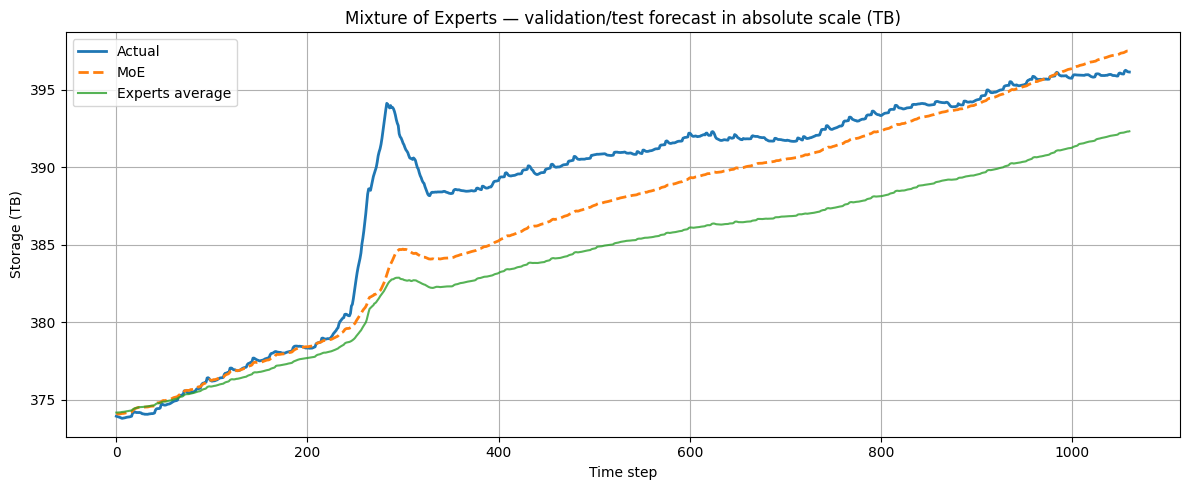

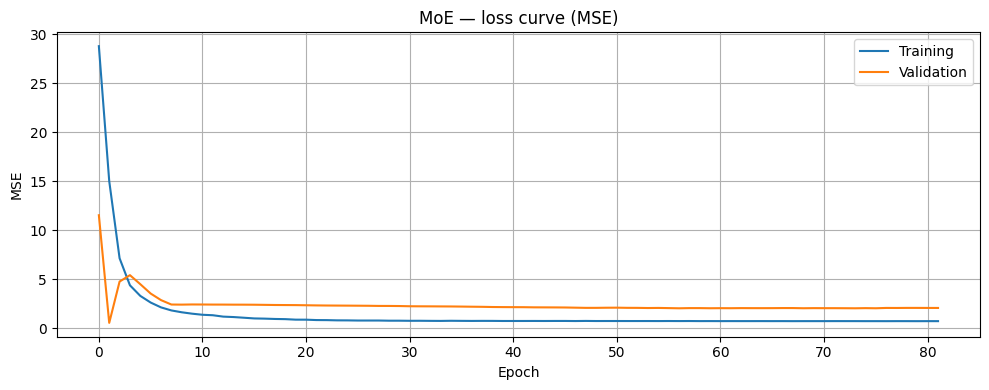

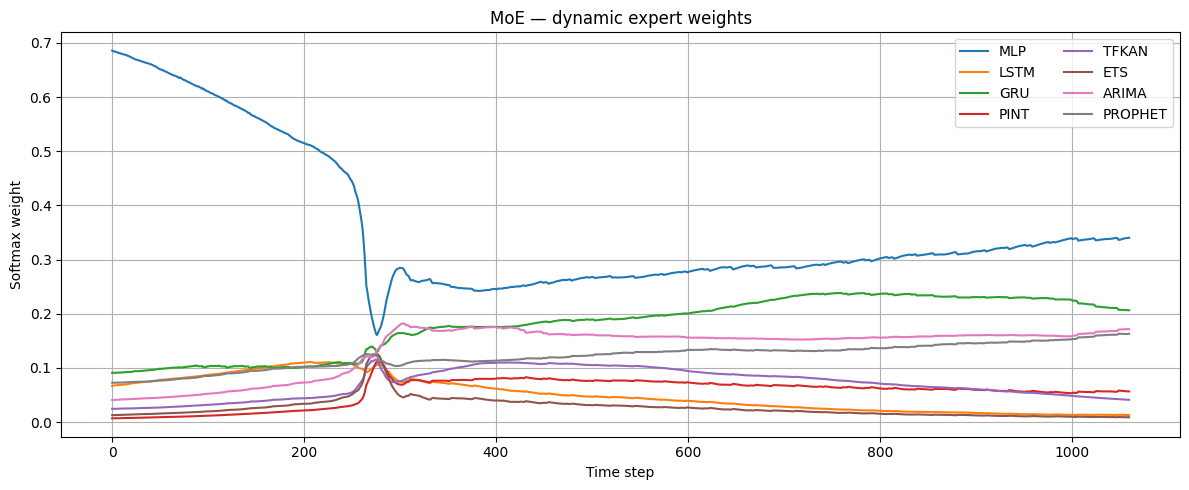

In [ ]:
if RELOAD == 1:
    # ------------------------------------------------------------
    # 4) Validation/Test Plots after RELOAD
    # ------------------------------------------------------------

    moe_loss = artifacts_moe["loss"]
    moe_val_loss = artifacts_moe["val_loss"]

    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Actual", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Experts average", alpha=0.8)

    plt.title("Mixture of Experts — validation/test forecast in absolute scale (TB)")
    plt.xlabel("Time step")
    plt.ylabel("Storage (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb_en.png", dpi=300, bbox_inches="tight")
    plt.show()


    plt.figure(figsize=(10, 4))

    if moe_loss is not None:
        plt.plot(moe_loss, label="Training")

    if moe_val_loss is not None:
        plt.plot(moe_val_loss, label="Validation")

    plt.title("MoE — loss curve (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve_en.png", dpi=300, bbox_inches="tight")
    plt.show()


    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)

    plt.title("MoE — dynamic expert weights")
    plt.xlabel("Time step")
    plt.ylabel("Softmax weight")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights_en.png", dpi=300, bbox_inches="tight")
    plt.show()

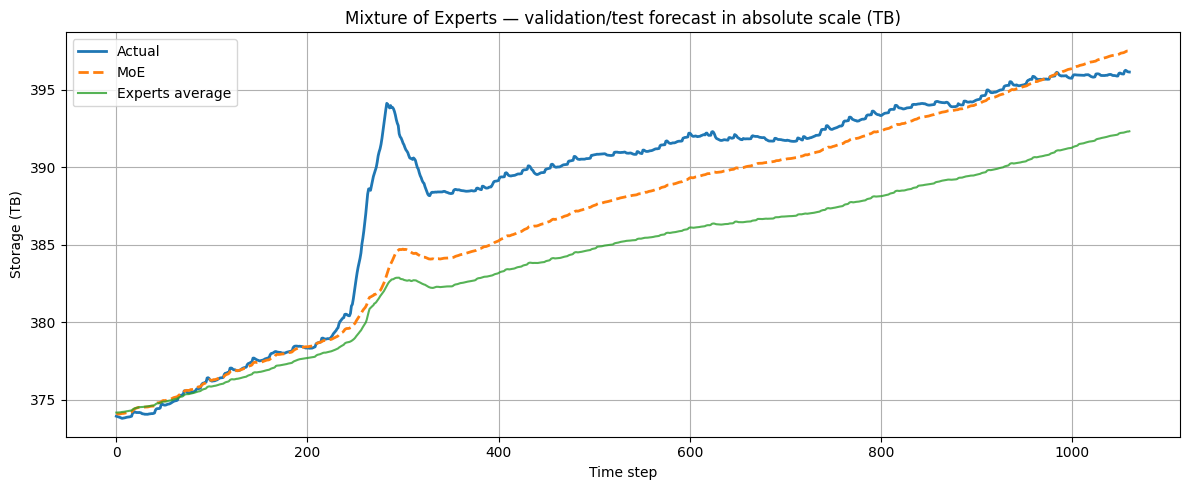

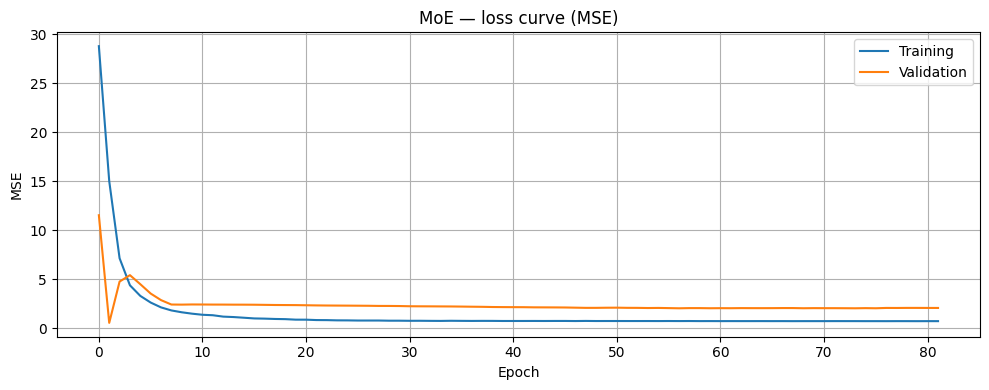

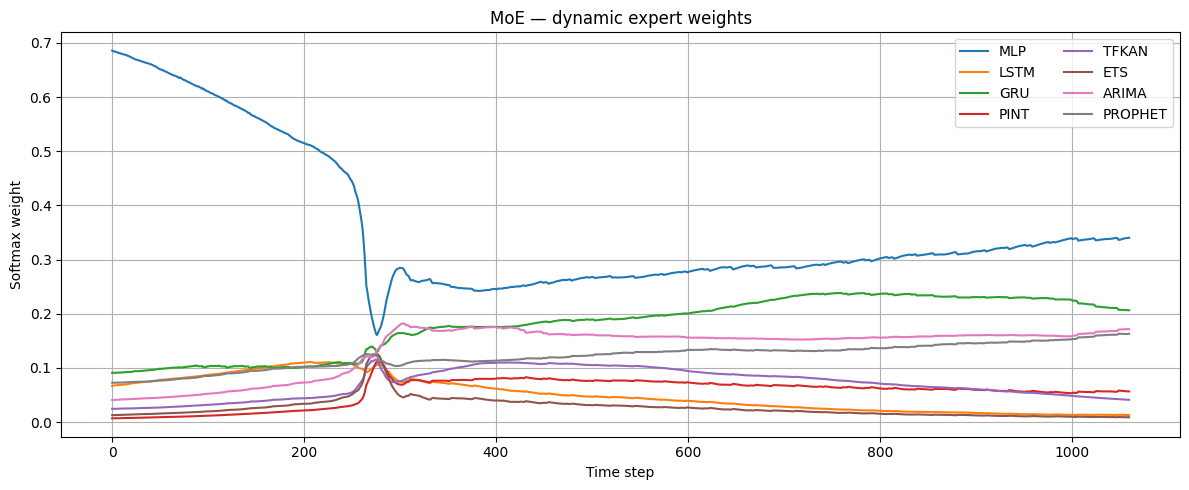

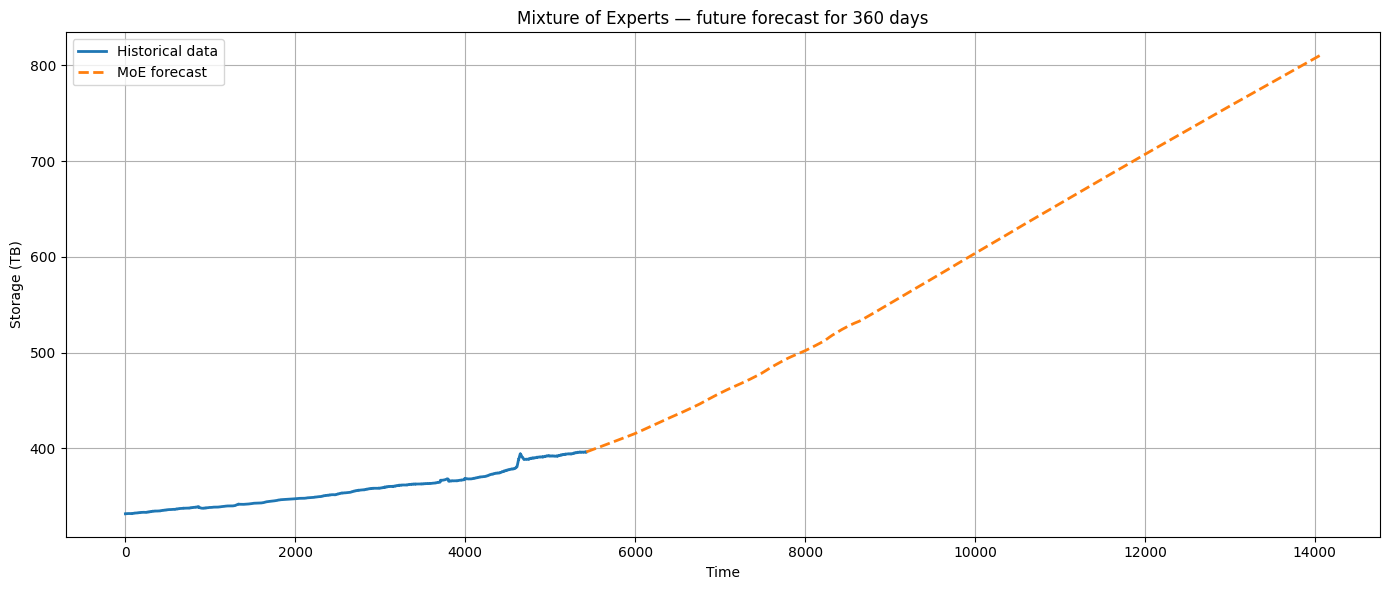

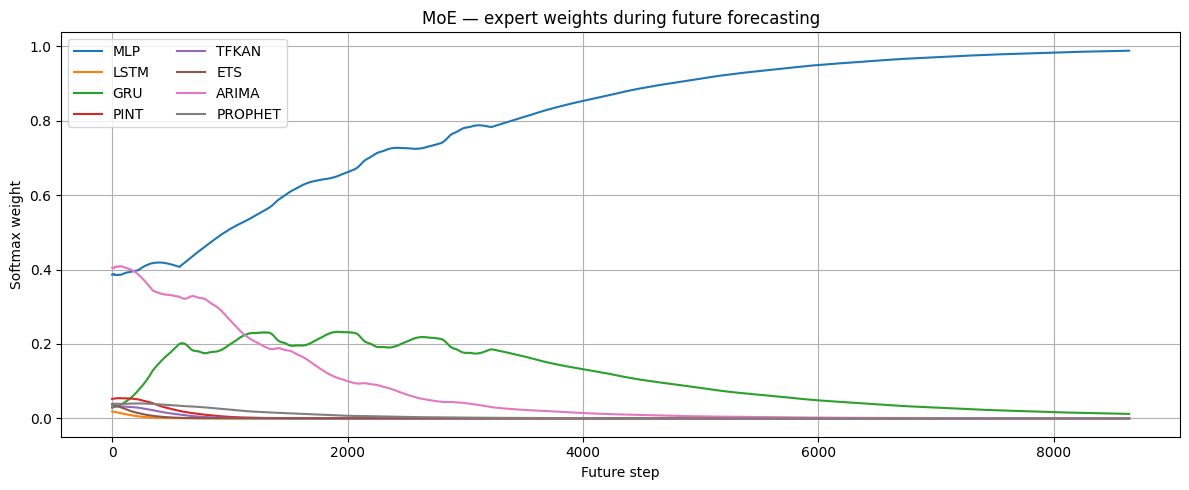


🔮 MOE final forecast value: 810.673 TB
✅ MoE plots generated successfully after RELOAD.


In [ ]:
if RELOAD == 1:
    # ============================================================
    # ✅ MOE — PLOTS COMPLETOS APÓS RELOAD
    # ============================================================

    import numpy as np
    import matplotlib.pyplot as plt

    # ------------------------------------------------------------
    # Recupera objetos carregados
    # ------------------------------------------------------------
    moe_loss = artifacts_moe["loss"]
    moe_val_loss = artifacts_moe["val_loss"]

    df_moe_forecast = artifacts_moe["forecast"]
    df_moe_fore_w = artifacts_moe["forecast_weights"]

    # ------------------------------------------------------------
    # Forecast futuro carregado
    # ------------------------------------------------------------
    forecast_abs_moe_tb = y_forecast_abs_moe_tb.copy()
    moe_weights_forecast = moe_weights_future.copy()
    expert_names_moe_future = expert_names_moe.copy()

    # ------------------------------------------------------------
    # Série histórica em TB
    # ------------------------------------------------------------
    series_arr = np.asarray(series, dtype=np.float64).ravel()

    if np.nanmedian(np.abs(series_arr)) > 1e6:
        series_tb = series_arr / 1e12
    else:
        series_tb = series_arr.copy()

    x_hist_moe = np.arange(len(series_tb))
    x_fore_moe = np.arange(len(series_tb), len(series_tb) + len(forecast_abs_moe_tb))

    # ============================================================
    # 1) Validation/Test Forecast — EN
    # ============================================================

    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Actual", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Experts average", alpha=0.8)

    plt.title("Mixture of Experts — validation/test forecast in absolute scale (TB)")
    plt.xlabel("Time step")
    plt.ylabel("Storage (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb_en.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ============================================================
    # 2) Loss Curve — EN
    # ============================================================

    plt.figure(figsize=(10, 4))

    if moe_loss is not None:
        plt.plot(moe_loss, label="Training")

    if moe_val_loss is not None:
        plt.plot(moe_val_loss, label="Validation")

    plt.title("MoE — loss curve (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve_en.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ============================================================
    # 3) Dynamic Expert Weights — EN
    # ============================================================

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)

    plt.title("MoE — dynamic expert weights")
    plt.xlabel("Time step")
    plt.ylabel("Softmax weight")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights_en.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ============================================================
    # 4) Future Forecast — EN
    # ============================================================

    plt.figure(figsize=(14, 6))
    plt.plot(x_hist_moe, series_tb, label="Historical data", linewidth=2)
    plt.plot(
        x_fore_moe,
        forecast_abs_moe_tb,
        label="MoE forecast",
        linestyle="--",
        linewidth=2
    )

    plt.title(f"Mixture of Experts — future forecast for {FORECAST_DAYS} days")
    plt.xlabel("Time")
    plt.ylabel("Storage (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_future_forecast_tb_en.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ============================================================
    # 5) Future Expert Weights — EN
    # ============================================================

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe_future):
        plt.plot(moe_weights_forecast[:, i], label=name)

    plt.title("MoE — expert weights during future forecasting")
    plt.xlabel("Future step")
    plt.ylabel("Softmax weight")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_future_weights_en.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\n🔮 MOE final forecast value: {forecast_abs_moe_tb[-1]:.3f} TB")
    print("✅ MoE plots generated successfully after RELOAD.")

In [ ]:
if RELOAD == 0:
    # ============================================================
    # 🔥 MIXTURE OF EXPERTS (MoE) — GATING NETWORK EM TB
    #    Combina MLP, LSTM, GRU, PINT, TFKAN, EXP, ARIMA e PROPHET
    #    Requer que as células anteriores já tenham gerado as previsões
    #    de validação/teste e forecasts futuros em escala absoluta/TB.
    # ============================================================

    import os
    import json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import tensorflow as tf

    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    from tensorflow.keras import layers, regularizers, Model
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from tensorflow.keras.optimizers import Adam

    # ------------------------------------------------------------
    # Configuração reprodutível
    # ------------------------------------------------------------
    SEED_MOE = 42
    np.random.seed(SEED_MOE)
    tf.random.set_seed(SEED_MOE)

    # ------------------------------------------------------------
    # Funções auxiliares
    # ------------------------------------------------------------
    def _to_1d_float(x):
        return np.asarray(x, dtype=np.float64).ravel()

    def _as_tb_from_candidates(*names):
        """
        Retorna o primeiro vetor existente entre os nomes informados.
        Heurística: se os valores parecem estar em bytes, converte para TB.
        """
        for name in names:
            if name in globals() and globals()[name] is not None:
                arr = _to_1d_float(globals()[name])
                if arr.size == 0:
                    continue
                # se estiver em bytes, os valores serão muito grandes
                if np.nanmedian(np.abs(arr)) > 1e6:
                    arr = arr / 1e12
                return arr
        return None

    def _align_matrix(pred_dict, y_true=None):
        """Alinha todos os vetores pelo menor comprimento disponível."""
        clean = {k: _to_1d_float(v) for k, v in pred_dict.items() if v is not None and len(v) > 0}
        if y_true is not None:
            y_true = _to_1d_float(y_true)
            n = min([len(y_true)] + [len(v) for v in clean.values()])
            y_true = y_true[:n]
        else:
            n = min([len(v) for v in clean.values()])
            y_true = None
        clean = {k: v[:n] for k, v in clean.items()}
        names = list(clean.keys())
        matrix = np.column_stack([clean[k] for k in names])
        return names, matrix, y_true

    def _make_gate_features(expert_matrix):
        """
        Features para a rede gating.
        Usa apenas informações disponíveis nas previsões dos especialistas:
        - previsões individuais dos modelos;
        - média/desvio/mínimo/máximo entre especialistas;
        - passo temporal normalizado.
        """
        X = np.asarray(expert_matrix, dtype=np.float64)
        n = X.shape[0]
        step = np.linspace(0.0, 1.0, n).reshape(-1, 1)
        stats = np.column_stack([
            X.mean(axis=1),
            X.std(axis=1),
            X.min(axis=1),
            X.max(axis=1),
        ])
        feats = np.column_stack([X, stats, step])
        return feats

    def _standardize_train_apply(X_train, X_apply):
        mu = X_train.mean(axis=0, keepdims=True)
        sd = X_train.std(axis=0, keepdims=True) + 1e-8
        return (X_train - mu) / sd, (X_apply - mu) / sd, mu, sd

    # ------------------------------------------------------------
    # 1) Coleta das previsões de validação/teste em TB
    # ------------------------------------------------------------
    validation_candidates = {
        "MLP":     _as_tb_from_candidates("y_pred_abs_mlp_tb", "y_pred_abs_mlp", "y_pred_mlp_tb"),
        "LSTM":    _as_tb_from_candidates("y_pred_abs_lstm_tb", "y_pred_abs_lstm", "y_pred_lstm_tb"),
        "GRU":     _as_tb_from_candidates("y_pred_abs_gru_tb", "y_pred_abs_gru", "y_pred_gru_tb"),
        "PINT":    _as_tb_from_candidates("y_pred_abs_pint_tb", "y_pred_abs_pint", "y_pred_pint_tb"),
        "TFKAN":   _as_tb_from_candidates("y_pred_abs_tfkan_tb", "y_pred_abs_tfkan", "y_pred_tfkan_tb"),
        "EXP":     _as_tb_from_candidates("y_pred_abs_exp_tb", "y_pred_abs_exp", "y_pred_exp_tb", "y_pred_tb"),
        "ARIMA":   _as_tb_from_candidates("y_pred_abs_arima_tb", "y_pred_abs_arima", "y_pred_arima_tb"),
        "PROPHET": _as_tb_from_candidates("y_pred_abs_prophet_tb", "y_pred_abs_prophet", "yhat_prophet_tb"),
    }

    # Alvo real em TB: usa o primeiro alvo absoluto disponível
    actual_validation_tb = _as_tb_from_candidates(
        "y_test_abs_arima_tb", "y_test_abs_mlp_tb", "y_test_abs_lstm_tb",
        "y_test_abs_gru_tb", "y_test_abs_pint_tb", "y_test_abs_tfkan_tb",
        "y_test_abs_exp_tb", "y_test_abs_prophet_tb", "y_test_tb"
    )

    # Remove modelos ausentes
    validation_candidates = {k: v for k, v in validation_candidates.items() if v is not None}

    if actual_validation_tb is None:
        raise ValueError("Nenhum vetor real de validação em TB foi encontrado. Execute as células de avaliação anteriores.")

    if len(validation_candidates) < 2:
        raise ValueError("MoE requer pelo menos dois especialistas com previsões de validação disponíveis.")

    expert_names_moe, expert_val_matrix_tb, y_val_moe_tb = _align_matrix(validation_candidates, actual_validation_tb)

    print("Especialistas usados no MoE:", expert_names_moe)
    print("Matriz de validação:", expert_val_matrix_tb.shape)
    print("Alvo real:", y_val_moe_tb.shape)

    # ------------------------------------------------------------
    # 2) Treino cronológico da rede gating
    #    Não usa shuffle para preservar a natureza temporal da série.
    # ------------------------------------------------------------
    X_gate = _make_gate_features(expert_val_matrix_tb)
    y_gate = y_val_moe_tb.reshape(-1, 1)

    n = len(y_gate)
    train_gate_size = int(n * 0.75)

    X_gate_train = X_gate[:train_gate_size]
    X_gate_valid = X_gate[train_gate_size:]
    y_gate_train = y_gate[:train_gate_size]
    y_gate_valid = y_gate[train_gate_size:]
    experts_train = expert_val_matrix_tb[:train_gate_size]
    experts_valid = expert_val_matrix_tb[train_gate_size:]

    X_gate_train_std, X_gate_valid_std, moe_feature_mu, moe_feature_sd = _standardize_train_apply(X_gate_train, X_gate_valid)

    n_experts_moe = expert_val_matrix_tb.shape[1]
    n_features_moe = X_gate_train_std.shape[1]

    features_in = layers.Input(shape=(n_features_moe,), name="gate_features")
    experts_in = layers.Input(shape=(n_experts_moe,), name="expert_predictions_tb")

    x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-5))(features_in)
    x = layers.Dropout(0.10)(x)
    x = layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x)
    weights = layers.Dense(n_experts_moe, activation="softmax", name="moe_softmax_weights")(x)

    # Produto ponderado entre pesos do gating e previsões dos especialistas
    moe_output = layers.Dot(axes=1, name="moe_weighted_prediction_tb")([weights, experts_in])

    model_moe = Model(inputs=[features_in, experts_in], outputs=moe_output, name="MixtureOfExperts_Gating")
    model_moe.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="mse",
        metrics=["mae"]
    )

    callbacks_moe = [
        EarlyStopping(monitor="val_loss", patience=80, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=30, min_lr=1e-6),
        ModelCheckpoint("moe_gating_model.keras", monitor="val_loss", save_best_only=True)
    ]

    history_moe = model_moe.fit(
        [X_gate_train_std.astype(np.float32), experts_train.astype(np.float32)],
        y_gate_train.astype(np.float32),
        validation_data=([X_gate_valid_std.astype(np.float32), experts_valid.astype(np.float32)], y_gate_valid.astype(np.float32)),
        epochs=200,
        batch_size=32,
        shuffle=False,
        callbacks=callbacks_moe,
        verbose=1
    )

    # ------------------------------------------------------------
    # 3) Predição MoE em toda a validação/teste
    # ------------------------------------------------------------
    X_gate_all_std = (X_gate - moe_feature_mu) / moe_feature_sd

    y_pred_abs_moe_tb = model_moe.predict(
        [X_gate_all_std.astype(np.float32), expert_val_matrix_tb.astype(np.float32)],
        verbose=0
    ).ravel()

    y_test_abs_moe_tb = y_val_moe_tb.copy()

    # Pesos dinâmicos aprendidos para cada especialista
    weight_model_moe = Model(inputs=model_moe.inputs, outputs=model_moe.get_layer("moe_softmax_weights").output)
    moe_weights_validation = weight_model_moe.predict(
        [X_gate_all_std.astype(np.float32), expert_val_matrix_tb.astype(np.float32)],
        verbose=0
    )

    # Baselines simples para comparação
    mean_ensemble_tb = expert_val_matrix_tb.mean(axis=1)
    median_ensemble_tb = np.median(expert_val_matrix_tb, axis=1)

    mse_moe = mean_squared_error(y_test_abs_moe_tb, y_pred_abs_moe_tb)
    rmse_moe = np.sqrt(mse_moe)
    mae_moe = mean_absolute_error(y_test_abs_moe_tb, y_pred_abs_moe_tb)
    r2_moe = r2_score(y_test_abs_moe_tb, y_pred_abs_moe_tb)

    mse_mean = mean_squared_error(y_test_abs_moe_tb, mean_ensemble_tb)
    rmse_mean = np.sqrt(mse_mean)
    r2_mean = r2_score(y_test_abs_moe_tb, mean_ensemble_tb)

    mse_median = mean_squared_error(y_test_abs_moe_tb, median_ensemble_tb)
    rmse_median = np.sqrt(mse_median)
    r2_median = r2_score(y_test_abs_moe_tb, median_ensemble_tb)

    print("\n📊 Mixture of Experts — Validação/Teste em TB")
    print(f"MSE  : {mse_moe:.6f} TB²")
    print(f"RMSE : {rmse_moe:.6f} TB")
    print(f"MAE  : {mae_moe:.6f} TB")
    print(f"R²   : {r2_moe:.6f}")

    print("\n📊 Ensembles simples para referência")
    print(f"Média   -> RMSE={rmse_mean:.6f} TB | R²={r2_mean:.6f}")
    print(f"Mediana -> RMSE={rmse_median:.6f} TB | R²={r2_median:.6f}")

    moe_metrics = {
        "MSE_TB2": float(mse_moe),
        "RMSE_TB": float(rmse_moe),
        "MAE_TB": float(mae_moe),
        "R2": float(r2_moe),
        "experts": expert_names_moe,
        "n_validation_points": int(len(y_test_abs_moe_tb)),
        "n_experts": int(n_experts_moe),
        "train_gate_size": int(train_gate_size),
    }

    pd.DataFrame({
        "time_index": np.arange(len(y_test_abs_moe_tb)),
        "Actual_TB": y_test_abs_moe_tb,
        "MoE_TB": y_pred_abs_moe_tb,
        "Mean_Ensemble_TB": mean_ensemble_tb,
        "Median_Ensemble_TB": median_ensemble_tb,
    }).to_csv("moe_validation_predictions_tb.csv", index=False)

    pd.DataFrame(moe_weights_validation, columns=[f"weight_{name}" for name in expert_names_moe]).to_csv(
        "moe_validation_weights.csv", index=False
    )

    with open("moe_metrics.json", "w", encoding="utf-8") as f:
        json.dump(moe_metrics, f, indent=4, ensure_ascii=False)

    np.save("moe_feature_mu.npy", moe_feature_mu)
    np.save("moe_feature_sd.npy", moe_feature_sd)
    np.save("moe_history_loss.npy", np.asarray(history_moe.history.get("loss", []), dtype=np.float64))
    np.save("moe_history_val_loss.npy", np.asarray(history_moe.history.get("val_loss", []), dtype=np.float64))

    # ------------------------------------------------------------
    # 4) Gráficos de validação/teste
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Real", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Média dos especialistas", alpha=0.8)
    plt.title("Mixture of Experts — validação/teste em escala absoluta (TB)")
    plt.xlabel("Passo temporal")
    plt.ylabel("Armazenamento (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history_moe.history["loss"], label="Treino")
    plt.plot(history_moe.history["val_loss"], label="Validação")
    plt.title("MoE — evolução da perda (MSE)")
    plt.xlabel("Época")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)
    plt.title("MoE — pesos dinâmicos dos especialistas")
    plt.xlabel("Passo temporal")
    plt.ylabel("Peso softmax")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ------------------------------------------------------------
    # 4) Validation/Test Plots
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Real", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Experts average", alpha=0.8)
    plt.title("Mixture of Experts — validation/test in absolute scale (TB)")
    plt.xlabel("Time step")
    plt.ylabel("Storage (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb-en.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history_moe.history["loss"], label="Training")
    plt.plot(history_moe.history["val_loss"], label="Validation")
    plt.title("MoE — loss evolution (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve-en.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)
    plt.title("MoE — dynamic expert weights")
    plt.xlabel("Time step")
    plt.ylabel("Softmax weight")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights-en.png", dpi=300, bbox_inches="tight")
    plt.show()
    # ------------------------------------------------------------
    # 5) Atualiza dicionários globais usados nas células finais
    # ------------------------------------------------------------
    if "comparison_data" in globals():
        comparison_data["MOE_TB"] = y_pred_abs_moe_tb

    if "forecast_dict" in globals():
        forecast_dict["MOE"] = y_pred_abs_moe_tb

    print("\n✅ MoE treinado e salvo com sucesso.")
    print("Arquivos gerados: moe_gating_model.keras, moe_metrics.json, moe_validation_predictions_tb.csv, moe_validation_weights.csv e gráficos PNG.")


In [ ]:
print("\n📊 Mixture of Experts — Validação/Teste em TB")
print(f"MSE  : {mse_moe:.6f} TB²")
print(f"RMSE : {rmse_moe:.6f} TB")
print(f"MAE  : {mae_moe:.6f} TB")
print(f"R²   : {r2_moe:.6f}")

print("\n📊 Ensembles simples para referência")
print(f"Média   -> RMSE={rmse_mean:.6f} TB | R²={r2_mean:.6f}")
print(f"Mediana -> RMSE={rmse_median:.6f} TB | R²={r2_median:.6f}")

moe_metrics = {
    "MSE_TB2": float(mse_moe),
    "RMSE_TB": float(rmse_moe),
    "MAE_TB": float(mae_moe),
    "R2": float(r2_moe),
    "experts": expert_names_moe,
    "n_validation_points": int(len(y_test_abs_moe_tb)),
    "n_experts": int(n_experts_moe),
    "train_gate_size": int(train_gate_size),
}


📊 Mixture of Experts — Validação/Teste em TB
MSE  : 7.541616 TB²
RMSE : 2.746200 TB
MAE  : 1.880274 TB
R²   : 0.842799

📊 Ensembles simples para referência
Média   -> RMSE=5.027007 TB | R²=0.473244
Mediana -> RMSE=3.138704 TB | R²=0.794652


In [ ]:
if RELOAD == 0:
    # ------------------------------------------------------------
    # 3) Predição MoE em toda a validação/teste
    # ------------------------------------------------------------
    X_gate_all_std = (X_gate - moe_feature_mu) / moe_feature_sd

    y_pred_abs_moe_tb = model_moe.predict(
        [X_gate_all_std.astype(np.float32), expert_val_matrix_tb.astype(np.float32)],
        verbose=0
    ).ravel()

    y_test_abs_moe_tb = y_val_moe_tb.copy()

    # Pesos dinâmicos aprendidos para cada especialista
    weight_model_moe = Model(inputs=model_moe.inputs, outputs=model_moe.get_layer("moe_softmax_weights").output)
    moe_weights_validation = weight_model_moe.predict(
        [X_gate_all_std.astype(np.float32), expert_val_matrix_tb.astype(np.float32)],
        verbose=0
    )

    # Baselines simples para comparação
    mean_ensemble_tb = expert_val_matrix_tb.mean(axis=1)
    median_ensemble_tb = np.median(expert_val_matrix_tb, axis=1)

    mse_moe = mean_squared_error(y_test_abs_moe_tb, y_pred_abs_moe_tb)
    rmse_moe = np.sqrt(mse_moe)
    mae_moe = mean_absolute_error(y_test_abs_moe_tb, y_pred_abs_moe_tb)
    r2_moe = r2_score(y_test_abs_moe_tb, y_pred_abs_moe_tb)

    mse_mean = mean_squared_error(y_test_abs_moe_tb, mean_ensemble_tb)
    rmse_mean = np.sqrt(mse_mean)
    r2_mean = r2_score(y_test_abs_moe_tb, mean_ensemble_tb)

    mse_median = mean_squared_error(y_test_abs_moe_tb, median_ensemble_tb)
    rmse_median = np.sqrt(mse_median)
    r2_median = r2_score(y_test_abs_moe_tb, median_ensemble_tb)

    print("\n📊 Mixture of Experts — Validação/Teste em TB")
    print(f"MSE  : {mse_moe:.6f} TB²")
    print(f"RMSE : {rmse_moe:.6f} TB")
    print(f"MAE  : {mae_moe:.6f} TB")
    print(f"R²   : {r2_moe:.6f}")

    print("\n📊 Ensembles simples para referência")
    print(f"Média   -> RMSE={rmse_mean:.6f} TB | R²={r2_mean:.6f}")
    print(f"Mediana -> RMSE={rmse_median:.6f} TB | R²={r2_median:.6f}")

    moe_metrics = {
        "MSE_TB2": float(mse_moe),
        "RMSE_TB": float(rmse_moe),
        "MAE_TB": float(mae_moe),
        "R2": float(r2_moe),
        "experts": expert_names_moe,
        "n_validation_points": int(len(y_test_abs_moe_tb)),
        "n_experts": int(n_experts_moe),
        "train_gate_size": int(train_gate_size),
    }

    pd.DataFrame({
        "time_index": np.arange(len(y_test_abs_moe_tb)),
        "Actual_TB": y_test_abs_moe_tb,
        "MoE_TB": y_pred_abs_moe_tb,
        "Mean_Ensemble_TB": mean_ensemble_tb,
        "Median_Ensemble_TB": median_ensemble_tb,
    }).to_csv("moe_validation_predictions_tb.csv", index=False)

    pd.DataFrame(moe_weights_validation, columns=[f"weight_{name}" for name in expert_names_moe]).to_csv(
        "moe_validation_weights.csv", index=False
    )

    with open("moe_metrics.json", "w", encoding="utf-8") as f:
        json.dump(moe_metrics, f, indent=4, ensure_ascii=False)

    np.save("moe_feature_mu.npy", moe_feature_mu)
    np.save("moe_feature_sd.npy", moe_feature_sd)
    np.save("moe_history_loss.npy", np.asarray(history_moe.history.get("loss", []), dtype=np.float64))
    np.save("moe_history_val_loss.npy", np.asarray(history_moe.history.get("val_loss", []), dtype=np.float64))

    # ------------------------------------------------------------
    # 4) Gráficos de validação/teste
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Real", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Média dos especialistas", alpha=0.8)
    plt.title("Mixture of Experts — validação/teste em escala absoluta (TB)")
    plt.xlabel("Passo temporal")
    plt.ylabel("Armazenamento (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history_moe.history["loss"], label="Treino")
    plt.plot(history_moe.history["val_loss"], label="Validação")
    plt.title("MoE — evolução da perda (MSE)")
    plt.xlabel("Época")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)
    plt.title("MoE — pesos dinâmicos dos especialistas")
    plt.xlabel("Passo temporal")
    plt.ylabel("Peso softmax")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ------------------------------------------------------------
    # 4) Validation/Test Plots
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Real", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Experts average", alpha=0.8)
    plt.title("Mixture of Experts — validation/test in absolute scale (TB)")
    plt.xlabel("Time step")
    plt.ylabel("Storage (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb-en.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history_moe.history["loss"], label="Training")
    plt.plot(history_moe.history["val_loss"], label="Validation")
    plt.title("MoE — loss evolution (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve-en.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)
    plt.title("MoE — dynamic expert weights")
    plt.xlabel("Time step")
    plt.ylabel("Softmax weight")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights-en.png", dpi=300, bbox_inches="tight")
    plt.show()
    # ------------------------------------------------------------
    # 5) Atualiza dicionários globais usados nas células finais
    # ------------------------------------------------------------
    if "comparison_data" in globals():
        comparison_data["MOE_TB"] = y_pred_abs_moe_tb

    if "forecast_dict" in globals():
        forecast_dict["MOE"] = y_pred_abs_moe_tb

    print("\n✅ MoE treinado e salvo com sucesso.")
    print("Arquivos gerados: moe_gating_model.keras, moe_metrics.json, moe_validation_predictions_tb.csv, moe_validation_weights.csv e gráficos PNG.")


In [ ]:
if RELOAD == 0:
    # ------------------------------------------------------------
    # 4) Validation/Test Plots
    # ------------------------------------------------------------

    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Actual", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Experts average", alpha=0.8)

    plt.title("Mixture of Experts — validation/test forecast in absolute scale (TB)")
    plt.xlabel("Time step")
    plt.ylabel("Storage (TB)")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb_en.png", dpi=300, bbox_inches="tight")
    plt.show()


    plt.figure(figsize=(10, 4))
    plt.plot(history_moe.history["loss"], label="Training")
    plt.plot(history_moe.history["val_loss"], label="Validation")

    plt.title("MoE — loss curve (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve_en.png", dpi=300, bbox_inches="tight")
    plt.show()


    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)

    plt.title("MoE — dynamic expert weights")
    plt.xlabel("Time step")
    plt.ylabel("Softmax weight")

    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights_en.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
if RELOAD == 0:
    # ------------------------------------------------------------
    # 4) Gráficos de validação/teste
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Real", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Média dos especialistas", alpha=0.8)
    plt.title("Mixture of Experts — validação/teste em escala absoluta (TB)")
    plt.xlabel("Passo temporal")
    plt.ylabel("Armazenamento (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history_moe.history["loss"], label="Treino")
    plt.plot(history_moe.history["val_loss"], label="Validação")
    plt.title("MoE — evolução da perda (MSE)")
    plt.xlabel("Época")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)
    plt.title("MoE — pesos dinâmicos dos especialistas")
    plt.xlabel("Passo temporal")
    plt.ylabel("Peso softmax")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ------------------------------------------------------------
    # 4) Validation/Test Plots
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_abs_moe_tb, label="Real", linewidth=2)
    plt.plot(y_pred_abs_moe_tb, label="MoE", linestyle="--", linewidth=2)
    plt.plot(mean_ensemble_tb, label="Experts average", alpha=0.8)
    plt.title("Mixture of Experts — validation/test in absolute scale (TB)")
    plt.xlabel("Time step")
    plt.ylabel("Storage (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_validation_forecast_tb-en.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history_moe.history["loss"], label="Training")
    plt.plot(history_moe.history["val_loss"], label="Validation")
    plt.title("MoE — loss evolution (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_loss_curve-en.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe):
        plt.plot(moe_weights_validation[:, i], label=name)
    plt.title("MoE — dynamic expert weights")
    plt.xlabel("Time step")
    plt.ylabel("Softmax weight")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_dynamic_weights-en.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
if RELOAD == 0:
    # ============================================================
    # 🔮 FORECAST FUTURO COM MIXTURE OF EXPERTS
    #    Aplica o gating treinado aos forecasts futuros dos especialistas.
    # ============================================================

    future_candidates = {
        "MLP":     _as_tb_from_candidates("forecast_abs_mlp_tb", "forecast_tb_mlp", "forecast_abs_mlp", "forecast_mlp_tb"),
        "LSTM":    _as_tb_from_candidates("forecast_abs_lstm_tb", "forecast_tb_lstm", "forecast_abs_lstm", "forecast_lstm_tb"),
        "GRU":     _as_tb_from_candidates("forecast_abs_gru_tb", "forecast_tb_gru", "forecast_abs_gru", "forecast_gru_tb"),
        "PINT":    _as_tb_from_candidates("forecast_abs_pint_tb", "forecast_tb_pint", "forecast_abs_pint", "forecast_pint_tb"),
        "TFKAN":   _as_tb_from_candidates("forecast_abs_tfkan_tb", "forecast_tb_tfkan", "forecast_abs_tfkan", "forecast_tfkan_tb"),
        "EXP":     _as_tb_from_candidates("forecast_abs_exp_tb", "forecast_tb_exp", "forecast_abs_exp", "forecast_exp_tb"),
        "ARIMA":   _as_tb_from_candidates("forecast_abs_arima_tb", "forecast_tb_arima", "forecast_abs_arima", "forecast_arima_tb"),
        "PROPHET": _as_tb_from_candidates("forecast_abs_prophet_tb", "forecast_tb_prophet", "forecast_abs_prophet", "forecast_prophet_tb"),
    }

    # Mantém exatamente a mesma ordem dos especialistas usados no treino do MoE
    future_candidates = {name: future_candidates.get(name) for name in expert_names_moe if future_candidates.get(name) is not None}

    missing_future = [name for name in expert_names_moe if name not in future_candidates]
    if missing_future:
        print("⚠️ Especialistas sem forecast futuro e removidos nesta etapa:", missing_future)

    if len(future_candidates) == n_experts_moe:
        expert_names_moe_future, expert_future_matrix_tb, _ = _align_matrix(future_candidates, None)

        X_future_gate = _make_gate_features(expert_future_matrix_tb)
        X_future_gate_std = (X_future_gate - moe_feature_mu) / moe_feature_sd

        forecast_abs_moe_tb = model_moe.predict(
            [X_future_gate_std.astype(np.float32), expert_future_matrix_tb.astype(np.float32)],
            verbose=0
        ).ravel()

        moe_weights_forecast = weight_model_moe.predict(
            [X_future_gate_std.astype(np.float32), expert_future_matrix_tb.astype(np.float32)],
            verbose=0
        )

        # Também cria versão em bytes para compatibilidade com células antigas, caso necessário
        forecast_abs_moe = forecast_abs_moe_tb * 1e12

        pd.DataFrame({
            "forecast_step": np.arange(len(forecast_abs_moe_tb)),
            "MoE_TB": forecast_abs_moe_tb,
        }).to_csv("moe_future_forecast_tb.csv", index=False)

        pd.DataFrame(moe_weights_forecast, columns=[f"weight_{name}" for name in expert_names_moe_future]).to_csv(
            "moe_future_weights.csv", index=False
        )

        # Atualiza dicionário de forecasts futuros usado nas células finais
        if "forecast_dict" in globals():
            forecast_dict["MOE"] = forecast_abs_moe_tb

        # Eixo x futuro
        series_tb = np.asarray(series, dtype=np.float64).ravel() / 1e12
        x_fore_moe = np.arange(len(series_tb), len(series_tb) + len(forecast_abs_moe_tb))

        plt.figure(figsize=(14, 6))
        plt.plot(np.arange(len(series_tb)), series_tb, label="Histórico real", linewidth=2)
        plt.plot(x_fore_moe, forecast_abs_moe_tb, label="Forecast MoE", linestyle="--", linewidth=2)
        plt.title(f"Mixture of Experts — previsão futura de {FORECAST_DAYS} dias")
        plt.xlabel("Tempo")
        plt.ylabel("Armazenamento (TB)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig("moe_future_forecast_tb.png", dpi=300, bbox_inches="tight")
        plt.show()

        plt.figure(figsize=(12, 5))
        for i, name in enumerate(expert_names_moe_future):
            plt.plot(moe_weights_forecast[:, i], label=name)
        plt.title("MoE — pesos dos especialistas no forecast futuro")
        plt.xlabel("Passo futuro")
        plt.ylabel("Peso softmax")
        plt.grid(True)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.savefig("moe_future_weights.png", dpi=300, bbox_inches="tight")
        plt.show()

        print(f"\n🔮 MOE Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_moe_tb[-1]:.3f} TB")
        print("✅ Forecast futuro do MoE salvo em moe_future_forecast_tb.csv e moe_future_forecast_tb.png")
    else:
        forecast_abs_moe_tb = None
        print("⚠️ Forecast futuro do MoE não executado porque nem todos os especialistas do treino possuem forecast futuro disponível.")
        print("   Especialistas esperados:", expert_names_moe)
        print("   Especialistas disponíveis:", list(future_candidates.keys()))


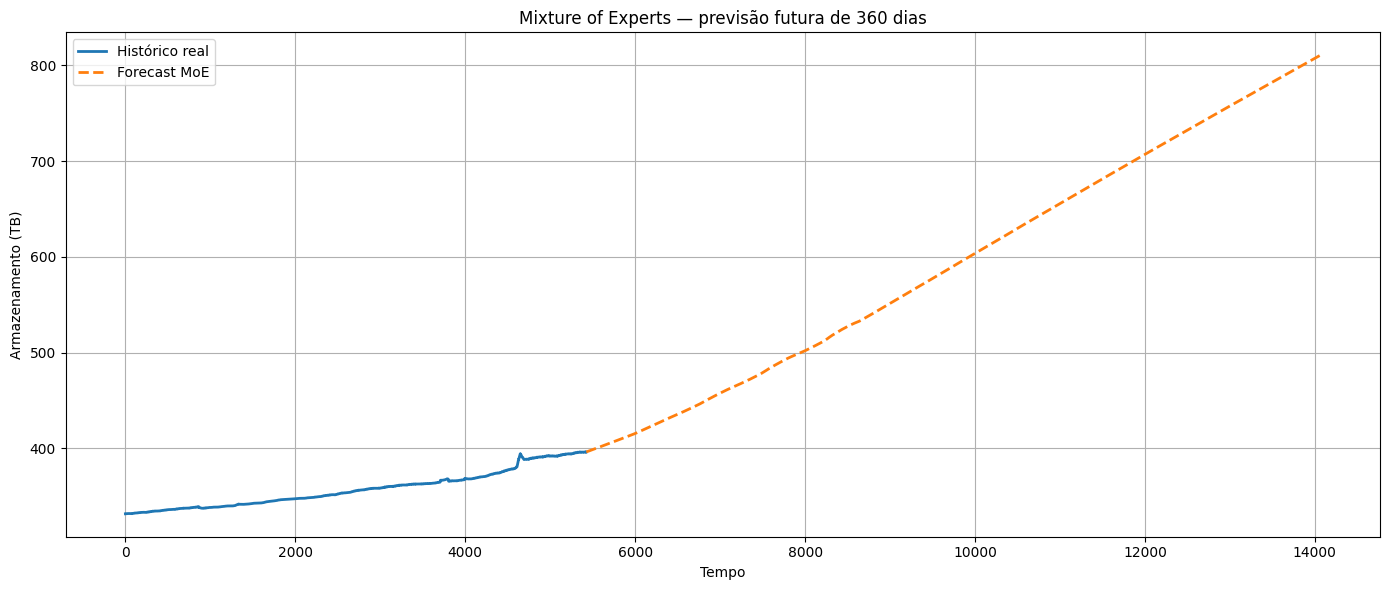

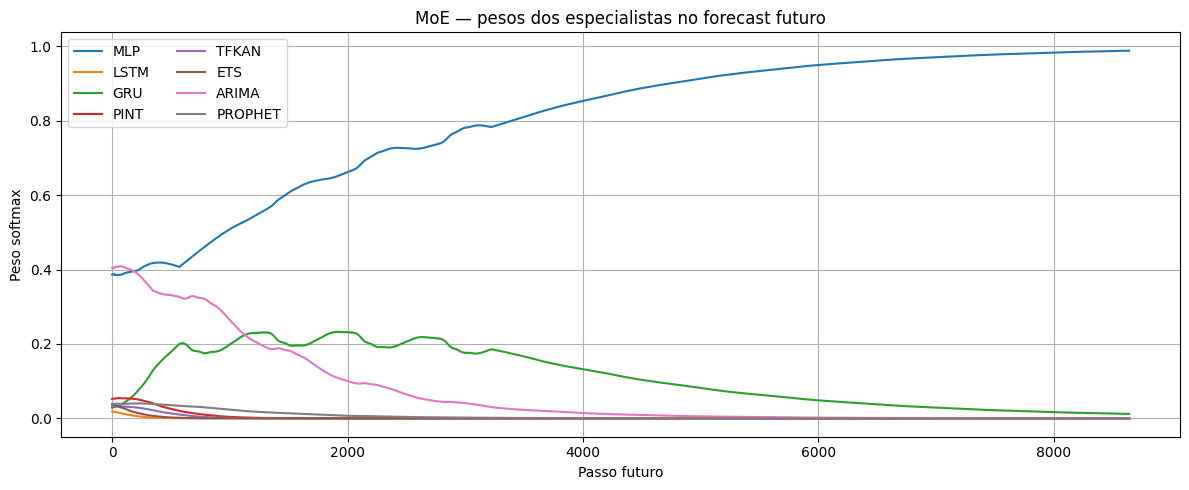

In [ ]:
    plt.figure(figsize=(14, 6))
    plt.plot(np.arange(len(series_tb)), series_tb, label="Histórico real", linewidth=2)
    plt.plot(x_fore_moe, forecast_abs_moe_tb, label="Forecast MoE", linestyle="--", linewidth=2)
    plt.title(f"Mixture of Experts — previsão futura de {FORECAST_DAYS} dias")
    plt.xlabel("Tempo")
    plt.ylabel("Armazenamento (TB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("moe_future_forecast_tb.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 5))
    for i, name in enumerate(expert_names_moe_future):
        plt.plot(moe_weights_forecast[:, i], label=name)
    plt.title("MoE — pesos dos especialistas no forecast futuro")
    plt.xlabel("Passo futuro")
    plt.ylabel("Peso softmax")
    plt.grid(True)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig("moe_future_weights.png", dpi=300, bbox_inches="tight")
    plt.show()



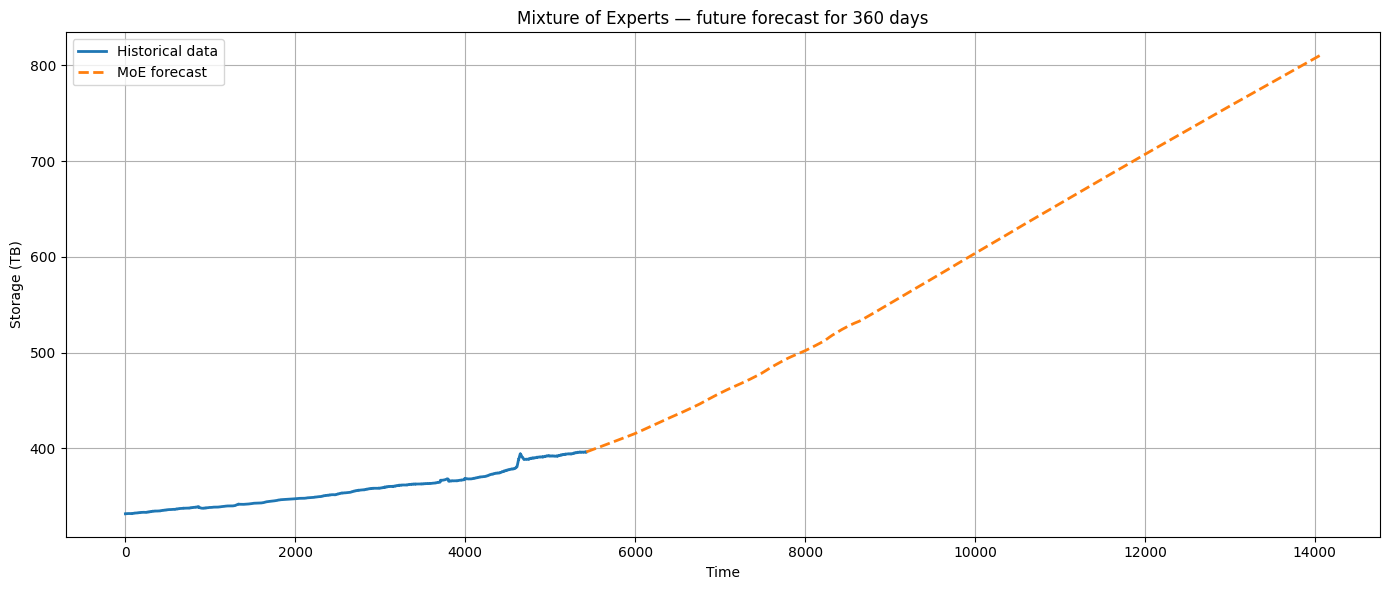

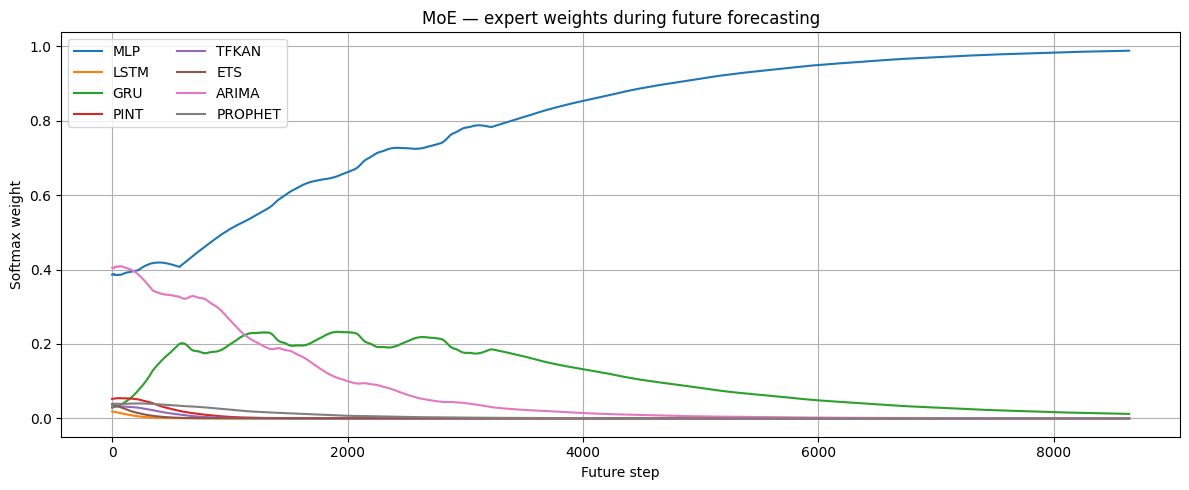

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    np.arange(len(series_tb)),
    series_tb,
    label="Historical data",
    linewidth=2
)

plt.plot(
    x_fore_moe,
    forecast_abs_moe_tb,
    label="MoE forecast",
    linestyle="--",
    linewidth=2
)

plt.title(
    f"Mixture of Experts — future forecast for {FORECAST_DAYS} days"
)

plt.xlabel("Time")
plt.ylabel("Storage (TB)")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "moe_future_forecast_tb_en.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(12, 5))

for i, name in enumerate(expert_names_moe_future):
    plt.plot(
        moe_weights_forecast[:, i],
        label=name
    )

plt.title("MoE — expert weights during future forecasting")

plt.xlabel("Future step")
plt.ylabel("Softmax weight")

plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()

plt.savefig(
    "moe_future_weights_en.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
if SAVE == 1:
    # ============================================================
    # 💾 SAVE EVERYTHING - MIXTURE OF EXPERTS (BASE_PATH)
    # ============================================================

    import os
    import json
    import shutil

    # 👉 usa o mesmo BASE_PATH do projeto
    SAVE_DIR_MOE = os.path.join(BASE_PATH, "artifacts_moe")
    os.makedirs(SAVE_DIR_MOE, exist_ok=True)

    files_to_copy_moe = [
        "moe_gating_model.keras",
        "moe_metrics.json",
        "moe_validation_predictions_tb.csv",
        "moe_validation_weights.csv",
        "moe_future_forecast_tb.csv",
        "moe_future_weights.csv",
        "moe_validation_forecast_tb.png",
        "moe_loss_curve.png",
        "moe_dynamic_weights.png",
        "moe_future_forecast_tb.png",
        "moe_future_weights.png",
        "moe_feature_mu.npy",
        "moe_feature_sd.npy",
        "moe_history_loss.npy",
        "moe_history_val_loss.npy",
    ]

    # ============================================================
    # 📂 COPY FILES
    # ============================================================
    for file in files_to_copy_moe:
        if os.path.exists(file):
            shutil.copy(file, os.path.join(SAVE_DIR_MOE, file))
        else:
            print(f"⚠️ Arquivo não encontrado: {file}")

    # ============================================================
    # ⚙️ CONFIG
    # ============================================================
    moe_config = {
        "model": "Mixture of Experts with neural softmax gating",
        "experts": expert_names_moe if "expert_names_moe" in globals() else [],
        "target_unit": "TB",
        "forecast_days": int(FORECAST_DAYS) if "FORECAST_DAYS" in globals() else None,
        "forecast_steps": int(FORECAST_STEPS) if "FORECAST_STEPS" in globals() else None,
        "gate_train_fraction": 0.75,
        "optimizer": "Adam(lr=1e-3, clipnorm=1.0)",
        "loss": "MSE",
        "regularization": "Dropout(0.10) + L2(1e-5)",
    }

    with open(os.path.join(SAVE_DIR_MOE, "moe_config.json"), "w", encoding="utf-8") as f:
        json.dump(moe_config, f, indent=4, ensure_ascii=False)

    # ============================================================
    # 📦 ZIP
    # ============================================================
    zip_path = os.path.join(BASE_PATH, "artifacts_moe")
    shutil.make_archive(zip_path, "zip", SAVE_DIR_MOE)

    print(f"✅ Artefatos do MoE salvos em: {SAVE_DIR_MOE}")
    print(f"📦 ZIP criado em: {zip_path}.zip")

# COMPARISON-ALL


Adding MoE to plot...
y_pred_abs_moe_tb exists: True
y_pred_moe_tb exists: False


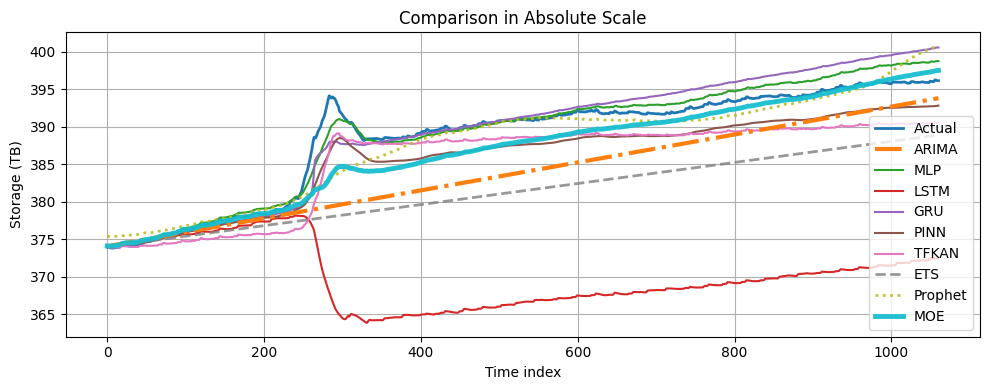

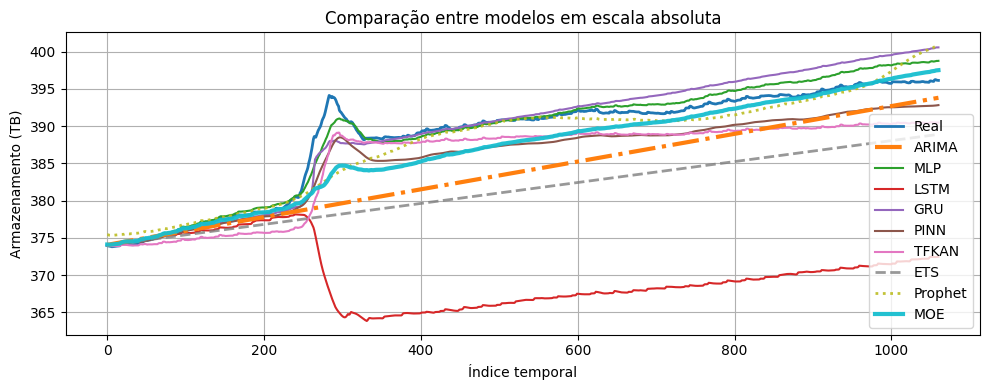


✅ Saved files:
- arima_grid_search_aic.csv
- arima_busca_aic.csv
- arima_best_model.json
- arima_melhor_modelo.json
- arima_metrics_normalized.json
- arima_metricas_normalizado.json
- arima_metrics_absolute.json
- arima_metricas_absolutas.json
- arima_validation_normalized.csv
- arima_validacao_normalizado.csv
- arima_validation_absolute.csv
- arima_validacao_absoluta.csv
- arima_future_forecast.csv
- arima_forecast_futuro.csv
- all_model_comparison.csv
- all_comparacao_modelos.csv
- arima_train_test_forecast_en.png
- arima_treino_teste_previsao_pt.png
- arima_test_zoom_en.png
- arima_zoom_teste_pt.png
- arima_validation_absolute_en.png
- arima_validacao_absoluta_pt.png
- arima_future_forecast_en.png
- arima_forecast_futuro_pt.png
- all_model_comparison_en.png
- all_model_comparison_pt.png
- moe_validation_predictions_tb.csv
- moe_validation_weights.csv
- moe_future_forecast_tb.csv
- moe_future_weights.csv
- moe_validation_forecast_tb.png
- moe_dynamic_weights.png


In [ ]:
# ============================================================
# ✅ OPTIONAL COMPARISON WITH OTHER MODELS (INCLUDING EXP)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _safe_series(arr, n):
    arr = np.asarray(arr).ravel()
    out = np.full(n, np.nan)
    m = min(n, len(arr))
    out[:m] = arr[:m]
    return out

# ------------------------------------------------------------
# Base length (ARIMA reference)
# ------------------------------------------------------------
n_comp = len(y_test_abs_arima_tb)

# ------------------------------------------------------------
# Data dictionary
# ------------------------------------------------------------
comparison_data = {
    "time_index": np.arange(n_comp),
    "Actual_TB": _safe_series(y_test_abs_arima_tb, n_comp),
    "ARIMA_TB": _safe_series(y_pred_abs_arima_tb, n_comp),
}

print("\nAdding MoE to plot...")
print("y_pred_abs_moe_tb exists:", 'y_pred_abs_moe_tb' in globals())
print("y_pred_moe_tb exists:", 'y_pred_moe_tb' in globals())

# ------------------------------------------------------------
# Add models dynamically
# ------------------------------------------------------------
if 'y_pred_abs_mlp_tb' in globals():
    comparison_data["MLP_TB"] = _safe_series(y_pred_abs_mlp_tb, n_comp)

if 'y_pred_abs_lstm_tb' in globals():
    comparison_data["LSTM_TB"] = _safe_series(y_pred_abs_lstm_tb, n_comp)

if 'y_pred_abs_gru_tb' in globals():
    comparison_data["GRU_TB"] = _safe_series(y_pred_abs_gru_tb, n_comp)

if 'y_pred_abs_pint_tb' in globals():
    comparison_data["PINT_TB"] = _safe_series(y_pred_abs_pint_tb, n_comp)

if 'y_pred_abs_tfkan_tb' in globals():
    comparison_data["TFKAN_TB"] = _safe_series(y_pred_abs_tfkan_tb, n_comp)

# ✅ NEW: EXP model
if 'y_pred_abs_exp_tb' in globals():
    comparison_data["EXP_TB"] = _safe_series(y_pred_abs_exp_tb, n_comp)

# ✅ NEW: PROPHET model
if 'y_pred_abs_prophet_tb' in globals():
    comparison_data["PROPHET_TB"] = _safe_series(y_pred_abs_prophet_tb, n_comp)

# ✅ NEW: MOE model
if 'y_pred_abs_moe_tb' in globals():
    comparison_data["MOE_TB"] = _safe_series(y_pred_abs_moe_tb, n_comp)
elif 'y_pred_moe_tb' in globals():
    comparison_data["MOE_TB"] = _safe_series(y_pred_moe_tb, n_comp)

# ------------------------------------------------------------
# 📊 Plot (EN)
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.plot(y_test_abs_arima_tb, label="Actual", linewidth=2)
#plt.plot(y_pred_abs_arima_tb, "--", label=f"ARIMA{best_order}")
plt.plot(
    _safe_series(y_pred_abs_arima_tb, n_comp),
    label="ARIMA",
    linestyle="-.",
    linewidth=3,
    zorder=10
)

if 'y_pred_abs_mlp_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_mlp_tb, n_comp), label="MLP")

if 'y_pred_abs_lstm_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_lstm_tb, n_comp), label="LSTM")

if 'y_pred_abs_gru_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_gru_tb, n_comp), label="GRU")

if 'y_pred_abs_pint_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_pint_tb, n_comp), label="PINN")

if 'y_pred_abs_tfkan_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_tfkan_tb, n_comp), label="TFKAN")

# ✅ EXP
if 'y_pred_abs_exp_tb' in globals():
    #plt.plot(_safe_series(y_pred_abs_exp_tb, n_comp), label="EXP (Baseline)")
    plt.plot(
    _safe_series(y_pred_abs_exp_tb, n_comp),
    label="ETS",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    zorder=5
    )

if 'y_pred_abs_prophet_tb' in globals():
    plt.plot(
        _safe_series(y_pred_abs_prophet_tb, n_comp),
        label="Prophet",
        linestyle=":",
        linewidth=2,
        alpha=0.9,
        zorder=6
    )

# ✅ MOE
if 'y_pred_abs_moe_tb' in globals():
    plt.plot(
        _safe_series(y_pred_abs_moe_tb, n_comp),
        label="MOE",
        linestyle="-",
        linewidth=3.5,
        alpha=0.95,
        zorder=12
    )
elif 'y_pred_moe_tb' in globals():
    plt.plot(
        _safe_series(y_pred_moe_tb, n_comp),
        label="MOE",
        linestyle="-",
        linewidth=3,
        alpha=0.95,
        zorder=12
    )

plt.title("Comparison in Absolute Scale")
plt.xlabel("Time index")
plt.ylabel("Storage (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("all_model_comparison_en.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 📊 Plot (PT-BR)
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.plot(y_test_abs_arima_tb, label="Real", linewidth=2)
#plt.plot(y_pred_abs_arima_tb, "--", label=f"ARIMA{best_order}")
plt.plot(
    _safe_series(y_pred_abs_arima_tb, n_comp),
    label="ARIMA",
    linestyle="-.",
    linewidth=3,
    zorder=10
)

if 'y_pred_abs_mlp_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_mlp_tb, n_comp), label="MLP")

if 'y_pred_abs_lstm_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_lstm_tb, n_comp), label="LSTM")

if 'y_pred_abs_gru_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_gru_tb, n_comp), label="GRU")

if 'y_pred_abs_pint_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_pint_tb, n_comp), label="PINN")

if 'y_pred_abs_tfkan_tb' in globals():
    plt.plot(_safe_series(y_pred_abs_tfkan_tb, n_comp), label="TFKAN")

# ✅ EXP
if 'y_pred_abs_exp_tb' in globals():
    #plt.plot(_safe_series(y_pred_abs_exp_tb, n_comp), label="EXP (Baseline)")
    plt.plot(
    _safe_series(y_pred_abs_exp_tb, n_comp),
    label="ETS",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    zorder=5
    )

if 'y_pred_abs_prophet_tb' in globals():
    plt.plot(
        _safe_series(y_pred_abs_prophet_tb, n_comp),
        label="Prophet",
        linestyle=":",
        linewidth=2,
        alpha=0.9,
        zorder=6
    )

# ✅ MOE
if 'y_pred_abs_moe_tb' in globals():
    plt.plot(
        _safe_series(y_pred_abs_moe_tb, n_comp),
        label="MOE",
        linestyle="-",
        linewidth=3,
        alpha=0.95,
        zorder=12
    )
elif 'y_pred_moe_tb' in globals():
    plt.plot(
        _safe_series(y_pred_moe_tb, n_comp),
        label="MOE",
        linestyle="-",
        linewidth=3,
        alpha=0.95,
        zorder=12
    )

plt.title("Comparação entre modelos em escala absoluta")
plt.xlabel("Índice temporal")
plt.ylabel("Armazenamento (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("all_model_comparison_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 💾 Save CSV
# ------------------------------------------------------------
df_comp = pd.DataFrame(comparison_data)

df_comp.to_csv("all_model_comparison.csv", index=False)
df_comp.to_csv("all_comparacao_modelos.csv", index=False)

# ------------------------------------------------------------
# 📁 Output summary
# ------------------------------------------------------------
print("\n✅ Saved files:")
print("- arima_grid_search_aic.csv")
print("- arima_busca_aic.csv")
print("- arima_best_model.json")
print("- arima_melhor_modelo.json")
print("- arima_metrics_normalized.json")
print("- arima_metricas_normalizado.json")
print("- arima_metrics_absolute.json")
print("- arima_metricas_absolutas.json")
print("- arima_validation_normalized.csv")
print("- arima_validacao_normalizado.csv")
print("- arima_validation_absolute.csv")
print("- arima_validacao_absoluta.csv")
print("- arima_future_forecast.csv")
print("- arima_forecast_futuro.csv")
print("- all_model_comparison.csv")
print("- all_comparacao_modelos.csv")
print("- arima_train_test_forecast_en.png")
print("- arima_treino_teste_previsao_pt.png")
print("- arima_test_zoom_en.png")
print("- arima_zoom_teste_pt.png")
print("- arima_validation_absolute_en.png")
print("- arima_validacao_absoluta_pt.png")
print("- arima_future_forecast_en.png")
print("- arima_forecast_futuro_pt.png")
print("- all_model_comparison_en.png")
print("- all_model_comparison_pt.png")
print("- moe_validation_predictions_tb.csv")
print("- moe_validation_weights.csv")
print("- moe_future_forecast_tb.csv")
print("- moe_future_weights.csv")
print("- moe_validation_forecast_tb.png")
print("- moe_dynamic_weights.png")

In [ ]:
if SAVE == 1:
    # ============================================================
    # 💾 SAVE EVERYTHING - MODEL COMPARISON
    # ============================================================

    import os
    import json
    import shutil
    import numpy as np
    import pandas as pd

    MODEL_NAME = "comparison"

    os.makedirs(BASE_PATH, exist_ok=True)

    # ============================================================
    # 1) AUX
    # ============================================================
    def _safe_series(arr, n):
        arr = np.asarray(arr).ravel()
        out = np.full(n, np.nan)
        m = min(n, len(arr))
        out[:m] = arr[:m]
        return out

    # ============================================================
    # 2) BASE LENGTH
    # ============================================================
    n_comp = len(y_test_abs_arima_tb)

    # ============================================================
    # 3) BUILD DATA DICTIONARY
    # ============================================================
    comparison_data = {
        "time_index": np.arange(n_comp),
        "Actual_TB": _safe_series(y_test_abs_arima_tb, n_comp),
        "ARIMA_TB": _safe_series(y_pred_abs_arima_tb, n_comp),
    }

    available_models = ["ARIMA"]

    if "y_pred_abs_mlp_tb" in globals():
        comparison_data["MLP_TB"] = _safe_series(y_pred_abs_mlp_tb, n_comp)
        available_models.append("MLP")

    if "y_pred_abs_lstm_tb" in globals():
        comparison_data["LSTM_TB"] = _safe_series(y_pred_abs_lstm_tb, n_comp)
        available_models.append("LSTM")

    if "y_pred_abs_gru_tb" in globals():
        comparison_data["GRU_TB"] = _safe_series(y_pred_abs_gru_tb, n_comp)
        available_models.append("GRU")

    if "y_pred_abs_pint_tb" in globals():
        comparison_data["PINT_TB"] = _safe_series(y_pred_abs_pint_tb, n_comp)
        available_models.append("PINT")

    if "y_pred_abs_tfkan_tb" in globals():
        comparison_data["TFKAN_TB"] = _safe_series(y_pred_abs_tfkan_tb, n_comp)
        available_models.append("TFKAN")

    if "y_pred_abs_exp_tb" in globals():
        comparison_data["EXP_TB"] = _safe_series(y_pred_abs_exp_tb, n_comp)
        available_models.append("EXP")

    if "y_pred_abs_prophet_tb" in globals():
        comparison_data["PROPHET_TB"] = _safe_series(y_pred_abs_prophet_tb, n_comp)
        available_models.append("PROPHET")

    if "y_pred_abs_moe_tb" in globals():
        comparison_data["MOE_TB"] = _safe_series(y_pred_abs_moe_tb, n_comp)
        available_models.append("MOE")
    elif "y_pred_moe_tb" in globals():
        comparison_data["MOE_TB"] = _safe_series(y_pred_moe_tb, n_comp)
        available_models.append("MOE")

    df_comp = pd.DataFrame(comparison_data)

    # ============================================================
    # 4) SAVE CSV
    # ============================================================
    df_comp.to_csv(f"{BASE_PATH}/all_model_comparison.csv", index=False)
    df_comp.to_csv(f"{BASE_PATH}/all_comparacao_modelos.csv", index=False)

    # ============================================================
    # 5) SAVE NUMPY ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/comparison_time_index.npy", df_comp["time_index"].to_numpy())
    np.save(f"{BASE_PATH}/comparison_actual_tb.npy", df_comp["Actual_TB"].to_numpy())
    np.save(f"{BASE_PATH}/comparison_arima_tb.npy", df_comp["ARIMA_TB"].to_numpy())

    for col in df_comp.columns:
        if col not in ["time_index"]:
            np.save(f"{BASE_PATH}/{col}.npy", df_comp[col].to_numpy())

    # ============================================================
    # 6) SAVE CONFIG / METADATA
    # ============================================================
    comparison_config = {
        "n_comp": int(n_comp),
        "reference_model": "ARIMA",
        "available_models": available_models,
        "columns": list(df_comp.columns),
        "pt_figure": "all_model_comparison_pt.png",
        "en_figure": "all_model_comparison_en.png",
        "csv_en": "all_model_comparison.csv",
        "csv_pt": "all_comparacao_modelos.csv",
    }

    with open(f"{BASE_PATH}/comparison_config.json", "w", encoding="utf-8") as f:
        json.dump(comparison_config, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 7) SAVE SIMPLE METRICS SUMMARY AGAINST ACTUAL
    # ============================================================
    metrics_summary = {}

    actual = df_comp["Actual_TB"].to_numpy()

    for col in df_comp.columns:
        if col in ["time_index", "Actual_TB"]:
            continue

        pred = df_comp[col].to_numpy()
        mask = ~np.isnan(actual) & ~np.isnan(pred)

        if np.sum(mask) > 1:
            mse = np.mean((actual[mask] - pred[mask]) ** 2)
            rmse = np.sqrt(mse)
            try:
                ss_res = np.sum((actual[mask] - pred[mask]) ** 2)
                ss_tot = np.sum((actual[mask] - np.mean(actual[mask])) ** 2)
                r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
            except:
                r2 = np.nan

            metrics_summary[col] = {
                "mse_tb": float(mse),
                "rmse_tb": float(rmse),
                "r2_tb": None if np.isnan(r2) else float(r2),
            }

    with open(f"{BASE_PATH}/comparison_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics_summary, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 8) COPY FIGURES IF THEY EXIST
    # ============================================================
    artifact_files = [
        "all_model_comparison.csv",
        "all_comparacao_modelos.csv",
        "all_model_comparison_en.png",
        "all_model_comparison_pt.png",
    ]

    for fname in artifact_files:
        if os.path.exists(fname):
            dest = os.path.join(BASE_PATH, fname)
            if os.path.abspath(fname) != os.path.abspath(dest):
                shutil.copy2(fname, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All comparison artifacts saved in:\n{BASE_PATH}")
    print("Models included:", ", ".join(available_models))


================ MÉTRICAS EM ESCALA ABSOLUTA (TB) ================

MLP      | MSE=1.711963e+00 | RMSE=1.308420e+00 | R²=0.964315
LSTM     | MSE=4.410085e+02 | RMSE=2.100020e+01 | R²=-8.192585
GRU      | MSE=4.915288e+00 | RMSE=2.217045e+00 | R²=0.897543
TFKAN    | MSE=1.247538e+01 | RMSE=3.532051e+00 | R²=0.739957
PINT     | MSE=9.292350e+00 | RMSE=3.048336e+00 | R²=0.806306
ETS      | MSE=6.584482e+01 | RMSE=8.114482e+00 | R²=-0.372500
ARIMA    | MSE=1.557295e+01 | RMSE=3.946258e+00 | R²=0.675390
PROPHET  | MSE=5.499020e+00 | RMSE=2.344999e+00 | R²=0.885376
MOE      | MSE=7.541638e+00 | RMSE=2.746204e+00 | R²=0.842799


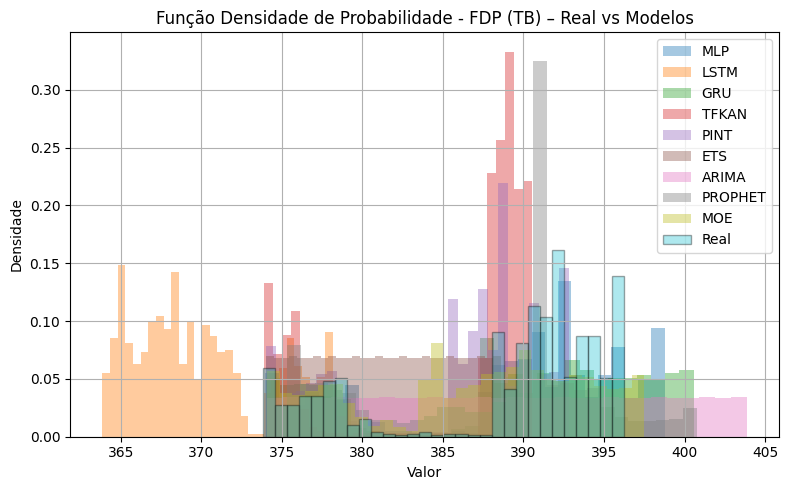

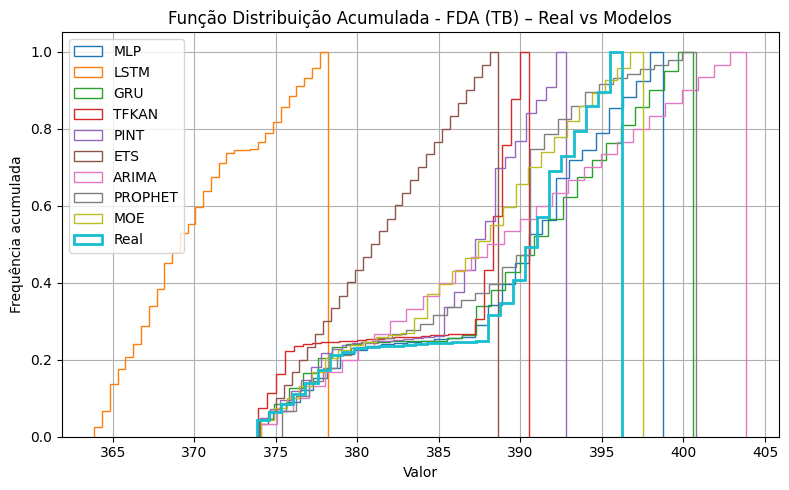


==== Tabela KS (TB) ====
         Estatística KS  p-valor                        Interpretação
Modelo                                                               
MLP              0.1517      0.0  Distribuições diferentes (p < 0,05)
LSTM             0.8313      0.0  Distribuições diferentes (p < 0,05)
GRU              0.2337      0.0  Distribuições diferentes (p < 0,05)
TFKAN            0.5815      0.0  Distribuições diferentes (p < 0,05)
PINT             0.3779      0.0  Distribuições diferentes (p < 0,05)
ETS              0.7276      0.0  Distribuições diferentes (p < 0,05)
ARIMA            0.2564      0.0  Distribuições diferentes (p < 0,05)
PROPHET          0.2356      0.0  Distribuições diferentes (p < 0,05)
MOE              0.2667      0.0  Distribuições diferentes (p < 0,05)


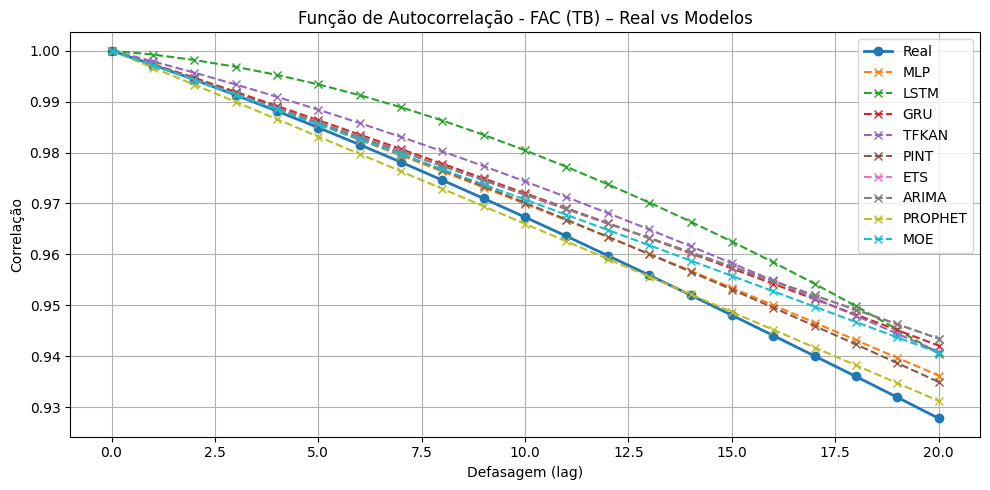


✅ Arquivos salvos:
- analise_distribuicoes_series_tb.csv
- metricas_modelos_tb.csv
- tabela_ks_tb.csv
- acf_modelos_tb.csv
- fdp_modelos_tb.png
- fda_modelos_tb.png
- fac_modelos_tb.png
- qqplot_tb_*.png (se ativar ks_qq_analysis)


In [ ]:
# ============================================================
# CÓDIGO COMPLETO — PDF/CDF + KS + QQ + ACF
# COM MLP + LSTM + GRU + PINT + TFKAN + EXP + ARIMA + PROPHET + MOE
# + TB CORRETO + SALVAMENTO EM PNG E CSV
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.stats import ks_2samp
from statsmodels.graphics.gofplots import qqplot_2samples
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

# ========================== CONFIG ==========================
ARIMA_ORDER = best_order if "best_order" in globals() else (3, 1, 3)

# ========================== UTIL ==========================
def _as_1d(a):
    return np.asarray(a).reshape(-1)

def _inv_diff(scaler, x):
    x = _as_1d(x).astype(np.float32)
    return scaler.inverse_transform(x.reshape(-1, 1)).ravel()

def _safe_split_idx(series):
    return int(split) if "split" in globals() else int(len(series) * 0.9)

def _reconstruct_abs(series, split_idx, window, deltas_inv):
    deltas_inv = _as_1d(deltas_inv)
    base_pos = split_idx + window - 1

    if base_pos >= len(series):
        raise IndexError(
            f"Índice base fora do limite: split_idx + window - 1 = {base_pos}, len(series) = {len(series)}"
        )

    base_value = float(series[base_pos])
    return base_value + np.cumsum(deltas_inv)

def _align_pair(y_true, y_pred):
    y_true = _as_1d(y_true)
    y_pred = _as_1d(y_pred)
    n = min(len(y_true), len(y_pred))
    return y_true[:n], y_pred[:n]

def _common_align(real_dict, pred_dict):
    aligned = {}
    min_len = np.inf

    for name in pred_dict:
        yt, yp = _align_pair(real_dict[name], pred_dict[name])
        aligned[f"{name}_real"] = yt
        aligned[f"{name}_pred"] = yp
        min_len = min(min_len, len(yt), len(yp))

    min_len = int(min_len)

    real_out = {}
    pred_out = {}
    for name in pred_dict:
        real_out[name] = aligned[f"{name}_real"][:min_len]
        pred_out[name] = aligned[f"{name}_pred"][:min_len]

    return real_out, pred_out, min_len

def _safe_acf(x, lags=20):
    x = _as_1d(x)
    if len(x) < 3:
        return np.array([1.0])
    safe_lags = min(lags, len(x) - 1)
    return acf(x, nlags=safe_lags)

# ========================== BASELINE EXP ==========================
def exp_forecast_diff(y_train_diff, steps):
    model = ExponentialSmoothing(
        _as_1d(y_train_diff),
        trend=None,
        seasonal=None
    )
    fit = model.fit(optimized=True)
    return _as_1d(fit.forecast(steps))

# ========================== BASELINE ARIMA ==========================
def arima_forecast_diff(y_train_diff, steps, order=(1, 0, 1)):
    model = ARIMA(_as_1d(y_train_diff), order=order)
    fit = model.fit()
    return _as_1d(fit.forecast(steps))

# ========================== PDF/FDP ==========================
def plot_fdp(y_real, y_preds_dict, bins=30, title="PDF – Função Densidade de Probabilidade",
             save_path=None):
    plt.figure(figsize=(8, 5))
    for nome, y_pred in y_preds_dict.items():
        plt.hist(_as_1d(y_pred), bins=bins, density=True, alpha=0.40, label=nome)
    plt.hist(_as_1d(y_real), bins=bins, density=True, alpha=0.35, label="Real", edgecolor="black")
    plt.title(title)
    plt.xlabel("Valor")
    plt.ylabel("Densidade")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# ========================== CDF/FDA ==========================
def plot_fda(y_real, y_preds_dict, bins=30, title="CDF – Função Distribuição Acumulada",
             save_path=None):
    plt.figure(figsize=(8, 5))
    for nome, y_pred in y_preds_dict.items():
        plt.hist(_as_1d(y_pred), bins=bins, density=True, cumulative=True, histtype="step", label=nome)
    plt.hist(_as_1d(y_real), bins=bins, density=True, cumulative=True, histtype="step",
             label="Real", linewidth=2)
    plt.title(title)
    plt.xlabel("Valor")
    plt.ylabel("Frequência acumulada")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# ========================== KS + QQ ==========================
def ks_qq_analysis(y_real, y_preds_dict, save_prefix="qqplot"):
    y_real = _as_1d(y_real)

    for nome, y_pred in y_preds_dict.items():
        y_pred = _as_1d(y_pred)
        yt, yp = _align_pair(y_real, y_pred)

        print(f"\n📊 {nome} - Teste de Kolmogorov-Smirnov:")
        ks_stat, ks_p = ks_2samp(yt, yp)
        print(f"Estatística KS: {ks_stat:.4f}, p-valor: {ks_p:.6f}")

        plt.figure(figsize=(5, 5))
        qqplot_2samples(yp, yt, line="45")
        plt.title(f"QQ-Plot: {nome} vs Real")
        plt.xlabel("Quantis do modelo")
        plt.ylabel("Quantis reais")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"{save_prefix}_{nome.lower()}.png", dpi=300, bbox_inches="tight")
        plt.show()

def teste_ks_modelos(y_real, y_preds_dict):
    y_real = _as_1d(y_real)
    resultados = []

    for nome, y_pred in y_preds_dict.items():
        y_pred = _as_1d(y_pred)
        yt, yp = _align_pair(y_real, y_pred)

        stat, pval = ks_2samp(yt, yp)
        interpretacao = (
            "Distribuições diferentes (p < 0,05)"
            if pval < 0.05 else
            "Distribuições semelhantes (p ≥ 0,05)"
        )
        resultados.append({
            "Modelo": nome,
            "Estatística KS": round(float(stat), 4),
            "p-valor": round(float(pval), 6),
            "Interpretação": interpretacao
        })

    return pd.DataFrame(resultados).set_index("Modelo")

# ========================== ACF/FAC ==========================
def plot_acf_comparison(y_real, y_preds_dict, lags=20,
                        title="Autocorrelação (ACF) – Série real vs predições",
                        save_path=None):
    plt.figure(figsize=(10, 5))
    y_real = _as_1d(y_real)

    acf_real = _safe_acf(y_real, lags=lags)
    plt.plot(np.arange(len(acf_real)), acf_real, label="Real", marker="o", linewidth=2)

    for nome, y_pred in y_preds_dict.items():
        y_pred = _as_1d(y_pred)
        acf_model = _safe_acf(y_pred, lags=lags)
        m = min(len(acf_real), len(acf_model))
        plt.plot(np.arange(m), acf_model[:m], marker="x", linestyle="--", label=nome)

    plt.title(title)
    plt.xlabel("Defasagem (lag)")
    plt.ylabel("Correlação")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# EXECUÇÃO
# ============================================================

split_idx = _safe_split_idx(series)

# ---------- 1) Predições no espaço diff_norm ----------
p_mlp = _as_1d(model_mlp(tf.convert_to_tensor(X_test_mlp, dtype=tf.float32), training=False).numpy())
p_lstm = _as_1d(model_lstm(tf.convert_to_tensor(X_test_lstm, dtype=tf.float32), training=False).numpy())
p_gru = _as_1d(model_gru(tf.convert_to_tensor(X_test_gru, dtype=tf.float32), training=False).numpy())
p_tfkan = _as_1d(model_tfkan(tf.convert_to_tensor(X_test_tfkan, dtype=tf.float32), training=False).numpy())

p_pint_seq = model_pinn(tf.convert_to_tensor(X_test_pint, dtype=tf.float32), training=False).numpy()
p_pint = _as_1d(p_pint_seq[:, -1, 0])

p_exp = exp_forecast_diff(diff_train_norm[:, 0], len(y_test_mlp))
p_arima = arima_forecast_diff(diff_train_norm[:, 0], len(y_test_mlp), order=ARIMA_ORDER)

# ---------- 2) Inversão dos deltas ----------
d_real = {
    "MLP": _inv_diff(scaler, y_test_mlp),
    "LSTM": _inv_diff(scaler, y_test_lstm),
    "GRU": _inv_diff(scaler, y_test_gru),
    "TFKAN": _inv_diff(scaler, y_test_tfkan),
    "PINT": _inv_diff(scaler, y_test_pint),
    "ETS": _inv_diff(scaler, y_test_mlp),
    "ARIMA": _inv_diff(scaler, y_test_mlp),
}

d_pred = {
    "MLP": _inv_diff(scaler, p_mlp),
    "LSTM": _inv_diff(scaler, p_lstm),
    "GRU": _inv_diff(scaler, p_gru),
    "TFKAN": _inv_diff(scaler, p_tfkan),
    "PINT": _inv_diff(scaler, p_pint),
    "ETS": _inv_diff(scaler, p_exp),
    "ARIMA": _inv_diff(scaler, p_arima),
}

# ---------- 3) Reconstrução absoluta ----------
y_real_abs_dict = {
    "MLP": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_real["MLP"]),
    "LSTM": _reconstruct_abs(series, split_idx, BEST_WINDOW_LSTM, d_real["LSTM"]),
    "GRU": _reconstruct_abs(series, split_idx, BEST_WINDOW_GRU, d_real["GRU"]),
    "TFKAN": _reconstruct_abs(series, split_idx, BEST_WINDOW_TFKAN, d_real["TFKAN"]),
    "PINT": _reconstruct_abs(series, split_idx, BEST_WINDOW_PINT, d_real["PINT"]),
    "ETS": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_real["ETS"]),
    "ARIMA": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_real["ARIMA"]),
}

y_pred_abs_dict = {
    "MLP": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_pred["MLP"]),
    "LSTM": _reconstruct_abs(series, split_idx, BEST_WINDOW_LSTM, d_pred["LSTM"]),
    "GRU": _reconstruct_abs(series, split_idx, BEST_WINDOW_GRU, d_pred["GRU"]),
    "TFKAN": _reconstruct_abs(series, split_idx, BEST_WINDOW_TFKAN, d_pred["TFKAN"]),
    "PINT": _reconstruct_abs(series, split_idx, BEST_WINDOW_PINT, d_pred["PINT"]),
    "ETS": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_pred["ETS"]),
    "ARIMA": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_pred["ARIMA"]),
}

# ---------- 3.1) Prophet ----------
if "y_test_abs_prophet" in globals() and "y_pred_abs_prophet" in globals():
    y_real_abs_dict["PROPHET"] = _as_1d(y_test_abs_prophet)
    y_pred_abs_dict["PROPHET"] = _as_1d(y_pred_abs_prophet)

elif "y_test_abs_prophet_tb" in globals() and "y_pred_abs_prophet_tb" in globals():
    y_real_abs_dict["PROPHET"] = _as_1d(y_test_abs_prophet_tb) * 1e12
    y_pred_abs_dict["PROPHET"] = _as_1d(y_pred_abs_prophet_tb) * 1e12

# ---------- 3.2) MOE ----------
if "y_test_abs_moe" in globals() and "y_pred_abs_moe" in globals():
    y_real_abs_dict["MOE"] = _as_1d(y_test_abs_moe)
    y_pred_abs_dict["MOE"] = _as_1d(y_pred_abs_moe)

elif "y_test_abs_moe_tb" in globals() and "y_pred_abs_moe_tb" in globals():
    y_real_abs_dict["MOE"] = _as_1d(y_test_abs_moe_tb) * 1e12
    y_pred_abs_dict["MOE"] = _as_1d(y_pred_abs_moe_tb) * 1e12

elif "y_pred_abs_moe_tb" in globals():
    # usa a série real ARIMA em TB como referência comum de validação
    y_real_abs_dict["MOE"] = _as_1d(y_test_abs_arima_tb) * 1e12
    y_pred_abs_dict["MOE"] = _as_1d(y_pred_abs_moe_tb) * 1e12

elif "y_pred_moe_tb" in globals():
    y_real_abs_dict["MOE"] = _as_1d(y_test_abs_arima_tb) * 1e12
    y_pred_abs_dict["MOE"] = _as_1d(y_pred_moe_tb) * 1e12

# ---------- 4) Alinhamento global ----------
real_aligned_abs, pred_aligned_abs, min_len = _common_align(y_real_abs_dict, y_pred_abs_dict)

y_real_abs = real_aligned_abs["MLP"]

y_preds_abs = {
    "MLP": pred_aligned_abs["MLP"],
    "LSTM": pred_aligned_abs["LSTM"],
    "GRU": pred_aligned_abs["GRU"],
    "TFKAN": pred_aligned_abs["TFKAN"],
    "PINT": pred_aligned_abs["PINT"],
    "ETS": pred_aligned_abs["ETS"],
    "ARIMA": pred_aligned_abs["ARIMA"],
}

if "PROPHET" in pred_aligned_abs:
    y_preds_abs["PROPHET"] = pred_aligned_abs["PROPHET"]

if "MOE" in pred_aligned_abs:
    y_preds_abs["MOE"] = pred_aligned_abs["MOE"]

# ---------- 5) Conversão para TB ----------
TO_TB = 1e12
y_real_tb = y_real_abs / TO_TB
y_preds_tb = {k: v / TO_TB for k, v in y_preds_abs.items()}

# ---------- 6) Salvar séries alinhadas ----------
df_series = pd.DataFrame({
    "Real_TB": y_real_tb,
    "MLP_TB": y_preds_tb["MLP"],
    "LSTM_TB": y_preds_tb["LSTM"],
    "GRU_TB": y_preds_tb["GRU"],
    "TFKAN_TB": y_preds_tb["TFKAN"],
    "PINT_TB": y_preds_tb["PINT"],
    "ETS_TB": y_preds_tb["ETS"],
    "ARIMA_TB": y_preds_tb["ARIMA"],
    "PROPHET_TB": y_preds_tb["PROPHET"] if "PROPHET" in y_preds_tb else np.nan,
    "MOE_TB": y_preds_tb["MOE"] if "MOE" in y_preds_tb else np.nan,
})

df_series.to_csv("analise_distribuicoes_series_tb.csv", index=False)

# ---------- 7) Métricas ----------
metric_rows = []
print("\n================ MÉTRICAS EM ESCALA ABSOLUTA (TB) ================\n")

for nome, y_pred in y_preds_tb.items():
    yt, yp = _align_pair(y_real_tb, y_pred)

    mse = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    r2 = r2_score(yt, yp)

    metric_rows.append({
        "Modelo": nome,
        "MSE_TB": float(mse),
        "RMSE_TB": float(rmse),
        "R2_TB": float(r2)
    })

    print(f"{nome:<8} | MSE={mse:.6e} | RMSE={rmse:.6e} | R²={r2:.6f}")

df_metrics = pd.DataFrame(metric_rows)
df_metrics.to_csv("metricas_modelos_tb.csv", index=False)

# ---------- 8) Gráficos ----------
plot_fdp(
    y_real_tb,
    y_preds_tb,
    bins=30,
    title="Função Densidade de Probabilidade - FDP (TB) – Real vs Modelos",
    save_path="fdp_modelos_tb.png"
)

plot_fda(
    y_real_tb,
    y_preds_tb,
    bins=30,
    title="Função Distribuição Acumulada - FDA (TB) – Real vs Modelos",
    save_path="fda_modelos_tb.png"
)

# ---------- 9) KS ----------
df_ks = teste_ks_modelos(y_real_tb, y_preds_tb)
print("\n==== Tabela KS (TB) ====")
print(df_ks)
df_ks.to_csv("tabela_ks_tb.csv")

# ---------- 10) ACF gráfico + CSV ----------
plot_acf_comparison(
    y_real_tb,
    y_preds_tb,
    lags=20,
    title="Função de Autocorrelação - FAC (TB) – Real vs Modelos",
    save_path="fac_modelos_tb.png"
)

acf_data = {"lag": np.arange(len(_safe_acf(y_real_tb, lags=20)))}
acf_data["Real"] = _safe_acf(y_real_tb, lags=20)

for nome, y_pred in y_preds_tb.items():
    vals = _safe_acf(y_pred, lags=20)
    max_len = len(acf_data["lag"])
    col = np.full(max_len, np.nan)
    col[:min(max_len, len(vals))] = vals[:min(max_len, len(vals))]
    acf_data[nome] = col

df_acf = pd.DataFrame(acf_data)
df_acf.to_csv("acf_modelos_tb.csv", index=False)

# ---------- 11) QQ plots opcionais ----------
# ks_qq_analysis(y_real_tb, y_preds_tb, save_prefix="qqplot_tb")

print("\n✅ Arquivos salvos:")
print("- analise_distribuicoes_series_tb.csv")
print("- metricas_modelos_tb.csv")
print("- tabela_ks_tb.csv")
print("- acf_modelos_tb.csv")
print("- fdp_modelos_tb.png")
print("- fda_modelos_tb.png")
print("- fac_modelos_tb.png")
print("- qqplot_tb_*.png (se ativar ks_qq_analysis)")


================ METRICS IN ABSOLUTE SCALE (TB) ================

MLP      | MSE=1.711963e+00 | RMSE=1.308420e+00 | R²=0.964315
LSTM     | MSE=4.410085e+02 | RMSE=2.100020e+01 | R²=-8.192585
GRU      | MSE=4.915288e+00 | RMSE=2.217045e+00 | R²=0.897543
TFKAN    | MSE=1.247538e+01 | RMSE=3.532051e+00 | R²=0.739957
PINN     | MSE=9.292350e+00 | RMSE=3.048336e+00 | R²=0.806306
ETS      | MSE=6.584482e+01 | RMSE=8.114482e+00 | R²=-0.372500
ARIMA    | MSE=1.557295e+01 | RMSE=3.946258e+00 | R²=0.675390
PROPHET  | MSE=5.499020e+00 | RMSE=2.344999e+00 | R²=0.885376
MOE      | MSE=7.541638e+00 | RMSE=2.746204e+00 | R²=0.842799


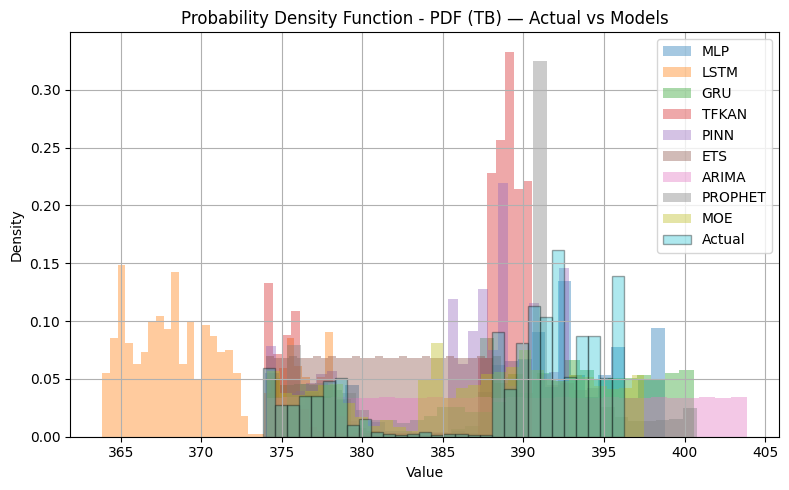

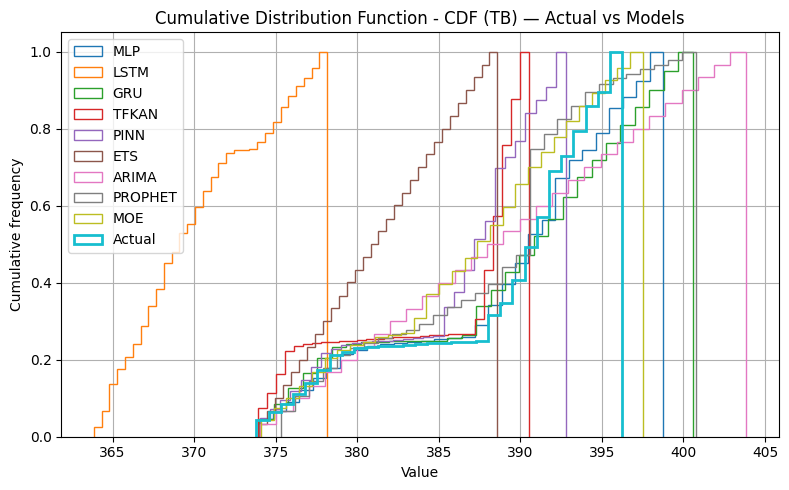


==== KS table (TB) ====
         KS statistic  p-value                      Interpretation
Model                                                             
MLP            0.1517      0.0  Different distributions (p < 0.05)
LSTM           0.8313      0.0  Different distributions (p < 0.05)
GRU            0.2337      0.0  Different distributions (p < 0.05)
TFKAN          0.5815      0.0  Different distributions (p < 0.05)
PINN           0.3779      0.0  Different distributions (p < 0.05)
ETS            0.7276      0.0  Different distributions (p < 0.05)
ARIMA          0.2564      0.0  Different distributions (p < 0.05)
PROPHET        0.2356      0.0  Different distributions (p < 0.05)
MOE            0.2667      0.0  Different distributions (p < 0.05)


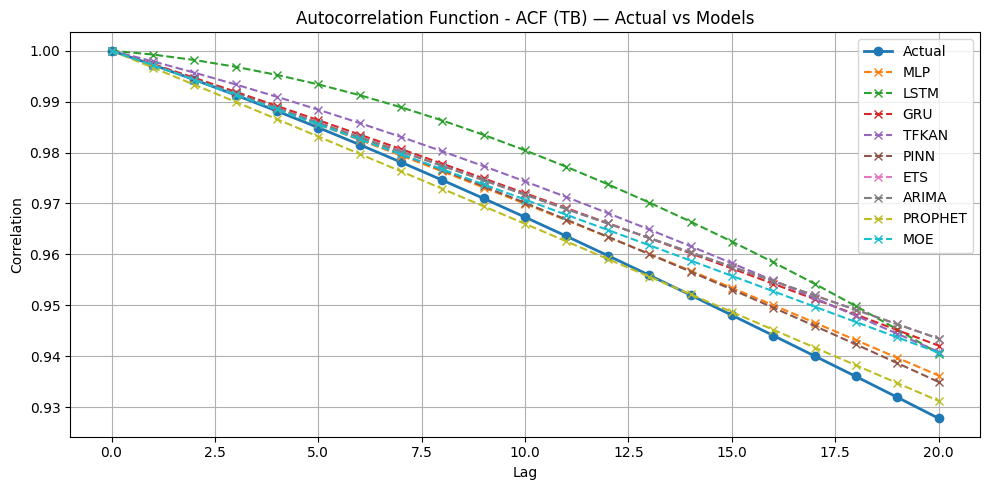


✅ Saved files:
- distribution_analysis_series_tb_en.csv
- model_metrics_tb_en.csv
- ks_table_tb_en.csv
- acf_models_tb_en.csv
- pdf_models_tb_en.png
- cdf_models_tb_en.png
- acf_models_tb_en.png
- qqplot_tb_en_*.png (if ks_qq_analysis is enabled)


In [ ]:
# ============================================================
# COMPLETE CODE — PDF/CDF + KS + QQ + ACF
# MLP + LSTM + GRU + PINN + TFKAN + EXP + ARIMA + PROPHET + MOE
# CORRECT TB SCALE + PNG AND CSV EXPORT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.stats import ks_2samp
from statsmodels.graphics.gofplots import qqplot_2samples
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score

# ========================== CONFIG ==========================
ARIMA_ORDER = best_order if "best_order" in globals() else (3, 1, 3)

# ========================== UTIL ==========================
def _as_1d(a):
    return np.asarray(a).reshape(-1)

def _inv_diff(scaler, x):
    x = _as_1d(x).astype(np.float32)
    return scaler.inverse_transform(x.reshape(-1, 1)).ravel()

def _safe_split_idx(series):
    return int(split) if "split" in globals() else int(len(series) * 0.9)

def _reconstruct_abs(series, split_idx, window, deltas_inv):
    deltas_inv = _as_1d(deltas_inv)
    base_pos = split_idx + window - 1

    if base_pos >= len(series):
        raise IndexError(
            f"Base index out of range: split_idx + window - 1 = {base_pos}, "
            f"len(series) = {len(series)}"
        )

    base_value = float(series[base_pos])
    return base_value + np.cumsum(deltas_inv)

def _align_pair(y_true, y_pred):
    y_true = _as_1d(y_true)
    y_pred = _as_1d(y_pred)
    n = min(len(y_true), len(y_pred))
    return y_true[:n], y_pred[:n]

def _common_align(real_dict, pred_dict):
    aligned = {}
    min_len = np.inf

    for name in pred_dict:
        yt, yp = _align_pair(real_dict[name], pred_dict[name])
        aligned[f"{name}_real"] = yt
        aligned[f"{name}_pred"] = yp
        min_len = min(min_len, len(yt), len(yp))

    min_len = int(min_len)

    real_out = {}
    pred_out = {}

    for name in pred_dict:
        real_out[name] = aligned[f"{name}_real"][:min_len]
        pred_out[name] = aligned[f"{name}_pred"][:min_len]

    return real_out, pred_out, min_len

def _safe_acf(x, lags=20):
    x = _as_1d(x)

    if len(x) < 3:
        return np.array([1.0])

    safe_lags = min(lags, len(x) - 1)
    return acf(x, nlags=safe_lags)

# ========================== BASELINE EXP ==========================
def exp_forecast_diff(y_train_diff, steps):
    model = ExponentialSmoothing(
        _as_1d(y_train_diff),
        trend=None,
        seasonal=None
    )

    fit = model.fit(optimized=True)
    return _as_1d(fit.forecast(steps))

# ========================== BASELINE ARIMA ==========================
def arima_forecast_diff(y_train_diff, steps, order=(1, 0, 1)):
    model = ARIMA(_as_1d(y_train_diff), order=order)
    fit = model.fit()
    return _as_1d(fit.forecast(steps))

# ========================== PDF ==========================
def plot_pdf(
    y_actual,
    y_preds_dict,
    bins=30,
    title="Probability Density Function - PDF (TB) — Actual vs Models",
    save_path=None
):
    plt.figure(figsize=(8, 5))

    for name, y_pred in y_preds_dict.items():
        plt.hist(
            _as_1d(y_pred),
            bins=bins,
            density=True,
            alpha=0.40,
            label=name
        )

    plt.hist(
        _as_1d(y_actual),
        bins=bins,
        density=True,
        alpha=0.35,
        label="Actual",
        edgecolor="black"
    )

    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# ========================== CDF ==========================
def plot_cdf(
    y_actual,
    y_preds_dict,
    bins=30,
    title="Cumulative Distribution Function - CDF (TB) — Actual vs Models",
    save_path=None
):
    plt.figure(figsize=(8, 5))

    for name, y_pred in y_preds_dict.items():
        plt.hist(
            _as_1d(y_pred),
            bins=bins,
            density=True,
            cumulative=True,
            histtype="step",
            label=name
        )

    plt.hist(
        _as_1d(y_actual),
        bins=bins,
        density=True,
        cumulative=True,
        histtype="step",
        label="Actual",
        linewidth=2
    )

    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Cumulative frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# ========================== KS + QQ ==========================
def ks_qq_analysis(y_actual, y_preds_dict, save_prefix="qqplot_tb_en"):
    y_actual = _as_1d(y_actual)

    for name, y_pred in y_preds_dict.items():
        y_pred = _as_1d(y_pred)
        yt, yp = _align_pair(y_actual, y_pred)

        print(f"\n📊 {name} - Kolmogorov-Smirnov test:")
        ks_stat, ks_p = ks_2samp(yt, yp)

        print(f"KS statistic: {ks_stat:.4f}, p-value: {ks_p:.6f}")

        plt.figure(figsize=(5, 5))
        qqplot_2samples(yp, yt, line="45")

        plt.title(f"QQ-Plot: {name} vs Actual")
        plt.xlabel("Model quantiles")
        plt.ylabel("Actual quantiles")

        plt.grid(True)
        plt.tight_layout()
        plt.savefig(
            f"{save_prefix}_{name.lower()}.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

def ks_test_models(y_actual, y_preds_dict):
    y_actual = _as_1d(y_actual)
    results = []

    for name, y_pred in y_preds_dict.items():
        y_pred = _as_1d(y_pred)
        yt, yp = _align_pair(y_actual, y_pred)

        stat, pval = ks_2samp(yt, yp)

        interpretation = (
            "Different distributions (p < 0.05)"
            if pval < 0.05 else
            "Similar distributions (p ≥ 0.05)"
        )

        results.append({
            "Model": name,
            "KS statistic": round(float(stat), 4),
            "p-value": round(float(pval), 6),
            "Interpretation": interpretation
        })

    return pd.DataFrame(results).set_index("Model")

# ========================== ACF ==========================
def plot_acf_comparison(
    y_actual,
    y_preds_dict,
    lags=20,
    title="Autocorrelation Function - ACF (TB) — Actual vs Models",
    save_path=None
):
    plt.figure(figsize=(10, 5))

    y_actual = _as_1d(y_actual)
    acf_actual = _safe_acf(y_actual, lags=lags)

    plt.plot(
        np.arange(len(acf_actual)),
        acf_actual,
        label="Actual",
        marker="o",
        linewidth=2
    )

    for name, y_pred in y_preds_dict.items():
        y_pred = _as_1d(y_pred)
        acf_model = _safe_acf(y_pred, lags=lags)

        m = min(len(acf_actual), len(acf_model))

        plt.plot(
            np.arange(m),
            acf_model[:m],
            marker="x",
            linestyle="--",
            label=name
        )

    plt.title(title)
    plt.xlabel("Lag")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# ============================================================
# EXECUTION
# ============================================================

split_idx = _safe_split_idx(series)

# ---------- 1) Predictions in diff_norm space ----------
p_mlp = _as_1d(
    model_mlp(
        tf.convert_to_tensor(X_test_mlp, dtype=tf.float32),
        training=False
    ).numpy()
)

p_lstm = _as_1d(
    model_lstm(
        tf.convert_to_tensor(X_test_lstm, dtype=tf.float32),
        training=False
    ).numpy()
)

p_gru = _as_1d(
    model_gru(
        tf.convert_to_tensor(X_test_gru, dtype=tf.float32),
        training=False
    ).numpy()
)

p_tfkan = _as_1d(
    model_tfkan(
        tf.convert_to_tensor(X_test_tfkan, dtype=tf.float32),
        training=False
    ).numpy()
)

p_pinn_seq = model_pinn(
    tf.convert_to_tensor(X_test_pint, dtype=tf.float32),
    training=False
).numpy()

p_pinn = _as_1d(p_pinn_seq[:, -1, 0])

p_exp = exp_forecast_diff(
    diff_train_norm[:, 0],
    len(y_test_mlp)
)

p_arima = arima_forecast_diff(
    diff_train_norm[:, 0],
    len(y_test_mlp),
    order=ARIMA_ORDER
)

# ---------- 2) Inverse transformation of deltas ----------
d_actual = {
    "MLP": _inv_diff(scaler, y_test_mlp),
    "LSTM": _inv_diff(scaler, y_test_lstm),
    "GRU": _inv_diff(scaler, y_test_gru),
    "TFKAN": _inv_diff(scaler, y_test_tfkan),
    "PINN": _inv_diff(scaler, y_test_pint),
    "ETS": _inv_diff(scaler, y_test_mlp),
    "ARIMA": _inv_diff(scaler, y_test_mlp),
}

d_pred = {
    "MLP": _inv_diff(scaler, p_mlp),
    "LSTM": _inv_diff(scaler, p_lstm),
    "GRU": _inv_diff(scaler, p_gru),
    "TFKAN": _inv_diff(scaler, p_tfkan),
    "PINN": _inv_diff(scaler, p_pinn),
    "ETS": _inv_diff(scaler, p_exp),
    "ARIMA": _inv_diff(scaler, p_arima),
}

# ---------- 3) Absolute reconstruction ----------
y_actual_abs_dict = {
    "MLP": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_actual["MLP"]),
    "LSTM": _reconstruct_abs(series, split_idx, BEST_WINDOW_LSTM, d_actual["LSTM"]),
    "GRU": _reconstruct_abs(series, split_idx, BEST_WINDOW_GRU, d_actual["GRU"]),
    "TFKAN": _reconstruct_abs(series, split_idx, BEST_WINDOW_TFKAN, d_actual["TFKAN"]),
    "PINN": _reconstruct_abs(series, split_idx, BEST_WINDOW_PINT, d_actual["PINN"]),
    "ETS": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_actual["ETS"]),
    "ARIMA": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_actual["ARIMA"]),
}

y_pred_abs_dict = {
    "MLP": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_pred["MLP"]),
    "LSTM": _reconstruct_abs(series, split_idx, BEST_WINDOW_LSTM, d_pred["LSTM"]),
    "GRU": _reconstruct_abs(series, split_idx, BEST_WINDOW_GRU, d_pred["GRU"]),
    "TFKAN": _reconstruct_abs(series, split_idx, BEST_WINDOW_TFKAN, d_pred["TFKAN"]),
    "PINN": _reconstruct_abs(series, split_idx, BEST_WINDOW_PINT, d_pred["PINN"]),
    "ETS": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_pred["ETS"]),
    "ARIMA": _reconstruct_abs(series, split_idx, BEST_WINDOW_MLP, d_pred["ARIMA"]),
}

# ---------- 3.1) Prophet ----------
if "y_test_abs_prophet" in globals() and "y_pred_abs_prophet" in globals():
    y_actual_abs_dict["PROPHET"] = _as_1d(y_test_abs_prophet)
    y_pred_abs_dict["PROPHET"] = _as_1d(y_pred_abs_prophet)

elif "y_test_abs_prophet_tb" in globals() and "y_pred_abs_prophet_tb" in globals():
    y_actual_abs_dict["PROPHET"] = _as_1d(y_test_abs_prophet_tb) * 1e12
    y_pred_abs_dict["PROPHET"] = _as_1d(y_pred_abs_prophet_tb) * 1e12

# ---------- 3.2) MoE ----------
if "y_test_abs_moe" in globals() and "y_pred_abs_moe" in globals():
    y_actual_abs_dict["MOE"] = _as_1d(y_test_abs_moe)
    y_pred_abs_dict["MOE"] = _as_1d(y_pred_abs_moe)

elif "y_test_abs_moe_tb" in globals() and "y_pred_abs_moe_tb" in globals():
    y_actual_abs_dict["MOE"] = _as_1d(y_test_abs_moe_tb) * 1e12
    y_pred_abs_dict["MOE"] = _as_1d(y_pred_abs_moe_tb) * 1e12

elif "y_pred_abs_moe_tb" in globals():
    y_actual_abs_dict["MOE"] = _as_1d(y_test_abs_arima_tb) * 1e12
    y_pred_abs_dict["MOE"] = _as_1d(y_pred_abs_moe_tb) * 1e12

elif "y_pred_moe_tb" in globals():
    y_actual_abs_dict["MOE"] = _as_1d(y_test_abs_arima_tb) * 1e12
    y_pred_abs_dict["MOE"] = _as_1d(y_pred_moe_tb) * 1e12

# ---------- 4) Global alignment ----------
actual_aligned_abs, pred_aligned_abs, min_len = _common_align(
    y_actual_abs_dict,
    y_pred_abs_dict
)

y_actual_abs = actual_aligned_abs["MLP"]

y_preds_abs = {
    "MLP": pred_aligned_abs["MLP"],
    "LSTM": pred_aligned_abs["LSTM"],
    "GRU": pred_aligned_abs["GRU"],
    "TFKAN": pred_aligned_abs["TFKAN"],
    "PINN": pred_aligned_abs["PINN"],
    "ETS": pred_aligned_abs["ETS"],
    "ARIMA": pred_aligned_abs["ARIMA"],
}

if "PROPHET" in pred_aligned_abs:
    y_preds_abs["PROPHET"] = pred_aligned_abs["PROPHET"]

if "MOE" in pred_aligned_abs:
    y_preds_abs["MOE"] = pred_aligned_abs["MOE"]

# ---------- 5) Convert to TB ----------
TO_TB = 1e12

y_actual_tb = y_actual_abs / TO_TB
y_preds_tb = {
    name: values / TO_TB
    for name, values in y_preds_abs.items()
}

# ---------- 6) Save aligned series ----------
df_series = pd.DataFrame({
    "Actual_TB": y_actual_tb,
    "MLP_TB": y_preds_tb["MLP"],
    "LSTM_TB": y_preds_tb["LSTM"],
    "GRU_TB": y_preds_tb["GRU"],
    "TFKAN_TB": y_preds_tb["TFKAN"],
    "PINN_TB": y_preds_tb["PINN"],
    "ETS_TB": y_preds_tb["ETS"],
    "ARIMA_TB": y_preds_tb["ARIMA"],
    "PROPHET_TB": y_preds_tb["PROPHET"] if "PROPHET" in y_preds_tb else np.nan,
    "MOE_TB": y_preds_tb["MOE"] if "MOE" in y_preds_tb else np.nan,
})

df_series.to_csv(
    "distribution_analysis_series_tb_en.csv",
    index=False
)

# ---------- 7) Metrics ----------
metric_rows = []

print("\n================ METRICS IN ABSOLUTE SCALE (TB) ================\n")

for name, y_pred in y_preds_tb.items():
    yt, yp = _align_pair(y_actual_tb, y_pred)

    mse = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    r2 = r2_score(yt, yp)

    metric_rows.append({
        "Model": name,
        "MSE_TB": float(mse),
        "RMSE_TB": float(rmse),
        "R2_TB": float(r2)
    })

    print(
        f"{name:<8} | "
        f"MSE={mse:.6e} | "
        f"RMSE={rmse:.6e} | "
        f"R²={r2:.6f}"
    )

df_metrics = pd.DataFrame(metric_rows)

df_metrics.to_csv(
    "model_metrics_tb_en.csv",
    index=False
)

# ---------- 8) Plots ----------
plot_pdf(
    y_actual_tb,
    y_preds_tb,
    bins=30,
    title="Probability Density Function - PDF (TB) — Actual vs Models",
    save_path="pdf_models_tb_en.png"
)

plot_cdf(
    y_actual_tb,
    y_preds_tb,
    bins=30,
    title="Cumulative Distribution Function - CDF (TB) — Actual vs Models",
    save_path="cdf_models_tb_en.png"
)

# ---------- 9) KS ----------
df_ks = ks_test_models(
    y_actual_tb,
    y_preds_tb
)

print("\n==== KS table (TB) ====")
print(df_ks)

df_ks.to_csv(
    "ks_table_tb_en.csv"
)

# ---------- 10) ACF plot + CSV ----------
plot_acf_comparison(
    y_actual_tb,
    y_preds_tb,
    lags=20,
    title="Autocorrelation Function - ACF (TB) — Actual vs Models",
    save_path="acf_models_tb_en.png"
)

acf_data = {
    "lag": np.arange(len(_safe_acf(y_actual_tb, lags=20)))
}

acf_data["Actual"] = _safe_acf(y_actual_tb, lags=20)

for name, y_pred in y_preds_tb.items():
    vals = _safe_acf(y_pred, lags=20)
    max_len = len(acf_data["lag"])

    col = np.full(max_len, np.nan)
    col[:min(max_len, len(vals))] = vals[:min(max_len, len(vals))]

    acf_data[name] = col

df_acf = pd.DataFrame(acf_data)

df_acf.to_csv(
    "acf_models_tb_en.csv",
    index=False
)

# ---------- 11) Optional QQ plots ----------
# Uncomment to generate QQ plots:
# ks_qq_analysis(y_actual_tb, y_preds_tb, save_prefix="qqplot_tb_en")

print("\n✅ Saved files:")
print("- distribution_analysis_series_tb_en.csv")
print("- model_metrics_tb_en.csv")
print("- ks_table_tb_en.csv")
print("- acf_models_tb_en.csv")
print("- pdf_models_tb_en.png")
print("- cdf_models_tb_en.png")
print("- acf_models_tb_en.png")
print("- qqplot_tb_en_*.png (if ks_qq_analysis is enabled)")

In [ ]:
if SAVE == 1:
    # ============================================================
    # 💾 SAVE EVERYTHING - DISTRIBUTIONAL ANALYSIS
    # ============================================================

    import os
    import json
    import shutil
    import numpy as np
    import pandas as pd

    ANALYSIS_NAME = "dist_analysis"

    os.makedirs(BASE_PATH, exist_ok=True)

    # ============================================================
    # 1) SAVE MAIN TABLES
    # ============================================================
    df_series.to_csv(f"{BASE_PATH}/analise_distribuicoes_series_tb.csv", index=False)
    df_metrics.to_csv(f"{BASE_PATH}/metricas_modelos_tb.csv", index=False)
    df_ks.to_csv(f"{BASE_PATH}/tabela_ks_tb.csv")
    df_acf.to_csv(f"{BASE_PATH}/acf_modelos_tb.csv", index=False)

    # ============================================================
    # 2) SAVE ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/y_real_tb.npy", y_real_tb)

    for nome, arr in y_preds_tb.items():
        np.save(f"{BASE_PATH}/y_pred_tb_{nome.lower()}.npy", np.asarray(arr))

    # aligned abs versions too
    for nome, arr in real_aligned_abs.items():
        np.save(f"{BASE_PATH}/y_real_abs_aligned_{nome.lower()}.npy", np.asarray(arr))

    for nome, arr in pred_aligned_abs.items():
        np.save(f"{BASE_PATH}/y_pred_abs_aligned_{nome.lower()}.npy", np.asarray(arr))

    # raw reconstructed absolute dictionaries
    for nome, arr in y_real_abs_dict.items():
        np.save(f"{BASE_PATH}/y_real_abs_raw_{nome.lower()}.npy", np.asarray(arr))

    for nome, arr in y_pred_abs_dict.items():
        np.save(f"{BASE_PATH}/y_pred_abs_raw_{nome.lower()}.npy", np.asarray(arr))

    # ============================================================
    # 3) SAVE CONFIG
    # ============================================================
    analysis_config = {
        "analysis_name": ANALYSIS_NAME,
        "arima_order": list(ARIMA_ORDER) if isinstance(ARIMA_ORDER, tuple) else ARIMA_ORDER,
        "split_idx": int(split_idx),
        "min_len_aligned": int(min_len),
        "to_tb_divisor": float(TO_TB),
        "models_included": list(y_preds_tb.keys()),
        "reference_real_model": "MLP",
        "qqplots_enabled": False,
    }

    with open(f"{BASE_PATH}/{ANALYSIS_NAME}_config.json", "w", encoding="utf-8") as f:
        json.dump(analysis_config, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 4) SAVE METADATA / SUMMARY
    # ============================================================
    analysis_summary = {
        "series_rows": int(len(df_series)),
        "metrics_rows": int(len(df_metrics)),
        "ks_rows": int(len(df_ks)),
        "acf_rows": int(len(df_acf)),
    }

    with open(f"{BASE_PATH}/{ANALYSIS_NAME}_summary.json", "w", encoding="utf-8") as f:
        json.dump(analysis_summary, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 5) SAVE MODEL METRICS DICT
    # ============================================================
    metrics_dict = {}
    for _, row in df_metrics.iterrows():
        metrics_dict[str(row["Modelo"])] = {
            "MSE_TB": float(row["MSE_TB"]),
            "RMSE_TB": float(row["RMSE_TB"]),
            "R2_TB": float(row["R2_TB"]),
        }

    with open(f"{BASE_PATH}/{ANALYSIS_NAME}_metrics_dict.json", "w", encoding="utf-8") as f:
        json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 6) COPY GENERATED FILES
    # ============================================================
    artifact_files = [
        "analise_distribuicoes_series_tb.csv",
        "metricas_modelos_tb.csv",
        "tabela_ks_tb.csv",
        "acf_modelos_tb.csv",
        "pdf_modelos_tb.png",
        "cdf_modelos_tb.png",
        "acf_modelos_tb.png",
    ]

    for fname in artifact_files:
        if os.path.exists(fname):
            dest = os.path.join(BASE_PATH, fname)
            if os.path.abspath(fname) != os.path.abspath(dest):
                shutil.copy2(fname, dest)

    # optional QQ plots
    for nome in y_preds_tb.keys():
        qq_file = f"qqplot_tb_{nome.lower()}.png"
        if os.path.exists(qq_file):
            dest = os.path.join(BASE_PATH, qq_file)
            if os.path.abspath(qq_file) != os.path.abspath(dest):
                shutil.copy2(qq_file, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All distributive-analysis artifacts saved in:\n{BASE_PATH}")
    print("Models included:", ", ".join(y_preds_tb.keys()))

In [33]:
# ============================================================
# Conversão para TB + Gráficos combinados com MOE
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

series_tb = np.asarray(series, dtype=np.float64) / 1e12

forecast_tb_mlp     = np.asarray(forecast_abs_mlp, dtype=np.float64) / 1e12 if 'forecast_abs_mlp' in globals() else None
forecast_tb_lstm    = np.asarray(forecast_abs_lstm, dtype=np.float64) / 1e12 if 'forecast_abs_lstm' in globals() else None
forecast_tb_gru     = np.asarray(forecast_abs_gru, dtype=np.float64) / 1e12 if 'forecast_abs_gru' in globals() else None
forecast_tb_pint    = np.asarray(forecast_abs_pint, dtype=np.float64) / 1e12 if 'forecast_abs_pint' in globals() else None
forecast_tb_tfkan   = np.asarray(forecast_abs_tfkan, dtype=np.float64) / 1e12 if 'forecast_abs_tfkan' in globals() else None
forecast_tb_exp     = np.asarray(forecast_abs_exp, dtype=np.float64) / 1e12 if 'forecast_abs_exp' in globals() else None
forecast_tb_arima   = np.asarray(forecast_abs_arima, dtype=np.float64) / 1e12 if 'forecast_abs_arima' in globals() else None
forecast_tb_prophet = np.asarray(forecast_abs_prophet, dtype=np.float64) / 1e12 if 'forecast_abs_prophet' in globals() else None
forecast_tb_moe     = np.asarray(forecast_abs_moe, dtype=np.float64) / 1e12 if 'forecast_abs_moe' in globals() else None

# ============================================================
# Eixo x do histórico
# ============================================================
x_hist = np.arange(len(series_tb))

# ============================================================
# Eixos x das previsões
# ============================================================
if 'x_fore_mlp' not in globals() and forecast_tb_mlp is not None:
    x_fore_mlp = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_mlp))

if 'x_fore_lstm' not in globals() and forecast_tb_lstm is not None:
    x_fore_lstm = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_lstm))

if 'x_fore_gru' not in globals() and forecast_tb_gru is not None:
    x_fore_gru = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_gru))

if 'x_fore_pint' not in globals() and forecast_tb_pint is not None:
    x_fore_pint = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_pint))

if 'x_fore_tfkan' not in globals() and forecast_tb_tfkan is not None:
    x_fore_tfkan = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_tfkan))

if 'x_fore_exp' not in globals() and forecast_tb_exp is not None:
    x_fore_exp = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_exp))

if 'x_fore_arima' not in globals() and forecast_tb_arima is not None:
    x_fore_arima = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_arima))

if 'x_fore_prophet' not in globals() and forecast_tb_prophet is not None:
    x_fore_prophet = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_prophet))

if 'x_fore_moe' not in globals() and forecast_tb_moe is not None:
    x_fore_moe = np.arange(len(series_tb), len(series_tb) + len(forecast_tb_moe))

# ============================================================
# Montagem do texto da janela para o título
# ============================================================
windows_pt = []
windows_en = []

if 'BEST_WINDOW_MLP' in globals():
    windows_pt.append(str(BEST_WINDOW_MLP))
    windows_en.append(str(BEST_WINDOW_MLP))
if 'BEST_WINDOW_LSTM' in globals():
    windows_pt.append(str(BEST_WINDOW_LSTM))
    windows_en.append(str(BEST_WINDOW_LSTM))
if 'BEST_WINDOW_GRU' in globals():
    windows_pt.append(str(BEST_WINDOW_GRU))
    windows_en.append(str(BEST_WINDOW_GRU))
if 'BEST_WINDOW_PINT' in globals():
    windows_pt.append(str(BEST_WINDOW_PINT))
    windows_en.append(str(BEST_WINDOW_PINT))
if 'BEST_WINDOW_TFKAN' in globals():
    windows_pt.append(str(BEST_WINDOW_TFKAN))
    windows_en.append(str(BEST_WINDOW_TFKAN))

window_text_pt = "/".join(windows_pt) if windows_pt else "N/A"
window_text_en = "/".join(windows_en) if windows_en else "N/A"

# ============================================================
# Gráfico em português
# ============================================================
plt.figure(figsize=(12, 5))

plt.plot(x_hist, series_tb, label="Histórico", linewidth=2)

if forecast_tb_mlp is not None:
    plt.plot(x_fore_mlp, forecast_tb_mlp, color='darkorange', linestyle='--',
             label=f"MLP - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_lstm is not None:
    plt.plot(x_fore_lstm, forecast_tb_lstm, color='darkred', linestyle='--',
             label=f"LSTM - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_gru is not None:
    plt.plot(x_fore_gru, forecast_tb_gru, color='darkgreen', linestyle='--',
             label=f"GRU - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_pint is not None:
    plt.plot(x_fore_pint, forecast_tb_pint, color='purple', linestyle='--',
             label=f"PINT - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_tfkan is not None:
    plt.plot(x_fore_tfkan, forecast_tb_tfkan, color='red', linestyle='--',
             label=f"TFKAN - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_exp is not None:
    plt.plot(x_fore_exp, forecast_tb_exp, color='brown', linestyle='--',
             label=f"EXP - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_arima is not None:
    arima_label_pt = f"ARIMA{best_order}" if 'best_order' in globals() else "ARIMA"
    plt.plot(x_fore_arima, forecast_tb_arima, color='navy', linestyle='--',
             label=f"{arima_label_pt} - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_prophet is not None:
    plt.plot(x_fore_prophet, forecast_tb_prophet, color='magenta', linestyle='--',
             label=f"Prophet - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_moe is not None:
    plt.plot(x_fore_moe, forecast_tb_moe, color='black', linestyle='--', linewidth=3,
             label=f"MOE - Previsão {FORECAST_DAYS} dias ({FORECAST_STEPS} {time_unit}s)")

plt.title(
    f"Previsão Combinada ({FORECAST_DAYS} dias = {FORECAST_STEPS} {time_unit}s) - "
    f"Janelas={window_text_pt}"
)
plt.xlabel(f"Tempo ({time_unit}s)")
plt.ylabel("Valor (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("forecast_combined_pt.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Gráfico em inglês
# ============================================================
plt.figure(figsize=(12, 5))

plt.plot(x_hist, series_tb, label="Historical data", linewidth=2)

if forecast_tb_mlp is not None:
    plt.plot(x_fore_mlp, forecast_tb_mlp, color='darkorange', linestyle='--',
             label=f"MLP - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_lstm is not None:
    plt.plot(x_fore_lstm, forecast_tb_lstm, color='darkred', linestyle='--',
             label=f"LSTM - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_gru is not None:
    plt.plot(x_fore_gru, forecast_tb_gru, color='darkgreen', linestyle='--',
             label=f"GRU - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_pint is not None:
    plt.plot(x_fore_pint, forecast_tb_pint, color='purple', linestyle='--',
             label=f"PINN - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_tfkan is not None:
    plt.plot(x_fore_tfkan, forecast_tb_tfkan, color='red', linestyle='--',
             label=f"TFKAN - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_exp is not None:
    plt.plot(x_fore_exp, forecast_tb_exp, color='brown', linestyle='--',
             label=f"EXP - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_arima is not None:
    arima_label_en = f"ARIMA{best_order}" if 'best_order' in globals() else "ARIMA"
    plt.plot(x_fore_arima, forecast_tb_arima, color='navy', linestyle='--',
             label=f"{arima_label_en} - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_prophet is not None:
    plt.plot(x_fore_prophet, forecast_tb_prophet, color='magenta', linestyle='--',
             label=f"Prophet - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

if forecast_tb_moe is not None:
    plt.plot(x_fore_moe, forecast_tb_moe, color='black', linestyle='--', linewidth=3,
             label=f"MOE - Forecast {FORECAST_DAYS} days ({FORECAST_STEPS} {time_unit}s)")

plt.title(
    f"Forecast ({FORECAST_DAYS} days = {FORECAST_STEPS} {time_unit}s) - "
    f"Window={window_text_en}"
)
plt.xlabel(f"Time ({time_unit}s)")
plt.ylabel("Value (TB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("forecast_combined_en.png", dpi=300, bbox_inches="tight")
plt.show()

TypeError: object of type 'numpy.float64' has no len()


FORECASTS LOADED
MLP        | shape=(8640,)      | initial=   396.174 TB | final=   813.497 TB
LSTM       | shape=(8640,)      | initial=   396.128 TB | final=   633.844 TB
GRU        | shape=(8640,)      | initial=   396.185 TB | final=   577.996 TB
PINN       | shape=(8640,)      | initial=   396.153 TB | final=   483.273 TB
TFKAN      | shape=(8640,)      | initial=   396.140 TB | final=   422.000 TB
EXP        | shape=(8640,)      | initial=   396.140 TB | final=   515.014 TB
ARIMA      | shape=(8640,)      | initial=   396.185 TB | final=   639.005 TB
PROPHET    | shape=(8640,)      | initial=   396.126 TB | final=   574.086 TB
MOE        | shape=(8640,)      | initial=   396.173 TB | final=   810.673 TB

MOE CHECK
------------------------------------------------------------------------------
MOE forecast length    : 8640
MOE initial forecast   : 396.173 TB
MOE final forecast     : 810.673 TB
MOE minimum            : 396.173 TB
MOE maximum            : 810.673 TB


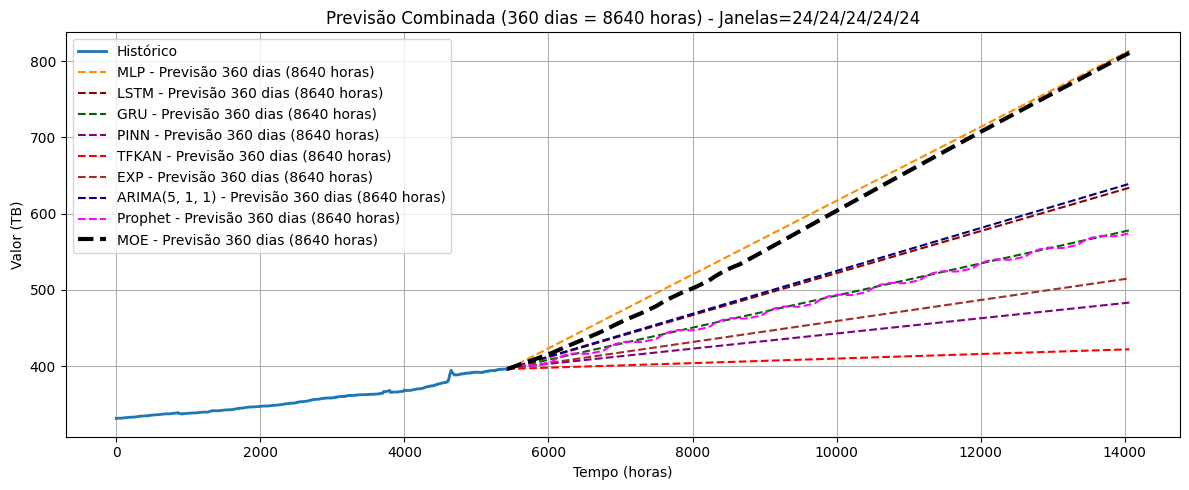

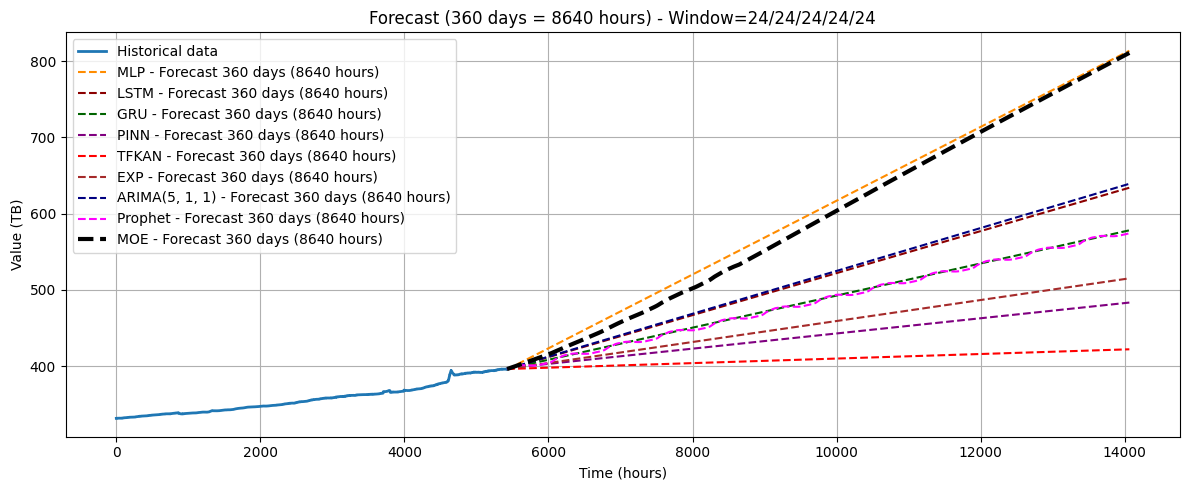

In [36]:
#AFTER RELOAD ONLY
# ============================================================
# 📊 COMBINED FORECAST - ALL MODELS + MOE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 🔧 AUXILIARY FUNCTIONS
# ============================================================

def _to_1d(x):
    """
    Convert array-like object to a 1-D float64 array.
    Returns None if x is None or scalar.
    """
    if x is None:
        return None

    arr = np.asarray(x, dtype=np.float64)

    if arr.ndim == 0:
        return None

    return arr.reshape(-1)


def _future_x(forecast, history_length):
    """
    Create future x-axis immediately after historical data.
    """
    if forecast is None:
        return None

    return np.arange(
        history_length,
        history_length + len(forecast)
    )


# ============================================================
# 📈 HISTORICAL SERIES
# ============================================================

series_tb = (
    np.asarray(series, dtype=np.float64)
    .reshape(-1)
    / 1e12
)

x_hist = np.arange(len(series_tb))


# ============================================================
# 📈 FORECASTS - INDIVIDUAL MODELS
#
# forecast_abs_* variables are stored in bytes.
# Convert them to TB.
# ============================================================

forecast_tb_mlp = (
    _to_1d(forecast_abs_mlp) / 1e12
    if (
        'forecast_abs_mlp' in globals()
        and forecast_abs_mlp is not None
        and not np.isscalar(forecast_abs_mlp)
    )
    else None
)

forecast_tb_lstm = (
    _to_1d(forecast_abs_lstm) / 1e12
    if (
        'forecast_abs_lstm' in globals()
        and forecast_abs_lstm is not None
        and not np.isscalar(forecast_abs_lstm)
    )
    else None
)

forecast_tb_gru = (
    _to_1d(forecast_abs_gru) / 1e12
    if (
        'forecast_abs_gru' in globals()
        and forecast_abs_gru is not None
        and not np.isscalar(forecast_abs_gru)
    )
    else None
)

forecast_tb_pint = (
    _to_1d(forecast_abs_pint) / 1e12
    if (
        'forecast_abs_pint' in globals()
        and forecast_abs_pint is not None
        and not np.isscalar(forecast_abs_pint)
    )
    else None
)

forecast_tb_tfkan = (
    _to_1d(forecast_abs_tfkan) / 1e12
    if (
        'forecast_abs_tfkan' in globals()
        and forecast_abs_tfkan is not None
        and not np.isscalar(forecast_abs_tfkan)
    )
    else None
)

forecast_tb_exp = (
    _to_1d(forecast_abs_exp) / 1e12
    if (
        'forecast_abs_exp' in globals()
        and forecast_abs_exp is not None
        and not np.isscalar(forecast_abs_exp)
    )
    else None
)

forecast_tb_arima = (
    _to_1d(forecast_abs_arima) / 1e12
    if (
        'forecast_abs_arima' in globals()
        and forecast_abs_arima is not None
        and not np.isscalar(forecast_abs_arima)
    )
    else None
)

forecast_tb_prophet = (
    _to_1d(forecast_abs_prophet) / 1e12
    if (
        'forecast_abs_prophet' in globals()
        and forecast_abs_prophet is not None
        and not np.isscalar(forecast_abs_prophet)
    )
    else None
)


# ============================================================
# 🧠 MOE FORECAST
#
# IMPORTANT:
# moe_future_forecast_tb.csv contains:
#
#   forecast_step | MoE_TB
#
# Therefore:
#   forecast_step -> x/index
#   MoE_TB        -> actual forecast
#
# MoE_TB is ALREADY in TB.
# DO NOT divide it by 1e12.
# ============================================================

forecast_tb_moe = None

if (
    'df_moe_forecast' in globals()
    and df_moe_forecast is not None
):

    if "MoE_TB" not in df_moe_forecast.columns:
        raise KeyError(
            "Column 'MoE_TB' not found in "
            "moe_future_forecast_tb.csv. "
            f"Available columns: "
            f"{df_moe_forecast.columns.tolist()}"
        )

    forecast_tb_moe = (
        df_moe_forecast["MoE_TB"]
        .to_numpy(dtype=np.float64)
        .reshape(-1)
    )

# Fallback if dataframe is unavailable but reload array exists
elif (
    'forecast_abs_moe_tb' in globals()
    and forecast_abs_moe_tb is not None
    and not np.isscalar(forecast_abs_moe_tb)
):

    forecast_tb_moe = (
        np.asarray(
            forecast_abs_moe_tb,
            dtype=np.float64
        )
        .reshape(-1)
    )

# Fallback for original execution before reload
elif (
    'forecast_abs_moe' in globals()
    and forecast_abs_moe is not None
    and not np.isscalar(forecast_abs_moe)
):

    forecast_tb_moe = (
        np.asarray(
            forecast_abs_moe,
            dtype=np.float64
        )
        .reshape(-1)
        / 1e12
    )


# ============================================================
# 📐 FUTURE X-AXES
# ============================================================

x_fore_mlp = _future_x(
    forecast_tb_mlp,
    len(series_tb)
)

x_fore_lstm = _future_x(
    forecast_tb_lstm,
    len(series_tb)
)

x_fore_gru = _future_x(
    forecast_tb_gru,
    len(series_tb)
)

x_fore_pint = _future_x(
    forecast_tb_pint,
    len(series_tb)
)

x_fore_tfkan = _future_x(
    forecast_tb_tfkan,
    len(series_tb)
)

x_fore_exp = _future_x(
    forecast_tb_exp,
    len(series_tb)
)

x_fore_arima = _future_x(
    forecast_tb_arima,
    len(series_tb)
)

x_fore_prophet = _future_x(
    forecast_tb_prophet,
    len(series_tb)
)

x_fore_moe = _future_x(
    forecast_tb_moe,
    len(series_tb)
)


# ============================================================
# ⏱️ TIME UNIT
# ============================================================

# ECS hourly dataset:
# 8640 forecast steps = 8640 hours = 360 days

if FORECAST_STEPS == 8640:
    plot_time_unit_pt = "horas"
    plot_time_unit_en = "hours"

elif FORECAST_STEPS == 360:
    plot_time_unit_pt = "dias"
    plot_time_unit_en = "days"

else:
    if str(time_unit).lower() in ["hour", "hours", "hora", "horas"]:
        plot_time_unit_pt = "horas"
        plot_time_unit_en = "hours"
    else:
        plot_time_unit_pt = "dias"
        plot_time_unit_en = "days"


# ============================================================
# 🔍 VALIDATION / DIAGNOSTIC
# ============================================================

print("\n" + "=" * 78)
print("FORECASTS LOADED")
print("=" * 78)

forecast_check = [
    ("MLP",     forecast_tb_mlp),
    ("LSTM",    forecast_tb_lstm),
    ("GRU",     forecast_tb_gru),
    ("PINN",    forecast_tb_pint),
    ("TFKAN",   forecast_tb_tfkan),
    ("EXP",     forecast_tb_exp),
    ("ARIMA",   forecast_tb_arima),
    ("PROPHET", forecast_tb_prophet),
    ("MOE",     forecast_tb_moe),
]

for name, arr in forecast_check:

    if arr is not None and len(arr) > 0:

        print(
            f"{name:10s} | "
            f"shape={str(arr.shape):12s} | "
            f"initial={arr[0]:10.3f} TB | "
            f"final={arr[-1]:10.3f} TB"
        )

    else:

        print(
            f"{name:10s} | NOT AVAILABLE"
        )


# ============================================================
# 🧠 EXTRA MOE CHECK
# ============================================================

if forecast_tb_moe is not None:

    print("\nMOE CHECK")
    print("-" * 78)

    print(
        f"MOE forecast length    : "
        f"{len(forecast_tb_moe)}"
    )

    print(
        f"MOE initial forecast   : "
        f"{forecast_tb_moe[0]:.3f} TB"
    )

    print(
        f"MOE final forecast     : "
        f"{forecast_tb_moe[-1]:.3f} TB"
    )

    print(
        f"MOE minimum            : "
        f"{np.min(forecast_tb_moe):.3f} TB"
    )

    print(
        f"MOE maximum            : "
        f"{np.max(forecast_tb_moe):.3f} TB"
    )


# ============================================================
# 🪟 WINDOW INFORMATION
# ============================================================

windows = []

if 'BEST_WINDOW_MLP' in globals():
    windows.append(str(BEST_WINDOW_MLP))

if 'BEST_WINDOW_LSTM' in globals():
    windows.append(str(BEST_WINDOW_LSTM))

if 'BEST_WINDOW_GRU' in globals():
    windows.append(str(BEST_WINDOW_GRU))

if 'BEST_WINDOW_PINT' in globals():
    windows.append(str(BEST_WINDOW_PINT))

if 'BEST_WINDOW_TFKAN' in globals():
    windows.append(str(BEST_WINDOW_TFKAN))


window_text = (
    "/".join(windows)
    if windows
    else "N/A"
)


# ============================================================
# 🇧🇷 PORTUGUESE PLOT
# ============================================================

plt.figure(figsize=(12, 5))


# Historical
plt.plot(
    x_hist,
    series_tb,
    label="Histórico",
    linewidth=2
)


# MLP
if forecast_tb_mlp is not None:

    plt.plot(
        x_fore_mlp,
        forecast_tb_mlp,
        color="darkorange",
        linestyle="--",
        label=(
            f"MLP - Previsão {FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


# LSTM
if forecast_tb_lstm is not None:

    plt.plot(
        x_fore_lstm,
        forecast_tb_lstm,
        color="darkred",
        linestyle="--",
        label=(
            f"LSTM - Previsão {FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


# GRU
if forecast_tb_gru is not None:

    plt.plot(
        x_fore_gru,
        forecast_tb_gru,
        color="darkgreen",
        linestyle="--",
        label=(
            f"GRU - Previsão {FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


# PINN
if forecast_tb_pint is not None:

    plt.plot(
        x_fore_pint,
        forecast_tb_pint,
        color="purple",
        linestyle="--",
        label=(
            f"PINN - Previsão {FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


# TFKAN
if forecast_tb_tfkan is not None:

    plt.plot(
        x_fore_tfkan,
        forecast_tb_tfkan,
        color="red",
        linestyle="--",
        label=(
            f"TFKAN - Previsão {FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


# EXP
if forecast_tb_exp is not None:

    plt.plot(
        x_fore_exp,
        forecast_tb_exp,
        color="brown",
        linestyle="--",
        label=(
            f"EXP - Previsão {FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


# ARIMA
if forecast_tb_arima is not None:

    arima_label_pt = (
        f"ARIMA{best_order}"
        if 'best_order' in globals()
        else "ARIMA"
    )

    plt.plot(
        x_fore_arima,
        forecast_tb_arima,
        color="navy",
        linestyle="--",
        label=(
            f"{arima_label_pt} - Previsão "
            f"{FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


# Prophet
if forecast_tb_prophet is not None:

    plt.plot(
        x_fore_prophet,
        forecast_tb_prophet,
        color="magenta",
        linestyle="--",
        label=(
            f"Prophet - Previsão {FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


# MOE
if forecast_tb_moe is not None:

    plt.plot(
        x_fore_moe,
        forecast_tb_moe,
        color="black",
        linestyle="--",
        linewidth=3,
        label=(
            f"MOE - Previsão {FORECAST_DAYS} dias "
            f"({FORECAST_STEPS} {plot_time_unit_pt})"
        )
    )


plt.title(
    f"Previsão Combinada "
    f"({FORECAST_DAYS} dias = "
    f"{FORECAST_STEPS} {plot_time_unit_pt}) - "
    f"Janelas={window_text}"
)

plt.xlabel(
    f"Tempo ({plot_time_unit_pt})"
)

plt.ylabel(
    "Valor (TB)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "forecast_combined_pt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 🇺🇸 ENGLISH PLOT
# ============================================================

plt.figure(figsize=(12, 5))


# Historical
plt.plot(
    x_hist,
    series_tb,
    label="Historical data",
    linewidth=2
)


# MLP
if forecast_tb_mlp is not None:

    plt.plot(
        x_fore_mlp,
        forecast_tb_mlp,
        color="darkorange",
        linestyle="--",
        label=(
            f"MLP - Forecast {FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


# LSTM
if forecast_tb_lstm is not None:

    plt.plot(
        x_fore_lstm,
        forecast_tb_lstm,
        color="darkred",
        linestyle="--",
        label=(
            f"LSTM - Forecast {FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


# GRU
if forecast_tb_gru is not None:

    plt.plot(
        x_fore_gru,
        forecast_tb_gru,
        color="darkgreen",
        linestyle="--",
        label=(
            f"GRU - Forecast {FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


# PINN
if forecast_tb_pint is not None:

    plt.plot(
        x_fore_pint,
        forecast_tb_pint,
        color="purple",
        linestyle="--",
        label=(
            f"PINN - Forecast {FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


# TFKAN
if forecast_tb_tfkan is not None:

    plt.plot(
        x_fore_tfkan,
        forecast_tb_tfkan,
        color="red",
        linestyle="--",
        label=(
            f"TFKAN - Forecast {FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


# EXP
if forecast_tb_exp is not None:

    plt.plot(
        x_fore_exp,
        forecast_tb_exp,
        color="brown",
        linestyle="--",
        label=(
            f"EXP - Forecast {FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


# ARIMA
if forecast_tb_arima is not None:

    arima_label_en = (
        f"ARIMA{best_order}"
        if 'best_order' in globals()
        else "ARIMA"
    )

    plt.plot(
        x_fore_arima,
        forecast_tb_arima,
        color="navy",
        linestyle="--",
        label=(
            f"{arima_label_en} - Forecast "
            f"{FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


# Prophet
if forecast_tb_prophet is not None:

    plt.plot(
        x_fore_prophet,
        forecast_tb_prophet,
        color="magenta",
        linestyle="--",
        label=(
            f"Prophet - Forecast "
            f"{FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


# MOE
if forecast_tb_moe is not None:

    plt.plot(
        x_fore_moe,
        forecast_tb_moe,
        color="black",
        linestyle="--",
        linewidth=3,
        label=(
            f"MOE - Forecast "
            f"{FORECAST_DAYS} days "
            f"({FORECAST_STEPS} {plot_time_unit_en})"
        )
    )


plt.title(
    f"Forecast "
    f"({FORECAST_DAYS} days = "
    f"{FORECAST_STEPS} {plot_time_unit_en}) - "
    f"Window={window_text}"
)

plt.xlabel(
    f"Time ({plot_time_unit_en})"
)

plt.ylabel(
    "Value (TB)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "forecast_combined_en.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
print(df_moe_forecast.columns)
print(df_moe_forecast.head())
print(df_moe_forecast.tail())

Index(['forecast_step', 'MoE_TB'], dtype='object')
   forecast_step     MoE_TB
0              0  396.17252
1              1  396.21234
2              2  396.22888
3              3  396.23428
4              4  396.25903
      forecast_step     MoE_TB
8635           8635  810.47546
8636           8636  810.52490
8637           8637  810.57430
8638           8638  810.62366
8639           8639  810.67320


In [ ]:
if SAVE == 1:
    # ============================================================
    # 💾 SAVE EVERYTHING - COMBINED FORECAST + MOE
    # ============================================================

    import os
    import json
    import shutil
    import numpy as np
    import pandas as pd


    ANALYSIS_NAME = "forecast_combined"

    os.makedirs(BASE_PATH, exist_ok=True)

    # ============================================================
    # 1) FORECAST CANDIDATES
    # ============================================================
    forecast_candidates = {
        "MLP": forecast_tb_mlp,
        "LSTM": forecast_tb_lstm,
        "GRU": forecast_tb_gru,
        "PINT": forecast_tb_pint,
        "TFKAN": forecast_tb_tfkan,
        "EXP": forecast_tb_exp,
        "ARIMA": forecast_tb_arima,
        "PROPHET": forecast_tb_prophet,
        "MOE": forecast_tb_moe,
    }

    available_models = [
        name for name, arr in forecast_candidates.items()
        if arr is not None
    ]

    max_fore_len = max(
        [len(arr) for arr in forecast_candidates.values() if arr is not None],
        default=0
    )

    full_len = len(series_tb) + max_fore_len

    # ============================================================
    # 2) BUILD DATAFRAME
    # ============================================================
    df_combined = pd.DataFrame({
        "time_index": np.arange(full_len),
        "historical_tb": np.concatenate([
            np.asarray(series_tb, dtype=np.float64),
            np.full(max_fore_len, np.nan)
        ])
    })

    for model_name, forecast_arr in forecast_candidates.items():
        if forecast_arr is not None:
            forecast_arr = np.asarray(forecast_arr, dtype=np.float64)

            padded_forecast = np.concatenate([
                np.full(len(series_tb), np.nan),
                forecast_arr,
                np.full(max_fore_len - len(forecast_arr), np.nan)
            ])

            df_combined[f"forecast_{model_name.lower()}_tb"] = padded_forecast

    # ============================================================
    # 3) SAVE CSV
    # ============================================================
    df_combined.to_csv(f"{BASE_PATH}/forecast_combined.csv", index=False)
    df_combined.to_csv(f"{BASE_PATH}/previsao_combinada.csv", index=False)

    # ============================================================
    # 4) SAVE CORE ARRAYS
    # ============================================================
    np.save(f"{BASE_PATH}/series_tb.npy", np.asarray(series_tb, dtype=np.float64))
    np.save(f"{BASE_PATH}/x_hist.npy", np.asarray(x_hist, dtype=np.int64))

    x_fore_candidates = {
        "MLP": x_fore_mlp if "x_fore_mlp" in globals() else None,
        "LSTM": x_fore_lstm if "x_fore_lstm" in globals() else None,
        "GRU": x_fore_gru if "x_fore_gru" in globals() else None,
        "PINT": x_fore_pint if "x_fore_pint" in globals() else None,
        "TFKAN": x_fore_tfkan if "x_fore_tfkan" in globals() else None,
        "EXP": x_fore_exp if "x_fore_exp" in globals() else None,
        "ARIMA": x_fore_arima if "x_fore_arima" in globals() else None,
        "PROPHET": x_fore_prophet if "x_fore_prophet" in globals() else None,
        "MOE": x_fore_moe if "x_fore_moe" in globals() else None,
    }

    for model_name, forecast_arr in forecast_candidates.items():
        if forecast_arr is not None:
            name = model_name.lower()

            np.save(
                f"{BASE_PATH}/forecast_tb_{name}.npy",
                np.asarray(forecast_arr, dtype=np.float64)
            )

            x_arr = x_fore_candidates.get(model_name)

            if x_arr is None:
                x_arr = np.arange(len(series_tb), len(series_tb) + len(forecast_arr))

            np.save(
                f"{BASE_PATH}/x_fore_{name}.npy",
                np.asarray(x_arr, dtype=np.int64)
            )

    # ============================================================
    # 5) SAVE CONFIG
    # ============================================================
    config_combined = {
        "analysis_name": ANALYSIS_NAME,
        "forecast_days": int(FORECAST_DAYS),
        "forecast_steps": int(FORECAST_STEPS),
        "time_unit": str(time_unit),
        "available_models": available_models,
        "window_text_pt": window_text_pt,
        "window_text_en": window_text_en,
        "best_order": list(best_order) if "best_order" in globals() else None,
        "series_len": int(len(series_tb)),
        "full_len": int(full_len),
        "includes_moe": "MOE" in available_models,
    }

    with open(f"{BASE_PATH}/{ANALYSIS_NAME}_config.json", "w", encoding="utf-8") as f:
        json.dump(config_combined, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 6) SAVE SUMMARY METRICS
    # ============================================================
    summary_combined = {}

    for model_name, forecast_arr in forecast_candidates.items():
        if forecast_arr is not None and len(forecast_arr) > 0:
            arr = np.asarray(forecast_arr, dtype=np.float64)

            summary_combined[model_name] = {
                "forecast_len": int(len(arr)),
                "initial_value_tb": float(arr[0]),
                "final_value_tb": float(arr[-1]),
                "min_value_tb": float(np.nanmin(arr)),
                "max_value_tb": float(np.nanmax(arr)),
                "mean_value_tb": float(np.nanmean(arr)),
            }

    with open(f"{BASE_PATH}/{ANALYSIS_NAME}_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary_combined, f, ensure_ascii=False, indent=4)

    # ============================================================
    # 7) COPY FIGURES
    # ============================================================
    artifact_files = [
        "forecast_combined_pt.png",
        "forecast_combined_en.png",
    ]

    for fname in artifact_files:
        if os.path.exists(fname):
            dest = os.path.join(BASE_PATH, fname)
            if os.path.abspath(fname) != os.path.abspath(dest):
                shutil.copy2(fname, dest)

    # ============================================================
    # ✅ SUMMARY
    # ============================================================
    print(f"✅ All combined-forecast artifacts saved in:\n{BASE_PATH}")
    print("Models included:", ", ".join(available_models))

In [ ]:
import sys
import numpy as np
from contextlib import redirect_stdout
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_pinball_loss,
    d2_pinball_score,
)
from scipy.stats import ks_2samp

# ============================================================
# Arquivo de saída
# ============================================================
txt_path = "results_summary.txt"

# ============================================================
# Funções auxiliares
# ============================================================
def _align_pair(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    n = min(len(y_true), len(y_pred))
    return y_true[:n], y_pred[:n]

def _safe_mape(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def _median_abs(x):
    x = np.asarray(x, dtype=np.float64).ravel()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return np.median(np.abs(x))

def _standardize_pred_tb(target_name, tb_name=None, abs_name=None):
    if tb_name is not None and tb_name in globals():
        arr = np.asarray(globals()[tb_name], dtype=np.float64).ravel()
        globals()[target_name] = arr
        return arr

    if abs_name is not None and abs_name in globals():
        arr = np.asarray(globals()[abs_name], dtype=np.float64).ravel() / 1e12
        globals()[target_name] = arr
        return arr

    return None

def _standardize_forecast_tb(target_name, tb_name=None, abs_name=None):
    if tb_name is not None and tb_name in globals():
        arr = np.asarray(globals()[tb_name], dtype=np.float64).ravel()
        globals()[target_name] = arr
        return arr

    if abs_name is not None and abs_name in globals():
        arr = np.asarray(globals()[abs_name], dtype=np.float64).ravel() / 1e12
        globals()[target_name] = arr
        return arr

    return None

class Tee:
    def __init__(self, file, stdout):
        self.file = file
        self.stdout = stdout

    def write(self, data):
        self.file.write(data)
        self.stdout.write(data)

    def flush(self):
        self.file.flush()
        self.stdout.flush()

# ============================================================
# Verificações mínimas
# ============================================================
if "y_real_tb" not in globals():
    raise ValueError("A variável 'y_real_tb' não foi encontrada no ambiente.")

y_real_tb = np.asarray(y_real_tb, dtype=np.float64).ravel()

# ============================================================
# Nome do modelo ARIMA
# ============================================================
arima_name = f"ARIMA{best_order}" if "best_order" in globals() else "ARIMA"

# ============================================================
# Padronização das predições de validação/teste em TB
# ============================================================
y_pred_abs_mlp_tb = _standardize_pred_tb(
    "y_pred_abs_mlp_tb",
    tb_name="y_pred_abs_mlp_tb",
    abs_name="y_pred_abs_mlp",
)

y_pred_abs_lstm_tb = _standardize_pred_tb(
    "y_pred_abs_lstm_tb",
    tb_name="y_pred_abs_lstm_tb",
    abs_name="y_pred_abs_lstm",
)

y_pred_abs_gru_tb = _standardize_pred_tb(
    "y_pred_abs_gru_tb",
    tb_name="y_pred_abs_gru_tb",
    abs_name="y_pred_abs_gru",
)

y_pred_abs_pint_tb = _standardize_pred_tb(
    "y_pred_abs_pint_tb",
    tb_name="y_pred_abs_pint_tb",
    abs_name="y_pred_abs_pint",
)

y_pred_abs_tfkan_tb = _standardize_pred_tb(
    "y_pred_abs_tfkan_tb",
    tb_name="y_pred_abs_tfkan_tb",
    abs_name="y_pred_abs_tfkan",
)

y_pred_abs_exp_tb = _standardize_pred_tb(
    "y_pred_abs_exp_tb",
    tb_name="y_pred_abs_exp_tb",
    abs_name="y_pred_abs_exp",
)

y_pred_abs_prophet_tb = _standardize_pred_tb(
    "y_pred_abs_prophet_tb",
    tb_name="y_pred_abs_prophet_tb",
    abs_name="y_pred_abs_prophet",
)

y_pred_abs_arima_tb = _standardize_pred_tb(
    "y_pred_abs_arima_tb",
    tb_name="y_pred_abs_arima_tb",
    abs_name="y_pred_abs_arima",
)

# ✅ MOE
y_pred_abs_moe_tb = _standardize_pred_tb(
    "y_pred_abs_moe_tb",
    tb_name="y_pred_abs_moe_tb",
    abs_name="y_pred_abs_moe",
)

# ============================================================
# Montagem dos modelos (predições de validação/teste)
# ============================================================
y_preds_tb = {}

if y_pred_abs_mlp_tb is not None:
    y_preds_tb["MLP"] = y_pred_abs_mlp_tb

if y_pred_abs_lstm_tb is not None:
    y_preds_tb["LSTM"] = y_pred_abs_lstm_tb

if y_pred_abs_gru_tb is not None:
    y_preds_tb["GRU"] = y_pred_abs_gru_tb

if y_pred_abs_pint_tb is not None:
    y_preds_tb["PINT"] = y_pred_abs_pint_tb

if y_pred_abs_tfkan_tb is not None:
    y_preds_tb["TFKAN"] = y_pred_abs_tfkan_tb

if y_pred_abs_exp_tb is not None:
    y_preds_tb["EXP"] = y_pred_abs_exp_tb

if y_pred_abs_prophet_tb is not None:
    y_preds_tb["PROPHET"] = y_pred_abs_prophet_tb

if y_pred_abs_arima_tb is not None:
    y_preds_tb[arima_name] = y_pred_abs_arima_tb

if y_pred_abs_moe_tb is not None:
    y_preds_tb["MOE"] = y_pred_abs_moe_tb

# ============================================================
# Padronização dos forecasts futuros em TB
# ============================================================
forecast_abs_mlp_tb = _standardize_forecast_tb(
    "forecast_abs_mlp_tb",
    tb_name="forecast_tb_mlp",
    abs_name="forecast_abs_mlp",
)

forecast_abs_lstm_tb = _standardize_forecast_tb(
    "forecast_abs_lstm_tb",
    tb_name="forecast_tb_lstm",
    abs_name="forecast_abs_lstm",
)

forecast_abs_gru_tb = _standardize_forecast_tb(
    "forecast_abs_gru_tb",
    tb_name="forecast_tb_gru",
    abs_name="forecast_abs_gru",
)

forecast_abs_pint_tb = _standardize_forecast_tb(
    "forecast_abs_pint_tb",
    tb_name="forecast_tb_pint",
    abs_name="forecast_abs_pint",
)

forecast_abs_tfkan_tb = _standardize_forecast_tb(
    "forecast_abs_tfkan_tb",
    tb_name="forecast_tb_tfkan",
    abs_name="forecast_abs_tfkan",
)

forecast_abs_exp_tb = _standardize_forecast_tb(
    "forecast_abs_exp_tb",
    tb_name="forecast_tb_exp",
    abs_name="forecast_abs_exp",
)

forecast_abs_arima_tb = _standardize_forecast_tb(
    "forecast_abs_arima_tb",
    tb_name="forecast_tb_arima",
    abs_name="forecast_abs_arima",
)

forecast_abs_prophet_tb = _standardize_forecast_tb(
    "forecast_abs_prophet_tb",
    tb_name="forecast_tb_prophet",
    abs_name="forecast_abs_prophet",
)

# ✅ MOE
forecast_abs_moe_tb = _standardize_forecast_tb(
    "forecast_abs_moe_tb",
    tb_name="forecast_tb_moe",
    abs_name="forecast_abs_moe",
)

# ============================================================
# Dicionário de forecasts padronizado
# ============================================================
forecast_dict = {}

if forecast_abs_mlp_tb is not None:
    forecast_dict["MLP"] = forecast_abs_mlp_tb

if forecast_abs_lstm_tb is not None:
    forecast_dict["LSTM"] = forecast_abs_lstm_tb

if forecast_abs_gru_tb is not None:
    forecast_dict["GRU"] = forecast_abs_gru_tb

if forecast_abs_pint_tb is not None:
    forecast_dict["PINT"] = forecast_abs_pint_tb

if forecast_abs_tfkan_tb is not None:
    forecast_dict["TFKAN"] = forecast_abs_tfkan_tb

if forecast_abs_exp_tb is not None:
    forecast_dict["EXP"] = forecast_abs_exp_tb

if forecast_abs_arima_tb is not None:
    forecast_dict[arima_name] = forecast_abs_arima_tb

if forecast_abs_prophet_tb is not None:
    forecast_dict["PROPHET"] = forecast_abs_prophet_tb

if forecast_abs_moe_tb is not None:
    forecast_dict["MOE"] = forecast_abs_moe_tb

# ============================================================
# Quantis
# ============================================================
alphas = [0.1, 0.5, 0.9]

# ============================================================
# Escrita
# ============================================================
with open(txt_path, "w", encoding="utf-8") as f:
    tee = Tee(f, sys.stdout)

    with redirect_stdout(tee):

        print("============================================================")
        print("RESULTADOS COMPLETOS — MODELOS")
        print("MLP, LSTM, GRU, PINT, TFKAN, EXP, ARIMA, PROPHET, MOE")
        print("============================================================\n")

        print("DIAGNÓSTICO DE ESCALA\n")
        print(f"y_real_tb       : {_median_abs(y_real_tb):.6f} TB")

        for nome, arr in y_preds_tb.items():
            print(f"{nome:<15}: {_median_abs(arr):.6f} TB")

        print("\nDIAGNÓSTICO DE FORECAST FUTURO\n")
        for nome, arr in forecast_dict.items():
            print(f"{nome:<15}: {_median_abs(arr):.6f} TB")

        print("\n")
        print("MÉTRICAS (ESCALA ABSOLUTA - TB)\n")

        metrics_summary = {}

        for nome, y_pred in y_preds_tb.items():
            yt, yp = _align_pair(y_real_tb, y_pred)

            mse = mean_squared_error(yt, yp)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(yt, yp)
            r2 = r2_score(yt, yp)
            mape = _safe_mape(yt, yp)

            pinball = mean_pinball_loss(yt, yp, alpha=0.5)
            d2 = d2_pinball_score(yt, yp, alpha=0.5)

            print(
                f"{nome:<15} | "
                f"MSE={mse:.6f} | RMSE={rmse:.6f} | MAE={mae:.6f} | "
                f"R²={r2:.6f} | MAPE={mape:.4f}% | "
                f"Pinball={pinball:.6f} | D²={d2:.6f}"
            )

            metrics_summary[nome] = {
                "MSE": float(mse),
                "RMSE": float(rmse),
                "MAE": float(mae),
                "R2": float(r2),
                "MAPE": float(mape),
                "Pinball": float(pinball),
                "D2": float(d2),
            }

        print("\n")
        print("PINBALL LOSS E D² POR QUANTIL\n")

        for nome, y_pred in y_preds_tb.items():
            yt, yp = _align_pair(y_real_tb, y_pred)
            print(f"{nome}")

            for alpha in alphas:
                pb = mean_pinball_loss(yt, yp, alpha=alpha)
                d2_pb = d2_pinball_score(yt, yp, alpha=alpha)
                print(
                    f"   α={alpha:.1f} | Pinball={pb:.6f} | D² Pinball={d2_pb:.6f}"
                )
            print()

        print("TESTE KS\n")

        for nome, y_pred in y_preds_tb.items():
            yt, yp = _align_pair(y_real_tb, y_pred)
            stat, pval = ks_2samp(yt, yp)

            interpretacao = (
                "Distribuições diferentes (p < 0,05)"
                if pval < 0.05 else
                "Distribuições semelhantes (p ≥ 0,05)"
            )

            print(
                f"{nome:<15} | KS={stat:.6f} | p={pval:.6f} | {interpretacao}"
            )

        print("\n")

        if metrics_summary:
            best_model = min(metrics_summary, key=lambda k: metrics_summary[k]["RMSE"])
            print(f"Melhor modelo (RMSE): {best_model}")
            print(f"RMSE do melhor modelo: {metrics_summary[best_model]['RMSE']:.6f}")

        print("\n============================================================")
        print("\nPREVISÕES FUTURAS\n")

        for nome, forecast in forecast_dict.items():
            forecast = np.asarray(forecast, dtype=np.float64).ravel()

            print(f"\n{nome} - Forecast (em TB):")

            if len(forecast) > 0:
                print(
                    f"Último valor previsto ({FORECAST_DAYS} dias à frente): "
                    f"{forecast[-1]:.3f} TB"
                )
            else:
                print("Forecast vazio")

        print("\nCOMPARAÇÃO FINAL (T+HORIZONTE)\n")

        for nome, forecast in forecast_dict.items():
            forecast = np.asarray(forecast, dtype=np.float64).ravel()
            if len(forecast) > 0:
                print(f"{nome:<15} → {forecast[-1]:.3f} TB")
            else:
                print(f"{nome:<15} → vetor vazio")

        print("\n============================================================")

        for nome, forecast in forecast_dict.items():
            forecast = np.asarray(forecast, dtype=np.float64).ravel()
            if len(forecast) > 0:
                print(
                    f"\n{nome} Último valor previsto ({FORECAST_DAYS} dias à frente): "
                    f"{forecast[-1]:.3f} TB"
                )

print(f"\nArquivo salvo: {txt_path}")

In [ ]:
import numpy as np

# ============================================================
# PADRONIZAÇÃO DOS NOMES DE FORECAST
# Padrão final adotado: forecast_abs_<modelo>_tb
# ============================================================

def _standardize_forecast_tb(target_name, *candidate_names):
    """
    Cria a variável global target_name a partir do primeiro nome existente
    em candidate_names. Retorna o array padronizado ou None.
    """
    for name in candidate_names:
        if name in globals():
            arr = np.asarray(globals()[name], dtype=np.float64).ravel()
            globals()[target_name] = arr
            return arr
    return None

forecast_abs_mlp_tb = _standardize_forecast_tb(
    "forecast_abs_mlp_tb",
    "forecast_abs_mlp_tb",
    "forecast_tb_mlp",
    "forecast_abs_mlp",
)

forecast_abs_lstm_tb = _standardize_forecast_tb(
    "forecast_abs_lstm_tb",
    "forecast_abs_lstm_tb",
    "forecast_tb_lstm",
    "forecast_abs_lstm",
)

forecast_abs_gru_tb = _standardize_forecast_tb(
    "forecast_abs_gru_tb",
    "forecast_abs_gru_tb",
    "forecast_tb_gru",
    "forecast_abs_gru",
)

forecast_abs_pint_tb = _standardize_forecast_tb(
    "forecast_abs_pint_tb",
    "forecast_abs_pint_tb",
    "forecast_tb_pint",
    "forecast_abs_pint",
)

forecast_abs_tfkan_tb = _standardize_forecast_tb(
    "forecast_abs_tfkan_tb",
    "forecast_abs_tfkan_tb",
    "forecast_tb_tfkan",
    "forecast_abs_tfkan",
)

forecast_abs_exp_tb = _standardize_forecast_tb(
    "forecast_abs_exp_tb",
    "forecast_abs_exp_tb",
    "forecast_tb_exp",
    "forecast_abs_exp",
)

forecast_abs_arima_tb = _standardize_forecast_tb(
    "forecast_abs_arima_tb",
    "forecast_abs_arima_tb",
    "forecast_tb_arima",
    "forecast_abs_arima",
)

forecast_abs_prophet_tb = _standardize_forecast_tb(
    "forecast_abs_prophet_tb",
    "forecast_abs_prophet_tb",
    "forecast_tb_prophet",
    "forecast_abs_prophet",
)

# ✅ MOE
forecast_abs_moe_tb = _standardize_forecast_tb(
    "forecast_abs_moe_tb",
    "forecast_abs_moe_tb",
    "forecast_tb_moe",
    "forecast_abs_moe",
)

# ============================================================
# DICIONÁRIO PADRONIZADO
# ============================================================
forecast_dict = {}

if forecast_abs_mlp_tb is not None:
    forecast_dict["MLP"] = forecast_abs_mlp_tb

if forecast_abs_lstm_tb is not None:
    forecast_dict["LSTM"] = forecast_abs_lstm_tb

if forecast_abs_gru_tb is not None:
    forecast_dict["GRU"] = forecast_abs_gru_tb

if forecast_abs_pint_tb is not None:
    forecast_dict["PINT"] = forecast_abs_pint_tb

if forecast_abs_tfkan_tb is not None:
    forecast_dict["TFKAN"] = forecast_abs_tfkan_tb

if forecast_abs_exp_tb is not None:
    forecast_dict["EXP"] = forecast_abs_exp_tb

if forecast_abs_arima_tb is not None:
    arima_label = f"ARIMA{best_order}" if "best_order" in globals() else "ARIMA"
    forecast_dict[arima_label] = forecast_abs_arima_tb

if forecast_abs_prophet_tb is not None:
    forecast_dict["PROPHET"] = forecast_abs_prophet_tb

if forecast_abs_moe_tb is not None:
    forecast_dict["MOE"] = forecast_abs_moe_tb

# ============================================================
# COMPARAÇÃO FINAL
# ============================================================
print("\n📊 COMPARAÇÃO FINAL (T+HORIZONTE)\n")

for nome, forecast in forecast_dict.items():
    if forecast is not None and len(forecast) > 0:
        print(f"{nome:<12} → {forecast[-1]:.3f} TB")
    else:
        print(f"{nome:<12} → não disponível")

# ============================================================
# IMPRESSÃO INDIVIDUAL DOS ÚLTIMOS VALORES
# ============================================================
if forecast_abs_mlp_tb is not None and len(forecast_abs_mlp_tb) > 0:
    print(f"\n🔮 MLP Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_mlp_tb[-1]:.3f} TB")

if forecast_abs_lstm_tb is not None and len(forecast_abs_lstm_tb) > 0:
    print(f"\n🔮 LSTM Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_lstm_tb[-1]:.3f} TB")

if forecast_abs_gru_tb is not None and len(forecast_abs_gru_tb) > 0:
    print(f"\n🔮 GRU Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_gru_tb[-1]:.3f} TB")

if forecast_abs_pint_tb is not None and len(forecast_abs_pint_tb) > 0:
    print(f"\n🔮 PINT Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_pint_tb[-1]:.3f} TB")

if forecast_abs_tfkan_tb is not None and len(forecast_abs_tfkan_tb) > 0:
    print(f"\n🔮 TFKAN Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_tfkan_tb[-1]:.3f} TB")

if forecast_abs_exp_tb is not None and len(forecast_abs_exp_tb) > 0:
    print(f"\n🔮 EXP Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_exp_tb[-1]:.3f} TB")

if forecast_abs_arima_tb is not None and len(forecast_abs_arima_tb) > 0:
    arima_label = f"ARIMA{best_order}" if "best_order" in globals() else "ARIMA"
    print(f"\n🔮 {arima_label} Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_arima_tb[-1]:.3f} TB")

if forecast_abs_prophet_tb is not None and len(forecast_abs_prophet_tb) > 0:
    print(f"\n🔮 PROPHET Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_prophet_tb[-1]:.3f} TB")

if forecast_abs_moe_tb is not None and len(forecast_abs_moe_tb) > 0:
    print(f"\n🔮 MOE Último valor previsto ({FORECAST_DAYS} dias à frente): {forecast_abs_moe_tb[-1]:.3f} TB")

In [ ]:
from google.colab import drive
import os
import zipfile

# ============================================================
# 1) Montar Google Drive
# ============================================================
drive.mount('/content/drive')

# ============================================================
# 2) Caminhos
# ============================================================


source_dir = BASE_PATH
zip_path = os.path.join(BASE_PATH, "artifacts_filtered.zip")

# ============================================================
# 3) Configurações
# ============================================================
valid_ext = (
    ".csv", ".png", ".keras", ".h5",
    ".json", ".save", ".npy", ".txt"
)

exclude_dirs = {
    "drive",
    ".git",
    "__pycache__",
    ".ipynb_checkpoints"
}

# ============================================================
# 4) Criar ZIP direto no BASE_PATH (Drive)
# ============================================================
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(source_dir):

        # remover pastas ignoradas
        dirs[:] = [d for d in dirs if d not in exclude_dirs]

        for file in files:
            if file.endswith(valid_ext):
                file_path = os.path.join(root, file)

                # evita incluir o próprio zip
                if os.path.abspath(file_path) == os.path.abspath(zip_path):
                    continue

                arcname = os.path.relpath(file_path, source_dir)
                z.write(file_path, arcname=arcname)

print(f"📦 ZIP salvo em: {zip_path}")

In [ ]:
# ============================================================
# DIEBOLD-MARIANO TEST — MLP vs OTHER MODELS
# ECS: 0_TESE
# DORADO: 1_TESE
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

def _as_1d(x):
    return np.asarray(x, dtype=float).ravel()

def _get_var(*names):
    for name in names:
        if name in globals() and globals()[name] is not None:
            arr = _as_1d(globals()[name])
            if arr.size > 0:
                return arr
    raise NameError(f"None of these variables were found: {names}")

def _align(y_true, pred1, pred2):
    y_true = _as_1d(y_true)
    pred1  = _as_1d(pred1)
    pred2  = _as_1d(pred2)

    n = min(len(y_true), len(pred1), len(pred2))
    y_true = y_true[:n]
    pred1  = pred1[:n]
    pred2  = pred2[:n]

    mask = np.isfinite(y_true) & np.isfinite(pred1) & np.isfinite(pred2)
    return y_true[mask], pred1[mask], pred2[mask]

def diebold_mariano(y_true, pred_a, pred_b, power=2):
    """
    H0: both models have equal predictive accuracy.
    power=2 uses squared-error loss.
    """
    y_true, pred_a, pred_b = _align(y_true, pred_a, pred_b)

    e_a = y_true - pred_a
    e_b = y_true - pred_b

    d = np.abs(e_a) ** power - np.abs(e_b) ** power
    d = d[np.isfinite(d)]

    n = len(d)
    if n < 3:
        return np.nan, np.nan, n

    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1)

    if d_var == 0:
        return np.nan, np.nan, n

    dm_stat = d_mean / np.sqrt(d_var / n)
    p_value = 2 * (1 - stats.t.cdf(abs(dm_stat), df=n-1))

    return dm_stat, p_value, n


# ------------------------------------------------------------
# Ground truth: use MLP validation absolute series as reference
# ------------------------------------------------------------
y_true_dm = _get_var(
    "y_test_abs_mlp_tb",
    "y_test_abs_mlp_tib",
    "y_test_abs_mlp"
)

preds_dm = {
    "MLP": _get_var(
        "y_pred_abs_mlp_tb",
        "y_pred_abs_mlp_tib",
        "y_pred_abs_mlp"
    ),
    "GRU": _get_var(
        "y_pred_abs_gru_tb",
        "y_pred_abs_gru_tib",
        "y_pred_abs_gru"
    ),
    "Prophet": _get_var(
        "y_pred_abs_prophet_tb",
        "y_pred_abs_prophet_tib",
        "y_pred_abs_prophet_recomputed_tb",
        "y_pred_abs_prophet_recomputed",
        "y_pred_abs_prophet"
    ),
    "PINN": _get_var(
        "y_pred_abs_pinn_tb",
        "y_pred_abs_pinn_tib",
        "y_pred_abs_pinn",
        "y_pred_abs_pint_tb",
        "y_pred_abs_pint"
    ),
    "TFKAN": _get_var(
        "y_pred_abs_tfkan_tb",
        "y_pred_abs_tfkan_tib",
        "y_pred_abs_tfkan"
    ),
    "ARIMA": _get_var(
        "y_pred_abs_arima_tb",
        "y_pred_abs_arima_tib",
        "y_pred_abs_arima"
    ),
    "ETS": _get_var(
        "y_pred_abs_exp_tb",
        "y_pred_abs_exp_tib",
        "y_pred_abs_exp"
    ),
    "LSTM": _get_var(
        "y_pred_abs_lstm_tb",
        "y_pred_abs_lstm_tib",
        "y_pred_abs_lstm"
    ),
}

rows = []

for model_name in ["GRU", "Prophet", "PINN", "TFKAN", "ARIMA", "ETS", "LSTM"]:
    dm_stat, p_value, n = diebold_mariano(
        y_true_dm,
        preds_dm["MLP"],
        preds_dm[model_name],
        power=2
    )

    rows.append({
        "Comparison": f"MLP vs {model_name}",
        "DM Statistic": dm_stat,
        "p-value": p_value,
        "n": n,
        "Significant (5%)": "Yes" if p_value < 0.05 else "No"
    })

dm_results = pd.DataFrame(rows)

display(dm_results)

# ------------------------------------------------------------
# LaTeX table
# ------------------------------------------------------------
latex_rows = []

for _, row in dm_results.iterrows():
    latex_rows.append(
        f"{row['Comparison']} & {row['DM Statistic']:.4f} & {row['p-value']:.4f} \\\\"
    )

latex_table = r"""
\begin{table}[!t]
\centering
\caption{Pairwise Diebold--Mariano test results comparing forecasting models.}
\label{tab:dm_test}
\begin{tabular}{lcc}
\hline
\textbf{Comparison} &
\textbf{DM Statistic} &
\textbf{$p$-value} \\
\hline
""" + "\n".join(latex_rows) + r"""
\hline
\end{tabular}
\end{table}
"""

print(latex_table)

,Comparison,DM Statistic,p-value,n,Significant (5%)
0,MLP vs GRU,-24.366701,0.0,1061,Yes
1,MLP vs Prophet,-8.608022,0.0,1061,Yes
2,MLP vs PINN,-45.095694,0.0,1061,Yes
3,MLP vs TFKAN,-34.055537,0.0,1061,Yes
4,MLP vs ARIMA,-27.717283,0.0,1061,Yes
5,MLP vs ETS,-46.680383,0.0,1061,Yes
6,MLP vs LSTM,-56.152150,0.0,1061,Yes



\begin{table}[!t]
\centering
\caption{Pairwise Diebold--Mariano test results comparing forecasting models.}
\label{tab:dm_test}
\begin{tabular}{lcc}
\hline
\textbf{Comparison} &
\textbf{DM Statistic} &
\textbf{$p$-value} \\
\hline
MLP vs GRU & -24.3667 & 0.0000 \\
MLP vs Prophet & -8.6080 & 0.0000 \\
MLP vs PINN & -45.0957 & 0.0000 \\
MLP vs TFKAN & -34.0555 & 0.0000 \\
MLP vs ARIMA & -27.7173 & 0.0000 \\
MLP vs ETS & -46.6804 & 0.0000 \\
MLP vs LSTM & -56.1521 & 0.0000 \\
\hline
\end{tabular}
\end{table}

